# Segment-Level Analysis — New Toy Model Validation

Validate the `lhcb_velo_toy` package ([github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model))
at the **segment level**, replicating the analysis from `track_density_test_local.ipynb`.

**Key questions:**
1. Do true segment-pair angles cluster near zero, well below the $\varepsilon$ threshold?
2. How does the true/false angle separation change with $\sigma_{\mathrm{scatt}}$ and $\sigma_{\mathrm{res}}$?
3. What fraction of true pairs are accepted ($\theta \le \varepsilon$) vs false pairs that leak in?
4. How does segment-level performance degrade with increasing track multiplicity?

**Fixed parameters**: $\gamma = 3$, $\delta = 1.0$, scale $= 3.0$,
$\theta_{\mathrm{min}} = 1.5 \times 10^{-5}$ rad, 5 modules, $\Delta z = 33$ mm.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

from lhcb_velo_toy.generation import PlaneGeometry, StateEventGenerator
from lhcb_velo_toy.solvers import SimpleHamiltonianFast, get_tracks
from lhcb_velo_toy.analysis import EventValidator

OUT_DIR = Path("outputs/segment_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUT_DIR / "cache"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
print("All imports successful.")


All imports successful.


## 1. Constants & Detector Geometry

In [4]:
# ── Detector ──────────────────────────────────────────────────────
DZ_MM     = 33.0
N_MODULES = 5
Z_FIRST   = 33              # matches reference notebook
HALF_X    = 40.0             # 80 mm full module (reference)
HALF_Y    = 40.0

# ── Hamiltonian / reconstruction ─────────────────────────────────
GAMMA     = 3.0
DELTA     = 1.0
SCALE     = 3.0
THETA_MIN = 1.5e-5

# ── Angular cone settings ────────────────────────────────────────
ANGLE_SETTINGS = [0.02, 0.2]

# ── Primary vertex spread ────────────────────────────────────────
PV_SIGMA  = {"x": 0, "y": 0, "z": 1}   # reference notebook values

# ── Build geometry ───────────────────────────────────────────────
z_positions = [Z_FIRST + i * DZ_MM for i in range(N_MODULES)]
geo = PlaneGeometry(
    module_id=list(range(N_MODULES)),
    lx=[HALF_X] * N_MODULES,
    ly=[HALF_Y] * N_MODULES,
    z=z_positions,
)

print(f"Detector: {N_MODULES} modules at z = {z_positions} mm")
print(f"Scale = {SCALE}, θ_min = {THETA_MIN}")

Detector: 5 modules at z = [33.0, 66.0, 99.0, 132.0, 165.0] mm
Scale = 3.0, θ_min = 1.5e-05


## 2. Helper Functions

In [5]:
def compute_epsilon(sigma_res, sigma_scatt, dz=DZ_MM, scale=SCALE,
                    theta_min=THETA_MIN):
    """Angular acceptance threshold: epsilon = sqrt(2*theta_s^2 + 12*theta_r^2 + 2*theta_min^2)."""
    theta_s = scale * sigma_scatt
    theta_r = np.arctan((scale * sigma_res) / dz) if dz != 0 else 0.0
    return float(np.sqrt(2 * theta_s**2 + 12 * theta_r**2 + 2 * theta_min**2))


def safe_generate(n_tracks, measurement_error=0.0, collision_noise=1e-8,
                  phi_max=0.2, theta_max=0.2, max_retries=20):
    """Generate event, retrying until every track has >= 3 hits."""
    for _ in range(max_retries):
        gen = StateEventGenerator(
            detector_geometry=geo,
            events=1,
            n_particles=[n_tracks],
            phi_min=-phi_max, phi_max=phi_max,
            theta_min=-theta_max, theta_max=theta_max,
            measurement_error=measurement_error,
            collision_noise=collision_noise,
        )
        gen.generate_random_primary_vertices(PV_SIGMA)
        gen.generate_particles(
            [[{"type": "pion", "mass": 139.6, "q": 1}] * n_tracks]
        )
        event = gen.generate_complete_events()
        if event.tracks and min(len(t.hit_ids) for t in event.tracks) >= 3:
            return event
    return event  # best effort


def pairwise_angle(h_prev, h_mid, h_next):
    """Angle between segments (prev->mid) and (mid->next)."""
    v1 = np.array([h_mid.x - h_prev.x, h_mid.y - h_prev.y, h_mid.z - h_prev.z])
    v2 = np.array([h_next.x - h_mid.x, h_next.y - h_mid.y, h_next.z - h_mid.z])
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 == 0 or n2 == 0:
        return 0.0
    cos_a = np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0)
    return float(np.arccos(cos_a))


def collect_segment_pair_angles(event):
    """Collect pairwise angles for ALL segment pairs sharing a middle hit.

    For each middle hit in module i, considers all incoming segments from
    module i-1 and all outgoing segments to module i+1. A pair is 'true'
    if both segments belong to the same truth track.

    Returns (true_angles, false_angles) as lists of floats (radians).
    """
    # Build set of true segments from truth tracks
    true_seg_set = set()
    for trk in event.tracks:
        hids = trk.hit_ids
        for k in range(len(hids) - 1):
            true_seg_set.add((hids[k], hids[k + 1]))

    # Group hits by module
    hits_by_module = {}
    for h in event.hits:
        hits_by_module.setdefault(h.module_id, []).append(h)
    sorted_mod_ids = sorted(hits_by_module.keys())

    true_angles = []
    false_angles = []

    # For each middle module, iterate all (prev, mid, next) triplets
    for mi in range(1, len(sorted_mod_ids) - 1):
        mod_prev = sorted_mod_ids[mi - 1]
        mod_mid  = sorted_mod_ids[mi]
        mod_next = sorted_mod_ids[mi + 1]

        for h_mid in hits_by_module[mod_mid]:
            for h_prev in hits_by_module[mod_prev]:
                seg_in_true = (h_prev.hit_id, h_mid.hit_id) in true_seg_set
                for h_next in hits_by_module[mod_next]:
                    seg_out_true = (h_mid.hit_id, h_next.hit_id) in true_seg_set
                    angle = pairwise_angle(h_prev, h_mid, h_next)
                    # True pair = both segments from same truth track
                    if (seg_in_true and seg_out_true and
                            h_prev.track_id is not None and
                            h_prev.track_id == h_mid.track_id == h_next.track_id):
                        true_angles.append(angle)
                    else:
                        false_angles.append(angle)

    return true_angles, false_angles


def compute_segment_metrics(true_angles, false_angles, epsilon):
    """Compute segment-level acceptance metrics for a given epsilon threshold."""
    true_arr  = np.array(true_angles)
    false_arr = np.array(false_angles)

    n_true  = len(true_arr)
    n_false = len(false_arr)

    true_accepted  = int(np.sum(true_arr <= epsilon))  if n_true > 0  else 0
    false_accepted = int(np.sum(false_arr <= epsilon)) if n_false > 0 else 0
    total_accepted = true_accepted + false_accepted

    segment_efficiency = true_accepted / n_true if n_true > 0 else 0.0
    segment_false_rate = false_accepted / total_accepted if total_accepted > 0 else 0.0

    return {
        "n_true": n_true,
        "n_false": n_false,
        "true_accepted": true_accepted,
        "false_accepted": false_accepted,
        "segment_efficiency": segment_efficiency,
        "segment_false_rate": segment_false_rate,
    }


def se(a):
    """Standard error of the mean (Bessel-corrected)."""
    return np.std(a, ddof=1) / np.sqrt(len(a)) if len(a) > 1 else 0.0


print("Helper functions defined.")

Helper functions defined.


## 2b. Numba-Accelerated Segment Metrics Kernel

Drop-in replacement for `collect_segment_pair_angles` + `compute_segment_metrics`.
Uses Numba JIT compilation with parallel execution for ~100× speedup on the O(T³)
triplet enumeration. Validated against the pure-Python reference implementation below.

In [4]:
# ============================================================================
# Numba-Accelerated Segment Metrics Kernel
# ============================================================================
import math
from numba import njit, prange

@njit
def _cos_angle_inner(v1x, v1y, v1z, n1, v2x, v2y, v2z):
    """Cosine of angle between two vectors; v1 already has norm n1."""
    n2 = math.sqrt(v2x * v2x + v2y * v2y + v2z * v2z)
    if n1 == 0.0 or n2 == 0.0:
        return 1.0
    c = (v1x * v2x + v1y * v2y + v1z * v2z) / (n1 * n2)
    return max(-1.0, min(1.0, c))


@njit
def _count_one_mid(i, px, py, pz, mx, my, mz, nx_, ny, nz,
                   p_tid, m_tid, n_tid, cos_eps):
    """Count true/false/accepted for a single middle-hit index i."""
    loc_nt = 0
    loc_nf = 0
    loc_ta = 0
    loc_fa = 0
    mid_tid = m_tid[i]
    for j in range(len(px)):
        v1x = mx[i] - px[j]
        v1y = my[i] - py[j]
        v1z = mz[i] - pz[j]
        n1 = math.sqrt(v1x * v1x + v1y * v1y + v1z * v1z)
        seg_in_true = (p_tid[j] >= 0) and (p_tid[j] == mid_tid)
        for k in range(len(nx_)):
            v2x = nx_[k] - mx[i]
            v2y = ny[k] - my[i]
            v2z = nz[k] - mz[i]
            ca = _cos_angle_inner(v1x, v1y, v1z, n1, v2x, v2y, v2z)
            is_true = seg_in_true and (mid_tid == n_tid[k])
            if is_true:
                loc_nt += 1
                if ca >= cos_eps:
                    loc_ta += 1
            else:
                loc_nf += 1
                if ca >= cos_eps:
                    loc_fa += 1
    return loc_nt, loc_nf, loc_ta, loc_fa


@njit(parallel=True)
def _segment_counts_module(px, py, pz, mx, my, mz, nx_, ny, nz,
                           p_tid, m_tid, n_tid, cos_eps):
    """Count true/false & accepted triplets for one middle module."""
    n_m = len(mx)
    nt_arr = np.zeros(n_m, dtype=np.int64)
    nf_arr = np.zeros(n_m, dtype=np.int64)
    ta_arr = np.zeros(n_m, dtype=np.int64)
    fa_arr = np.zeros(n_m, dtype=np.int64)

    for i in prange(n_m):
        _nt, _nf, _ta, _fa = _count_one_mid(
            i, px, py, pz, mx, my, mz, nx_, ny, nz,
            p_tid, m_tid, n_tid, cos_eps)
        nt_arr[i] = _nt
        nf_arr[i] = _nf
        ta_arr[i] = _ta
        fa_arr[i] = _fa

    return nt_arr.sum(), nf_arr.sum(), ta_arr.sum(), fa_arr.sum()


def fast_segment_metrics(event, epsilon):
    """Drop-in replacement for collect_segment_pair_angles + compute_segment_metrics.

    Returns the same dict as compute_segment_metrics but runs ~100x faster via Numba.
    """
    cos_eps = math.cos(epsilon)

    # Group hits by module
    hits_by_mod = {}
    for h in event.hits:
        hits_by_mod.setdefault(h.module_id, []).append(h)
    sorted_mods = sorted(hits_by_mod.keys())

    # Convert to numpy arrays per module
    def _arrays(hlist):
        x = np.array([h.x for h in hlist], dtype=np.float64)
        y = np.array([h.y for h in hlist], dtype=np.float64)
        z = np.array([h.z for h in hlist], dtype=np.float64)
        tid = np.array([h.track_id if h.track_id is not None else -1
                        for h in hlist], dtype=np.int64)
        return x, y, z, tid

    mod_arrays = {m: _arrays(hits_by_mod[m]) for m in sorted_mods}

    n_true = n_false = true_accepted = false_accepted = 0
    for mi in range(1, len(sorted_mods) - 1):
        prev = mod_arrays[sorted_mods[mi - 1]]
        mid  = mod_arrays[sorted_mods[mi]]
        nxt  = mod_arrays[sorted_mods[mi + 1]]
        nt, nf, ta, fa = _segment_counts_module(
            prev[0], prev[1], prev[2],
            mid[0],  mid[1],  mid[2],
            nxt[0],  nxt[1],  nxt[2],
            prev[3], mid[3],  nxt[3],
            cos_eps,
        )
        n_true += nt
        n_false += nf
        true_accepted += ta
        false_accepted += fa

    total_accepted = true_accepted + false_accepted
    seg_eff = true_accepted / n_true if n_true > 0 else 0.0
    seg_fr  = false_accepted / total_accepted if total_accepted > 0 else 0.0

    return {
        "n_true": int(n_true),
        "n_false": int(n_false),
        "true_accepted": int(true_accepted),
        "false_accepted": int(false_accepted),
        "segment_efficiency": seg_eff,
        "segment_false_rate": seg_fr,
    }


# -- Warm-up JIT & validate against pure-Python --
_warmup = safe_generate(10, measurement_error=0.0, collision_noise=1e-4,
                        phi_max=0.2, theta_max=0.2)
_eps = compute_epsilon(0.0, 1e-4)
_m_fast = fast_segment_metrics(_warmup, _eps)

_ta_py, _fa_py = collect_segment_pair_angles(_warmup)
_m_py = compute_segment_metrics(_ta_py, _fa_py, _eps)

print("Numba JIT compiled & validated:")
for k in ["n_true", "n_false", "true_accepted", "false_accepted"]:
    match = "OK" if _m_fast[k] == _m_py[k] else "MISMATCH"
    print(f"  {k:20s}: fast={_m_fast[k]:6d}  py={_m_py[k]:6d}  {match}")
print(f"  seg_efficiency     : fast={_m_fast['segment_efficiency']:.6f}  py={_m_py['segment_efficiency']:.6f}")
print(f"  seg_false_rate     : fast={_m_fast['segment_false_rate']:.6f}  py={_m_py['segment_false_rate']:.6f}")

Numba JIT compiled & validated:
  n_true              : fast=    30  py=    30  OK
  n_false             : fast=  2970  py=  2970  OK
  true_accepted       : fast=    30  py=    30  OK
  false_accepted      : fast=     0  py=     0  OK
  seg_efficiency     : fast=1.000000  py=1.000000
  seg_false_rate     : fast=0.000000  py=0.000000


## Experiment Overview

All experiments share the same **global geometry**:

| Parameter | Value |
|-----------|-------|
| Module spacing (Δz) | 33.0 mm |
| N modules | 5 |
| Z positions | [33, 66, 99, 132, 165] mm |
| Module half-width (x, y) | 40.0 mm × 40.0 mm |
| PV σ | x = 0, y = 0, z = 1 mm |
| θ_min | 1.5 × 10⁻⁵ rad |
| Scale factor (ε formula) | 3.0 |

The **ε formula** computes the acceptance threshold as:

$$\varepsilon = \sqrt{2\,(\text{scale}\cdot\sigma_s)^2 \;+\; 12\,\arctan^2\!\left(\frac{\text{scale}\cdot\sigma_{\text{res}}}{\Delta z}\right) \;+\; 2\,\theta_{\min}^2}$$

where $\theta_s = \text{scale} \cdot \sigma_s$ and $\theta_r = \arctan(\text{scale} \cdot \sigma_{\text{res}} / \Delta z)$.
See `compute_epsilon()` in §2 for the implementation.

---

### Standard-Range Experiments (§3–§11)

| § | Experiment | Sweep | n_tracks | σ_scatt (rad) | σ_res (mm) | φ_max = θ_max | ε Mode | Events / Repeats |
|---|-----------|-------|----------|---------------|------------|---------------|--------|-----------------|
| 3 | Single-event baseline | — (single point) | 20 | 1 × 10⁻⁴ | 0.0 | 0.02 | Formula | 1 |
| 4 | Scattering histograms | σ_scatt | 20 | [0.05 – 1.0] mrad (7 values) | 0.0 | 0.02 | Formula | 10 |
| 5 | Scattering efficiency | σ_scatt × n_tracks × φ | [10, 20, 50, 100] | [0.05 – 1.0] mrad (7 values) | 0.0 | [0.02, 0.2] | Formula | 10 |
| 6 | Resolution sweep | σ_res × n_tracks × φ | [10, 20, 50, 100] | 1 × 10⁻⁴ (fixed) | [0.0 – 0.05] (7 values) | [0.02, 0.2] | Formula | 10 |
| 7 | Density scan | n_tracks | 5–100 (step 5) | 1 × 10⁻⁴ | 0.0 | 0.2 | Formula | 5 |
| 8 | ROC acceptance curves | threshold (0–10 mrad) | 20 | [0.05 – 1.0] mrad (7 values) | 0.0 | 0.2 | Formula (marks operating pts) | 10 |
| 10 | Fixed-epsilon | n_tracks | [20 – 180, step 20] | 1 × 10⁻⁴ | 0.005 | 0.2 | **Fixed (2.0 mrad)** | 20 |
| 10b | Old-params comparison | n_tracks | [20 – 180, step 20] | 1 × 10⁻⁴ | 0.005 | 0.2 | **Fixed (2.0 mrad)** | 20 |
| 11 | Zero-noise benchmark | n_tracks × regime | 5–100 (step 5) | ≈ 0 (1 × 10⁻⁸) | 0.0 | dense: 0.02, non-dense: 0.2 | Formula (≈ √2·θ_min) | 20 |

### Extended-Range Experiments (§12, Numba-accelerated)

| § | Experiment | Extends | n_tracks | σ_scatt (rad) | σ_res (mm) | φ_max = θ_max | ε Mode | Events / Repeats |
|---|-----------|---------|----------|---------------|------------|---------------|--------|-----------------|
| 12e | Ext. fixed-epsilon (single-event) | — | [20–180 step 20] + [200–1000 step 100] | 1 × 10⁻⁴ | 0.005 | 0.2 | **Fixed (2.0 mrad)** | 20 |
| 12c | Ext. resolution sweep | §6 | [10, 20, 50, 100, 200, 500, 1000] | 1 × 10⁻⁴ (fixed) | [0.0 – 0.05] (7 values) | [0.02, 0.2] | Formula | 10 |
| 12d | Ext. density scan | §7 | 5–100 (step 5) + 150–1000 (step 50) | 1 × 10⁻⁴ | 0.0 | 0.2 | Formula | 5 |
| 12e | Ext. fixed-epsilon | §10 | [20–180 step 20] + [200–1000 step 100] | 1 × 10⁻⁴ | 0.005 | 0.2 | **Fixed (2.0 mrad)** | 20 |
| 12f | Ext. zero-noise | §11 | 5–100 (step 5) + 150–1000 (step 50) | ≈ 0 | 0.0 | dense: 0.02, non-dense: 0.2 | Formula (≈ √2·θ_min) | 20 |

**Shared sweep values:**

- `SIGMA_SCATT_VALUES` = [0.5×10⁻⁴, 1×10⁻⁴, 2×10⁻⁴, 4×10⁻⁴, 6×10⁻⁴, 8×10⁻⁴, 1×10⁻³] rad = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0] mrad- `ANGLE_SETTINGS` = [0.02, 0.2] rad
- `SIGMA_RES_VALUES` = [0.0, 0.005, 0.01, 0.015, 0.02, 0.03, 0.05] mm

## 3. Single-Event Baseline

Generate one clean event and display segment-level metrics.

| Parameter | Value |
|-----------|-------|
| n_tracks | 20 |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad) |
| σ_res | 0.0 mm |
| φ_max = θ_max | 0.02 rad |
| ε mode | **Formula** |
| Sweep | None (single event) |

Event: 20 tracks, 100 hits
True pairs: 60, False pairs: 23940
Epsilon: 0.425 mrad


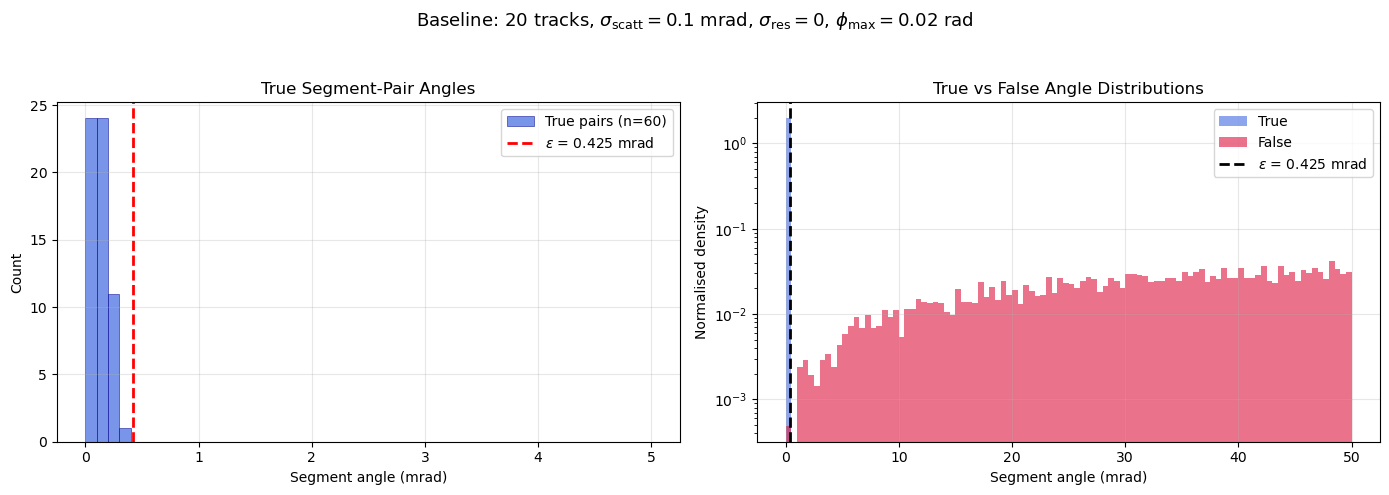


Segment efficiency: 1.000
Segment false rate: 0.016
True accepted: 60/60
False accepted: 1/23940


: 

In [ ]:
# ── Low-noise baseline: 20 tracks, small angular cone ────────────
np.random.seed(42)
event_clean = safe_generate(20, measurement_error=0.0, collision_noise=1e-4,
                            phi_max=0.02, theta_max=0.02)
true_angles_clean, false_angles_clean = collect_segment_pair_angles(event_clean)
epsilon_clean = compute_epsilon(0.0, 1e-4)

print(f"Event: {len(event_clean.tracks)} tracks, {len(event_clean.hits)} hits")
print(f"True pairs: {len(true_angles_clean)}, False pairs: {len(false_angles_clean)}")
print(f"Epsilon: {epsilon_clean*1e3:.3f} mrad")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# True angles
bins = np.linspace(0, 5, 51)
ax1.hist(np.array(true_angles_clean) * 1e3, bins=bins, alpha=0.7,
         color='royalblue', edgecolor='darkblue', linewidth=0.5,
         label=f'True pairs (n={len(true_angles_clean)})')
ax1.axvline(epsilon_clean * 1e3, color='red', linestyle='--', linewidth=2,
            label=rf'$\varepsilon$ = {epsilon_clean*1e3:.3f} mrad')
ax1.set_xlabel('Segment angle (mrad)')
ax1.set_ylabel('Count')
ax1.set_title('True Segment-Pair Angles')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Both: true vs false overlap
bins_wide = np.linspace(0, 50, 101)
ax2.hist(np.array(true_angles_clean) * 1e3, bins=bins_wide, alpha=0.6,
         color='royalblue', density=True, label='True')
ax2.hist(np.array(false_angles_clean) * 1e3, bins=bins_wide, alpha=0.6,
         color='crimson', density=True, label='False')
ax2.axvline(epsilon_clean * 1e3, color='black', linestyle='--', linewidth=2,
            label=rf'$\varepsilon$ = {epsilon_clean*1e3:.3f} mrad')
ax2.set_xlabel('Segment angle (mrad)')
ax2.set_ylabel('Normalised density')
ax2.set_title('True vs False Angle Distributions')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

fig.suptitle(r'Baseline: 20 tracks, $\sigma_{\mathrm{scatt}}=0.1$ mrad, '
             r'$\sigma_{\mathrm{res}}=0$, $\phi_{\max}=0.02$ rad', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(OUT_DIR / 'baseline_angle_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

metrics_clean = compute_segment_metrics(true_angles_clean, false_angles_clean, epsilon_clean)
print(f"\nSegment efficiency: {metrics_clean['segment_efficiency']:.3f}")
print(f"Segment false rate: {metrics_clean['segment_false_rate']:.3f}")
print(f"True accepted: {metrics_clean['true_accepted']}/{metrics_clean['n_true']}")
print(f"False accepted: {metrics_clean['false_accepted']}/{metrics_clean['n_false']}")

## 4. Scattering Angle Histograms

True- and false-pair angle distributions for varying σ_scatt, with ε threshold overlay.

| Parameter | Value |
|-----------|-------|
| Swept | σ_scatt ∈ [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0] mrad |
| n_tracks | 20 |
| σ_res | 0.0 mm |
| φ_max = θ_max | 0.02 rad |
| ε mode | **Formula** |
| Events per point | 10 |

In [ ]:
SIGMA_SCATT_VALUES = [0.5e-4, 1e-4, 2e-4, 4e-4, 6e-4, 8e-4, 1e-3]
N_TRACKS_HIST = 20
N_EVENTS_HIST = 10
PHI_MAX_HIST  = 0.02

_cache_file = CACHE_DIR / "scatt_angle_results.pkl"
if _cache_file.exists():
    with open(_cache_file, "rb") as f:
        scatt_angle_results = pickle.load(f)
    print(f"Loaded {len(scatt_angle_results)} scattering histogram results from cache")
else:
    scatt_angle_results = []

    for si, sigma_s in enumerate(SIGMA_SCATT_VALUES):
        epsilon = compute_epsilon(0.0, sigma_s)
        all_true, all_false = [], []

        for ev_i in range(N_EVENTS_HIST):
            np.random.seed(si * 1000 + ev_i)
            event = safe_generate(N_TRACKS_HIST, measurement_error=0.0,
                                  collision_noise=sigma_s,
                                  phi_max=PHI_MAX_HIST, theta_max=PHI_MAX_HIST)
            ta, fa = collect_segment_pair_angles(event)
            all_true.extend(ta)
            all_false.extend(fa)

        metrics = compute_segment_metrics(all_true, all_false, epsilon)
        scatt_angle_results.append({
            "sigma_scatt": sigma_s,
            "sigma_scatt_mrad": sigma_s * 1e3,
            "epsilon": epsilon,
            "true_angles": np.array(all_true),
            "false_angles": np.array(all_false),
            **metrics,
        })

        print(f"  sigma_scatt={sigma_s*1e3:.2f} mrad  eps={epsilon*1e3:.3f} mrad  "
              f"seg_eff={metrics['segment_efficiency']:.3f}  "
              f"false_rate={metrics['segment_false_rate']:.3f}  "
              f"true={metrics['n_true']}  false={metrics['n_false']}")

    with open(_cache_file, "wb") as f:
        pickle.dump(scatt_angle_results, f)
    print(f"\nDone & saved: {len(scatt_angle_results)} scattering values x {N_EVENTS_HIST} events")

Loaded 7 scattering histogram results from cache


: 

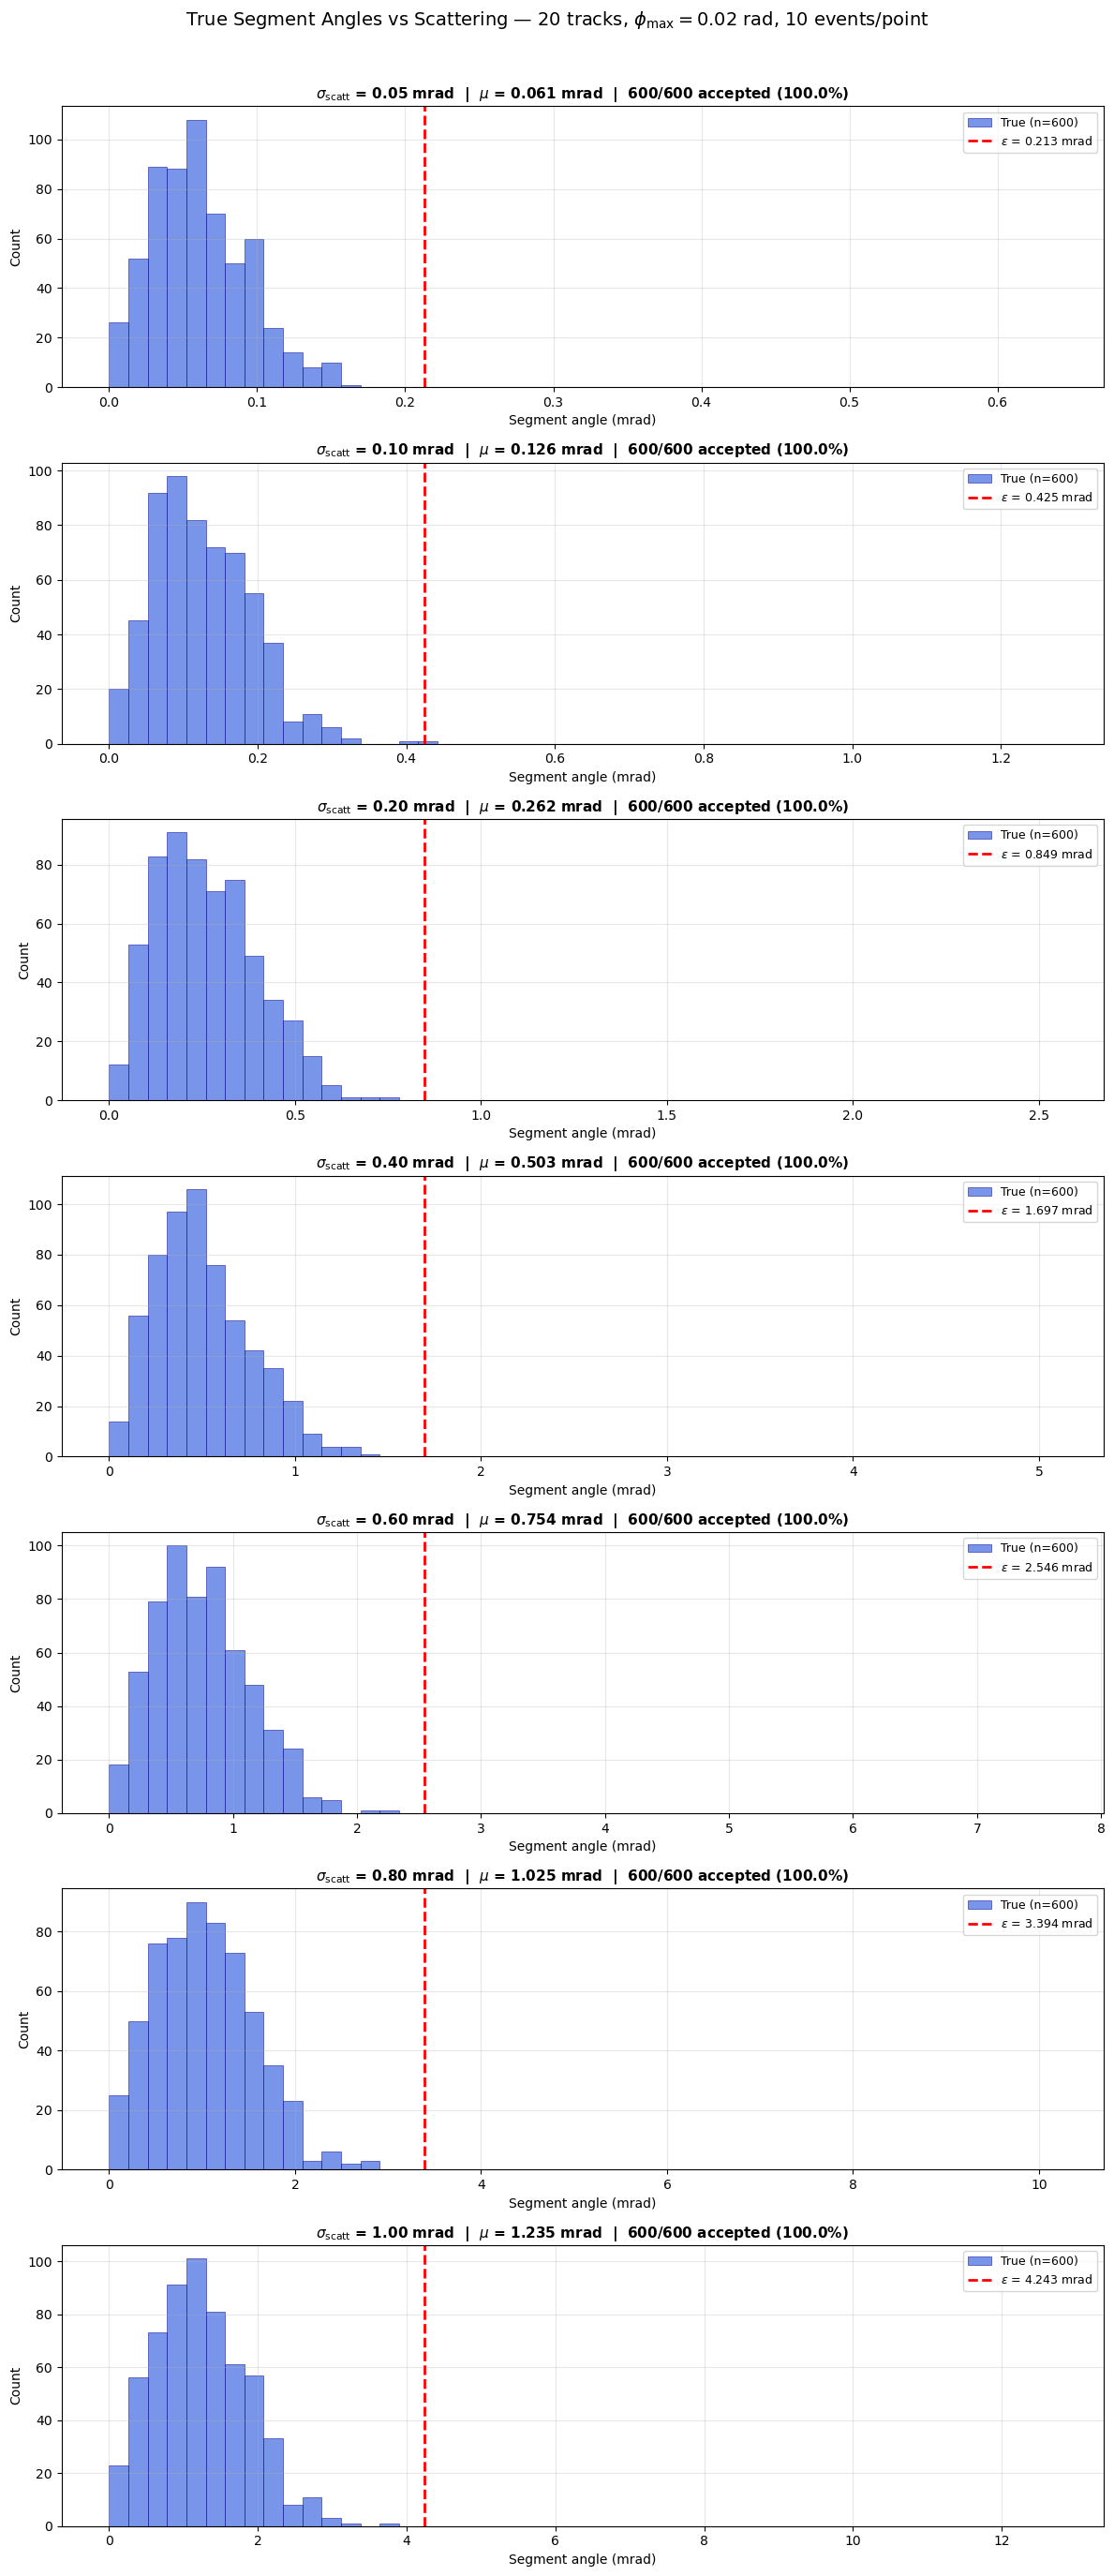

: 

In [ ]:
n_plots = len(scatt_angle_results)
fig, axes = plt.subplots(n_plots, 1, figsize=(12, 4 * n_plots))
if n_plots == 1:
    axes = [axes]

for idx, result in enumerate(scatt_angle_results):
    ax = axes[idx]
    true_mrad = result["true_angles"] * 1e3
    epsilon_mrad = result["epsilon"] * 1e3

    # Auto-range: up to max(3*epsilon, 99th percentile of true)
    x_max = max(3 * epsilon_mrad,
                np.percentile(true_mrad, 99) if len(true_mrad) > 0 else 5)
    bins = np.linspace(0, x_max, 50)

    ax.hist(true_mrad, bins=bins, alpha=0.7, color='royalblue',
            edgecolor='darkblue', linewidth=0.5, label=f'True (n={result["n_true"]})')
    ax.axvline(epsilon_mrad, color='red', linestyle='--', linewidth=2,
               label=rf'$\varepsilon$ = {epsilon_mrad:.3f} mrad')

    accepted = result["true_accepted"]
    n_true   = result["n_true"]
    ax.set_title(
        rf'$\sigma_{{\mathrm{{scatt}}}}$ = {result["sigma_scatt_mrad"]:.2f} mrad  |  '
        rf'$\mu$ = {np.mean(true_mrad):.3f} mrad  |  '
        f'{accepted}/{n_true} accepted ({result["segment_efficiency"]*100:.1f}%)',
        fontsize=11, fontweight='bold')
    ax.set_xlabel('Segment angle (mrad)')
    ax.set_ylabel('Count')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(rf'True Segment Angles vs Scattering — {N_TRACKS_HIST} tracks, '
             rf'$\phi_{{\max}}={PHI_MAX_HIST}$ rad, {N_EVENTS_HIST} events/point',
             fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUT_DIR / 'scattering_sweep_histograms.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'scattering_sweep_histograms.pdf', bbox_inches='tight')
plt.show()

## 5. Segment Efficiency & False Rate vs Scattering

Efficiency and false rate as a function of σ_scatt, for multiple track counts and both angular cones.

| Parameter | Value |
|-----------|-------|
| Swept | σ_scatt × n_tracks × φ_max |
| n_tracks | [10, 20, 50, 100] |
| σ_scatt | [0.05 – 1.0] mrad (7 values) |
| σ_res | 0.0 mm |
| φ_max = θ_max | [0.02, 0.2] rad |
| ε mode | **Formula** |
| Events per point | 10 |

In [ ]:
TRACK_COUNTS   = [10, 20, 50, 100]
N_EVENTS_STATS = 10

TRACK_COLORS = {10: "#1b7837", 20: "#2166ac", 50: "#e08214", 100: "#c51b7d"}
TRACK_FMTS   = {10: "o-",     20: "s--",     50: "D:",      100: "^-."}

_cache_file = CACHE_DIR / "df_seg_scatt.csv"
if _cache_file.exists():
    df_seg_scatt = pd.read_csv(_cache_file)
    print(f"Loaded df_seg_scatt from cache: {len(df_seg_scatt)} rows")
else:
    seg_rows = []

    for phi_max in ANGLE_SETTINGS:
        for n_trk in TRACK_COUNTS:
            for si, sigma_s in enumerate(SIGMA_SCATT_VALUES):
                epsilon = compute_epsilon(0.0, sigma_s)

                for rep in range(N_EVENTS_STATS):
                    np.random.seed(rep + n_trk * 100 + si * 10000)
                    event = safe_generate(n_trk, measurement_error=0.0,
                                          collision_noise=sigma_s,
                                          phi_max=phi_max, theta_max=phi_max)
                    m = fast_segment_metrics(event, epsilon)
                    seg_rows.append({
                        "phi_max": phi_max,
                        "n_tracks": n_trk,
                        "sigma_scatt": sigma_s,
                        "sigma_scatt_mrad": sigma_s * 1e3,
                        "epsilon": epsilon,
                        "repeat": rep,
                        **m,
                    })

            print(f"  phi_max={phi_max}  n_tracks={n_trk:3d}  done")

    df_seg_scatt = pd.DataFrame(seg_rows)
    df_seg_scatt.to_csv(_cache_file, index=False)
    print(f"\n{len(df_seg_scatt)} rows collected & saved")

Loaded df_seg_scatt from cache: 560 rows


: 

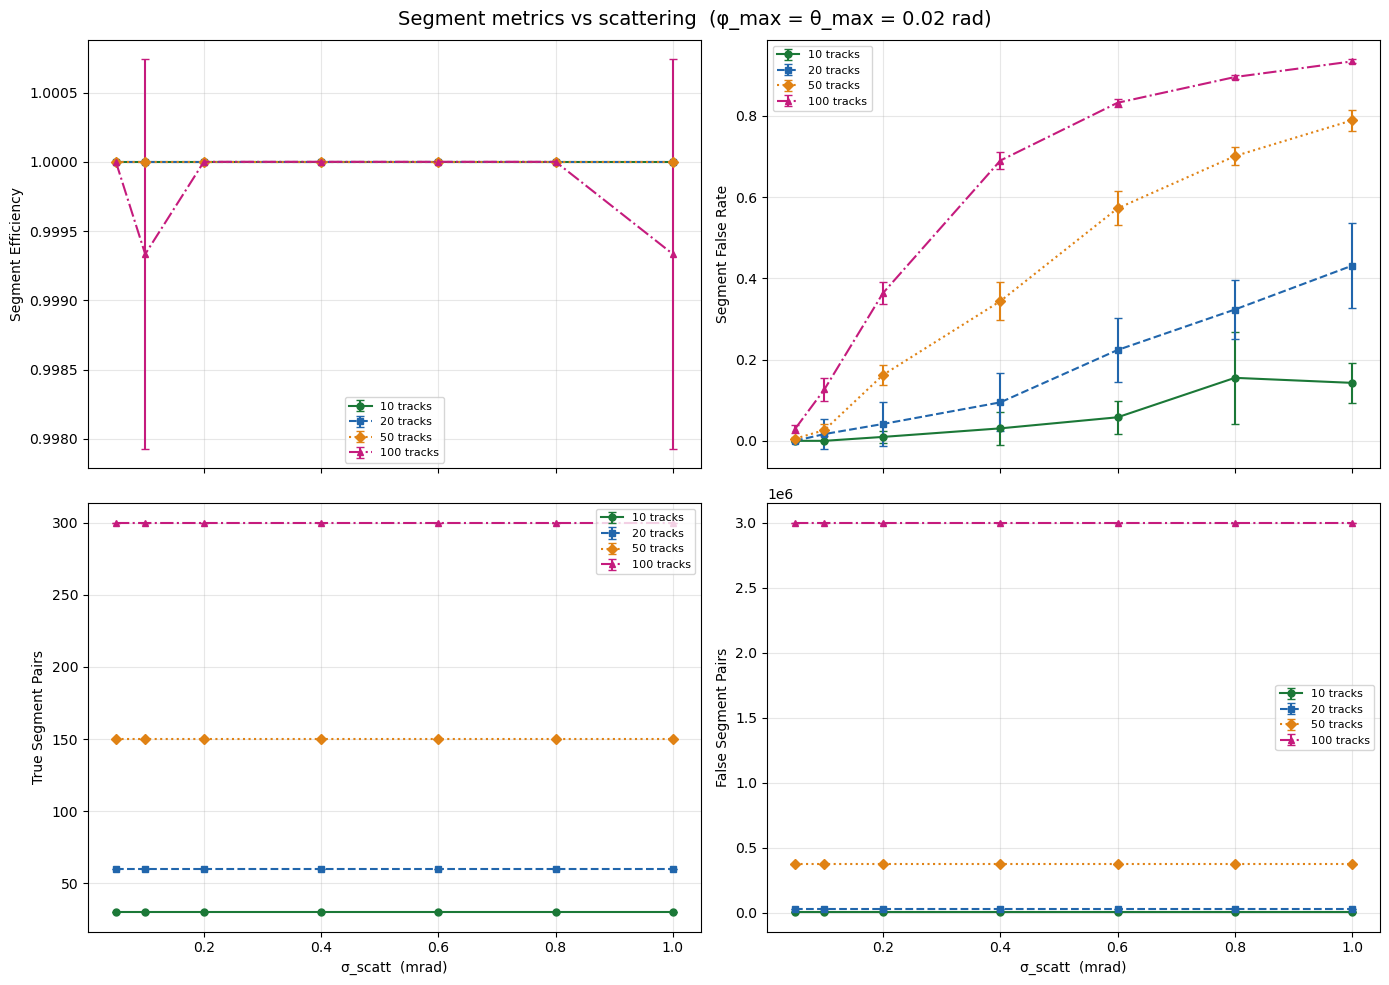

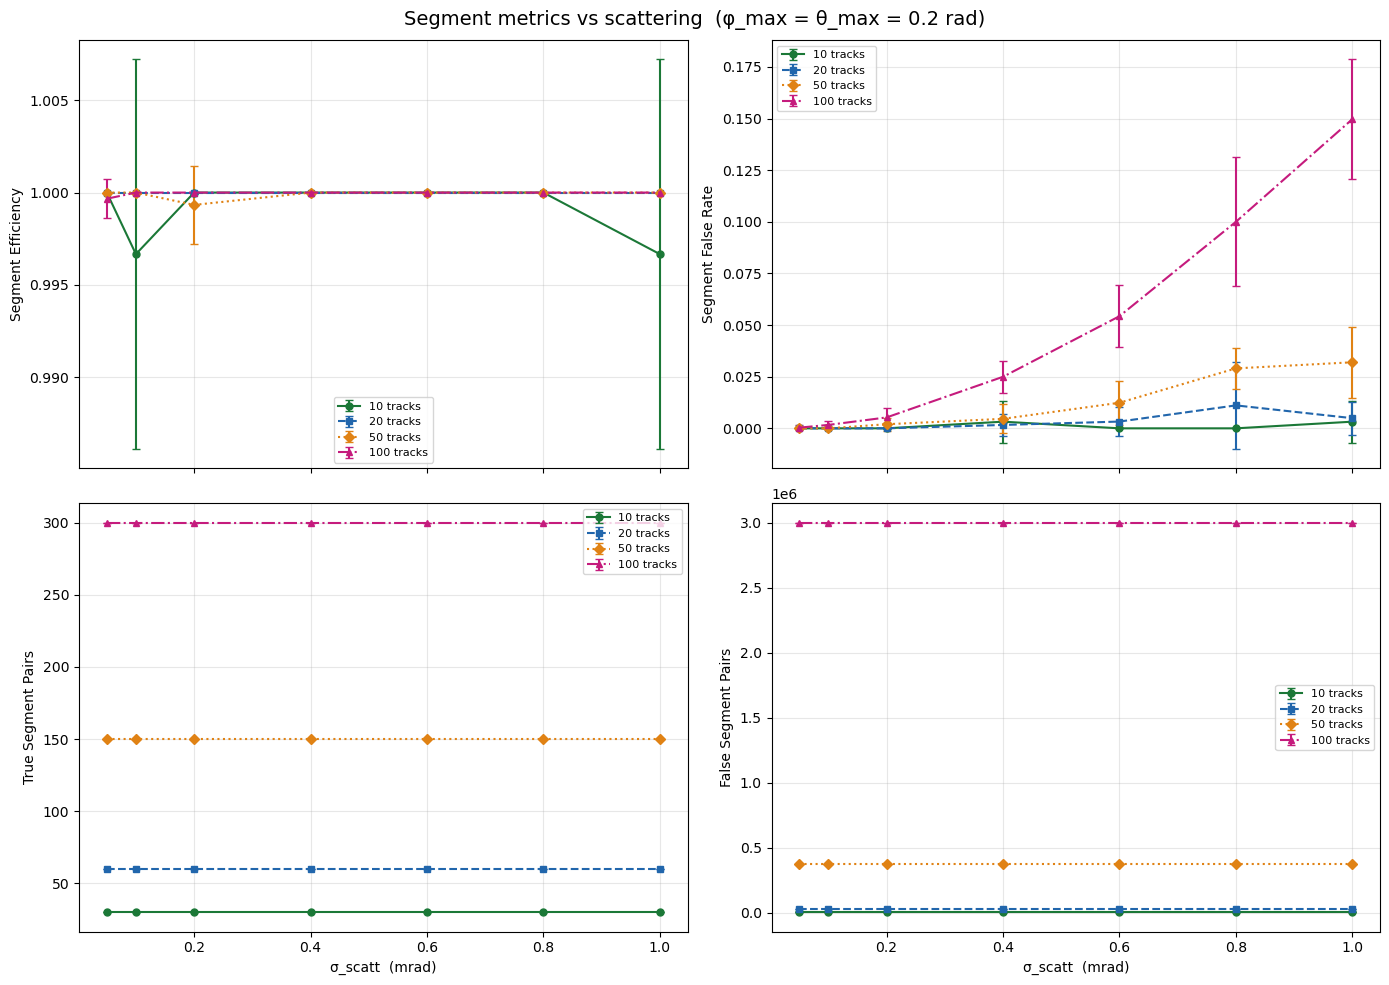

: 

In [ ]:
for phi_max in ANGLE_SETTINGS:
    sub = df_seg_scatt[df_seg_scatt["phi_max"] == phi_max]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Segment metrics vs scattering  (φ_max = θ_max = {phi_max} rad)",
                 fontsize=14)

    metrics = [("segment_efficiency", "Segment Efficiency"),
               ("segment_false_rate", "Segment False Rate"),
               ("n_true",           "True Segment Pairs"),
               ("n_false",          "False Segment Pairs")]

    for ax, (col, label) in zip(axes.flat, metrics):
        for n_trk in TRACK_COUNTS:
            d = sub[sub["n_tracks"] == n_trk].groupby("sigma_scatt_mrad")[col]
            mean = d.mean()
            std  = d.std()
            ax.errorbar(mean.index, mean.values, yerr=std.values,
                        fmt=TRACK_FMTS[n_trk], color=TRACK_COLORS[n_trk],
                        label=f"{n_trk} tracks", capsize=3, ms=5)
        ax.set_ylabel(label)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[1]:
        ax.set_xlabel("σ_scatt  (mrad)")

    fig.tight_layout()
    fig.savefig(OUT_DIR / f'scattering_sweep_phi{phi_max}.png', dpi=150, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'scattering_sweep_phi{phi_max}.pdf', bbox_inches='tight')
    plt.show()

## 6. Segment Efficiency & False Rate vs Hit Resolution

Same sweep structure as §5 but varying σ_res at fixed σ_scatt.

| Parameter | Value |
|-----------|-------|
| Swept | σ_res × n_tracks × φ_max |
| n_tracks | [10, 20, 50, 100] |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad, fixed) |
| σ_res | [0.0, 0.005, 0.01, 0.015, 0.02, 0.03, 0.05] mm |
| φ_max = θ_max | [0.02, 0.2] rad |
| ε mode | **Formula** |
| Events per point | 10 |

In [ ]:
SIGMA_RES_VALUES   = [0.0, 0.005, 0.01, 0.015, 0.02, 0.03, 0.05]
SIGMA_SCATT_FIXED  = 1e-4

_cache_file = CACHE_DIR / "df_seg_res.csv"
if _cache_file.exists():
    df_seg_res = pd.read_csv(_cache_file)
    print(f"Loaded df_seg_res from cache: {len(df_seg_res)} rows")
else:
    res_rows = []

    for phi_max in ANGLE_SETTINGS:
        for n_trk in TRACK_COUNTS:
            for ri, sigma_r in enumerate(SIGMA_RES_VALUES):
                epsilon = compute_epsilon(sigma_r, SIGMA_SCATT_FIXED)

                for rep in range(N_EVENTS_STATS):
                    np.random.seed(rep + n_trk * 100 + ri * 10000)
                    event = safe_generate(n_trk, measurement_error=sigma_r,
                                          collision_noise=SIGMA_SCATT_FIXED,
                                          phi_max=phi_max, theta_max=phi_max)
                    m = fast_segment_metrics(event, epsilon)
                    res_rows.append({
                        "phi_max": phi_max,
                        "n_tracks": n_trk,
                        "sigma_res": sigma_r,
                        "sigma_res_mm": sigma_r,
                        "epsilon": epsilon,
                        "repeat": rep,
                        **m,
                    })

            print(f"  phi_max={phi_max}  n_tracks={n_trk:3d}  done")

    df_seg_res = pd.DataFrame(res_rows)
    df_seg_res.to_csv(_cache_file, index=False)
    print(f"\n{len(df_seg_res)} rows collected & saved")

Loaded df_seg_res from cache: 560 rows


: 

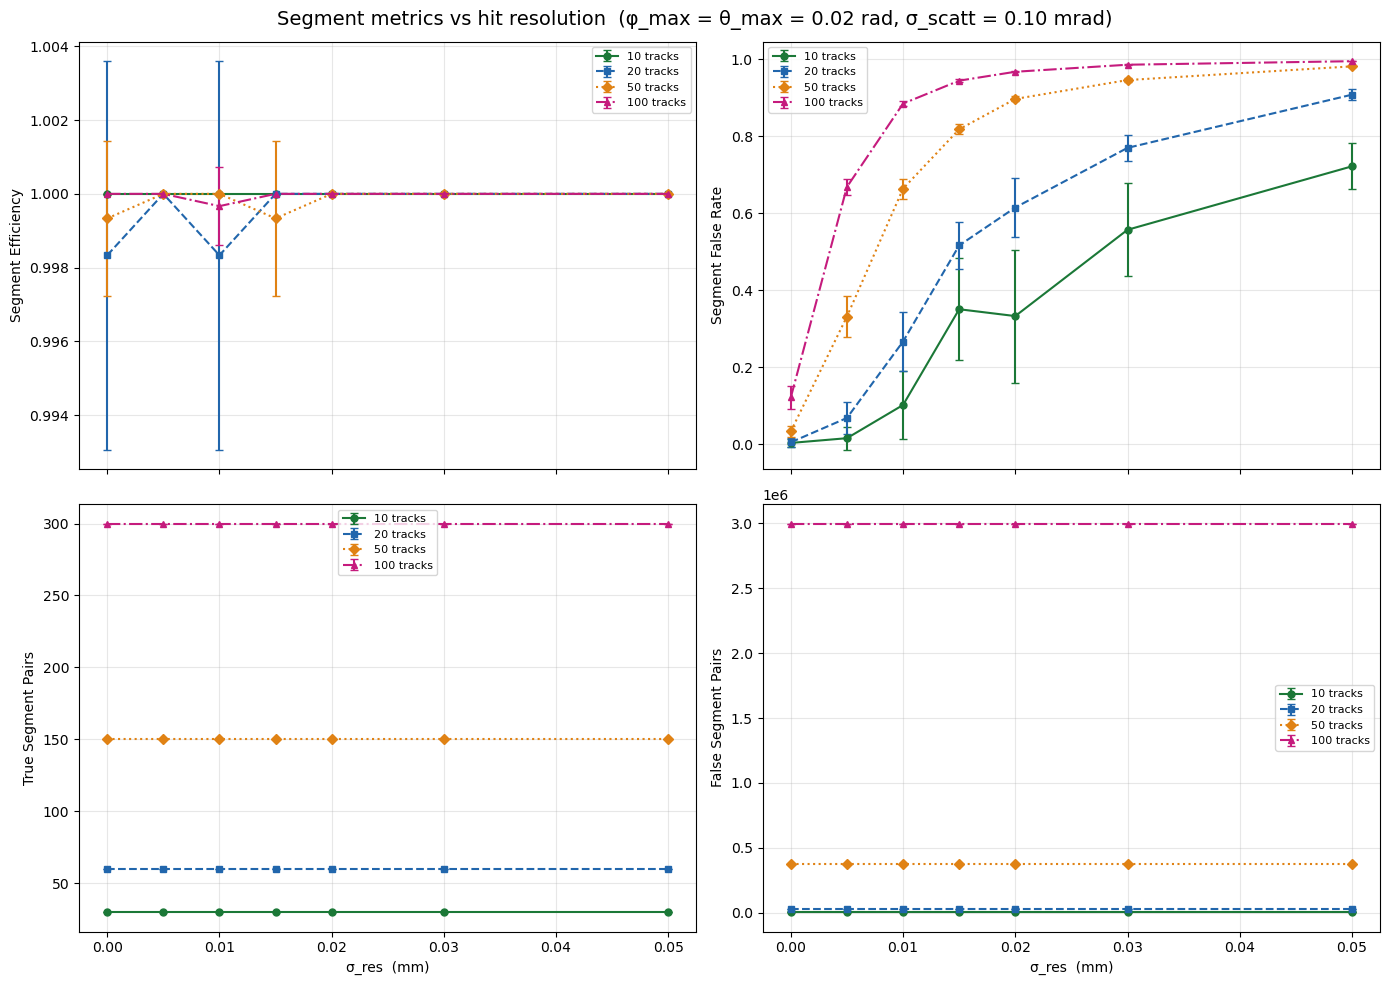

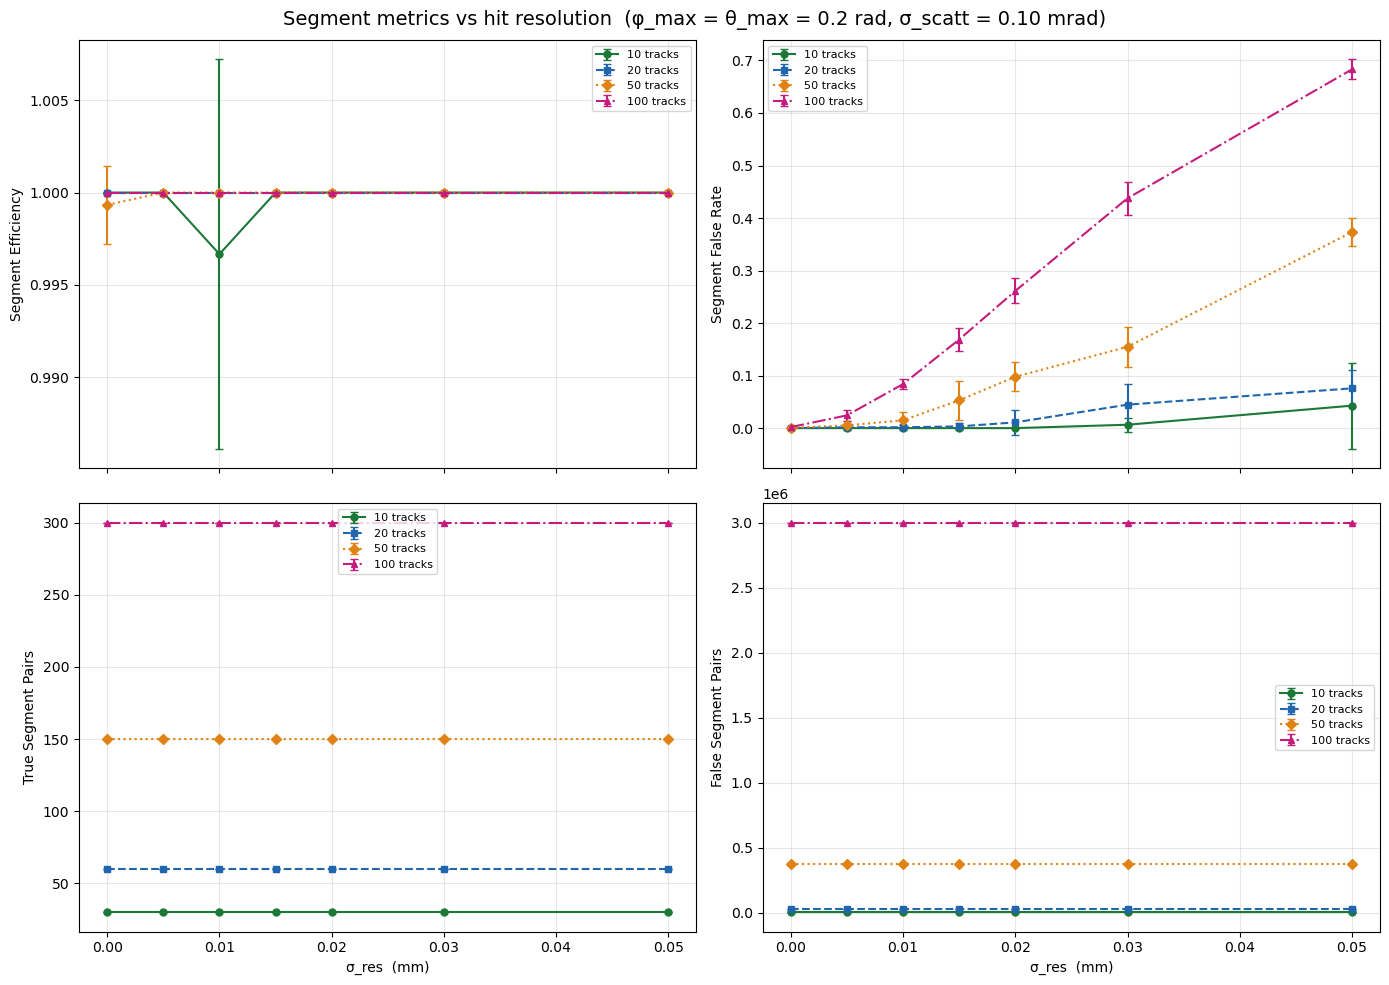

: 

In [ ]:
for phi_max in ANGLE_SETTINGS:
    sub = df_seg_res[df_seg_res["phi_max"] == phi_max]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Segment metrics vs hit resolution  (φ_max = θ_max = {phi_max} rad, "
                 f"σ_scatt = {SIGMA_SCATT_FIXED*1e3:.2f} mrad)", fontsize=14)

    metrics = [("segment_efficiency", "Segment Efficiency"),
               ("segment_false_rate", "Segment False Rate"),
               ("n_true",            "True Segment Pairs"),
               ("n_false",           "False Segment Pairs")]

    for ax, (col, label) in zip(axes.flat, metrics):
        for n_trk in TRACK_COUNTS:
            d = sub[sub["n_tracks"] == n_trk].groupby("sigma_res_mm")[col]
            mean = d.mean()
            std  = d.std()
            ax.errorbar(mean.index, mean.values, yerr=std.values,
                        fmt=TRACK_FMTS[n_trk], color=TRACK_COLORS[n_trk],
                        label=f"{n_trk} tracks", capsize=3, ms=5)
        ax.set_ylabel(label)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[1]:
        ax.set_xlabel("σ_res  (mm)")

    fig.tight_layout()
    fig.savefig(OUT_DIR / f'resolution_sweep_phi{phi_max}.png', dpi=150, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'resolution_sweep_phi{phi_max}.pdf', bbox_inches='tight')
    plt.show()

## 7. Track Density Scan

Segment metrics vs track count at fixed low noise. True pairs grow ∝ n, false pairs grow ∝ n².

| Parameter | Value |
|-----------|-------|
| Swept | n_tracks |
| n_tracks | 5–100 (step 5) |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad) |
| σ_res | 0.0 mm |
| φ_max = θ_max | 0.2 rad |
| ε mode | **Formula** |
| Events per point | 5 |

In [2]:
DENSITY_TRACKS    = list(range(5, 105, 5))
N_EVENTS_DENSITY  = 5
SIGMA_SCATT_DENS  = 1e-4
SIGMA_RES_DENS    = 0.0
PHI_MAX_DENS      = 0.2

epsilon_dens = compute_epsilon(SIGMA_RES_DENS, SIGMA_SCATT_DENS)

_cache_file = CACHE_DIR / "df_density.csv"
if _cache_file.exists():
    df_density = pd.read_csv(_cache_file)
    print(f"Loaded df_density from cache: {len(df_density)} rows")
else:
    density_rows = []

    for n_trk in DENSITY_TRACKS:
        for rep in range(N_EVENTS_DENSITY):
            np.random.seed(rep + n_trk * 100)
            event = safe_generate(n_trk, measurement_error=SIGMA_RES_DENS,
                                  collision_noise=SIGMA_SCATT_DENS,
                                  phi_max=PHI_MAX_DENS, theta_max=PHI_MAX_DENS)
            m = fast_segment_metrics(event, epsilon_dens)
            density_rows.append({
                "n_tracks": n_trk,
                "repeat": rep,
                "epsilon": epsilon_dens,
                **m,
            })

        print(f"  n_tracks={n_trk:3d}  done")

    df_density = pd.DataFrame(density_rows)
    df_density.to_csv(_cache_file, index=False)
    print(f"\n{len(df_density)} rows collected & saved")

NameError: name 'compute_epsilon' is not defined

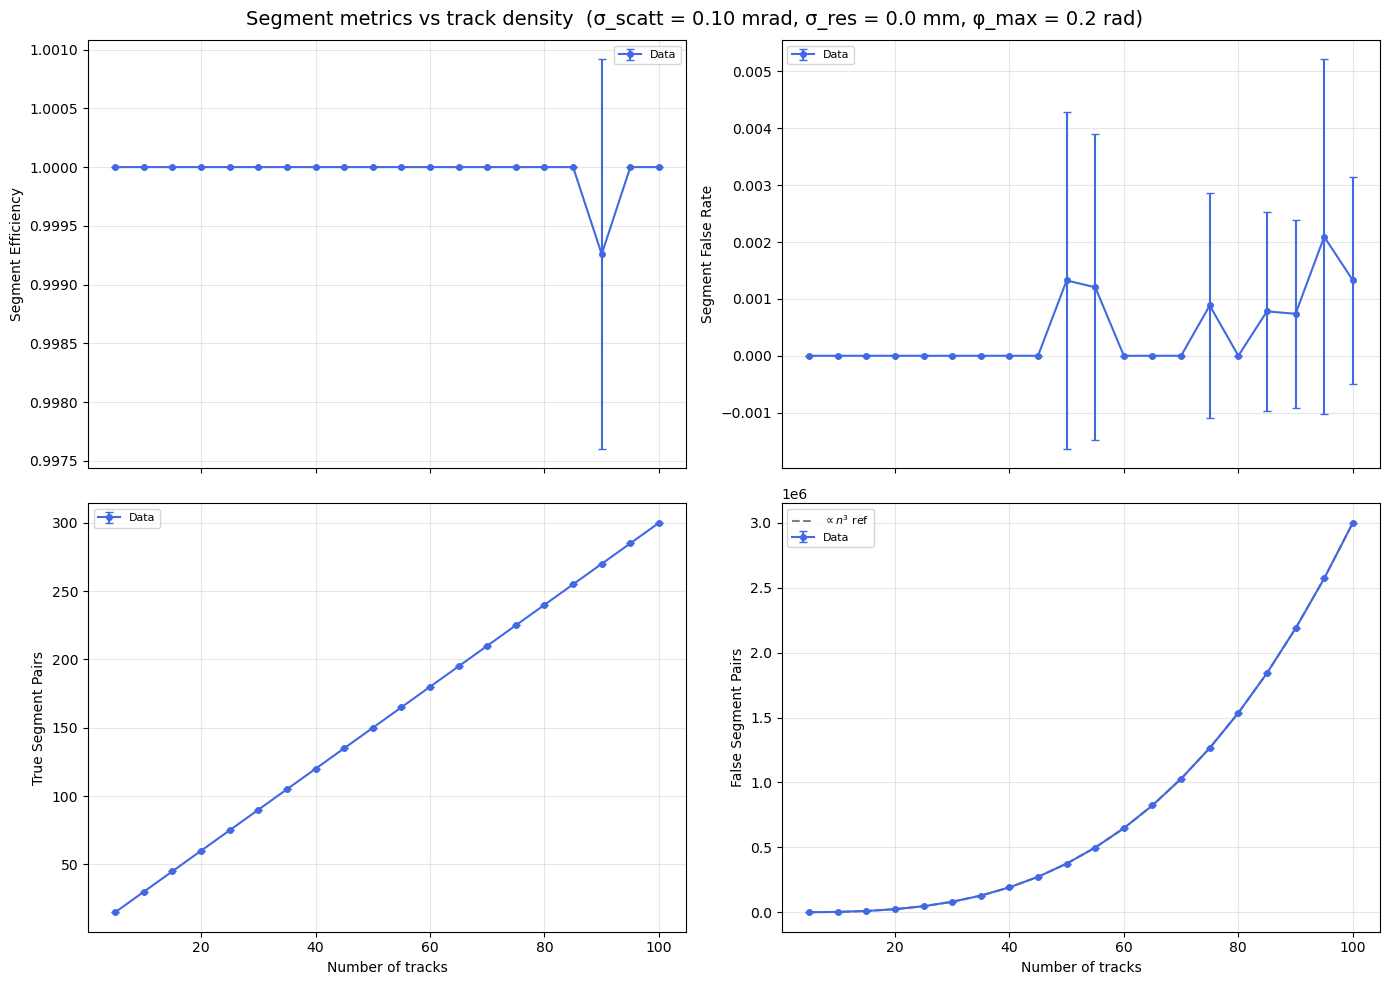

: 

In [ ]:
grp = df_density.groupby("n_tracks")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fig.suptitle(f"Segment metrics vs track density  (σ_scatt = {SIGMA_SCATT_DENS*1e3:.2f} mrad, "
             f"σ_res = {SIGMA_RES_DENS} mm, φ_max = {PHI_MAX_DENS} rad)", fontsize=14)

metrics = [("segment_efficiency", "Segment Efficiency"),
           ("segment_false_rate", "Segment False Rate"),
           ("n_true",            "True Segment Pairs"),
           ("n_false",           "False Segment Pairs")]

for ax, (col, label) in zip(axes.flat, metrics):
    mean = grp[col].mean()
    std  = grp[col].std()
    ax.errorbar(mean.index, mean.values, yerr=std.values,
                fmt="o-", color="royalblue", capsize=3, ms=4, label="Data")

    # Reference line for n_false: n³ scaling (triplet combinatorics)
    if col == "n_false":
        n_arr = mean.index.values.astype(float)
        # Fit scale factor from the last point
        c = mean.values[-1] / n_arr[-1]**3 if n_arr[-1] > 0 else 1
        ax.plot(n_arr, c * n_arr**3, "k--", alpha=0.5, label=r"$\propto n^3$ ref")

    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("Number of tracks")

fig.tight_layout()
fig.savefig(OUT_DIR / 'density_scan.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'density_scan.pdf', bbox_inches='tight')
plt.show()

## 8. Acceptance Curves (ROC-style)

For each σ_scatt, sweep the acceptance threshold from 0–10 mrad and plot the true/false acceptance fraction. The formula ε marks the operating point.

| Parameter | Value |
|-----------|-------|
| Swept | threshold (0–10 mrad, 200 steps) × σ_scatt |
| n_tracks | 20 |
| σ_scatt | [0.05 – 1.0] mrad (7 values) |
| σ_res | 0.0 mm |
| φ_max = θ_max | 0.2 rad |
| ε mode | **Formula** (operating-point markers) |
| Events per σ_scatt | 10 |

Loaded roc_data from cache: 7 scattering values


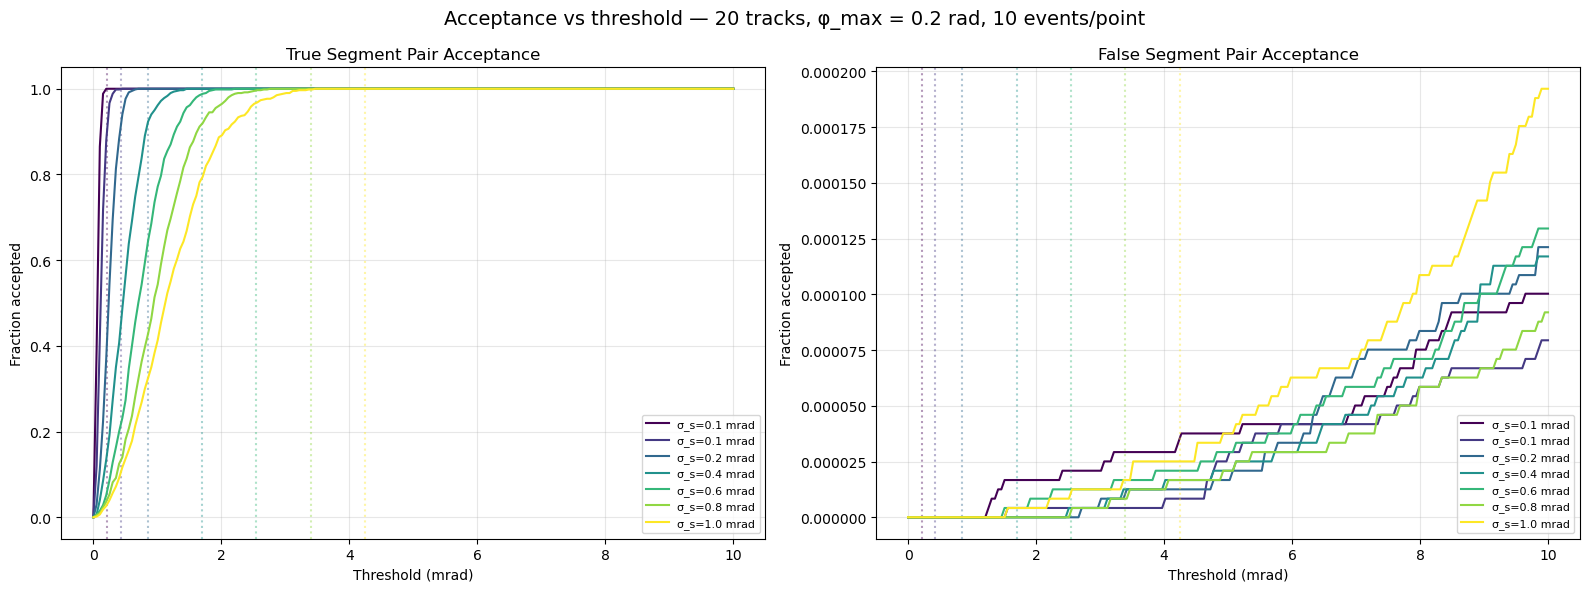

: 

In [ ]:
N_TRACKS_ROC = 20
N_EVENTS_ROC = 10
PHI_MAX_ROC  = 0.2
THRESHOLDS   = np.linspace(0, 10e-3, 200)  # 0 to 10 mrad

# Collect raw angles for each scattering value
_cache_file = CACHE_DIR / "roc_data.pkl"
if _cache_file.exists():
    with open(_cache_file, "rb") as f:
        roc_data = pickle.load(f)
    print(f"Loaded roc_data from cache: {len(roc_data)} scattering values")
else:
    roc_data = {}
    for si, sigma_s in enumerate(SIGMA_SCATT_VALUES):
        all_true, all_false = [], []
        for ev_i in range(N_EVENTS_ROC):
            np.random.seed(si * 1000 + ev_i)
            event = safe_generate(N_TRACKS_ROC, measurement_error=0.0,
                                  collision_noise=sigma_s,
                                  phi_max=PHI_MAX_ROC, theta_max=PHI_MAX_ROC)
            ta, fa = collect_segment_pair_angles(event)
            all_true.extend(ta)
            all_false.extend(fa)
        roc_data[sigma_s] = (np.array(all_true), np.array(all_false))
        print(f"  σ_scatt={sigma_s*1e3:.2f} mrad  true={len(all_true)}  false={len(all_false)}")

    with open(_cache_file, "wb") as f:
        pickle.dump(roc_data, f)
    print("ROC data saved to cache")

# Plot acceptance curves
cmap = plt.cm.viridis
colors = [cmap(i / max(1, len(SIGMA_SCATT_VALUES) - 1))
          for i in range(len(SIGMA_SCATT_VALUES))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for sigma_s, color in zip(SIGMA_SCATT_VALUES, colors):
    true_arr, false_arr = roc_data[sigma_s]
    epsilon = compute_epsilon(0.0, sigma_s)

    true_frac  = [np.mean(true_arr <= th) if len(true_arr) > 0 else 0
                  for th in THRESHOLDS]
    false_frac = [np.mean(false_arr <= th) if len(false_arr) > 0 else 0
                  for th in THRESHOLDS]

    label = f"σ_s={sigma_s*1e3:.1f} mrad"
    ax1.plot(THRESHOLDS * 1e3, true_frac, color=color, label=label)
    ax2.plot(THRESHOLDS * 1e3, false_frac, color=color, label=label)

    # Mark the epsilon operating point
    ax1.axvline(epsilon * 1e3, color=color, linestyle=':', alpha=0.4)
    ax2.axvline(epsilon * 1e3, color=color, linestyle=':', alpha=0.4)

ax1.set_title("True Segment Pair Acceptance", fontsize=12)
ax1.set_xlabel("Threshold (mrad)")
ax1.set_ylabel("Fraction accepted")
ax1.legend(fontsize=8, loc="lower right")
ax1.grid(True, alpha=0.3)

ax2.set_title("False Segment Pair Acceptance", fontsize=12)
ax2.set_xlabel("Threshold (mrad)")
ax2.set_ylabel("Fraction accepted")
ax2.legend(fontsize=8, loc="lower right")
ax2.grid(True, alpha=0.3)

fig.suptitle(f"Acceptance vs threshold — {N_TRACKS_ROC} tracks, "
             f"φ_max = {PHI_MAX_ROC} rad, {N_EVENTS_ROC} events/point", fontsize=14)
fig.tight_layout()
fig.savefig(OUT_DIR / 'acceptance_curves.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'acceptance_curves.pdf', bbox_inches='tight')
plt.show()

## 9. Summary Tables & CSV Export

Aggregate mean ± std for each configuration and save to CSV for downstream use.

In [ ]:
agg_cols = ["segment_efficiency", "segment_false_rate", "n_true", "n_false"]

# ── Scattering sweep summary ─────────────────────────────────────
print("=" * 80)
print("SCATTERING SWEEP SUMMARY")
print("=" * 80)
summary_scatt = (df_seg_scatt
    .groupby(["phi_max", "n_tracks", "sigma_scatt_mrad"])[agg_cols]
    .agg(["mean", "std"])
)
display(summary_scatt.round(4))

# ── Resolution sweep summary ─────────────────────────────────────
print("\n" + "=" * 80)
print("RESOLUTION SWEEP SUMMARY")
print("=" * 80)
summary_res = (df_seg_res
    .groupby(["phi_max", "n_tracks", "sigma_res_mm"])[agg_cols]
    .agg(["mean", "std"])
)
display(summary_res.round(4))

# ── Density scan summary ─────────────────────────────────────────
print("\n" + "=" * 80)
print("DENSITY SCAN SUMMARY")
print("=" * 80)
summary_dens = (df_density
    .groupby("n_tracks")[agg_cols]
    .agg(["mean", "std"])
)
display(summary_dens.round(4))

SCATTERING SWEEP SUMMARY


segment_efficiency          \
                                                mean     std   
phi_max n_tracks sigma_scatt_mrad                              
0.02    10       0.05                         1.0000  0.0000   
                 0.10                         1.0000  0.0000   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         1.0000  0.0000   
        20       0.05                         1.0000  0.0000   
                 0.10                         1.0000  0.0000   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         1.0000  0.0000   
        50       0.05                         1.0000  0.0000   
                 0.10                         1.0000  0.0000   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         1.0000  0.0000   
        100      0.05                         1.0000  0.0000   
                 0.10                         0.9993  0.0014   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         0.9993  0.0014   
0.20    10       0.05                         1.0000  0.0000   
                 0.10                         0.9967  0.0105   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         0.9967  0.0105   
        20       0.05                         1.0000  0.0000   
                 0.10                         1.0000  0.0000   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         1.0000  0.0000   
        50       0.05                         1.0000  0.0000   
                 0.10                         1.0000  0.0000   
                 0.20                         0.9993  0.0021   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         1.0000  0.0000   
        100      0.05                         0.9997  0.0011   
                 0.10                         1.0000  0.0000   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         1.0000  0.0000   

                                  segment_false_rate         n_true       \
                                                mean     std   mean  std   
phi_max n_tracks sigma_scatt_mrad                                          
0.02    10       0.05        


RESOLUTION SWEEP SUMMARY


segment_efficiency         segment_false_rate  \
                                            mean     std               mean   
phi_max n_tracks sigma_res_mm                                                 
0.02    10       0.000                    1.0000  0.0000             0.0032   
                 0.005                    1.0000  0.0000             0.0155   
                 0.010                    1.0000  0.0000             0.1017   
                 0.015                    1.0000  0.0000             0.3503   
                 0.020                    1.0000  0.0000             0.3326   
                 0.030                    1.0000  0.0000             0.5566   
                 0.050                    1.0000  0.0000             0.7214   
        20       0.000                    0.9983  0.0053             0.0049   
                 0.005                    1.0000  0.0000             0.0681   
                 0.010                    0.9983  0.0053             0.2666   
                 0.015                    1.0000  0.0000             0.5160   
                 0.020                    1.0000  0.0000             0.6145   
                 0.030                    1.0000  0.0000             0.7694   
                 0.050                    1.0000  0.0000             0.9074   
        50       0.000                    0.9993  0.0021             0.0333   
                 0.005                    1.0000  0.0000             0.3314   
                 0.010                    1.0000  0.0000             0.6634   
                 0.015                    0.9993  0.0021             0.8175   
                 0.020                    1.0000  0.0000             0.8964   
                 0.030                    1.0000  0.0000             0.9454   
                 0.050                    1.0000  0.0000             0.9810   
        100      0.000                    1.0000  0.0000             0.1216   
                 0.005                    1.0000  0.0000             0.6680   
                 0.010                    0.9997  0.0011             0.8842   
                 0.015                    1.0000  0.0000             0.9438   
                 0.020                    1.0000  0.0000             0.9669   
                 0.030                    1.0000  0.0000             0.9852   
                 0.050                    1.0000  0.0000             0.9944   
0.20    10       0.000                    1.0000  0.0000             0.0000   
                 0.005                    1.0000  0.0000             0.0000   
                 0.010                    0.9967  0.0105             0.0000   
                 0.015                    1.0000  0.0000             0.0000   
                 0.020                    1.0000  0.0000             0.0000   
                 0.030                    1.0000  0.0000             0.0065   
                 0.050                    1.0000  0.0000             0.0428   
        20       0.000                    1.0000  0.0000             0.0000   
                 0.005                    1.0000  0.0000             0.0016   
                 0.010                    1.0000  0.0000             0.0016   
                 0.015                    1.0000  0.0000             0.0033   
                 0.020                    1.0000  0.0000             0.0110   
                 0.030                    1.0000  0.0000             0.0446   
                 0.050                    1.0000  0.0000             0.0757   
        50       0.000                    0.9993  0.0021             0.0007   
                 0.005                    1.0000  0.0000             0.0052   
                 0.010                    1.0000  0.0000             0.0149   
                 0.015                    1.0000  0.0000             0.0529   
                 0.020                    1.0000  0.0000             0.0978   
                 0.030                    1.0000  0.0000             0.1548   
 


DENSITY SCAN SUMMARY


segment_efficiency         segment_false_rate         n_true       \
                       mean     std               mean     std   mean  std   
n_tracks                                                                     
5                    1.0000  0.0000             0.0000  0.0000   15.0  0.0   
10                   1.0000  0.0000             0.0000  0.0000   30.0  0.0   
15                   1.0000  0.0000             0.0000  0.0000   45.0  0.0   
20                   1.0000  0.0000             0.0000  0.0000   60.0  0.0   
25                   1.0000  0.0000             0.0000  0.0000   75.0  0.0   
30                   1.0000  0.0000             0.0000  0.0000   90.0  0.0   
35                   1.0000  0.0000             0.0000  0.0000  105.0  0.0   
40                   1.0000  0.0000             0.0000  0.0000  120.0  0.0   
45                   1.0000  0.0000             0.0000  0.0000  135.0  0.0   
50                   1.0000  0.0000             0.0013  0.0030  150.0  0.0   
55                   1.0000  0.0000             0.0012  0.0027  165.0  0.0   
60                   1.0000  0.0000             0.0000  0.0000  180.0  0.0   
65                   1.0000  0.0000             0.0000  0.0000  195.0  0.0   
70                   1.0000  0.0000             0.0000  0.0000  210.0  0.0   
75                   1.0000  0.0000             0.0009  0.0020  225.0  0.0   
80                   1.0000  0.0000             0.0000  0.0000  240.0  0.0   
85                   1.0000  0.0000             0.0008  0.0017  255.0  0.0   
90                   0.9993  0.0017             0.0007  0.0017  270.0  0.0   
95                   1.0000  0.0000             0.0021  0.0031  285.0  0.0   
100                  1.0000  0.0000             0.0013  0.0018  300.0  0.0   

            n_false       
               mean  std  
n_tracks                  
5             360.0  0.0  
10           2970.0  0.0  
15          10080.0  0.0  
20          23940.0  0.0  
25          46800.0  0.0  
30          80910.0  0.0  
35         128520.0  0.0  
40         191880.0  0.0  
45         273240.0  0.0  
50         374850.0  0.0  
55         498960.0  0.0  
60         647820.0  0.0  
65         823680.0  0.0  
70        1028790.0  0.0  
75        1265400.0  0.0  
80        1535760.0  0.0  
85        1842120.0  0.0  
90        2186730.0  0.0  
95        2571840.0  0.0  
100       2999700.0  0.0

: 

In [ ]:
# Save per-event DataFrames
df_seg_scatt.to_csv(OUT_DIR / "segment_scattering_sweep.csv", index=False)
df_seg_res.to_csv(OUT_DIR / "segment_resolution_sweep.csv", index=False)
df_density.to_csv(OUT_DIR / "segment_density_scan.csv", index=False)

print(f"Saved CSVs to {OUT_DIR}/")
for f in sorted(OUT_DIR.glob("*.csv")):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

Saved CSVs to outputs/segment_analysis/
  segment_density_scan.csv  (5.0 KB)
  segment_density_scan_ext.csv  (11.4 KB)
  segment_resolution_sweep.csv  (40.6 KB)
  segment_resolution_sweep_ext.csv  (77.9 KB)
  segment_scattering_sweep.csv  (39.5 KB)
  segment_scattering_sweep_ext.csv  (76.5 KB)
  segment_zero_noise_ext.csv  (106.4 KB)


: 

## 10. Fixed-Epsilon Segment Efficiency (Triplet Angles, Old-Style Generation)

Segment efficiency and false rate vs track density with a **fixed** ε threshold.
Uses **triplet kink angles** (accelerated Hamiltonian) but matches the old notebook's
event generation **exactly**: multi-event with 20 tracks/event, 160 mm modules, MIP particles,
PV σ = {x:1, y:1, z:1}. The **only** difference from §10b is the angle method.

| Parameter | Value |
|-----------|-------|
| Swept | n_events (1–50 → 20–1000 total tracks) |
| Tracks per event | 20 |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad) |
| σ_res | 0.005 mm |
| φ_min, φ_max | −0.2, +0.2 rad |
| θ_min, θ_max | default (−0.2, +0.2 rad) |
| ε mode | **Fixed = 2.0 mrad** |
| lx, ly | 80 mm (half-width → 160 mm full module) |
| module_id | [1, 2, 3, 4, 5] |
| PV sigma | x = 1, y = 1, z = 1 mm |
| Repeats | 50 (≤100 tracks), 10 (101–500), 5 (>500) |
| Particle | MIP, mass = 0.511, q = 1 |
| Angle method | **Triplet kink angles** (fast_segment_metrics) |

In [9]:
# ============================================================================
# FIXED-EPSILON DATA COLLECTION — triplet angles, old-style multi-event gen
# ============================================================================
import time as _time

FIXED_RESOLUTION  = 0.005      # 5 µm
FIXED_SCATTERING  = 0.0001     # 0.1 mrad in radians
FIXED_EPSILON     = 0.002      # 2 mrad in radians
TRACKS_PER_EVENT  = 20
EVENT_COUNTS      = list(range(1, 11)) + [15, 20, 25, 30, 35, 40, 45, 50]
FIXED_TRACK_COUNTS = [n * TRACKS_PER_EVENT for n in EVENT_COUNTS]
N_REPEATS_FIXED   = 50  # for ≤100 tracks; reduced at higher multiplicities

# ── Build geometry matching old notebook ──
_NEW_HALF  = 80.0   # 160 mm full module (matches old)
geo_new = PlaneGeometry(
    module_id=list(range(1, N_MODULES + 1)),
    lx=[_NEW_HALF] * N_MODULES,
    ly=[_NEW_HALF] * N_MODULES,
    z=z_positions,
)

# ── Use SAME PV sigma as old notebook to isolate angle method ──
NEW_PV_SIGMA = {"x": 1, "y": 1, "z": 1}

print("=" * 80)
print("SEGMENT-LEVEL EFFICIENCY (fixed ε = 2 mrad, triplet angles)")
print("=" * 80)
print(f"σ_res = {FIXED_RESOLUTION} mm, σ_scatt = {FIXED_SCATTERING} rad")
print(f"Epsilon threshold: {FIXED_EPSILON*1000:.1f} mrad")
print(f"Geometry: module = {_NEW_HALF*2}×{_NEW_HALF*2} mm², z = {z_positions}")
print(f"Track counts: {FIXED_TRACK_COUNTS}")
print(f"PV sigma: {NEW_PV_SIGMA}")
print("=" * 80)

_cache_file = CACHE_DIR / "segment_efficiency_results.pkl"
if _cache_file.exists():
    with open(_cache_file, "rb") as f:
        segment_efficiency_results = pickle.load(f)
    _existing_tracks = {r['total_tracks'] for r in segment_efficiency_results}
    _needed = [n for n in EVENT_COUNTS
               if n * TRACKS_PER_EVENT not in _existing_tracks]
    if _needed:
        print(f"Loaded {len(segment_efficiency_results)} cached entries, "
              f"need {len(_needed)} more: "
              f"{[n*TRACKS_PER_EVENT for n in _needed]}")
    else:
        print(f"Loaded segment_efficiency_results from cache: "
              f"{len(segment_efficiency_results)} entries (all done)")
        _needed = []
else:
    segment_efficiency_results = []
    _needed = EVENT_COUNTS
    print("No cache — generating all configurations")

if _needed:
    _t0 = _time.time()
    for n_events in _needed:
        total_tracks = n_events * TRACKS_PER_EVENT
        n_particles_per_event = [TRACKS_PER_EVENT] * n_events

        # Match old notebook repeat schedule
        if total_tracks <= 100:
            nr_target = 50
        elif total_tracks <= 500:
            nr_target = 10
        else:
            nr_target = 5

        per_repeat_data = []
        _t1 = _time.time()

        for repeat in range(nr_target):
            np.random.seed(repeat + n_events * 1000)

            gen = StateEventGenerator(
                detector_geometry=geo_new,
                phi_min=-0.2,
                phi_max=0.2,
                # theta not set → defaults to ±0.2
                events=n_events,
                n_particles=n_particles_per_event,
                measurement_error=float(FIXED_RESOLUTION),
                collision_noise=float(FIXED_SCATTERING),
            )

            gen.generate_random_primary_vertices(NEW_PV_SIGMA)

            event_particles = [
                [{"type": "MIP", "mass": 0.511, "q": 1}
                 for _ in range(total_tracks)]
                for _ in range(n_events)
            ]
            gen.generate_particles(event_particles)
            event = gen.generate_complete_events()

            m = fast_segment_metrics(event, FIXED_EPSILON)

            per_repeat_data.append({
                'n_true': m['n_true'],
                'n_false': m['n_false'],
                'true_accepted': m['true_accepted'],
                'false_accepted': m['false_accepted'],
                'seg_efficiency': m['segment_efficiency'],
                'seg_false_rate': m['segment_false_rate'],
            })

        # Per-repeat arrays
        n_true_per    = np.array([r['n_true'] for r in per_repeat_data])
        n_false_per   = np.array([r['n_false'] for r in per_repeat_data])
        true_acc_per  = np.array([r['true_accepted'] for r in per_repeat_data])
        false_acc_per = np.array([r['false_accepted'] for r in per_repeat_data])
        eff_per       = np.array([r['seg_efficiency'] for r in per_repeat_data])
        fr_per        = np.array([r['seg_false_rate'] for r in per_repeat_data])
        nr = len(per_repeat_data)

        segment_efficiency_results.append({
            'total_tracks': total_tracks,
            'n_repeats': nr,
            'seg_efficiency_mean': np.mean(eff_per),
            'seg_efficiency_se': np.std(eff_per, ddof=1) / np.sqrt(nr),
            'seg_false_rate_mean': np.mean(fr_per),
            'seg_false_rate_se': np.std(fr_per, ddof=1) / np.sqrt(nr),
            'n_true_mean': np.mean(n_true_per),
            'n_true_se': np.std(n_true_per, ddof=1) / np.sqrt(nr),
            'n_false_mean': np.mean(n_false_per),
            'n_false_se': np.std(n_false_per, ddof=1) / np.sqrt(nr),
            'true_acc_mean': np.mean(true_acc_per),
            'true_acc_se': np.std(true_acc_per, ddof=1) / np.sqrt(nr),
            'false_acc_mean': np.mean(false_acc_per),
            'false_acc_se': np.std(false_acc_per, ddof=1) / np.sqrt(nr),
            'per_repeat': per_repeat_data,
        })

        _dt = _time.time() - _t1
        print(f"  [{total_tracks:4d} tracks, {n_events:2d} events, {nr:2d} repeats]  "
              f"eff={np.mean(eff_per)*100:.2f}%  fr={np.mean(fr_per)*100:.2f}%  "
              f"({_dt:.1f}s)")

    # Sort by total_tracks before saving
    segment_efficiency_results.sort(key=lambda r: r['total_tracks'])

    with open(_cache_file, "wb") as f:
        pickle.dump(segment_efficiency_results, f)
    print(f"\n{'='*80}")
    print(f"Done & saved ({_time.time()-_t0:.0f}s total, "
          f"{len(segment_efficiency_results)} configs)")
    print(f"{'='*80}")

SEGMENT-LEVEL EFFICIENCY (fixed ε = 2 mrad, triplet angles)
σ_res = 0.005 mm, σ_scatt = 0.0001 rad
Epsilon threshold: 2.0 mrad
Geometry: module = 160.0×160.0 mm², z = [33.0, 66.0, 99.0, 132.0, 165.0]
Track counts: [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
PV sigma: {'x': 1, 'y': 1, 'z': 1}
Loaded segment_efficiency_results from cache: 18 entries (all done)


Saved to outputs/segment_analysis/fixed_epsilon_segment_efficiency.png
Saved to outputs/segment_analysis/fixed_epsilon_segment_efficiency.pdf


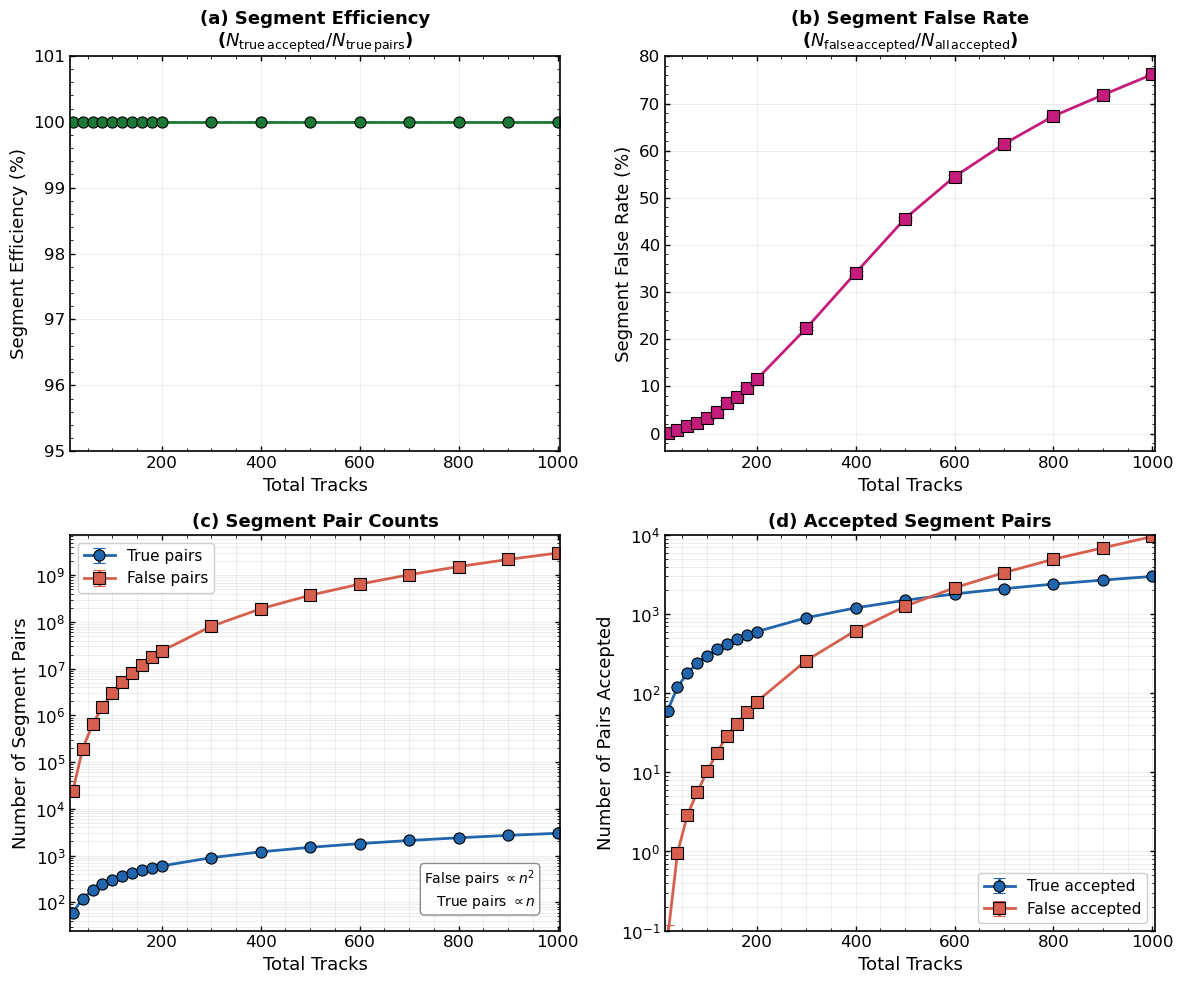


SEGMENT-LEVEL EFFICIENCY SUMMARY TABLE (per-repeat mean ± SE)
Tracks     Reps   Seg Eff          False Rate       True Pairs         False Pairs        True Acc         False Acc       
----------------------------------------------------------------------------------------------------------------------------------
20         50     100.00% ± 0.00%  0.13% ± 0.06%    60 ± 0.0           23940 ± 0.0        60 ± 0.0         0.1 ± 0.0       
40         50     100.00% ± 0.00%  0.79% ± 0.12%    120 ± 0.0          191880 ± 0.0       120 ± 0.0        1.0 ± 0.2       
60         50     100.00% ± 0.00%  1.56% ± 0.22%    180 ± 0.0          647820 ± 0.0       180 ± 0.0        2.9 ± 0.4       
80         50     100.00% ± 0.00%  2.28% ± 0.13%    240 ± 0.0          1535760 ± 0.0      240 ± 0.0        5.6 ± 0.3       
100        50     100.00% ± 0.00%  3.32% ± 0.14%    300 ± 0.0          2999700 ± 0.0      300 ± 0.0        10.3 ± 0.4      
120        10     100.00% ± 0.00%  4.66% ± 0.48%    360 ± 0.0 

: 

In [ ]:
# ============================================================================
# SEGMENT EFFICIENCY: Visualization (Paper-Ready with Error Bars)
# ============================================================================

# Paper-ready plot settings
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.titlesize': 16,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'lines.linewidth': 2,
    'lines.markersize': 8,
})

if len(segment_efficiency_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Color scheme
    color_true = '#2166ac'
    color_false = '#d6604d'
    color_eff = '#1b7837'
    color_false_rate = '#c51b7d'

    track_counts   = np.array([r['total_tracks'] for r in segment_efficiency_results])
    seg_eff        = np.array([r['seg_efficiency_mean'] * 100 for r in segment_efficiency_results])
    seg_eff_err    = np.array([r['seg_efficiency_se'] * 100 for r in segment_efficiency_results])
    false_rate     = np.array([r['seg_false_rate_mean'] * 100 for r in segment_efficiency_results])
    false_rate_err = np.array([r['seg_false_rate_se'] * 100 for r in segment_efficiency_results])
    n_true_mean    = np.array([r['n_true_mean'] for r in segment_efficiency_results])
    n_true_se      = np.array([r['n_true_se'] for r in segment_efficiency_results])
    n_false_mean   = np.array([r['n_false_mean'] for r in segment_efficiency_results])
    n_false_se     = np.array([r['n_false_se'] for r in segment_efficiency_results])
    true_acc_mean  = np.array([r['true_acc_mean'] for r in segment_efficiency_results])
    true_acc_se    = np.array([r['true_acc_se'] for r in segment_efficiency_results])
    false_acc_mean = np.array([r['false_acc_mean'] for r in segment_efficiency_results])
    false_acc_se   = np.array([r['false_acc_se'] for r in segment_efficiency_results])

    # Plot 1: Segment Efficiency with error bars
    ax1 = axes[0, 0]
    ax1.errorbar(track_counts, seg_eff, yerr=seg_eff_err,
                fmt='o-', color=color_eff, capsize=5, capthick=1.5,
                linewidth=2, markersize=8, markeredgecolor='black',
                markeredgewidth=0.8)
    ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax1.set_xlabel('Total Tracks', fontsize=13)
    ax1.set_ylabel('Segment Efficiency (%)', fontsize=13)
    ax1.set_title('(a) Segment Efficiency\n($N_{\\mathrm{true\\,accepted}} / N_{\\mathrm{true\\,pairs}}$)',
                 fontsize=13, fontweight='bold')
    ax1.set_ylim(95, 101)
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.minorticks_on()
    ax1.tick_params(which='both', direction='in', top=True, right=True)
    ax1.set_xlim(min(track_counts) - 5, max(track_counts) + 5)

    # Plot 2: False Rate with error bars (per-repeat mean ± SE)
    ax2 = axes[0, 1]
    ax2.errorbar(track_counts, false_rate, yerr=false_rate_err,
                fmt='s-', color=color_false_rate, capsize=5, capthick=1.5,
                linewidth=2, markersize=8, markeredgecolor='black',
                markeredgewidth=0.8)
    ax2.set_xlabel('Total Tracks', fontsize=13)
    ax2.set_ylabel('Segment False Rate (%)', fontsize=13)
    ax2.set_title('(b) Segment False Rate\n($N_{\\mathrm{false\\,accepted}} / N_{\\mathrm{all\\,accepted}}$)',
                 fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax2.minorticks_on()
    ax2.tick_params(which='both', direction='in', top=True, right=True)
    ax2.set_xlim(min(track_counts) - 5, max(track_counts) + 5)

    # Plot 3: Pair counts (log scale with error bars)
    ax3 = axes[1, 0]
    ax3.errorbar(track_counts, n_true_mean, yerr=n_true_se,
                fmt='o-', color=color_true, capsize=4, capthick=1.2,
                linewidth=2, markersize=8, markeredgecolor='black',
                markeredgewidth=0.8, label='True pairs')
    ax3.errorbar(track_counts, n_false_mean, yerr=n_false_se,
                fmt='s-', color=color_false, capsize=4, capthick=1.2,
                linewidth=2, markersize=8, markeredgecolor='black',
                markeredgewidth=0.8, label='False pairs')
    ax3.set_yscale('log')
    ax3.set_xlabel('Total Tracks', fontsize=13)
    ax3.set_ylabel('Number of Segment Pairs', fontsize=13)
    ax3.set_title('(c) Segment Pair Counts', fontsize=13, fontweight='bold')
    ax3.legend(loc='upper left', framealpha=0.95)
    ax3.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, which='both')
    ax3.minorticks_on()
    ax3.tick_params(which='both', direction='in', top=True, right=True)
    ax3.set_xlim(min(track_counts) - 5, max(track_counts) + 5)

    ax3.text(0.95, 0.05, 'False pairs $\\propto n^2$\nTrue pairs $\\propto n$',
            transform=ax3.transAxes, fontsize=10, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Plot 4: Accepted pairs (log scale with error bars)
    ax4 = axes[1, 1]
    false_acc_plot = np.where(false_acc_mean > 0, false_acc_mean, 0.5)
    false_acc_se_plot = np.where(false_acc_mean > 0, false_acc_se, 0)

    ax4.errorbar(track_counts, true_acc_mean, yerr=true_acc_se,
                fmt='o-', color=color_true, capsize=4, capthick=1.2,
                linewidth=2, markersize=8, markeredgecolor='black',
                markeredgewidth=0.8, label='True accepted')
    ax4.errorbar(track_counts, false_acc_plot, yerr=false_acc_se_plot,
                fmt='s-', color=color_false, capsize=4, capthick=1.2,
                linewidth=2, markersize=8, markeredgecolor='black',
                markeredgewidth=0.8, label='False accepted')
    ax4.set_yscale('log')
    ax4.set_xlabel('Total Tracks', fontsize=13)
    ax4.set_ylabel('Number of Pairs Accepted', fontsize=13)
    ax4.set_title('(d) Accepted Segment Pairs', fontsize=13, fontweight='bold')
    ax4.legend(loc='lower right', framealpha=0.95)
    ax4.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, which='both')
    ax4.minorticks_on()
    ax4.tick_params(which='both', direction='in', top=True, right=True)
    ax4.set_xlim(min(track_counts) - 5, max(track_counts) + 5)
    ax4.set_ylim(0.1, 1e4)

    plt.tight_layout()

    fig.savefig(OUT_DIR / 'fixed_epsilon_segment_efficiency.png', dpi=300,
                bbox_inches='tight', facecolor='white')
    fig.savefig(OUT_DIR / 'fixed_epsilon_segment_efficiency.pdf',
                format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
    print(f"Saved to {OUT_DIR / 'fixed_epsilon_segment_efficiency.png'}")
    print(f"Saved to {OUT_DIR / 'fixed_epsilon_segment_efficiency.pdf'}")

    plt.show()

    # Print summary table
    print("\n" + "=" * 130)
    print("SEGMENT-LEVEL EFFICIENCY SUMMARY TABLE (per-repeat mean ± SE)")
    print("=" * 130)
    print(f"{'Tracks':<10} {'Reps':<6} {'Seg Eff':<16} {'False Rate':<16} "
          f"{'True Pairs':<18} {'False Pairs':<18} {'True Acc':<16} {'False Acc':<16}")
    print("-" * 130)
    for r in segment_efficiency_results:
        eff_str = f"{r['seg_efficiency_mean']*100:.2f}% ± {r['seg_efficiency_se']*100:.2f}%"
        fr_str = f"{r['seg_false_rate_mean']*100:.2f}% ± {r['seg_false_rate_se']*100:.2f}%"
        true_p_str = f"{r['n_true_mean']:.0f} ± {r['n_true_se']:.1f}"
        false_p_str = f"{r['n_false_mean']:.0f} ± {r['n_false_se']:.1f}"
        true_a_str = f"{r['true_acc_mean']:.0f} ± {r['true_acc_se']:.1f}"
        false_a_str = f"{r['false_acc_mean']:.1f} ± {r['false_acc_se']:.1f}"
        print(f"{r['total_tracks']:<10} {r['n_repeats']:<6} {eff_str:<16} {fr_str:<16} "
              f"{true_p_str:<18} {false_p_str:<18} {true_a_str:<16} {false_a_str:<16}")

## 10b. Exact Reproduction of Old Notebook (track_density_test_local.ipynb)

Reproduces the fixed-ε experiment from the old reference notebook **exactly**, including:
- Multi-event generation (20 tracks per event, each event with its own PV)
- Old detector geometry (160 mm modules, `lx = ly = 80` half-width)
- PV sigma `{"x": 1, "y": 1, "z": 1}`
- Pairwise segment direction-vector angles (not triplet angles)
- MIP particles (mass = 0.511 MeV)

| Parameter | Value |
|-----------|-------|
| Swept | n_events (1–50 → total 20–1000 tracks) |
| Tracks per event | 20 |
| σ_scatt | 1 × 10⁻⁴ rad |
| σ_res | 0.005 mm |
| φ_min, φ_max | −0.2, +0.2 rad |
| θ_min, θ_max | default (−0.2, +0.2 rad) |
| ε mode | **Fixed = 2.0 mrad** |
| lx, ly | 80 mm (half-width → 160 mm full module) |
| PV sigma | x = 1, y = 1, z = 1 mm |
| Repeats | 50 (≤100 tracks), 10 (101–500), 5 (>500) |
| Particle | MIP, mass = 0.511, q = 1 |
| Angle method | Pairwise segment direction vectors |

In [8]:
# ============================================================================
# 10b. EXACT REPRODUCTION OF OLD NOTEBOOK (track_density_test_local.ipynb)
# ============================================================================
from lhcb_velo_toy import get_segments_from_track

# ── Old-notebook detector geometry ──
OLD_HALF_X    = 80.0              # 160 mm full module
OLD_HALF_Y    = 80.0
OLD_DZ_MM     = 33.0
OLD_Z_FIRST   = 33
OLD_N_MODULES = 5
OLD_PV_SIGMA  = {"x": 1, "y": 1, "z": 1}   # 1 mm in ALL directions

old_z_positions = [OLD_Z_FIRST + i * OLD_DZ_MM for i in range(OLD_N_MODULES)]
geo_old = PlaneGeometry(
    module_id=list(range(1, OLD_N_MODULES + 1)),
    lx=[OLD_HALF_X] * OLD_N_MODULES,
    ly=[OLD_HALF_Y] * OLD_N_MODULES,
    z=old_z_positions,
)
print(f"Old geometry: z = {old_z_positions} mm, module = {OLD_HALF_X*2}×{OLD_HALF_Y*2} mm²")
print(f"Old PV sigma: {OLD_PV_SIGMA}")

# ── Old-notebook angle computation (pairwise segment direction vectors) ──
def compute_segment_angles_old(event):
    """Compute pairwise angles between ALL segment direction vectors.

    Matches the old notebook's compute_segment_angles_from_event() exactly:
    iterate over all pairs of segments, compute the angle between their
    normalised direction vectors, classify as true (same track) or false.
    """
    all_segments = []
    segment_to_track = {}

    for track in event.tracks:
        segs = get_segments_from_track(track, event)
        for seg in segs:
            all_segments.append(seg)
            segment_to_track[id(seg)] = track.track_id

    true_angles = []
    false_angles = []

    if len(all_segments) < 2:
        return true_angles, false_angles

    for i in range(len(all_segments)):
        for j in range(i + 1, len(all_segments)):
            seg_i = all_segments[i]
            seg_j = all_segments[j]

            vec_i = np.array(seg_i.to_vect())
            vec_j = np.array(seg_j.to_vect())

            norm_i = np.linalg.norm(vec_i)
            norm_j = np.linalg.norm(vec_j)

            if norm_i == 0 or norm_j == 0:
                continue

            vec_i = vec_i / norm_i
            vec_j = vec_j / norm_j

            cos_angle = np.clip(np.dot(vec_i, vec_j), -1.0, 1.0)
            angle = np.arccos(cos_angle)

            track_i = segment_to_track.get(id(seg_i))
            track_j = segment_to_track.get(id(seg_j))

            if track_i == track_j:
                true_angles.append(angle)
            else:
                false_angles.append(angle)

    return true_angles, false_angles


def compute_segment_metrics_old(true_angles, false_angles, epsilon):
    """Compute acceptance metrics from pairwise segment angles."""
    true_arr  = np.array(true_angles)  if len(true_angles)  > 0 else np.array([])
    false_arr = np.array(false_angles) if len(false_angles) > 0 else np.array([])

    n_true  = len(true_arr)
    n_false = len(false_arr)

    true_accepted  = int(np.sum(true_arr  <= epsilon)) if n_true  > 0 else 0
    false_accepted = int(np.sum(false_arr <= epsilon)) if n_false > 0 else 0
    total_accepted = true_accepted + false_accepted

    segment_efficiency = true_accepted / n_true if n_true > 0 else 0.0
    segment_false_rate = false_accepted / total_accepted if total_accepted > 0 else 0.0

    return {
        "n_true": n_true,
        "n_false": n_false,
        "true_accepted": true_accepted,
        "false_accepted": false_accepted,
        "segment_efficiency": segment_efficiency,
        "segment_false_rate": segment_false_rate,
    }


# ── Old-notebook event generation parameters (extended to 1000 tracks) ──
OLD_TRACKS_PER_EVENT = 20
# 1–10 events (20–200), then 15,20,25,30,35,40,45,50 (300–1000)
OLD_EVENT_COUNTS = list(range(1, 11)) + [15, 20, 25, 30, 35, 40, 45, 50]

print(f"\nTrack counts: {[n * OLD_TRACKS_PER_EVENT for n in OLD_EVENT_COUNTS]}")
print(f"Epsilon threshold: {FIXED_EPSILON * 1000:.1f} mrad")
print("=" * 80)

# ── Data collection ──
import time as _time
_cache_file = CACHE_DIR / "segment_efficiency_results_oldparams.pkl"
if _cache_file.exists():
    with open(_cache_file, "rb") as f:
        seg_eff_oldparams = pickle.load(f)
    _existing_tracks = {r['total_tracks'] for r in seg_eff_oldparams}
    _needed = [n for n in OLD_EVENT_COUNTS
               if n * OLD_TRACKS_PER_EVENT not in _existing_tracks]
    if _needed:
        print(f"Loaded {len(seg_eff_oldparams)} cached entries, "
              f"need {len(_needed)} more: {[n*OLD_TRACKS_PER_EVENT for n in _needed]}")
    else:
        print(f"Loaded seg_eff_oldparams from cache: {len(seg_eff_oldparams)} entries (all done)")
        _needed = []
else:
    seg_eff_oldparams = []
    _needed = OLD_EVENT_COUNTS
    print("No cache — generating all configurations")

if _needed:
    _t0 = _time.time()
    for n_events in _needed:
        total_tracks = n_events * OLD_TRACKS_PER_EVENT
        n_particles_per_event = [OLD_TRACKS_PER_EVENT] * n_events

        # Fewer repeats for higher multiplicities (O(n²) pairwise is slow)
        if total_tracks <= 100:
            n_repeats = 50
        elif total_tracks <= 500:
            n_repeats = 10
        else:
            n_repeats = 5

        per_repeat_data = []
        _t1 = _time.time()

        for repeat in range(n_repeats):
            np.random.seed(repeat + n_events * 1000)

            seg = StateEventGenerator(
                detector_geometry=geo_old,
                phi_min=-0.2,
                phi_max=0.2,
                # theta NOT set → defaults to ±0.2
                events=n_events,
                n_particles=n_particles_per_event,
                measurement_error=float(FIXED_RESOLUTION),
                collision_noise=float(FIXED_SCATTERING),
            )

            seg.generate_random_primary_vertices(OLD_PV_SIGMA)

            event_particles = [
                [{"type": "MIP", "mass": 0.511, "q": 1}
                 for _ in range(total_tracks)]
                for _ in range(n_events)
            ]
            seg.generate_particles(event_particles)
            event = seg.generate_complete_events()

            true_angles, false_angles = compute_segment_angles_old(event)
            m = compute_segment_metrics_old(true_angles, false_angles, FIXED_EPSILON)

            per_repeat_data.append({
                'n_true': m['n_true'],
                'n_false': m['n_false'],
                'true_accepted': m['true_accepted'],
                'false_accepted': m['false_accepted'],
                'seg_efficiency': m['segment_efficiency'],
                'seg_false_rate': m['segment_false_rate'],
            })

        eff_per = np.array([r['seg_efficiency'] for r in per_repeat_data])
        fr_per  = np.array([r['seg_false_rate']  for r in per_repeat_data])
        nr = len(per_repeat_data)

        seg_eff_oldparams.append({
            'total_tracks': total_tracks,
            'n_repeats': nr,
            'seg_efficiency_mean': np.mean(eff_per),
            'seg_efficiency_se':   np.std(eff_per, ddof=1) / np.sqrt(nr),
            'seg_false_rate_mean': np.mean(fr_per),
            'seg_false_rate_se':   np.std(fr_per, ddof=1) / np.sqrt(nr),
            'n_true_mean':    np.mean([r['n_true']          for r in per_repeat_data]),
            'n_true_se':      np.std([r['n_true']           for r in per_repeat_data], ddof=1) / np.sqrt(nr),
            'n_false_mean':   np.mean([r['n_false']         for r in per_repeat_data]),
            'n_false_se':     np.std([r['n_false']          for r in per_repeat_data], ddof=1) / np.sqrt(nr),
            'true_acc_mean':  np.mean([r['true_accepted']   for r in per_repeat_data]),
            'true_acc_se':    np.std([r['true_accepted']    for r in per_repeat_data], ddof=1) / np.sqrt(nr),
            'false_acc_mean': np.mean([r['false_accepted']  for r in per_repeat_data]),
            'false_acc_se':   np.std([r['false_accepted']   for r in per_repeat_data], ddof=1) / np.sqrt(nr),
            'per_repeat': per_repeat_data,
        })

        _dt = _time.time() - _t1
        print(f"  [{total_tracks:4d} tracks, {n_events:2d} events, {nr:2d} repeats]  "
              f"eff={np.mean(eff_per)*100:.2f}%  fr={np.mean(fr_per)*100:.2f}%  "
              f"({_dt:.1f}s)")

    # Sort by total_tracks before saving
    seg_eff_oldparams.sort(key=lambda r: r['total_tracks'])

    with open(_cache_file, "wb") as f:
        pickle.dump(seg_eff_oldparams, f)
    print(f"\n{'='*80}")
    print(f"Done & saved ({_time.time()-_t0:.0f}s total, {len(seg_eff_oldparams)} configs)")
    print(f"{'='*80}")

Old geometry: z = [33.0, 66.0, 99.0, 132.0, 165.0] mm, module = 160.0×160.0 mm²
Old PV sigma: {'x': 1, 'y': 1, 'z': 1}

Track counts: [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 300, 400, 500, 600, 700, 800, 900, 1000]


NameError: name 'FIXED_EPSILON' is not defined

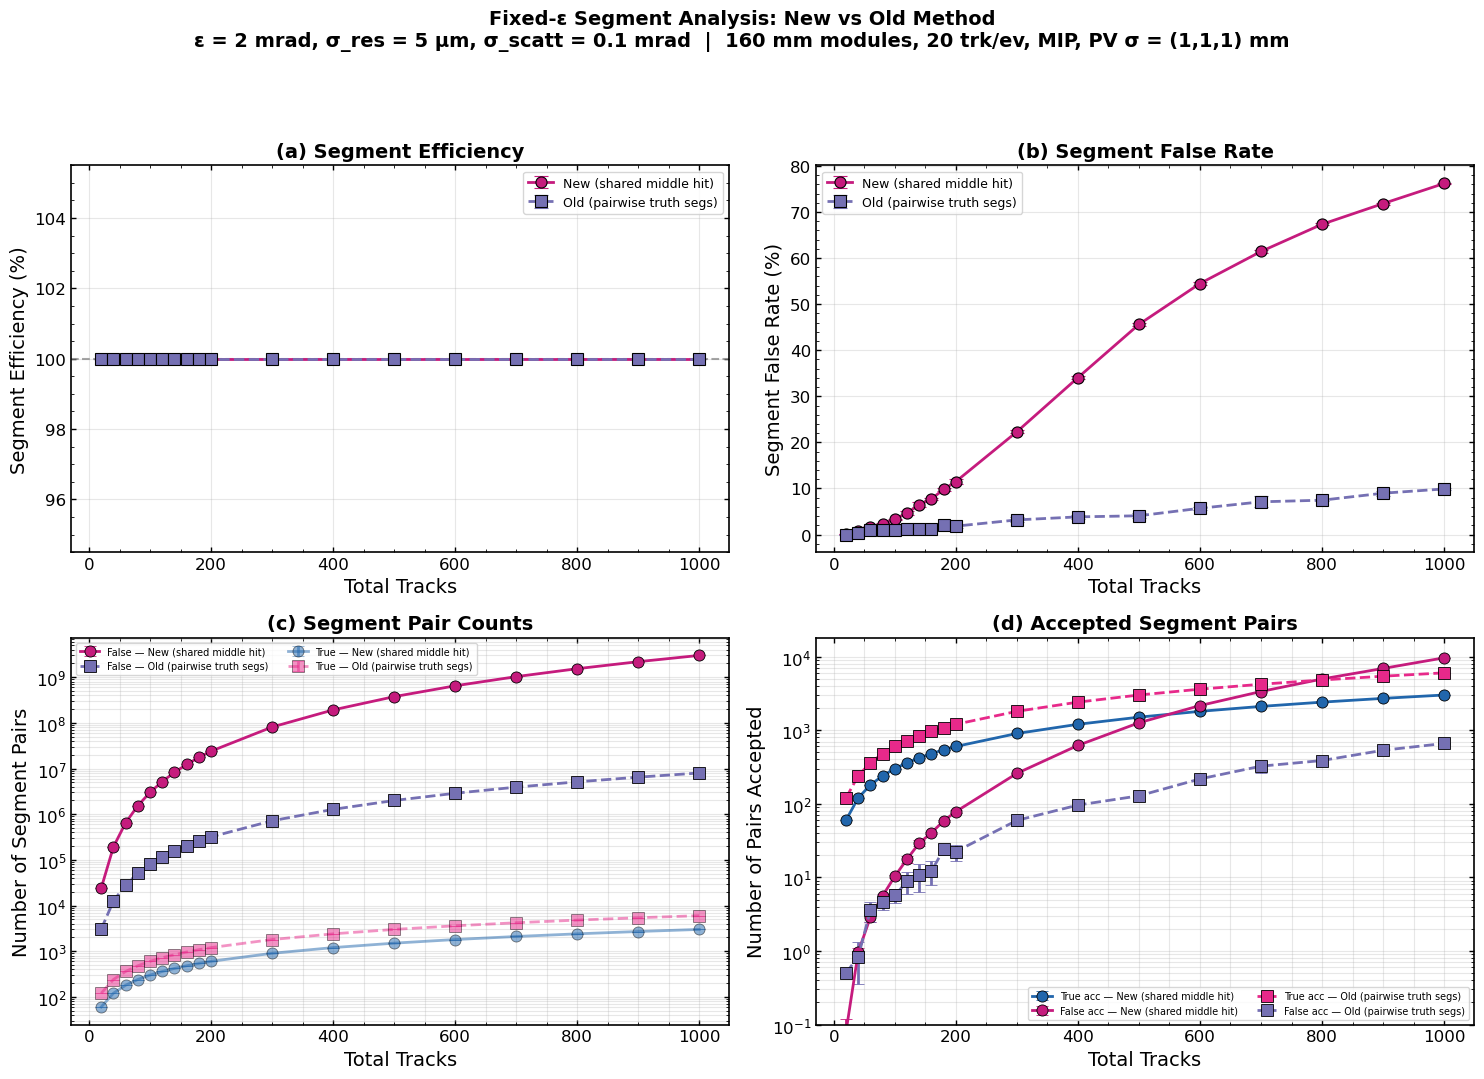


COMPARISON: New (shared middle hit) vs Old (pairwise truth segments)
Tracks   FR (New)         FR (Old)         Eff (New)      Eff (Old)     
------------------------------------------------------------------------------------------
20         0.13%            0.00%          100.00%       100.00%
40         0.79%            0.33%          100.00%       100.00%
60         1.56%            0.94%          100.00%       100.00%
80         2.28%            0.93%          100.00%       100.00%
100        3.32%            0.92%          100.00%       100.00%
120        4.66%            1.19%          100.00%       100.00%
140        6.47%            1.25%          100.00%       100.00%
160        7.74%            1.24%          100.00%       100.00%
180        9.78%            2.15%          100.00%       100.00%
200       11.49%            1.81%          100.00%       100.00%
300       22.31%            3.17%          100.00%       100.00%
400       34.06%            3.83%          100.00% 

: 

In [ ]:
# ============================================================================
# 10 vs 10b: COMPARISON PLOT — New (shared middle hit) vs Old (pairwise truth)
# ============================================================================
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 10,
    'figure.titlesize': 16, 'axes.linewidth': 1.2,
    'lines.linewidth': 2, 'lines.markersize': 8,
})

if len(segment_efficiency_results) > 0 and len(seg_eff_oldparams) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle('Fixed-ε Segment Analysis: New vs Old Method\n'
                 'ε = 2 mrad, σ_res = 5 µm, σ_scatt = 0.1 mrad  |  '
                 '160 mm modules, 20 trk/ev, MIP, PV σ = (1,1,1) mm',
                 fontsize=14, fontweight='bold')

    def _extract(results):
        tc  = np.array([r['total_tracks'] for r in results])
        eff = np.array([r['seg_efficiency_mean'] * 100 for r in results])
        effe= np.array([r['seg_efficiency_se'] * 100 for r in results])
        fr  = np.array([r['seg_false_rate_mean'] * 100 for r in results])
        fre = np.array([r['seg_false_rate_se'] * 100 for r in results])
        ntm = np.array([r['n_true_mean'] for r in results])
        nts = np.array([r['n_true_se'] for r in results])
        nfm = np.array([r['n_false_mean'] for r in results])
        nfs = np.array([r['n_false_se'] for r in results])
        tam = np.array([r['true_acc_mean'] for r in results])
        tas = np.array([r['true_acc_se'] for r in results])
        fam = np.array([r['false_acc_mean'] for r in results])
        fas = np.array([r['false_acc_se'] for r in results])
        return tc, eff, effe, fr, fre, ntm, nts, nfm, nfs, tam, tas, fam, fas

    new = _extract(segment_efficiency_results)
    old = _extract(seg_eff_oldparams)

    c_new   = '#c51b7d'  # magenta — new (triplet / shared middle hit)
    c_old   = '#7570b3'  # lilac  — old (pairwise truth)
    c_new_t = '#2166ac'
    c_old_t = '#e7298a'

    lbl_new = 'New (shared middle hit)'
    lbl_old = 'Old (pairwise truth segs)'

    # ── (a) Segment Efficiency ──
    ax = axes[0, 0]
    ax.errorbar(new[0], new[1], yerr=new[2], fmt='o-',  color=c_new, capsize=5,
                capthick=1.5, markeredgecolor='black', markeredgewidth=0.8, label=lbl_new)
    ax.errorbar(old[0], old[1], yerr=old[2], fmt='s--', color=c_old, capsize=5,
                capthick=1.5, markeredgecolor='black', markeredgewidth=0.8, label=lbl_old)
    ax.axhline(100, color='gray', ls='--', lw=1.5, alpha=0.7)
    ax.set_xlabel('Total Tracks')
    ax.set_ylabel('Segment Efficiency (%)')
    ax.set_title('(a) Segment Efficiency', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

    # ── (b) False Rate ──
    ax = axes[0, 1]
    ax.errorbar(new[0], new[3], yerr=new[4], fmt='o-',  color=c_new, capsize=5,
                capthick=1.5, markeredgecolor='black', markeredgewidth=0.8, label=lbl_new)
    ax.errorbar(old[0], old[3], yerr=old[4], fmt='s--', color=c_old, capsize=5,
                capthick=1.5, markeredgecolor='black', markeredgewidth=0.8, label=lbl_old)
    ax.set_xlabel('Total Tracks')
    ax.set_ylabel('Segment False Rate (%)')
    ax.set_title('(b) Segment False Rate', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

    # ── (c) Segment Pair Counts (false) ──
    ax = axes[1, 0]
    ax.errorbar(new[0], new[7], yerr=new[8], fmt='o-', color=c_new, capsize=4,
                capthick=1.2, markeredgecolor='black', markeredgewidth=0.6,
                label=f'False — {lbl_new}')
    ax.errorbar(old[0], old[7], yerr=old[8], fmt='s--', color=c_old, capsize=4,
                capthick=1.2, markeredgecolor='black', markeredgewidth=0.6,
                label=f'False — {lbl_old}')
    ax.errorbar(new[0], new[5], yerr=new[6], fmt='o-', color=c_new_t, capsize=4,
                capthick=1.2, markeredgecolor='black', markeredgewidth=0.6, alpha=0.5,
                label=f'True — {lbl_new}')
    ax.errorbar(old[0], old[5], yerr=old[6], fmt='s--', color=c_old_t, capsize=4,
                capthick=1.2, markeredgecolor='black', markeredgewidth=0.6, alpha=0.5,
                label=f'True — {lbl_old}')
    ax.set_yscale('log')
    ax.set_xlabel('Total Tracks')
    ax.set_ylabel('Number of Segment Pairs')
    ax.set_title('(c) Segment Pair Counts', fontweight='bold')
    ax.legend(fontsize=7, loc='upper left', ncol=2)
    ax.grid(True, alpha=0.3, which='both')
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

    # ── (d) Accepted Pairs ──
    ax = axes[1, 1]
    ax.errorbar(new[0], new[9], yerr=new[10], fmt='o-', color=c_new_t, capsize=4,
                capthick=1.2, markeredgecolor='black', markeredgewidth=0.6,
                label=f'True acc — {lbl_new}')
    fa_new = np.where(new[11] > 0, new[11], 0.5)
    ax.errorbar(new[0], fa_new, yerr=np.where(new[11] > 0, new[12], 0), fmt='o-',
                color=c_new, capsize=4, capthick=1.2, markeredgecolor='black',
                markeredgewidth=0.6, label=f'False acc — {lbl_new}')
    ax.errorbar(old[0], old[9], yerr=old[10], fmt='s--', color=c_old_t, capsize=4,
                capthick=1.2, markeredgecolor='black', markeredgewidth=0.6,
                label=f'True acc — {lbl_old}')
    fa_old = np.where(old[11] > 0, old[11], 0.5)
    ax.errorbar(old[0], fa_old, yerr=np.where(old[11] > 0, old[12], 0), fmt='s--',
                color=c_old, capsize=4, capthick=1.2, markeredgecolor='black',
                markeredgewidth=0.6, label=f'False acc — {lbl_old}')
    ax.set_yscale('log')
    ax.set_xlabel('Total Tracks')
    ax.set_ylabel('Number of Pairs Accepted')
    ax.set_title('(d) Accepted Segment Pairs', fontweight='bold')
    ax.legend(fontsize=7, loc='lower right', ncol=2)
    ax.grid(True, alpha=0.3, which='both')
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.set_ylim(0.1, None)

    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(OUT_DIR / 'fixed_epsilon_comparison_new_vs_old.png', dpi=300,
                bbox_inches='tight', facecolor='white')
    fig.savefig(OUT_DIR / 'fixed_epsilon_comparison_new_vs_old.pdf',
                bbox_inches='tight', facecolor='white')
    plt.show()

    # ── Difference table ──
    print("\n" + "=" * 90)
    print("COMPARISON: New (shared middle hit) vs Old (pairwise truth segments)")
    print("=" * 90)
    print(f"{'Tracks':<8} {'FR (New)':<16} {'FR (Old)':<16} "
          f"{'Eff (New)':<14} {'Eff (Old)':<14}")
    print("-" * 90)
    for rn in segment_efficiency_results:
        tc = rn['total_tracks']
        m_old = [ro for ro in seg_eff_oldparams if ro['total_tracks'] == tc]
        fn = rn['seg_false_rate_mean'] * 100
        en = rn['seg_efficiency_mean'] * 100
        fo = m_old[0]['seg_false_rate_mean'] * 100 if m_old else float('nan')
        eo = m_old[0]['seg_efficiency_mean'] * 100 if m_old else float('nan')
        print(f"{tc:<8} {fn:6.2f}%          {fo:6.2f}%          "
              f"{en:6.2f}%       {eo:6.2f}%")

In [ ]:
# ============================================================================
# Parameter comparison table — New vs Old segment metrics
# ============================================================================
import pandas as pd

params = [
    ("Angle method",        "Triplet kink (shared middle hit)",  "Pairwise segment direction vectors"),
    ("ε threshold",         f"{FIXED_EPSILON*1000:.1f} mrad",    f"{FIXED_EPSILON*1000:.1f} mrad"),
    ("σ_res",               f"{FIXED_RESOLUTION} mm",            f"{FIXED_RESOLUTION} mm"),
    ("σ_scatt",             f"{FIXED_SCATTERING} rad",           f"{FIXED_SCATTERING} rad"),
    ("Module half-width",   f"{_NEW_HALF} mm → {_NEW_HALF*2} mm full",
                            f"{OLD_HALF_X} mm → {OLD_HALF_X*2} mm full"),
    ("N modules",           str(N_MODULES),                      str(OLD_N_MODULES)),
    ("z positions (mm)",    str(z_positions),                     str(old_z_positions)),
    ("PV sigma (mm)",       str(NEW_PV_SIGMA),                   str(OLD_PV_SIGMA)),
    ("Tracks per event",    str(TRACKS_PER_EVENT),               str(OLD_TRACKS_PER_EVENT)),
    ("φ range (rad)",       "−0.2 to +0.2",                     "−0.2 to +0.2"),
    ("θ range (rad)",       "default (−0.2 to +0.2)",           "default (−0.2 to +0.2)"),
    ("Particle type",       "MIP, mass=0.511, q=1",              "MIP, mass=0.511, q=1"),
    ("Repeats",             "50 (≤100T), 10 (101–500T), 5 (>500T)",
                            "50 (≤100T), 10 (101–500T), 5 (>500T)"),
    ("Track count range",   f"{FIXED_TRACK_COUNTS[0]}–{FIXED_TRACK_COUNTS[-1]}",
                            f"{OLD_EVENT_COUNTS[0]*OLD_TRACKS_PER_EVENT}–{OLD_EVENT_COUNTS[-1]*OLD_TRACKS_PER_EVENT}"),
    ("Segment truth def",   "Both segments on same track, share middle hit",
                            "Both segments from same track (truth-only pool)"),
    ("False pair scaling",  "O(T³)",                             "O(T²)"),
]

df = pd.DataFrame(params, columns=["Parameter", "New (§10)", "Old (§10b)"])

# Check which parameters match
match_col = []
for _, new_val, old_val in params:
    match_col.append("✓" if new_val == old_val else "✗ DIFFERS")
df["Match?"] = match_col

print("=" * 100)
print("PARAMETER COMPARISON: New (§10) vs Old (§10b)")
print("=" * 100)

def highlight_diff(row):
    # if row["Match?"] == "✗ DIFFERS":
    #     return ['background-color: #fff3cd'] * len(row)
    return [''] * len(row)

styled = df.style.apply(highlight_diff, axis=1).set_properties(**{
    'text-align': 'left', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('font-weight', 'bold')]},
])
display(styled)

PARAMETER COMPARISON: New (§10) vs Old (§10b)


,Parameter,New (§10),Old (§10b),Match?
0,Angle method,Triplet kink (shared middle hit),Pairwise segment direction vectors,✗ DIFFERS
1,ε threshold,2.0 mrad,2.0 mrad,✓
2,σ_res,0.005 mm,0.005 mm,✓
3,σ_scatt,0.0001 rad,0.0001 rad,✓
4,Module half-width,80.0 mm → 160.0 mm full,80.0 mm → 160.0 mm full,✓
5,N modules,5,5,✓
6,z positions (mm),"[33.0, 66.0, 99.0, 132.0, 165.0]","[33.0, 66.0, 99.0, 132.0, 165.0]",✓
7,PV sigma (mm),"{'x': 1, 'y': 1, 'z': 1}","{'x': 1, 'y': 1, 'z': 1}",✓
8,Tracks per event,20,20,✓
9,φ range (rad),−0.2 to +0.2,−0.2 to +0.2,✓


: 

### 10c. Power-Law Fits — Verifying $O(T^3)$ vs $O(T^2)$ Scaling

The **new** method (shared middle hit) enumerates all hit triplets on 3 consecutive
modules → $\sim T^3$ false pairs. The **old** method (pairwise truth segments) pairs
truth-track segments → $\sim T^2$ false pairs.

Fitting $N_\text{false} = a \, T^b$ should yield $b \approx 3$ for new and $b \approx 2$
for old. The number of **accepted** false pairs (passing the $\varepsilon$ cut) should
inherit the same exponent if the acceptance probability per false pair is roughly constant
with track multiplicity.

POWER-LAW FITS:  y = a · T^b

── False Pair COUNTS (total enumerated) ──
  New (shared mid hit): N_false                  a = 2.9999e+00 ± 3.45e-08,  b = 3.0000 ± 0.0000
  Old (pairwise truth): N_false                  a = 7.9041e+00 ± 2.05e-05,  b = 2.0016 ± 0.0000

── False Pair ACCEPTED (passing ε cut) ──
  New (shared mid hit): N_false_accepted         a = 1.1740e-05 ± 6.16e-07,  b = 2.9705 ± 0.0080
  Old (pairwise truth): N_false_accepted         a = 4.5762e-04 ± 1.29e-04,  b = 2.0481 ± 0.0424

── True Pair COUNTS ──
  New (shared mid hit): N_true                   a = 3.0000e+00 ± 7.77e-03,  b = 1.0000 ± 0.0004
  Old (pairwise truth): N_true                   a = 6.0000e+00 ± 7.77e-03,  b = 1.0000 ± 0.0002

── True Pair ACCEPTED ──
  New (shared mid hit): N_true_accepted          a = 3.0000e+00 ± 7.77e-03,  b = 1.0000 ± 0.0004
  Old (pairwise truth): N_true_accepted          a = 6.0000e+00 ± 7.77e-03,  b = 1.0000 ± 0.0002

Quantity                            New (shared mid)     

/tmp/ipykernel_535973/2604545249.py:7: RuntimeWarning: overflow encountered in power
  return a * T**b


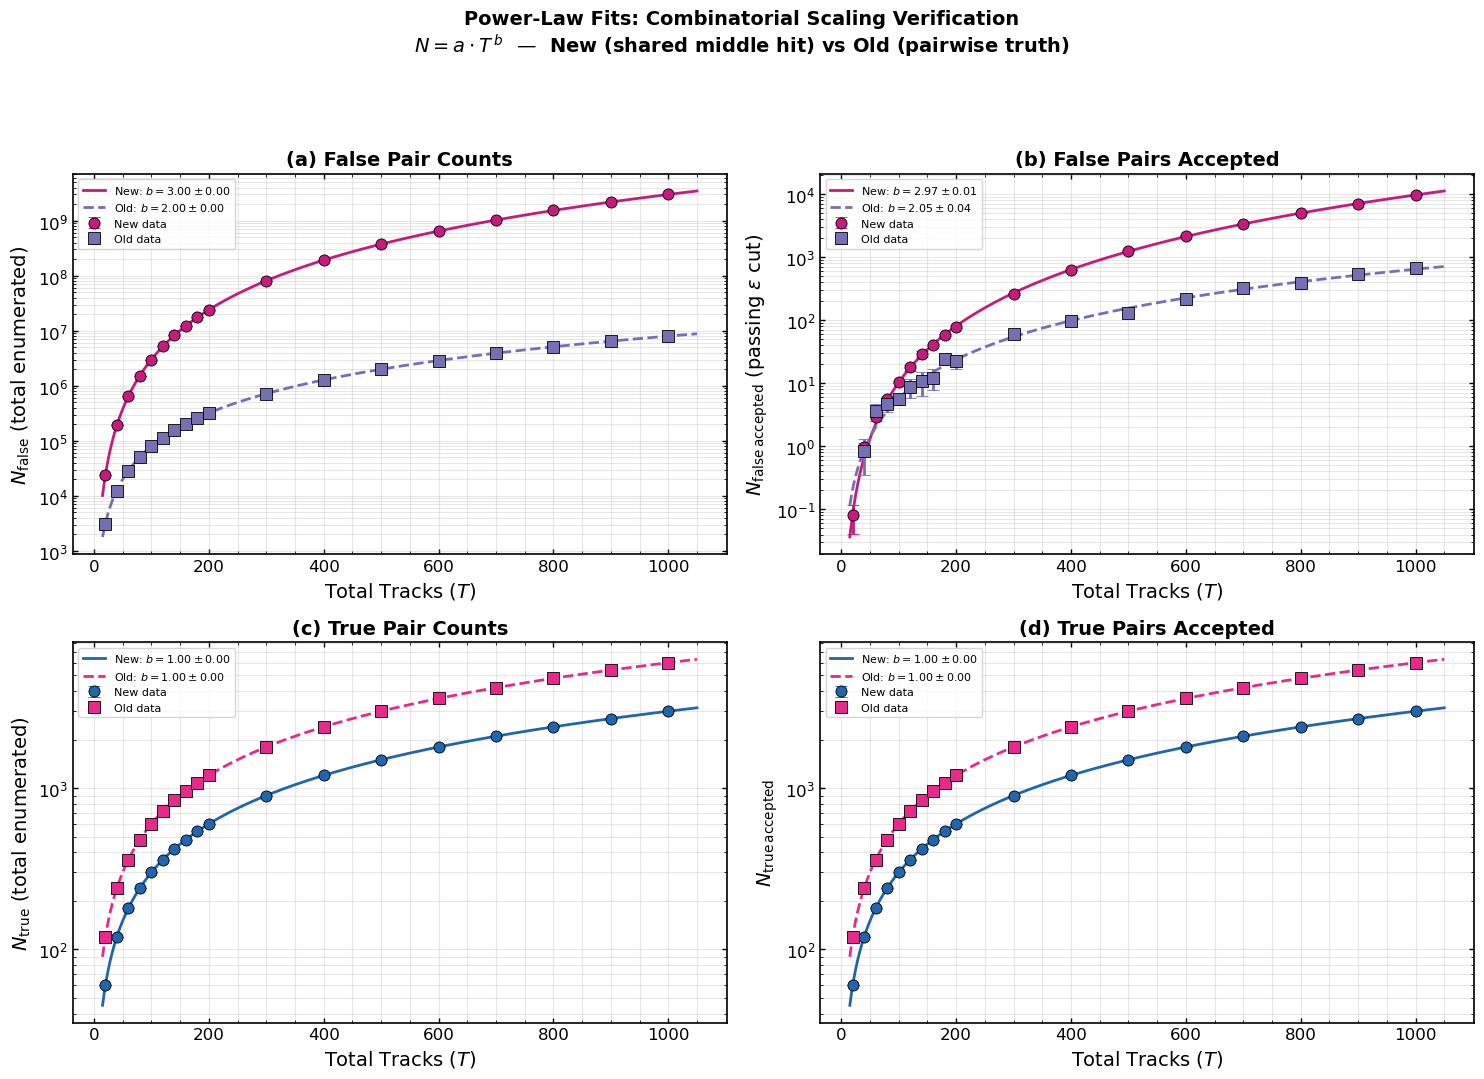

: 

In [ ]:
# ============================================================================
# 10c. Power-law fits: N_false ~ a·T^b  and  N_false_accepted ~ a·T^b
# ============================================================================
from scipy.optimize import curve_fit

def power_law(T, a, b):
    return a * T**b

def _extract_for_fit(results):
    tc  = np.array([r['total_tracks'] for r in results], dtype=float)
    nfm = np.array([r['n_false_mean'] for r in results], dtype=float)
    nfs = np.array([r['n_false_se'] for r in results], dtype=float)
    fam = np.array([r['false_acc_mean'] for r in results], dtype=float)
    fas = np.array([r['false_acc_se'] for r in results], dtype=float)
    ntm = np.array([r['n_true_mean'] for r in results], dtype=float)
    nts = np.array([r['n_true_se'] for r in results], dtype=float)
    tam = np.array([r['true_acc_mean'] for r in results], dtype=float)
    tas = np.array([r['true_acc_se'] for r in results], dtype=float)
    return tc, nfm, nfs, fam, fas, ntm, nts, tam, tas

new_tc, new_nf, new_nfs, new_fa, new_fas, new_nt, new_nts, new_ta, new_tas = \
    _extract_for_fit(segment_efficiency_results)
old_tc, old_nf, old_nfs, old_fa, old_fas, old_nt, old_nts, old_ta, old_tas = \
    _extract_for_fit(seg_eff_oldparams)

def _fit(tc, y, ys, label):
    mask = y > 0
    tc_f, y_f, ys_f = tc[mask], y[mask], ys[mask]
    sig = np.where(ys_f > 0, ys_f, 1.0)
    popt, pcov = curve_fit(power_law, tc_f, y_f, p0=[1.0, 2.0], sigma=sig,
                           absolute_sigma=True, maxfev=10000)
    perr = np.sqrt(np.diag(pcov))
    print(f"  {label:<45s}  a = {popt[0]:.4e} ± {perr[0]:.2e},  "
          f"b = {popt[1]:.4f} ± {perr[1]:.4f}")
    return popt, perr, tc_f, y_f

print("=" * 100)
print("POWER-LAW FITS:  y = a · T^b")
print("=" * 100)
print()
print("── False Pair COUNTS (total enumerated) ──")
fit_new_nf = _fit(new_tc, new_nf, new_nfs, "New (shared mid hit): N_false")
fit_old_nf = _fit(old_tc, old_nf, old_nfs, "Old (pairwise truth): N_false")
print()
print("── False Pair ACCEPTED (passing ε cut) ──")
fit_new_fa = _fit(new_tc, new_fa, new_fas, "New (shared mid hit): N_false_accepted")
fit_old_fa = _fit(old_tc, old_fa, old_fas, "Old (pairwise truth): N_false_accepted")
print()
print("── True Pair COUNTS ──")
fit_new_nt = _fit(new_tc, new_nt, new_nts, "New (shared mid hit): N_true")
fit_old_nt = _fit(old_tc, old_nt, old_nts, "Old (pairwise truth): N_true")
print()
print("── True Pair ACCEPTED ──")
fit_new_ta = _fit(new_tc, new_ta, new_tas, "New (shared mid hit): N_true_accepted")
fit_old_ta = _fit(old_tc, old_ta, old_tas, "Old (pairwise truth): N_true_accepted")

# ── Summary table ──
print()
print("=" * 90)
print(f"{'Quantity':<35s} {'New (shared mid)':<22s} {'Old (pair truth)':<22s} {'Expected':<15s}")
print("-" * 90)
rows = [
    ("N_false (total)",  fit_new_nf,  fit_old_nf,  "3 / 2"),
    ("N_false_accepted", fit_new_fa,  fit_old_fa,  "~3 / ~2"),
    ("N_true (total)",   fit_new_nt,  fit_old_nt,  "1 / 1"),
    ("N_true_accepted",  fit_new_ta,  fit_old_ta,  "1 / 1"),
]
for label, fn, fo, expected in rows:
    print(f"{label:<35s} {fn[0][1]:.3f} ± {fn[1][1]:.3f}         "
          f"{fo[0][1]:.3f} ± {fo[1][1]:.3f}         {expected}")
print("=" * 90)

# ── Plot with fits overlaid ──
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Power-Law Fits: Combinatorial Scaling Verification\n'
             r'$N = a \cdot T^{\,b}$  —  New (shared middle hit) vs Old (pairwise truth)',
             fontsize=14, fontweight='bold')

T_smooth = np.linspace(15, 1050, 300)

c_new   = '#c51b7d'
c_old   = '#7570b3'
c_new_t = '#2166ac'
c_old_t = '#e7298a'

# (a) False pair counts
ax = axes[0, 0]
ax.errorbar(new_tc, new_nf, yerr=new_nfs, fmt='o', color=c_new, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='New data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_new_nf[0]), '-', color=c_new, lw=2,
        label=f'New: $b = {fit_new_nf[0][1]:.2f} \\pm {fit_new_nf[1][1]:.2f}$')
ax.errorbar(old_tc, old_nf, yerr=old_nfs, fmt='s', color=c_old, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='Old data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_old_nf[0]), '--', color=c_old, lw=2,
        label=f'Old: $b = {fit_old_nf[0][1]:.2f} \\pm {fit_old_nf[1][1]:.2f}$')
ax.set_yscale('log')
ax.set_xlabel('Total Tracks ($T$)')
ax.set_ylabel('$N_\\mathrm{false}$ (total enumerated)')
ax.set_title('(a) False Pair Counts', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

# (b) False accepted
ax = axes[0, 1]
ax.errorbar(new_tc, new_fa, yerr=new_fas, fmt='o', color=c_new, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='New data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_new_fa[0]), '-', color=c_new, lw=2,
        label=f'New: $b = {fit_new_fa[0][1]:.2f} \\pm {fit_new_fa[1][1]:.2f}$')
ax.errorbar(old_tc, old_fa, yerr=old_fas, fmt='s', color=c_old, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='Old data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_old_fa[0]), '--', color=c_old, lw=2,
        label=f'Old: $b = {fit_old_fa[0][1]:.2f} \\pm {fit_old_fa[1][1]:.2f}$')
ax.set_yscale('log')
ax.set_xlabel('Total Tracks ($T$)')
ax.set_ylabel('$N_\\mathrm{false\\,accepted}$ (passing $\\varepsilon$ cut)')
ax.set_title('(b) False Pairs Accepted', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

# (c) True pair counts
ax = axes[1, 0]
ax.errorbar(new_tc, new_nt, yerr=new_nts, fmt='o', color=c_new_t, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='New data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_new_nt[0]), '-', color=c_new_t, lw=2,
        label=f'New: $b = {fit_new_nt[0][1]:.2f} \\pm {fit_new_nt[1][1]:.2f}$')
ax.errorbar(old_tc, old_nt, yerr=old_nts, fmt='s', color=c_old_t, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='Old data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_old_nt[0]), '--', color=c_old_t, lw=2,
        label=f'Old: $b = {fit_old_nt[0][1]:.2f} \\pm {fit_old_nt[1][1]:.2f}$')
ax.set_yscale('log')
ax.set_xlabel('Total Tracks ($T$)')
ax.set_ylabel('$N_\\mathrm{true}$ (total enumerated)')
ax.set_title('(c) True Pair Counts', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

# (d) True accepted
ax = axes[1, 1]
ax.errorbar(new_tc, new_ta, yerr=new_tas, fmt='o', color=c_new_t, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='New data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_new_ta[0]), '-', color=c_new_t, lw=2,
        label=f'New: $b = {fit_new_ta[0][1]:.2f} \\pm {fit_new_ta[1][1]:.2f}$')
ax.errorbar(old_tc, old_ta, yerr=old_tas, fmt='s', color=c_old_t, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='Old data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_old_ta[0]), '--', color=c_old_t, lw=2,
        label=f'Old: $b = {fit_old_ta[0][1]:.2f} \\pm {fit_old_ta[1][1]:.2f}$')
ax.set_yscale('log')
ax.set_xlabel('Total Tracks ($T$)')
ax.set_ylabel('$N_\\mathrm{true\\,accepted}$')
ax.set_title('(d) True Pairs Accepted', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(OUT_DIR / 'scaling_power_law_fits_new_vs_old.png', dpi=300,
            bbox_inches='tight', facecolor='white')
fig.savefig(OUT_DIR / 'scaling_power_law_fits_new_vs_old.pdf',
            bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# ============================================================================
# Parameter comparison table — Power-law fits (New vs Old)
# ============================================================================
params_pl = [
    ("Angle method",        "Triplet kink (shared middle hit)",  "Pairwise segment direction vectors"),
    ("ε threshold",         f"{FIXED_EPSILON*1000:.1f} mrad",    f"{FIXED_EPSILON*1000:.1f} mrad"),
    ("σ_res",               f"{FIXED_RESOLUTION} mm",            f"{FIXED_RESOLUTION} mm"),
    ("σ_scatt",             f"{FIXED_SCATTERING} rad",           f"{FIXED_SCATTERING} rad"),
    ("Module half-width",   f"{_NEW_HALF} mm → {_NEW_HALF*2} mm full",
                            f"{OLD_HALF_X} mm → {OLD_HALF_X*2} mm full"),
    ("N modules",           str(N_MODULES),                      str(OLD_N_MODULES)),
    ("z positions (mm)",    str(z_positions),                     str(old_z_positions)),
    ("PV sigma (mm)",       str(NEW_PV_SIGMA),                   str(OLD_PV_SIGMA)),
    ("Tracks per event",    str(TRACKS_PER_EVENT),               str(OLD_TRACKS_PER_EVENT)),
    ("φ range (rad)",       "−0.2 to +0.2",                     "−0.2 to +0.2"),
    ("θ range (rad)",       "default (−0.2 to +0.2)",           "default (−0.2 to +0.2)"),
    ("Particle type",       "MIP, mass=0.511, q=1",              "MIP, mass=0.511, q=1"),
    ("Track count range",   f"{FIXED_TRACK_COUNTS[0]}–{FIXED_TRACK_COUNTS[-1]}",
                            f"{OLD_EVENT_COUNTS[0]*OLD_TRACKS_PER_EVENT}–{OLD_EVENT_COUNTS[-1]*OLD_TRACKS_PER_EVENT}"),
    ("Segment truth def",   "Both segments on same track, share middle hit",
                            "Both segments from same track (truth-only pool)"),
    ("False pair scaling",  "O(T³)",                             "O(T²)"),
]

df_pl = pd.DataFrame(params_pl, columns=["Parameter", "New (§10)", "Old (§10b)"])
match_pl = []
for _, nv, ov in params_pl:
    match_pl.append("✓" if nv == ov else "✗ DIFFERS")
df_pl["Match?"] = match_pl

print("=" * 100)
print("PARAMETER COMPARISON: Power-law fits — New (§10) vs Old (§10b)")
print("=" * 100)

styled_pl = df_pl.style.apply(highlight_diff, axis=1).set_properties(**{
    'text-align': 'left', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('font-weight', 'bold')]},
])
display(styled_pl)

PARAMETER COMPARISON: Power-law fits — New (§10) vs Old (§10b)


,Parameter,New (§10),Old (§10b),Match?
0,Angle method,Triplet kink (shared middle hit),Pairwise segment direction vectors,✗ DIFFERS
1,ε threshold,2.0 mrad,2.0 mrad,✓
2,σ_res,0.005 mm,0.005 mm,✓
3,σ_scatt,0.0001 rad,0.0001 rad,✓
4,Module half-width,80.0 mm → 160.0 mm full,80.0 mm → 160.0 mm full,✓
5,N modules,5,5,✓
6,z positions (mm),"[33.0, 66.0, 99.0, 132.0, 165.0]","[33.0, 66.0, 99.0, 132.0, 165.0]",✓
7,PV sigma (mm),"{'x': 1, 'y': 1, 'z': 1}","{'x': 1, 'y': 1, 'z': 1}",✓
8,Tracks per event,20,20,✓
9,φ range (rad),−0.2 to +0.2,−0.2 to +0.2,✓


: 

## 11. Zero-Noise Benchmark: Dense vs Non-Dense

Ideal case with zero scattering and zero resolution error. At zero noise, ε reduces to √2·θ_min.

| Parameter | Value |
|-----------|-------|
| Swept | n_tracks × regime |
| n_tracks | 5–100 (step 5) |
| σ_scatt | ≈ 0 (1 × 10⁻⁸ rad) |
| σ_res | 0.0 mm |
| Dense (φ_max) | 0.02 rad |
| Non-dense (φ_max) | 0.2 rad |
| ε mode | **Formula** (≈ √2·θ_min ≈ 0.064 mrad) |
| Repeats per point | 20 |

In [ ]:
# ============================================================================
# ZERO-NOISE BENCHMARK: Dense vs Non-Dense
# ============================================================================
ZERO_TRACK_COUNTS = list(range(5, 105, 5))
ZERO_N_REPEATS    = 20
ZERO_SIGMA_RES    = 0.0
ZERO_SIGMA_SCATT  = 1e-8   # effectively zero (generator needs non-zero)
ZERO_CONE_SETTINGS = {
    "dense": 0.02,
    "non_dense":     0.2,
}

epsilon_zero = compute_epsilon(ZERO_SIGMA_RES, ZERO_SIGMA_SCATT)
print(f"Zero-noise ε = {epsilon_zero*1e3:.4f} mrad  (≈ √2 · θ_min)")
print(f"Track counts: {ZERO_TRACK_COUNTS[0]}–{ZERO_TRACK_COUNTS[-1]}, "
      f"{ZERO_N_REPEATS} repeats/point")

_cache_file = CACHE_DIR / "df_zero_noise.csv"
if _cache_file.exists():
    df_zero = pd.read_csv(_cache_file)
    print(f"Loaded df_zero from cache: {len(df_zero)} rows")
else:
    rows = []
    for label, phi_max in ZERO_CONE_SETTINGS.items():
        print(f"\n── {label} (φ_max = {phi_max}) ──")
        for n_trk in ZERO_TRACK_COUNTS:
            for rep in range(ZERO_N_REPEATS):
                np.random.seed(rep + n_trk * 100 + hash(label) % 10**6)
                event = safe_generate(n_trk, measurement_error=ZERO_SIGMA_RES,
                                      collision_noise=ZERO_SIGMA_SCATT,
                                      phi_max=phi_max, theta_max=phi_max)
                m = fast_segment_metrics(event, epsilon_zero)
                rows.append({
                    "regime": label,
                    "phi_max": phi_max,
                    "n_tracks": n_trk,
                    "repeat": rep,
                    "epsilon": epsilon_zero,
                    "n_true": m["n_true"],
                    "n_false": m["n_false"],
                    "true_accepted": m["true_accepted"],
                    "false_accepted": m["false_accepted"],
                    "seg_efficiency": m["segment_efficiency"],
                    "seg_false_rate": m["segment_false_rate"],
                })
            print(f"  n_tracks={n_trk:3d}  done")

    df_zero = pd.DataFrame(rows)
    df_zero.to_csv(_cache_file, index=False)
    print(f"\n{len(df_zero)} rows collected & saved")

Zero-noise ε = 0.0212 mrad  (≈ √2 · θ_min)
Track counts: 5–100, 20 repeats/point
Loaded df_zero from cache: 800 rows


: 

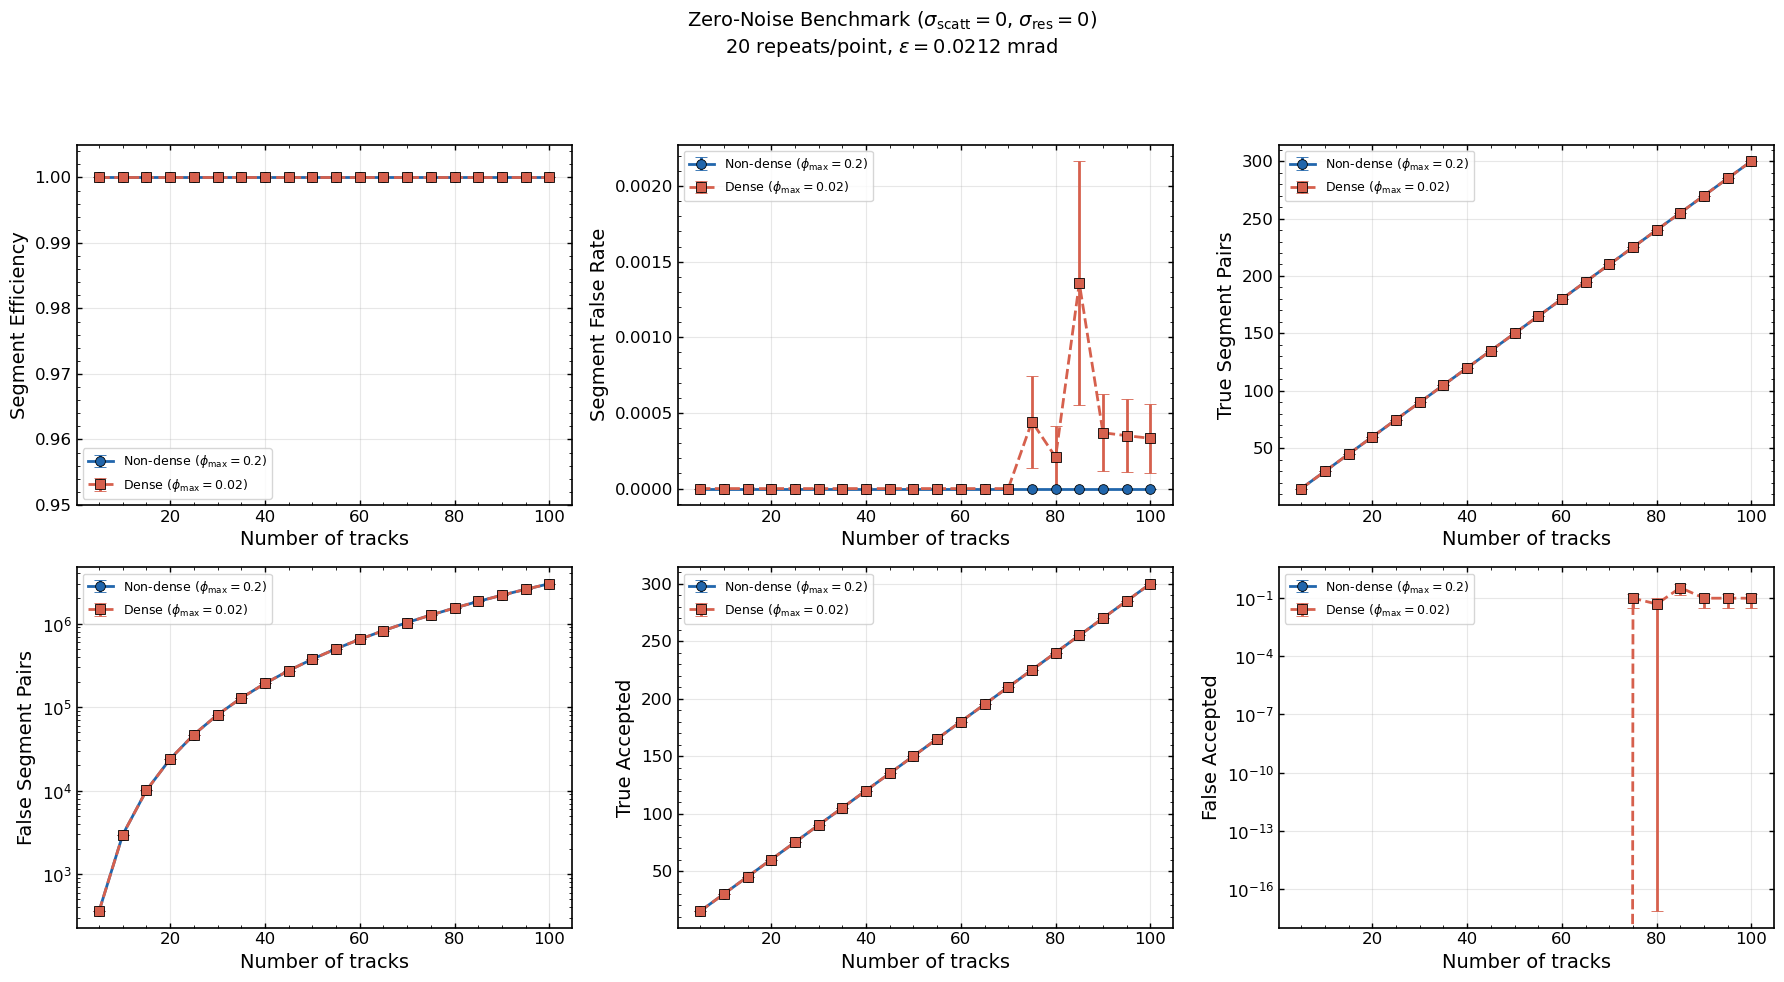


ZERO-NOISE BENCHMARK SUMMARY (per-repeat mean ± SE)

── NON_DENSE (φ_max = 0.2) ──
Tracks   Seg Eff            False Rate         True Pairs       False Pairs      True Acc       False Acc     
----------------------------------------------------------------------------------------------------
5        100.00% ± 0.00%   0.00% ± 0.00%   15 ± 0.0    360 ± 0.0    15 ± 0.0  0.0 ± 0.0
10       100.00% ± 0.00%   0.00% ± 0.00%   30 ± 0.0    2970 ± 0.0    30 ± 0.0  0.0 ± 0.0
15       100.00% ± 0.00%   0.00% ± 0.00%   45 ± 0.0    10080 ± 0.0    45 ± 0.0  0.0 ± 0.0
20       100.00% ± 0.00%   0.00% ± 0.00%   60 ± 0.0    23940 ± 0.0    60 ± 0.0  0.0 ± 0.0
25       100.00% ± 0.00%   0.00% ± 0.00%   75 ± 0.0    46800 ± 0.0    75 ± 0.0  0.0 ± 0.0
30       100.00% ± 0.00%   0.00% ± 0.00%   90 ± 0.0    80910 ± 0.0    90 ± 0.0  0.0 ± 0.0
35       100.00% ± 0.00%   0.00% ± 0.00%   105 ± 0.0    128520 ± 0.0    105 ± 0.0  0.0 ± 0.0
40       100.00% ± 0.00%   0.00% ± 0.00%   120 ± 0.0    191880 ± 0.0    12

: 

In [ ]:
# ============================================================================
# ZERO-NOISE BENCHMARK: Visualization
# ============================================================================
regime_colors = {"non_dense": "#2166ac", "dense": "#d6604d"}
regime_labels = {"non_dense": r"Non-dense ($\phi_{\max}=0.2$)",
                 "dense":     r"Dense ($\phi_{\max}=0.02$)"}
regime_fmts   = {"non_dense": "o-", "dense": "s--"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(r"Zero-Noise Benchmark ($\sigma_{\mathrm{scatt}} = 0$, $\sigma_{\mathrm{res}} = 0$)"
             f"\n{ZERO_N_REPEATS} repeats/point, "
             rf"$\varepsilon = {epsilon_zero*1e3:.4f}$ mrad",
             fontsize=14)

metrics = [
    ("seg_efficiency", "Segment Efficiency", True),
    ("seg_false_rate", "Segment False Rate", True),
    ("n_true",         "True Segment Pairs", False),
    ("n_false",        "False Segment Pairs", False),
    ("true_accepted",  "True Accepted",       False),
    ("false_accepted", "False Accepted",       False),
]

for ax, (col, ylabel, is_frac) in zip(axes.flat, metrics):
    for regime in ["non_dense", "dense"]:
        sub = df_zero[df_zero["regime"] == regime]
        grp = sub.groupby("n_tracks")[col]
        mean = grp.mean()
        se   = grp.std(ddof=1) / np.sqrt(grp.count())

        ax.errorbar(mean.index, mean.values, yerr=se.values,
                    fmt=regime_fmts[regime], color=regime_colors[regime],
                    capsize=4, capthick=1.2, linewidth=2, markersize=7,
                    markeredgecolor='black', markeredgewidth=0.6,
                    label=regime_labels[regime])

    ax.set_xlabel("Number of tracks")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

    if col == "seg_efficiency":
        ax.set_ylim(0.95, 1.005)
    if col in ("n_false", "false_accepted"):
        ax.set_yscale("log")

fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(OUT_DIR / 'zero_noise_benchmark.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'zero_noise_benchmark.pdf', bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "=" * 100)
print("ZERO-NOISE BENCHMARK SUMMARY (per-repeat mean ± SE)")
print("=" * 100)
for regime in ["non_dense", "dense"]:
    sub = df_zero[df_zero["regime"] == regime]
    print(f"\n── {regime.upper()} (φ_max = {ZERO_CONE_SETTINGS[regime]}) ──")
    print(f"{'Tracks':<8} {'Seg Eff':<18} {'False Rate':<18} "
          f"{'True Pairs':<16} {'False Pairs':<16} {'True Acc':<14} {'False Acc':<14}")
    print("-" * 100)
    for n_trk in ZERO_TRACK_COUNTS:
        s = sub[sub["n_tracks"] == n_trk]
        nr = len(s)
        eff = s["seg_efficiency"]
        fr  = s["seg_false_rate"]
        nt  = s["n_true"]
        nf  = s["n_false"]
        ta  = s["true_accepted"]
        fa  = s["false_accepted"]
        print(f"{n_trk:<8} "
              f"{eff.mean()*100:.2f}% ± {eff.std(ddof=1)/np.sqrt(nr)*100:.2f}%   "
              f"{fr.mean()*100:.2f}% ± {fr.std(ddof=1)/np.sqrt(nr)*100:.2f}%   "
              f"{nt.mean():.0f} ± {nt.std(ddof=1)/np.sqrt(nr):.1f}    "
              f"{nf.mean():.0f} ± {nf.std(ddof=1)/np.sqrt(nr):.1f}    "
              f"{ta.mean():.0f} ± {ta.std(ddof=1)/np.sqrt(nr):.1f}  "
              f"{fa.mean():.1f} ± {fa.std(ddof=1)/np.sqrt(nr):.1f}")

Saved to outputs/segment_analysis/zero_noise_benchmark_paper.png
Saved to outputs/segment_analysis/zero_noise_benchmark_paper.pdf


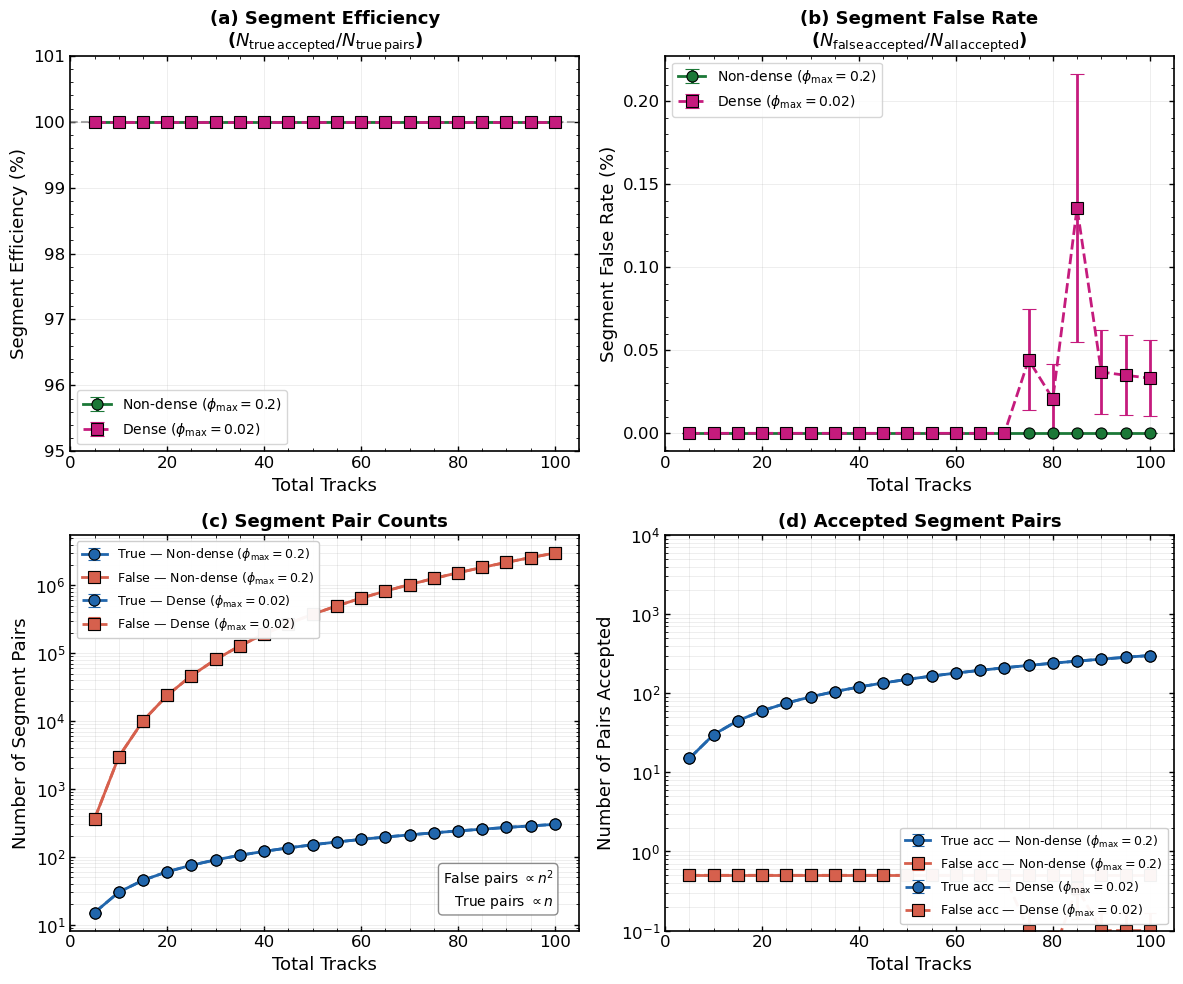

: 

In [ ]:
# ============================================================================
# ZERO-NOISE BENCHMARK: Paper-Ready 2×2 Plot (matching §10 style)
# ============================================================================

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.titlesize': 16,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'lines.linewidth': 2,
    'lines.markersize': 8,
})

# Aggregate per-repeat mean ± SE for each regime × track count
zero_plot_data = {}
for regime in ["non_dense", "dense"]:
    sub = df_zero[df_zero["regime"] == regime]
    agg = sub.groupby("n_tracks").agg(
        seg_eff_mean=("seg_efficiency", "mean"),
        seg_eff_se=("seg_efficiency", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        false_rate_mean=("seg_false_rate", "mean"),
        false_rate_se=("seg_false_rate", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n_true_mean=("n_true", "mean"),
        n_true_se=("n_true", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n_false_mean=("n_false", "mean"),
        n_false_se=("n_false", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        true_acc_mean=("true_accepted", "mean"),
        true_acc_se=("true_accepted", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        false_acc_mean=("false_accepted", "mean"),
        false_acc_se=("false_accepted", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
    zero_plot_data[regime] = agg

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Color scheme — one per regime
colors = {"non_dense": '#1b7837', "dense": '#c51b7d'}
fmts   = {"non_dense": 'o-',     "dense": 's--'}
labels = {"non_dense": r'Non-dense ($\phi_{\max}=0.2$)',
          "dense":     r'Dense ($\phi_{\max}=0.02$)'}

# ── (a) Segment Efficiency ──
ax1 = axes[0, 0]
for regime in ["non_dense", "dense"]:
    d = zero_plot_data[regime]
    ax1.errorbar(d.index, d["seg_eff_mean"] * 100, yerr=d["seg_eff_se"] * 100,
                 fmt=fmts[regime], color=colors[regime], capsize=5, capthick=1.5,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label=labels[regime])
ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('Total Tracks', fontsize=13)
ax1.set_ylabel('Segment Efficiency (%)', fontsize=13)
ax1.set_title('(a) Segment Efficiency\n($N_{\\mathrm{true\\,accepted}} / N_{\\mathrm{true\\,pairs}}$)',
              fontsize=13, fontweight='bold')
ax1.set_ylim(95, 101)
ax1.legend(fontsize=10, loc='lower left')
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.minorticks_on()
ax1.tick_params(which='both', direction='in', top=True, right=True)
ax1.set_xlim(0, 105)

# ── (b) Segment False Rate ──
ax2 = axes[0, 1]
for regime in ["non_dense", "dense"]:
    d = zero_plot_data[regime]
    ax2.errorbar(d.index, d["false_rate_mean"] * 100, yerr=d["false_rate_se"] * 100,
                 fmt=fmts[regime], color=colors[regime], capsize=5, capthick=1.5,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label=labels[regime])
ax2.set_xlabel('Total Tracks', fontsize=13)
ax2.set_ylabel('Segment False Rate (%)', fontsize=13)
ax2.set_title('(b) Segment False Rate\n($N_{\\mathrm{false\\,accepted}} / N_{\\mathrm{all\\,accepted}}$)',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax2.minorticks_on()
ax2.tick_params(which='both', direction='in', top=True, right=True)
ax2.set_xlim(0, 105)

# ── (c) Segment Pair Counts ──
ax3 = axes[1, 0]
color_true = '#2166ac'
color_false = '#d6604d'
for regime in ["non_dense", "dense"]:
    d = zero_plot_data[regime]
    style = '-' if regime == "non_dense" else '--'
    ax3.errorbar(d.index, d["n_true_mean"], yerr=d["n_true_se"],
                 fmt='o' + style, color=color_true, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'True — {labels[regime]}')
    ax3.errorbar(d.index, d["n_false_mean"], yerr=d["n_false_se"],
                 fmt='s' + style, color=color_false, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'False — {labels[regime]}')
ax3.set_yscale('log')
ax3.set_xlabel('Total Tracks', fontsize=13)
ax3.set_ylabel('Number of Segment Pairs', fontsize=13)
ax3.set_title('(c) Segment Pair Counts', fontsize=13, fontweight='bold')
ax3.legend(loc='upper left', framealpha=0.95, fontsize=9)
ax3.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, which='both')
ax3.minorticks_on()
ax3.tick_params(which='both', direction='in', top=True, right=True)
ax3.set_xlim(0, 105)
ax3.text(0.95, 0.05, 'False pairs $\\propto n^2$\nTrue pairs $\\propto n$',
         transform=ax3.transAxes, fontsize=10, ha='right', va='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# ── (d) Accepted Segment Pairs ──
ax4 = axes[1, 1]
for regime in ["non_dense", "dense"]:
    d = zero_plot_data[regime]
    style = '-' if regime == "non_dense" else '--'
    ax4.errorbar(d.index, d["true_acc_mean"], yerr=d["true_acc_se"],
                 fmt='o' + style, color=color_true, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'True acc — {labels[regime]}')
    false_acc_plot = np.where(d["false_acc_mean"] > 0, d["false_acc_mean"], 0.5)
    false_acc_se_plot = np.where(d["false_acc_mean"] > 0, d["false_acc_se"], 0)
    ax4.errorbar(d.index, false_acc_plot, yerr=false_acc_se_plot,
                 fmt='s' + style, color=color_false, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'False acc — {labels[regime]}')
ax4.set_yscale('log')
ax4.set_xlabel('Total Tracks', fontsize=13)
ax4.set_ylabel('Number of Pairs Accepted', fontsize=13)
ax4.set_title('(d) Accepted Segment Pairs', fontsize=13, fontweight='bold')
ax4.legend(loc='lower right', framealpha=0.95, fontsize=9)
ax4.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, which='both')
ax4.minorticks_on()
ax4.tick_params(which='both', direction='in', top=True, right=True)
ax4.set_xlim(0, 105)
ax4.set_ylim(0.1, 1e4)

plt.tight_layout()
fig.savefig(OUT_DIR / 'zero_noise_benchmark_paper.png', dpi=300,
            bbox_inches='tight', facecolor='white')
fig.savefig(OUT_DIR / 'zero_noise_benchmark_paper.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
print(f"Saved to {OUT_DIR / 'zero_noise_benchmark_paper.png'}")
print(f"Saved to {OUT_DIR / 'zero_noise_benchmark_paper.pdf'}")
plt.show()

## 12. Extended Analysis — Up to 1000 Tracks

Replicates §5–§11 with track counts extended to 1000. Uses the Numba-accelerated
segment-metrics kernel (`fast_segment_metrics`, defined in §2b) to make O(T³) triplet
enumeration tractable.

All extended experiments use the same physics parameters as their standard counterparts
(see overview table above); only the track count ranges are extended.

In [ ]:
# fast_segment_metrics is defined in §2b above — no need to re-define here.
print("fast_segment_metrics already available from §2b.")

fast_segment_metrics already available from §2b.


: 

### 12b. Extended Scattering Sweep (extends §5)

| Parameter | Value |
|-----------|-------|
| Swept | σ_scatt × n_tracks × φ_max |
| n_tracks | [10, 20, 50, 100, **200, 500, 1000**] |
| σ_scatt | [0.05 – 1.0] mrad (7 values) |
| σ_res | 0.0 mm |
| φ_max = θ_max | [0.02, 0.2] rad |
| ε mode | **Formula** |
| Events per point | 10 |

In [ ]:
# ============================================================================
# 12b. Extended Scattering Sweep Data Collection
# ============================================================================
import time as _time

TRACK_COUNTS_EXT   = [10, 20, 50, 100, 200, 500, 1000]
N_EVENTS_STATS_EXT = 10

TRACK_COLORS_EXT = {
    10: "#1b7837", 20: "#2166ac", 50: "#e08214", 100: "#c51b7d",
    200: "#7570b3", 500: "#d95f02", 1000: "#e7298a",
}
TRACK_FMTS_EXT = {
    10: "o-", 20: "s--", 50: "D:", 100: "^-.",
    200: "v-", 500: "P--", 1000: "X:",
}

_cache_file = CACHE_DIR / "df_seg_scatt_ext.csv"
if _cache_file.exists():
    df_seg_scatt_ext = pd.read_csv(_cache_file)
    print(f"Loaded df_seg_scatt_ext from cache: {len(df_seg_scatt_ext)} rows")
else:
    seg_rows_ext = []
    t_start = _time.time()

    for phi_max in ANGLE_SETTINGS:
        for n_trk in TRACK_COUNTS_EXT:
            t0 = _time.time()
            for si_ext, sigma_s in enumerate(SIGMA_SCATT_VALUES):
                epsilon = compute_epsilon(0.0, sigma_s)
                for rep in range(N_EVENTS_STATS_EXT):
                    np.random.seed(rep + n_trk * 100 + si_ext * 10000 + 500000)
                    event = safe_generate(n_trk, measurement_error=0.0,
                                          collision_noise=sigma_s,
                                          phi_max=phi_max, theta_max=phi_max)
                    m = fast_segment_metrics(event, epsilon)
                    seg_rows_ext.append({
                        "phi_max": phi_max,
                        "n_tracks": n_trk,
                        "sigma_scatt": sigma_s,
                        "sigma_scatt_mrad": sigma_s * 1e3,
                        "epsilon": epsilon,
                        "repeat": rep,
                        **m,
                    })
            dt = _time.time() - t0
            print(f"  phi_max={phi_max}  n_tracks={n_trk:4d}  done  ({dt:.1f}s)")

    df_seg_scatt_ext = pd.DataFrame(seg_rows_ext)
    df_seg_scatt_ext.to_csv(_cache_file, index=False)
    print(f"\n{len(df_seg_scatt_ext)} rows collected & saved  "
          f"(total {_time.time() - t_start:.0f}s)")

Loaded df_seg_scatt_ext from cache: 980 rows


: 

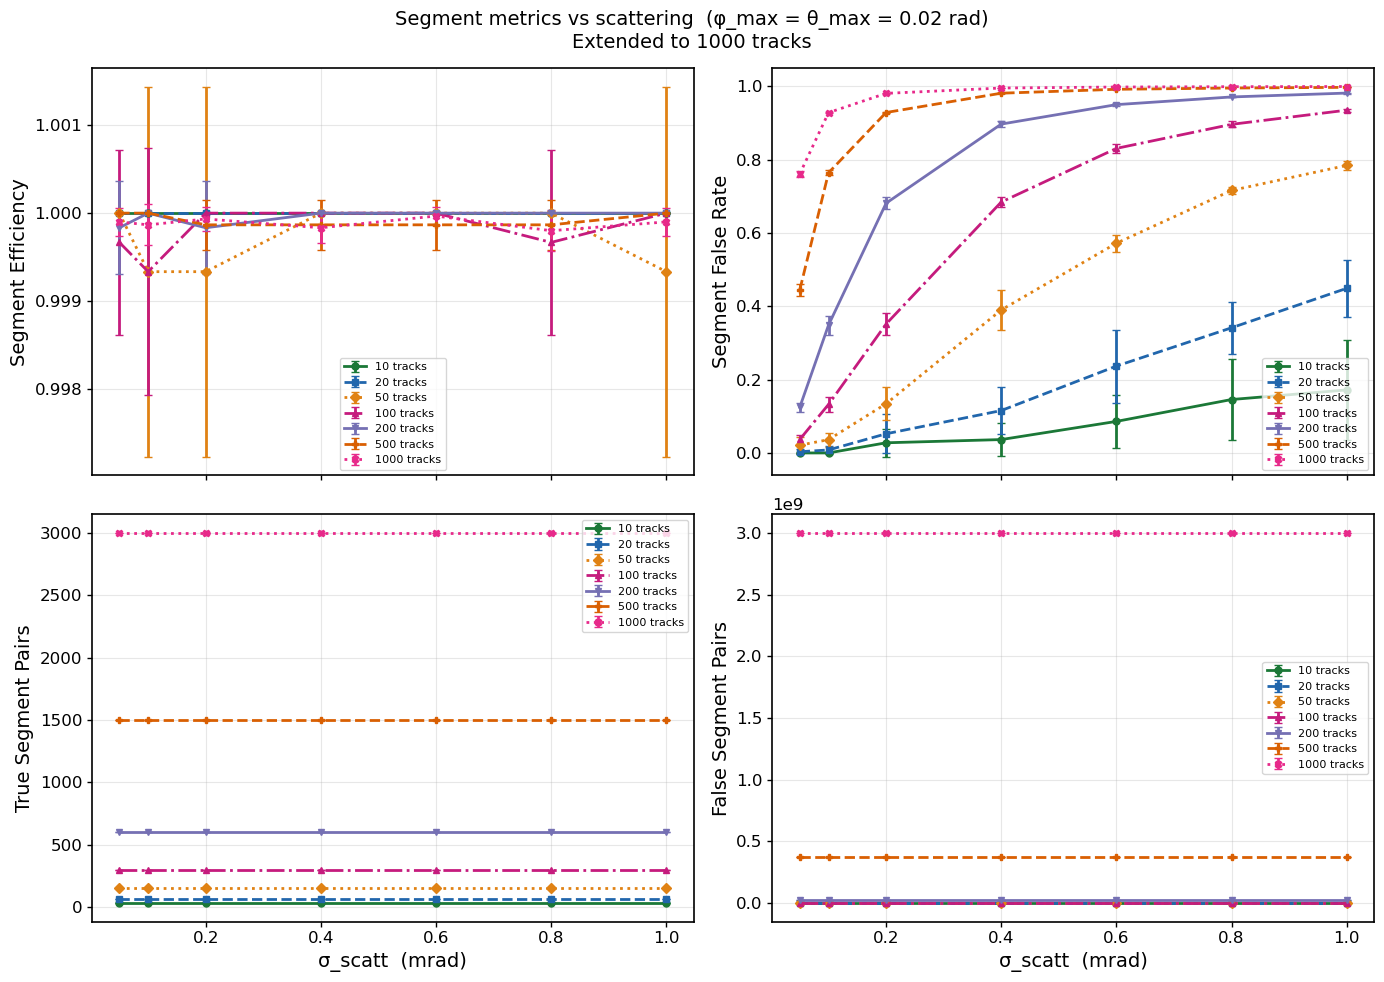

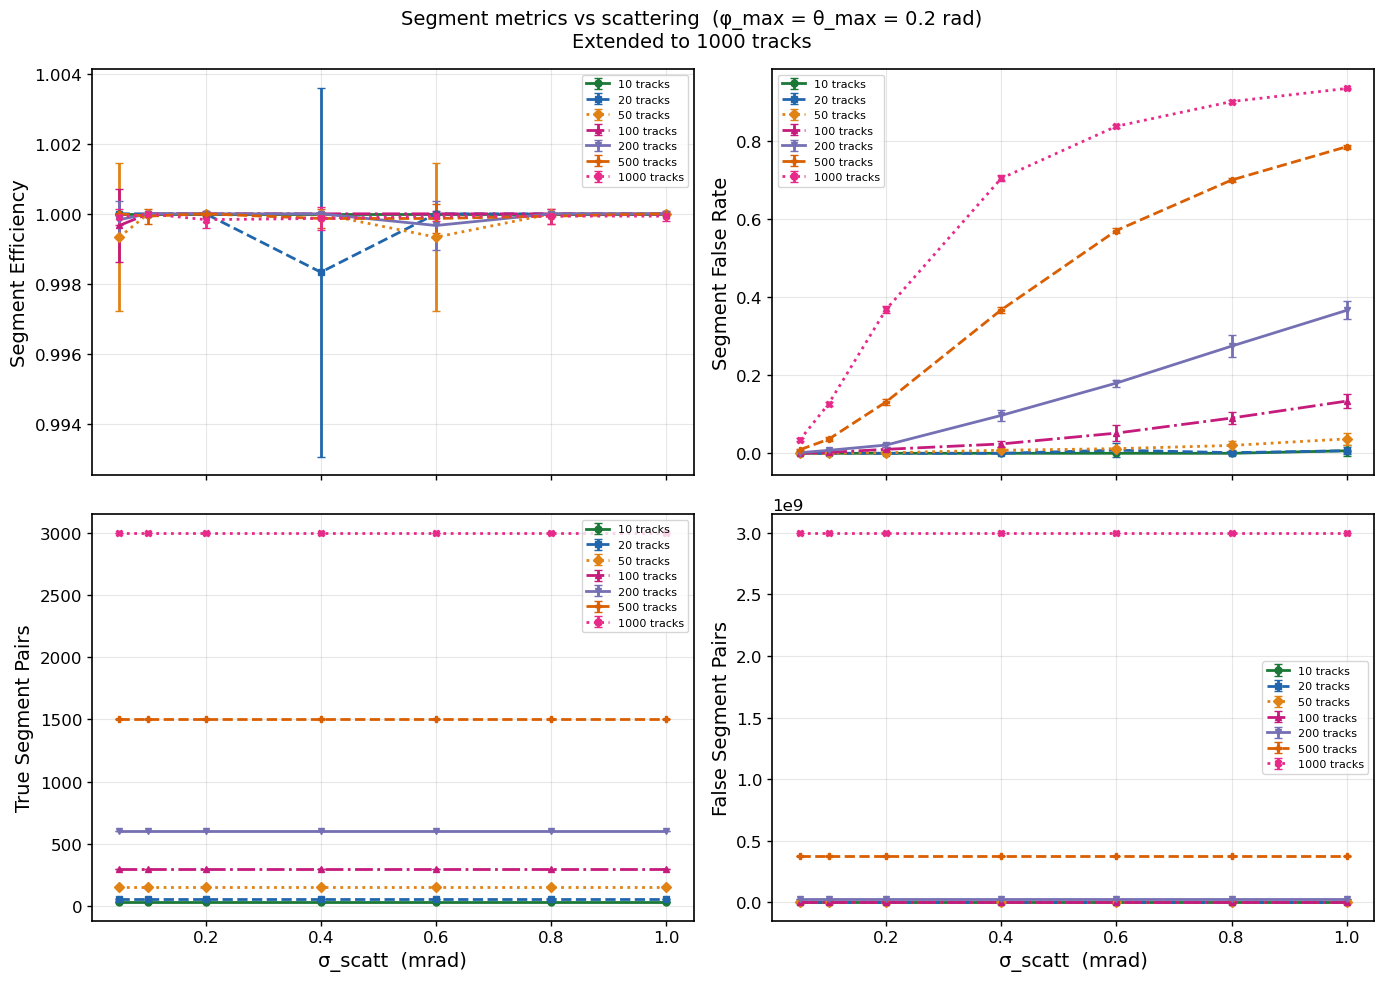

: 

In [ ]:
# ============================================================================
# 12b. Extended Scattering Sweep Plots
# ============================================================================
for phi_max in ANGLE_SETTINGS:
    sub = df_seg_scatt_ext[df_seg_scatt_ext["phi_max"] == phi_max]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Segment metrics vs scattering  (φ_max = θ_max = {phi_max} rad)"
                 f"\nExtended to 1000 tracks", fontsize=14)

    metrics = [("segment_efficiency", "Segment Efficiency"),
               ("segment_false_rate", "Segment False Rate"),
               ("n_true",           "True Segment Pairs"),
               ("n_false",          "False Segment Pairs")]

    for ax, (col, label) in zip(axes.flat, metrics):
        for n_trk in TRACK_COUNTS_EXT:
            d = sub[sub["n_tracks"] == n_trk].groupby("sigma_scatt_mrad")[col]
            mean = d.mean()
            std  = d.std()
            ax.errorbar(mean.index, mean.values, yerr=std.values,
                        fmt=TRACK_FMTS_EXT[n_trk], color=TRACK_COLORS_EXT[n_trk],
                        label=f"{n_trk} tracks", capsize=3, ms=5)
        ax.set_ylabel(label)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[1]:
        ax.set_xlabel("σ_scatt  (mrad)")

    fig.tight_layout()
    fig.savefig(OUT_DIR / f'scattering_sweep_ext_phi{phi_max}.png', dpi=150, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'scattering_sweep_ext_phi{phi_max}.pdf', bbox_inches='tight')
    plt.show()

### 12c. Extended Resolution Sweep (extends §6)

| Parameter | Value |
|-----------|-------|
| Swept | σ_res × n_tracks × φ_max |
| n_tracks | [10, 20, 50, 100, **200, 500, 1000**] |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad, fixed) |
| σ_res | [0.0 – 0.05] mm (7 values) |
| φ_max = θ_max | [0.02, 0.2] rad |
| ε mode | **Formula** |
| Events per point | 10 |

In [ ]:
# ============================================================================
# 12c. Extended Resolution Sweep Data Collection
# ============================================================================
_cache_file = CACHE_DIR / "df_seg_res_ext.csv"
if _cache_file.exists():
    df_seg_res_ext = pd.read_csv(_cache_file)
    print(f"Loaded df_seg_res_ext from cache: {len(df_seg_res_ext)} rows")
else:
    res_rows_ext = []
    t_start = _time.time()

    for phi_max in ANGLE_SETTINGS:
        for n_trk in TRACK_COUNTS_EXT:
            t0 = _time.time()
            for ri_ext, sigma_r in enumerate(SIGMA_RES_VALUES):
                epsilon = compute_epsilon(sigma_r, SIGMA_SCATT_FIXED)
                for rep in range(N_EVENTS_STATS_EXT):
                    np.random.seed(rep + n_trk * 100 + ri_ext * 10000 + 600000)
                    event = safe_generate(n_trk, measurement_error=sigma_r,
                                          collision_noise=SIGMA_SCATT_FIXED,
                                          phi_max=phi_max, theta_max=phi_max)
                    m = fast_segment_metrics(event, epsilon)
                    res_rows_ext.append({
                        "phi_max": phi_max,
                        "n_tracks": n_trk,
                        "sigma_res": sigma_r,
                        "sigma_res_mm": sigma_r,
                        "epsilon": epsilon,
                        "repeat": rep,
                        **m,
                    })
            dt = _time.time() - t0
            print(f"  phi_max={phi_max}  n_tracks={n_trk:4d}  done  ({dt:.1f}s)")

    df_seg_res_ext = pd.DataFrame(res_rows_ext)
    df_seg_res_ext.to_csv(_cache_file, index=False)
    print(f"\n{len(df_seg_res_ext)} rows collected & saved  "
          f"(total {_time.time() - t_start:.0f}s)")

Loaded df_seg_res_ext from cache: 980 rows


: 

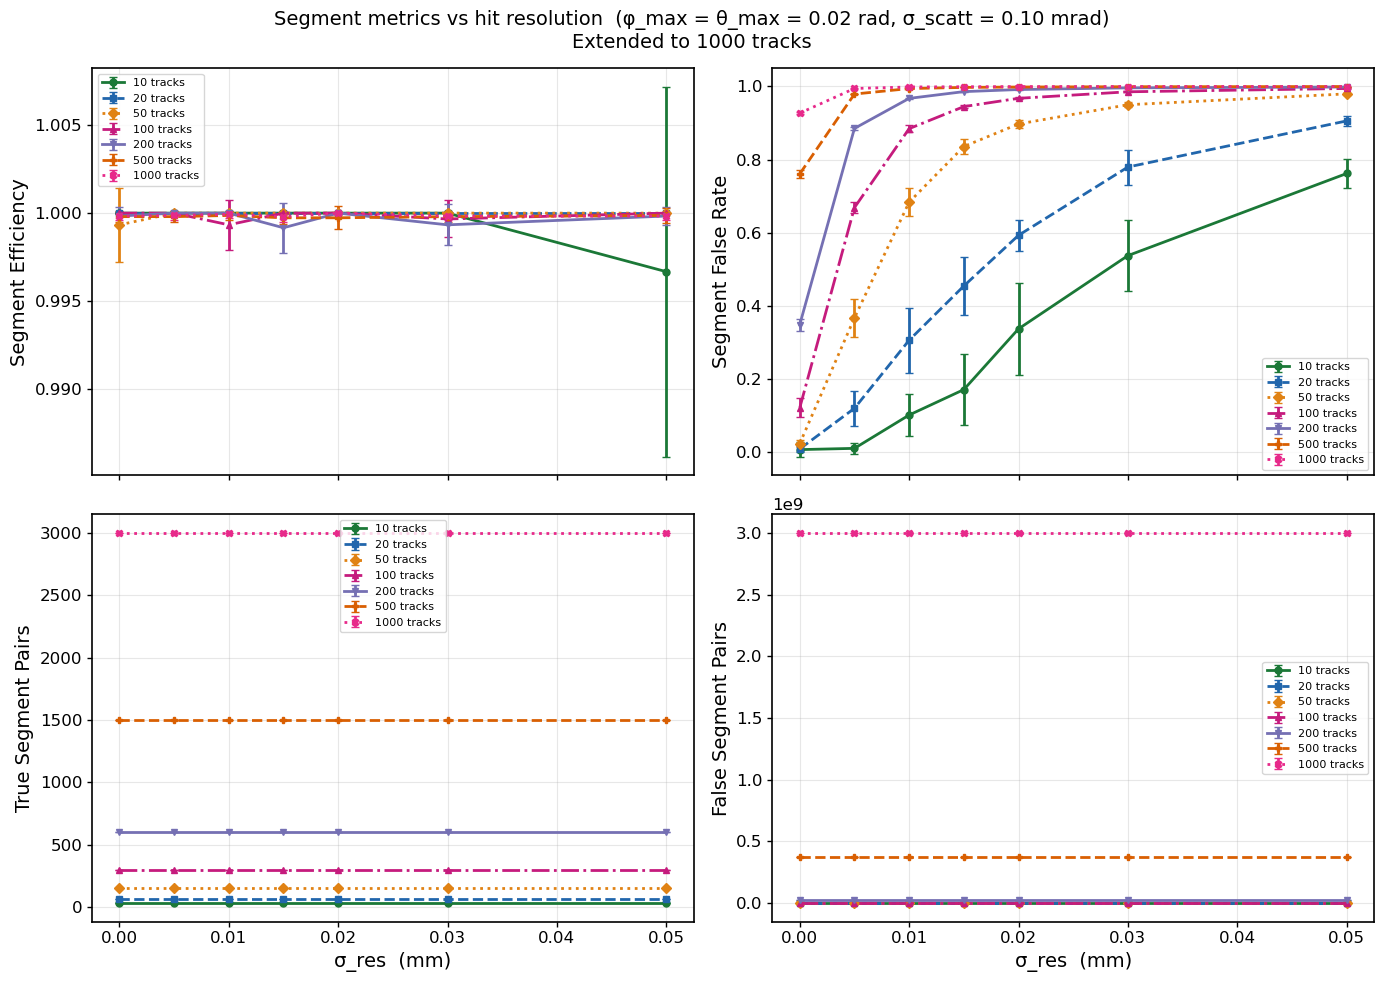

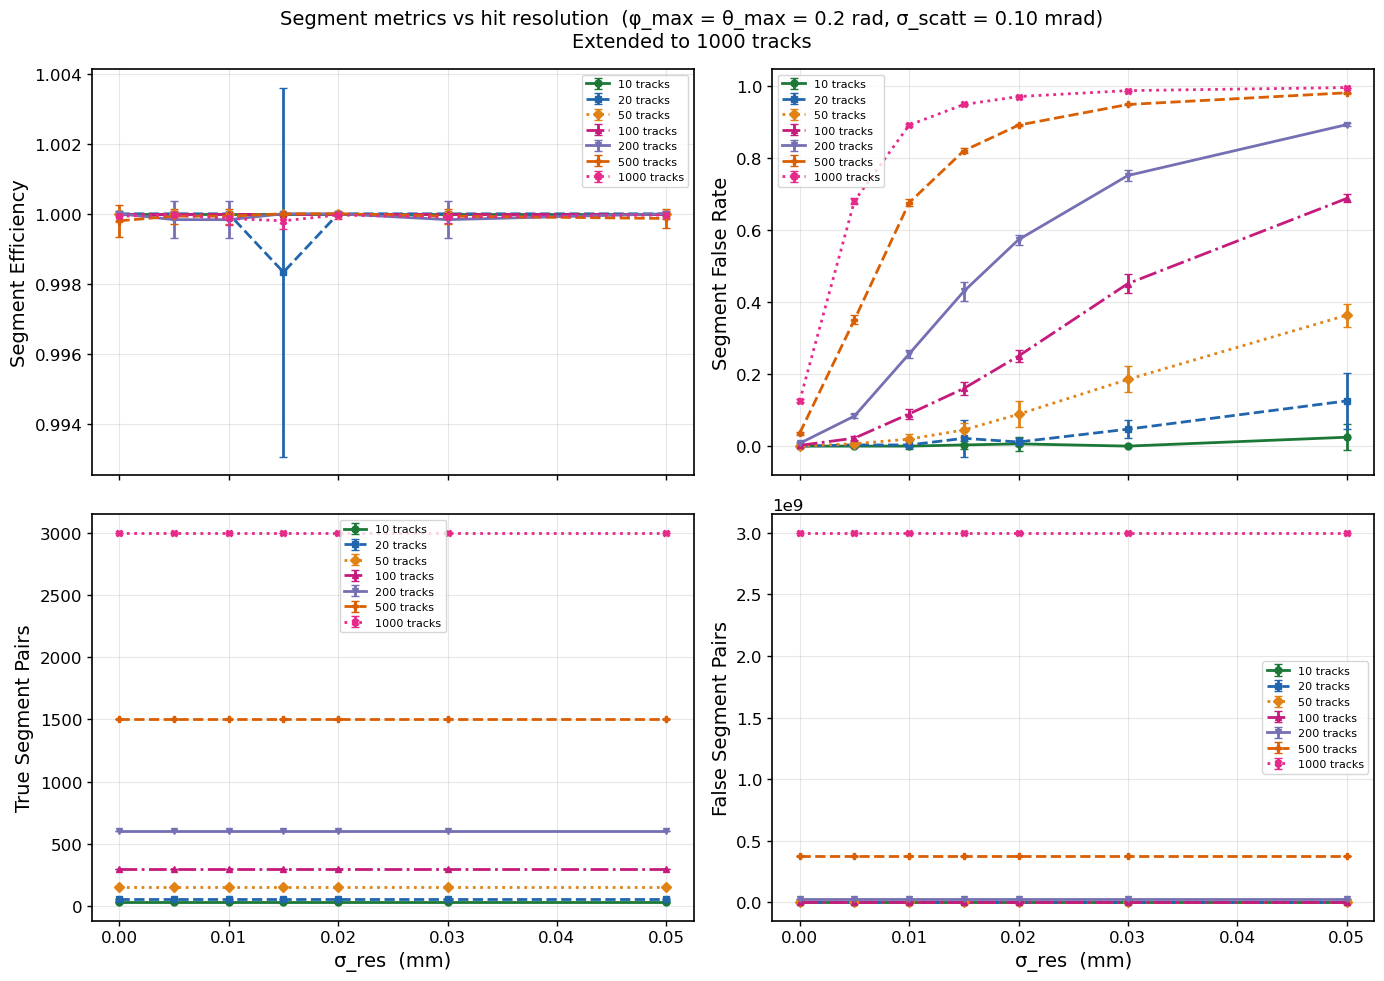

: 

In [ ]:
# ============================================================================
# 12c. Extended Resolution Sweep Plots
# ============================================================================
for phi_max in ANGLE_SETTINGS:
    sub = df_seg_res_ext[df_seg_res_ext["phi_max"] == phi_max]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Segment metrics vs hit resolution  (φ_max = θ_max = {phi_max} rad, "
                 f"σ_scatt = {SIGMA_SCATT_FIXED*1e3:.2f} mrad)"
                 f"\nExtended to 1000 tracks", fontsize=14)

    metrics = [("segment_efficiency", "Segment Efficiency"),
               ("segment_false_rate", "Segment False Rate"),
               ("n_true",            "True Segment Pairs"),
               ("n_false",           "False Segment Pairs")]

    for ax, (col, label) in zip(axes.flat, metrics):
        for n_trk in TRACK_COUNTS_EXT:
            d = sub[sub["n_tracks"] == n_trk].groupby("sigma_res_mm")[col]
            mean = d.mean()
            std  = d.std()
            ax.errorbar(mean.index, mean.values, yerr=std.values,
                        fmt=TRACK_FMTS_EXT[n_trk], color=TRACK_COLORS_EXT[n_trk],
                        label=f"{n_trk} tracks", capsize=3, ms=5)
        ax.set_ylabel(label)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[1]:
        ax.set_xlabel("σ_res  (mm)")

    fig.tight_layout()
    fig.savefig(OUT_DIR / f'resolution_sweep_ext_phi{phi_max}.png', dpi=150, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'resolution_sweep_ext_phi{phi_max}.pdf', bbox_inches='tight')
    plt.show()

### 12d. Extended Density Scan (extends §7)

| Parameter | Value |
|-----------|-------|
| Swept | n_tracks |
| n_tracks | 5–100 (step 5), **150–1000 (step 50)** |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad) |
| σ_res | 0.0 mm |
| φ_max = θ_max | 0.2 rad |
| ε mode | **Formula** |
| Events per point | 5 |

In [ ]:
# ============================================================================
# 12d. Extended Density Scan Data Collection
# ============================================================================
DENSITY_TRACKS_EXT = list(range(5, 105, 5)) + list(range(150, 1050, 50))
N_EVENTS_DENSITY_EXT = 5

epsilon_dens_ext = compute_epsilon(SIGMA_RES_DENS, SIGMA_SCATT_DENS)

_cache_file = CACHE_DIR / "df_density_ext.csv"
if _cache_file.exists():
    df_density_ext = pd.read_csv(_cache_file)
    print(f"Loaded df_density_ext from cache: {len(df_density_ext)} rows")
else:
    density_rows_ext = []
    t_start = _time.time()

    for n_trk in DENSITY_TRACKS_EXT:
        t0 = _time.time()
        for rep in range(N_EVENTS_DENSITY_EXT):
            np.random.seed(rep + n_trk * 100 + 700000)
            event = safe_generate(n_trk, measurement_error=SIGMA_RES_DENS,
                                  collision_noise=SIGMA_SCATT_DENS,
                                  phi_max=PHI_MAX_DENS, theta_max=PHI_MAX_DENS)
            m = fast_segment_metrics(event, epsilon_dens_ext)
            density_rows_ext.append({
                "n_tracks": n_trk,
                "repeat": rep,
                "epsilon": epsilon_dens_ext,
                **m,
            })
        dt = _time.time() - t0
        print(f"  n_tracks={n_trk:4d}  done  ({dt:.1f}s)")

    df_density_ext = pd.DataFrame(density_rows_ext)
    df_density_ext.to_csv(_cache_file, index=False)
    print(f"\n{len(df_density_ext)} rows collected & saved  "
          f"(total {_time.time() - t_start:.0f}s)")

Loaded df_density_ext from cache: 190 rows


: 

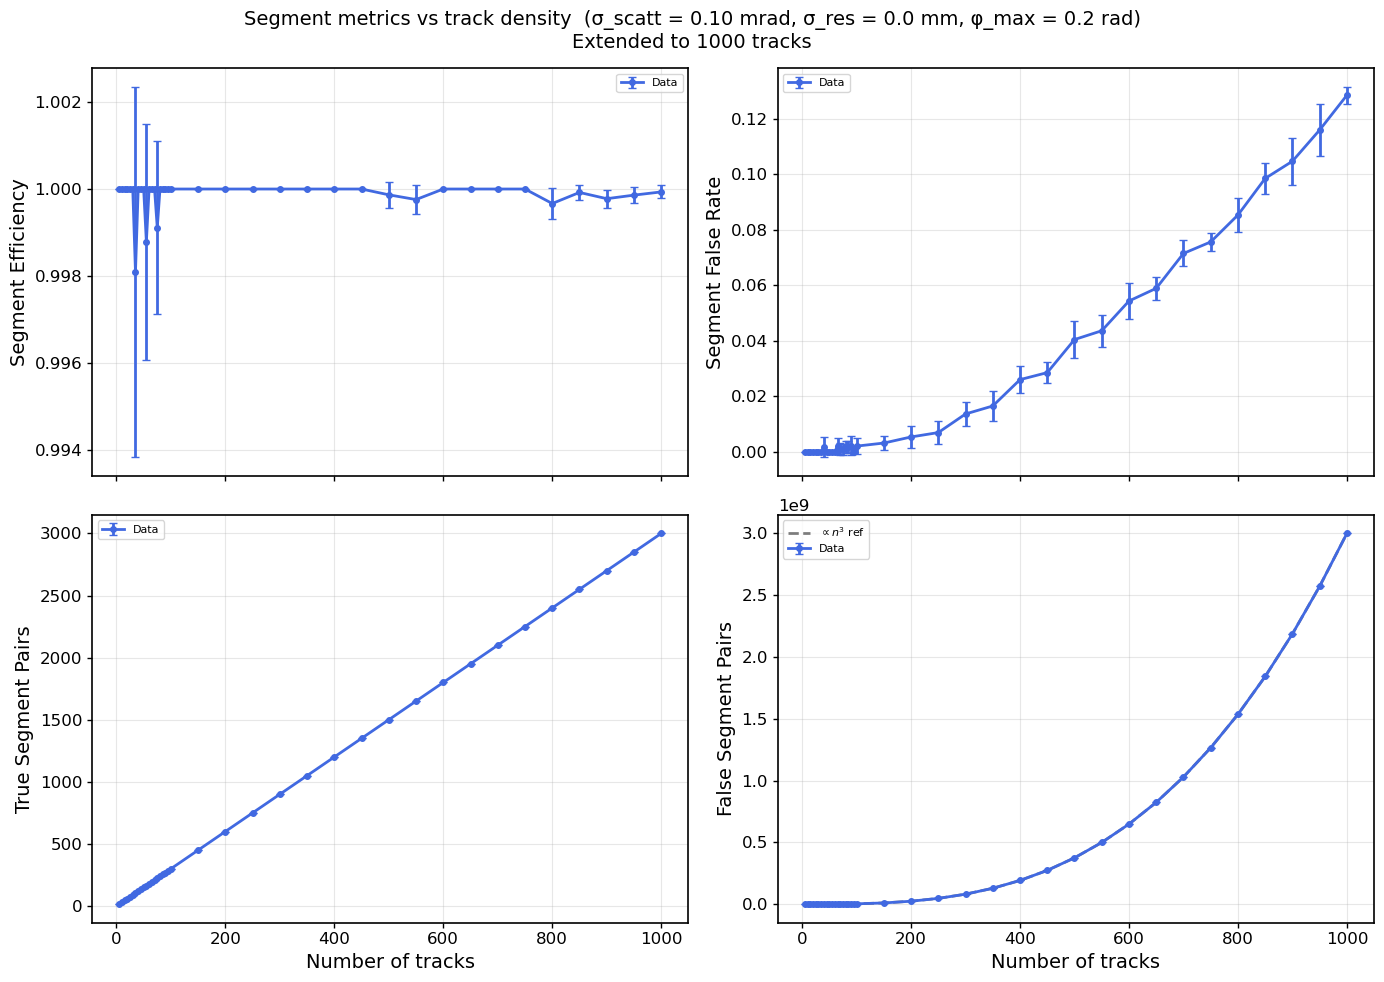

: 

In [ ]:
# ============================================================================
# 12d. Extended Density Scan Plots
# ============================================================================
grp_ext = df_density_ext.groupby("n_tracks")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fig.suptitle(f"Segment metrics vs track density  (σ_scatt = {SIGMA_SCATT_DENS*1e3:.2f} mrad, "
             f"σ_res = {SIGMA_RES_DENS} mm, φ_max = {PHI_MAX_DENS} rad)"
             f"\nExtended to 1000 tracks", fontsize=14)

metrics = [("segment_efficiency", "Segment Efficiency"),
           ("segment_false_rate", "Segment False Rate"),
           ("n_true",            "True Segment Pairs"),
           ("n_false",           "False Segment Pairs")]

for ax, (col, label) in zip(axes.flat, metrics):
    mean = grp_ext[col].mean()
    std  = grp_ext[col].std()
    ax.errorbar(mean.index, mean.values, yerr=std.values,
                fmt="o-", color="royalblue", capsize=3, ms=4, label="Data")

    # Reference line for n_false: n^3 scaling (triplet combinatorics)
    if col == "n_false":
        n_arr = mean.index.values.astype(float)
        c = mean.values[-1] / n_arr[-1]**3 if n_arr[-1] > 0 else 1
        ax.plot(n_arr, c * n_arr**3, "k--", alpha=0.5, label=r"$\propto n^3$ ref")

    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("Number of tracks")

fig.tight_layout()
fig.savefig(OUT_DIR / 'density_scan_ext.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'density_scan_ext.pdf', bbox_inches='tight')
plt.show()

### 12e. Extended Fixed-Epsilon (single-event generation)

> **Note**: This experiment uses `safe_generate` (single-event, pion, 80 mm modules,
> PV σ = (0, 0, 1)) and is therefore **not directly comparable** to §10, which uses
> multi-event MIP generation with 160 mm modules and PV σ = (1, 1, 1). It serves as
> a complementary check of the triplet method under simpler generation conditions.

| Parameter | Value |
|-----------|-------|
| Swept | n_tracks |
| n_tracks | [20–180 step 20], **[200–1000 step 100]** |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad) |
| σ_res | 0.005 mm |
| φ_max = θ_max | 0.2 rad |
| ε mode | **Fixed = 2.0 mrad** |
| Module half-width | 40 mm (80 mm full module) |
| PV sigma | x = 0, y = 0, z = 1 mm |
| Particle | Pion (mass = 139.6, q = 1) |
| Events per point | 1 (single-event via `safe_generate`) |
| Repeats per point | 20 |

In [ ]:
# ============================================================================
# 12e. Extended Fixed-Epsilon Data Collection
# ============================================================================
FIXED_TRACK_COUNTS_EXT = [20, 40, 60, 80, 100, 120, 140, 160, 180,
                          200, 300, 400, 500, 600, 700, 800, 900, 1000]
N_REPEATS_FIXED_EXT = 20

print("=" * 80)
print("SEGMENT-LEVEL EFFICIENCY (fixed eps = 2 mrad) — EXTENDED")
print("=" * 80)

_cache_file = CACHE_DIR / "segment_efficiency_results_ext.pkl"
if _cache_file.exists():
    with open(_cache_file, "rb") as f:
        seg_eff_results_ext = pickle.load(f)
    print(f"Loaded seg_eff_results_ext from cache: {len(seg_eff_results_ext)} entries")
else:
    seg_eff_results_ext = []
    t_start = _time.time()

    for n_trk in FIXED_TRACK_COUNTS_EXT:
        t0 = _time.time()
        per_repeat_data = []

        for rep in range(N_REPEATS_FIXED_EXT):
            np.random.seed(rep + n_trk * 100 + 800000)
            event = safe_generate(n_trk, measurement_error=FIXED_RESOLUTION,
                                  collision_noise=FIXED_SCATTERING,
                                  phi_max=0.2, theta_max=0.2)
            m = fast_segment_metrics(event, FIXED_EPSILON)
            per_repeat_data.append(m)

        eff_per = np.array([r['segment_efficiency'] for r in per_repeat_data])
        fr_per  = np.array([r['segment_false_rate'] for r in per_repeat_data])
        nt_per  = np.array([r['n_true'] for r in per_repeat_data])
        nf_per  = np.array([r['n_false'] for r in per_repeat_data])
        ta_per  = np.array([r['true_accepted'] for r in per_repeat_data])
        fa_per  = np.array([r['false_accepted'] for r in per_repeat_data])
        nr = len(per_repeat_data)

        seg_eff_results_ext.append({
            'total_tracks': n_trk,
            'n_repeats': nr,
            'seg_efficiency_mean': np.mean(eff_per),
            'seg_efficiency_se': np.std(eff_per, ddof=1) / np.sqrt(nr),
            'seg_false_rate_mean': np.mean(fr_per),
            'seg_false_rate_se': np.std(fr_per, ddof=1) / np.sqrt(nr),
            'n_true_mean': np.mean(nt_per),
            'n_true_se': np.std(nt_per, ddof=1) / np.sqrt(nr),
            'n_false_mean': np.mean(nf_per),
            'n_false_se': np.std(nf_per, ddof=1) / np.sqrt(nr),
            'true_acc_mean': np.mean(ta_per),
            'true_acc_se': np.std(ta_per, ddof=1) / np.sqrt(nr),
            'false_acc_mean': np.mean(fa_per),
            'false_acc_se': np.std(fa_per, ddof=1) / np.sqrt(nr),
            'per_repeat': per_repeat_data,
        })

        dt = _time.time() - t0
        print(f"  [{n_trk:4d} tracks]  eff={np.mean(eff_per)*100:.2f}%  "
              f"fr={np.mean(fr_per)*100:.2f}%  ({dt:.1f}s)")

    with open(_cache_file, "wb") as f:
        pickle.dump(seg_eff_results_ext, f)
    print(f"\nDone in {_time.time() - t_start:.0f}s")

SEGMENT-LEVEL EFFICIENCY (fixed eps = 2 mrad) — EXTENDED
Loaded seg_eff_results_ext from cache: 18 entries


: 

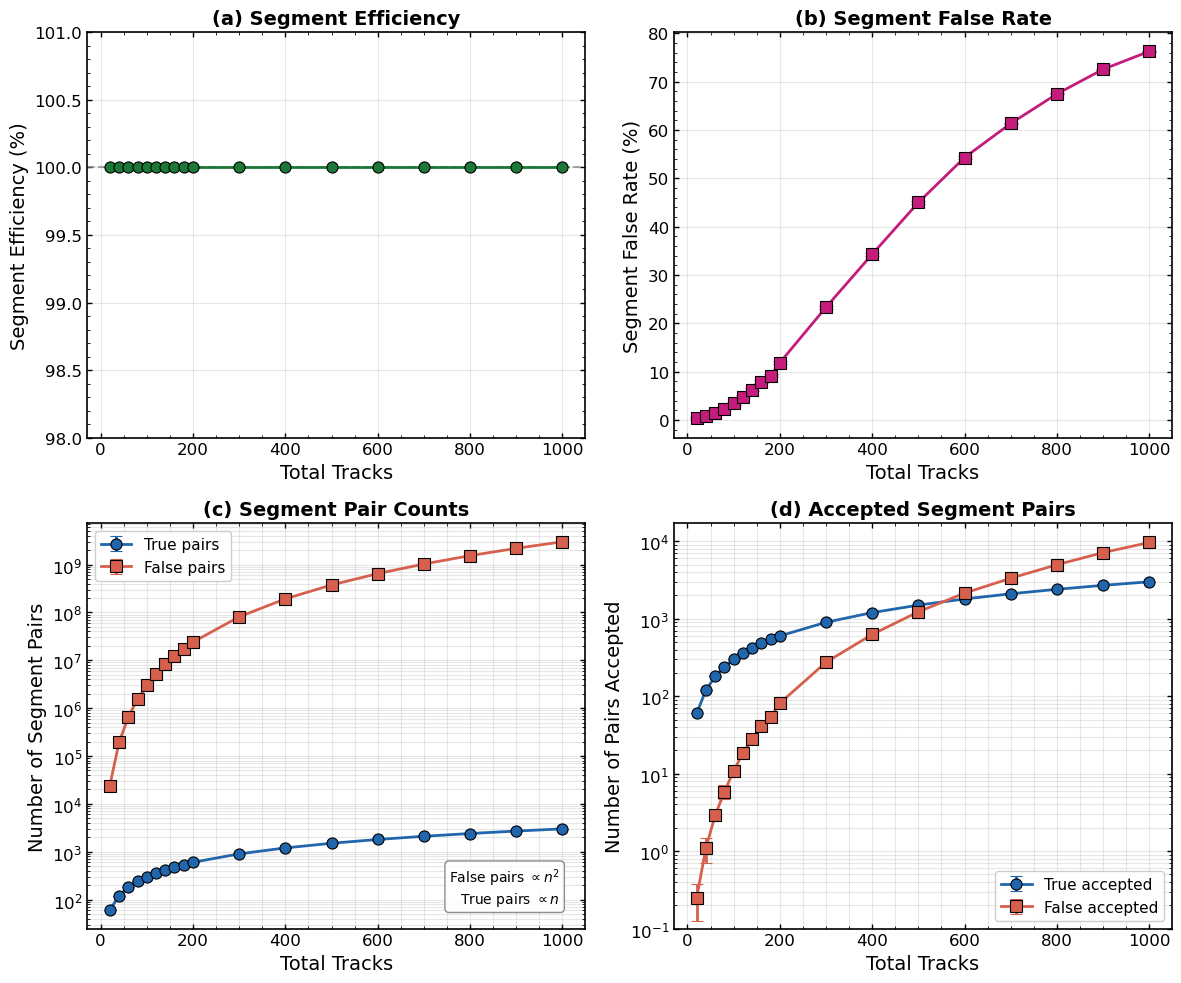


EXTENDED SEGMENT-LEVEL EFFICIENCY SUMMARY (per-repeat mean +/- SE)
Tracks     Reps   Seg Eff          False Rate       True Pairs         False Pairs        True Acc         False Acc       
----------------------------------------------------------------------------------------------------------------------------------
20         20     100.00% +/- 0.00% 0.41% +/- 0.20%  60 +/- 0.0         23940 +/- 0.0      60 +/- 0.0       0.2 +/- 0.1     
40         20     100.00% +/- 0.00% 0.89% +/- 0.32%  120 +/- 0.0        191880 +/- 0.0     120 +/- 0.0      1.1 +/- 0.4     
60         20     100.00% +/- 0.00% 1.58% +/- 0.22%  180 +/- 0.0        647820 +/- 0.0     180 +/- 0.0      2.9 +/- 0.4     
80         20     100.00% +/- 0.00% 2.34% +/- 0.45%  240 +/- 0.0        1535760 +/- 0.0    240 +/- 0.0      5.8 +/- 1.2     
100        20     100.00% +/- 0.00% 3.46% +/- 0.31%  300 +/- 0.0        2999700 +/- 0.0    300 +/- 0.0      10.8 +/- 1.0    
120        20     100.00% +/- 0.00% 4.88% +/- 0.23% 

: 

In [ ]:
# ============================================================================
# 12e. Extended Fixed-Epsilon Plots  (Paper-Ready)
# ============================================================================
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11,
    'figure.titlesize': 16, 'axes.linewidth': 1.2,
    'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
    'lines.linewidth': 2, 'lines.markersize': 8,
})

if len(seg_eff_results_ext) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    color_true = '#2166ac'
    color_false = '#d6604d'
    color_eff = '#1b7837'
    color_false_rate = '#c51b7d'

    tc  = np.array([r['total_tracks'] for r in seg_eff_results_ext])
    se_ = np.array([r['seg_efficiency_mean'] * 100 for r in seg_eff_results_ext])
    see = np.array([r['seg_efficiency_se'] * 100 for r in seg_eff_results_ext])
    fr_ = np.array([r['seg_false_rate_mean'] * 100 for r in seg_eff_results_ext])
    fre = np.array([r['seg_false_rate_se'] * 100 for r in seg_eff_results_ext])
    ntm = np.array([r['n_true_mean'] for r in seg_eff_results_ext])
    nts = np.array([r['n_true_se'] for r in seg_eff_results_ext])
    nfm = np.array([r['n_false_mean'] for r in seg_eff_results_ext])
    nfs = np.array([r['n_false_se'] for r in seg_eff_results_ext])
    tam = np.array([r['true_acc_mean'] for r in seg_eff_results_ext])
    tas = np.array([r['true_acc_se'] for r in seg_eff_results_ext])
    fam = np.array([r['false_acc_mean'] for r in seg_eff_results_ext])
    fas = np.array([r['false_acc_se'] for r in seg_eff_results_ext])

    # (a) Segment Efficiency
    ax1 = axes[0, 0]
    ax1.errorbar(tc, se_, yerr=see, fmt='o-', color=color_eff, capsize=5,
                 capthick=1.5, markersize=8, markeredgecolor='black', markeredgewidth=0.8)
    ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax1.set_xlabel('Total Tracks')
    ax1.set_ylabel('Segment Efficiency (%)')
    ax1.set_title('(a) Segment Efficiency', fontweight='bold')
    ax1.set_ylim(min(se_) - 2, 101)
    ax1.grid(True, alpha=0.3)
    ax1.minorticks_on()
    ax1.tick_params(which='both', direction='in', top=True, right=True)

    # (b) False Rate
    ax2 = axes[0, 1]
    ax2.errorbar(tc, fr_, yerr=fre, fmt='s-', color=color_false_rate, capsize=5,
                 capthick=1.5, markersize=8, markeredgecolor='black', markeredgewidth=0.8)
    ax2.set_xlabel('Total Tracks')
    ax2.set_ylabel('Segment False Rate (%)')
    ax2.set_title('(b) Segment False Rate', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.minorticks_on()
    ax2.tick_params(which='both', direction='in', top=True, right=True)

    # (c) Pair counts
    ax3 = axes[1, 0]
    ax3.errorbar(tc, ntm, yerr=nts, fmt='o-', color=color_true, capsize=4,
                 capthick=1.2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label='True pairs')
    ax3.errorbar(tc, nfm, yerr=nfs, fmt='s-', color=color_false, capsize=4,
                 capthick=1.2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label='False pairs')
    ax3.set_yscale('log')
    ax3.set_xlabel('Total Tracks')
    ax3.set_ylabel('Number of Segment Pairs')
    ax3.set_title('(c) Segment Pair Counts', fontweight='bold')
    ax3.legend(loc='upper left', framealpha=0.95)
    ax3.grid(True, alpha=0.3, which='both')
    ax3.minorticks_on()
    ax3.tick_params(which='both', direction='in', top=True, right=True)
    ax3.text(0.95, 0.05, r'False pairs $\propto n^2$' + '\n' + r'True pairs $\propto n$',
             transform=ax3.transAxes, fontsize=10, ha='right', va='bottom',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # (d) Accepted pairs
    ax4 = axes[1, 1]
    fa_plot = np.where(fam > 0, fam, 0.5)
    fa_se_plot = np.where(fam > 0, fas, 0)
    ax4.errorbar(tc, tam, yerr=tas, fmt='o-', color=color_true, capsize=4,
                 capthick=1.2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label='True accepted')
    ax4.errorbar(tc, fa_plot, yerr=fa_se_plot, fmt='s-', color=color_false, capsize=4,
                 capthick=1.2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label='False accepted')
    ax4.set_yscale('log')
    ax4.set_xlabel('Total Tracks')
    ax4.set_ylabel('Number of Pairs Accepted')
    ax4.set_title('(d) Accepted Segment Pairs', fontweight='bold')
    ax4.legend(loc='lower right', framealpha=0.95)
    ax4.grid(True, alpha=0.3, which='both')
    ax4.minorticks_on()
    ax4.tick_params(which='both', direction='in', top=True, right=True)
    ax4.set_ylim(0.1, None)

    plt.tight_layout()
    fig.savefig(OUT_DIR / 'fixed_epsilon_segment_efficiency_ext.png', dpi=300,
                bbox_inches='tight', facecolor='white')
    fig.savefig(OUT_DIR / 'fixed_epsilon_segment_efficiency_ext.pdf',
                format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
    plt.show()

    # Summary table
    print("\n" + "=" * 130)
    print("EXTENDED SEGMENT-LEVEL EFFICIENCY SUMMARY (per-repeat mean +/- SE)")
    print("=" * 130)
    print(f"{'Tracks':<10} {'Reps':<6} {'Seg Eff':<16} {'False Rate':<16} "
          f"{'True Pairs':<18} {'False Pairs':<18} {'True Acc':<16} {'False Acc':<16}")
    print("-" * 130)
    for r in seg_eff_results_ext:
        eff_str = f"{r['seg_efficiency_mean']*100:.2f}% +/- {r['seg_efficiency_se']*100:.2f}%"
        fr_str = f"{r['seg_false_rate_mean']*100:.2f}% +/- {r['seg_false_rate_se']*100:.2f}%"
        true_p_str = f"{r['n_true_mean']:.0f} +/- {r['n_true_se']:.1f}"
        false_p_str = f"{r['n_false_mean']:.0f} +/- {r['n_false_se']:.1f}"
        true_a_str = f"{r['true_acc_mean']:.0f} +/- {r['true_acc_se']:.1f}"
        false_a_str = f"{r['false_acc_mean']:.1f} +/- {r['false_acc_se']:.1f}"
        print(f"{r['total_tracks']:<10} {r['n_repeats']:<6} {eff_str:<16} {fr_str:<16} "
              f"{true_p_str:<18} {false_p_str:<18} {true_a_str:<16} {false_a_str:<16}")

### 12f. Extended Zero-Noise Benchmark (extends §11)

| Parameter | Value |
|-----------|-------|
| Swept | n_tracks × regime |
| n_tracks | 5–100 (step 5), **150–1000 (step 50)** |
| σ_scatt | ≈ 0 (1 × 10⁻⁸ rad) |
| σ_res | 0.0 mm |
| Dense (φ_max) | 0.02 rad |
| Non-dense (φ_max) | 0.2 rad |
| ε mode | **Formula** (≈ √2·θ_min ≈ 0.064 mrad) |
| Repeats per point | 20 |

In [ ]:
# ============================================================================
# 12f. Extended Zero-Noise Benchmark Data Collection
# ============================================================================
ZERO_TRACK_COUNTS_EXT = list(range(5, 105, 5)) + list(range(150, 1050, 50))
ZERO_N_REPEATS_EXT    = 20
ZERO_SIGMA_RES_EXT    = 0.0
ZERO_SIGMA_SCATT_EXT  = 1e-8

epsilon_zero_ext = compute_epsilon(ZERO_SIGMA_RES_EXT, ZERO_SIGMA_SCATT_EXT)
print(f"Zero-noise eps = {epsilon_zero_ext*1e3:.4f} mrad")
print(f"Track counts: {ZERO_TRACK_COUNTS_EXT[0]}-{ZERO_TRACK_COUNTS_EXT[-1]}, "
      f"{ZERO_N_REPEATS_EXT} repeats/point")

_cache_file = CACHE_DIR / "df_zero_noise_ext.csv"
if _cache_file.exists():
    df_zero_ext = pd.read_csv(_cache_file)
    print(f"Loaded df_zero_ext from cache: {len(df_zero_ext)} rows")
else:
    rows_ext = []
    t_start = _time.time()
    for label, phi_max in ZERO_CONE_SETTINGS.items():
        print(f"\n-- {label} (phi_max = {phi_max}) --")
        for n_trk in ZERO_TRACK_COUNTS_EXT:
            t0 = _time.time()
            for rep in range(ZERO_N_REPEATS_EXT):
                np.random.seed(rep + n_trk * 100 + hash(label) % 10**6 + 900000)
                event = safe_generate(n_trk, measurement_error=ZERO_SIGMA_RES_EXT,
                                      collision_noise=ZERO_SIGMA_SCATT_EXT,
                                      phi_max=phi_max, theta_max=phi_max)
                m = fast_segment_metrics(event, epsilon_zero_ext)
                rows_ext.append({
                    "regime": label,
                    "phi_max": phi_max,
                    "n_tracks": n_trk,
                    "repeat": rep,
                    "epsilon": epsilon_zero_ext,
                    **m,
                })
            dt = _time.time() - t0
            print(f"  n_tracks={n_trk:4d}  done  ({dt:.1f}s)")

    df_zero_ext = pd.DataFrame(rows_ext)
    df_zero_ext.to_csv(_cache_file, index=False)
    print(f"\n{len(df_zero_ext)} rows collected & saved  "
          f"(total {_time.time() - t_start:.0f}s)")

Zero-noise eps = 0.0212 mrad
Track counts: 5-1000, 20 repeats/point
Loaded df_zero_ext from cache: 1520 rows


: 

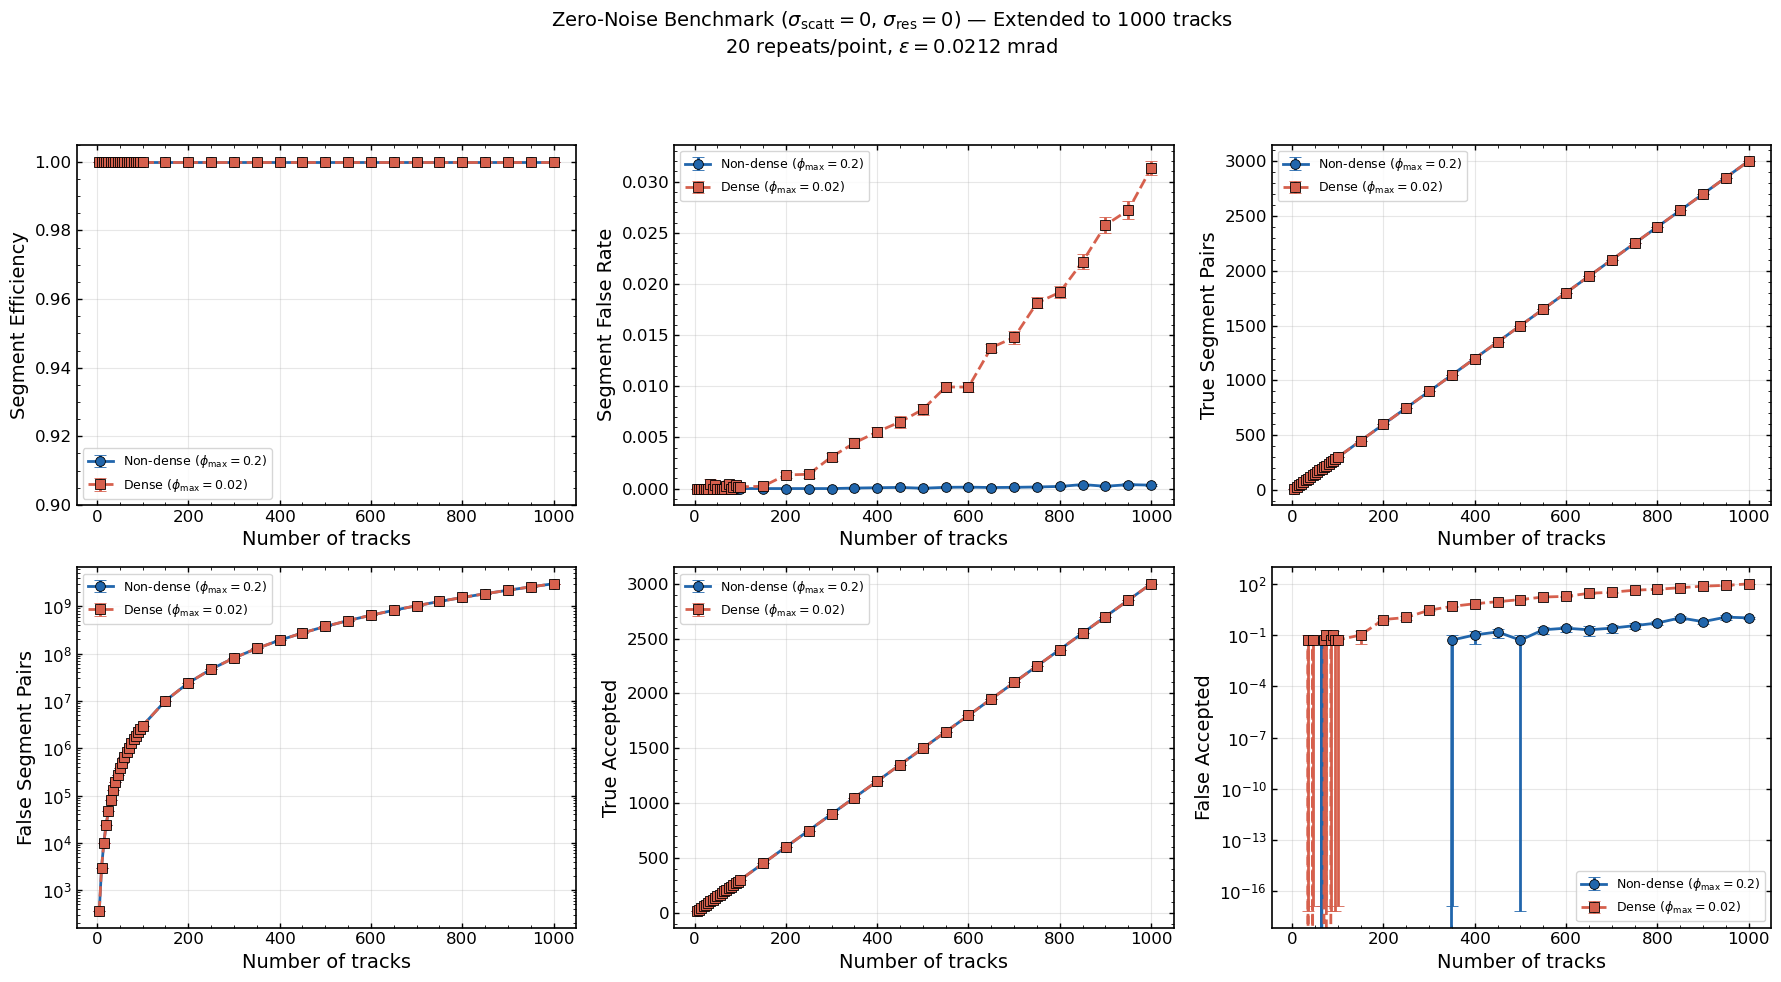

: 

In [ ]:
# ============================================================================
# 12f. Extended Zero-Noise Benchmark — 6-panel plot
# ============================================================================
regime_colors = {"non_dense": "#2166ac", "dense": "#d6604d"}
regime_labels_ext = {"non_dense": r"Non-dense ($\phi_{\max}=0.2$)",
                     "dense":     r"Dense ($\phi_{\max}=0.02$)"}
regime_fmts   = {"non_dense": "o-", "dense": "s--"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(r"Zero-Noise Benchmark ($\sigma_{\mathrm{scatt}} = 0$, $\sigma_{\mathrm{res}} = 0$)"
             f" — Extended to 1000 tracks\n{ZERO_N_REPEATS_EXT} repeats/point, "
             rf"$\varepsilon = {epsilon_zero_ext*1e3:.4f}$ mrad", fontsize=14)

metrics_6 = [
    ("segment_efficiency", "Segment Efficiency", True),
    ("segment_false_rate", "Segment False Rate", True),
    ("n_true",         "True Segment Pairs", False),
    ("n_false",        "False Segment Pairs", False),
    ("true_accepted",  "True Accepted",       False),
    ("false_accepted", "False Accepted",       False),
]

for ax, (col, ylabel, is_frac) in zip(axes.flat, metrics_6):
    for regime in ["non_dense", "dense"]:
        sub = df_zero_ext[df_zero_ext["regime"] == regime]
        grp = sub.groupby("n_tracks")[col]
        mean = grp.mean()
        se_  = grp.std(ddof=1) / np.sqrt(grp.count())
        ax.errorbar(mean.index, mean.values, yerr=se_.values,
                    fmt=regime_fmts[regime], color=regime_colors[regime],
                    capsize=4, capthick=1.2, linewidth=2, markersize=7,
                    markeredgecolor='black', markeredgewidth=0.6,
                    label=regime_labels_ext[regime])
    ax.set_xlabel("Number of tracks")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)
    if col == "segment_efficiency":
        ax.set_ylim(0.90, 1.005)
    if col in ("n_false", "false_accepted"):
        ax.set_yscale("log")

fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(OUT_DIR / 'zero_noise_benchmark_ext.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'zero_noise_benchmark_ext.pdf', bbox_inches='tight')
plt.show()

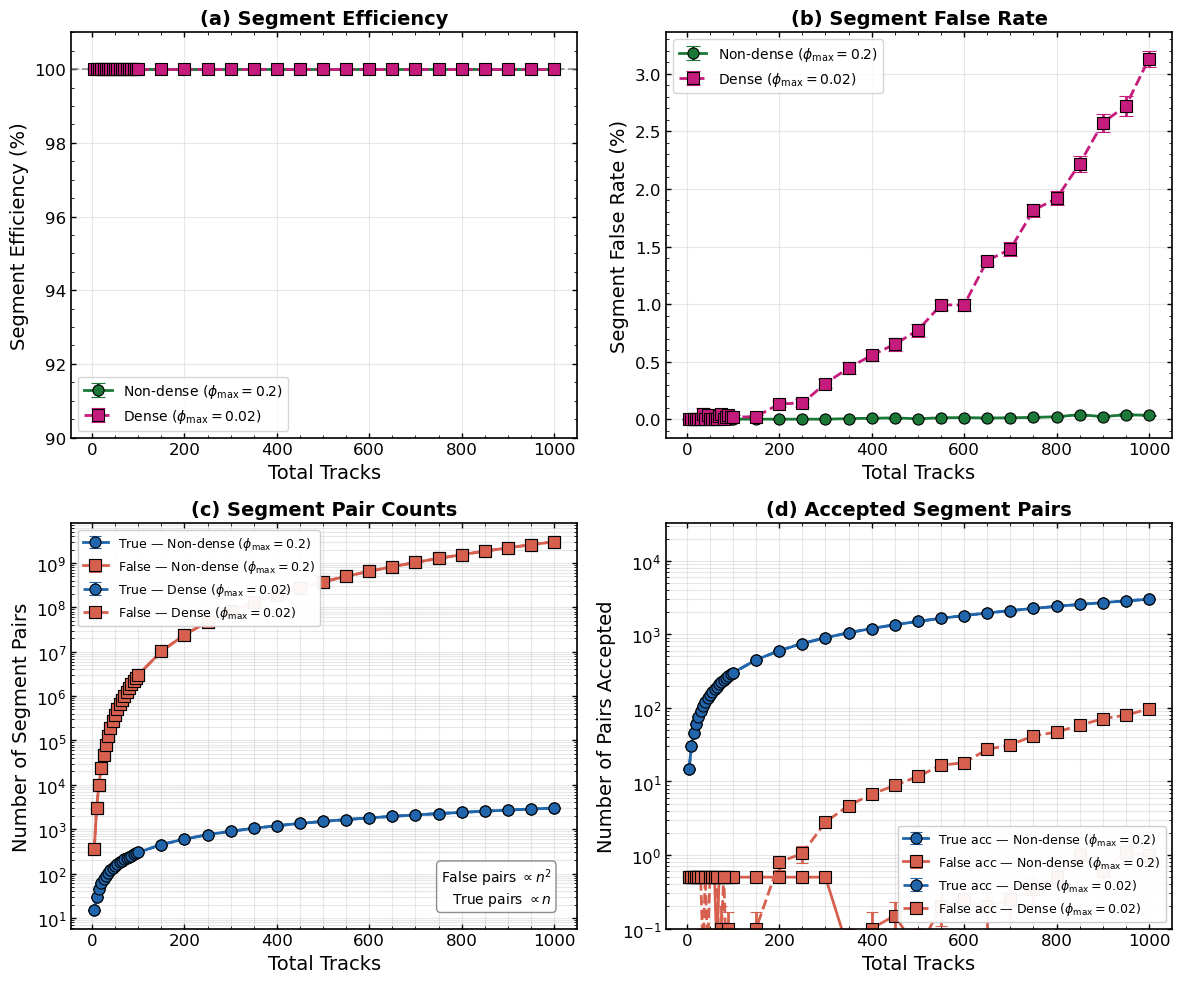

: 

In [ ]:
# ============================================================================
# 12f. Extended Zero-Noise Benchmark — Paper-Ready 2x2
# ============================================================================
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11,
    'figure.titlesize': 16, 'axes.linewidth': 1.2,
    'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
    'lines.linewidth': 2, 'lines.markersize': 8,
})

zero_plot_ext = {}
for regime in ["non_dense", "dense"]:
    sub = df_zero_ext[df_zero_ext["regime"] == regime]
    agg = sub.groupby("n_tracks").agg(
        seg_eff_mean=("segment_efficiency", "mean"),
        seg_eff_se=("segment_efficiency", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        false_rate_mean=("segment_false_rate", "mean"),
        false_rate_se=("segment_false_rate", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n_true_mean=("n_true", "mean"),
        n_true_se=("n_true", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n_false_mean=("n_false", "mean"),
        n_false_se=("n_false", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        true_acc_mean=("true_accepted", "mean"),
        true_acc_se=("true_accepted", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        false_acc_mean=("false_accepted", "mean"),
        false_acc_se=("false_accepted", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
    zero_plot_ext[regime] = agg

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

colors_zn = {"non_dense": '#1b7837', "dense": '#c51b7d'}
fmts_zn   = {"non_dense": 'o-',     "dense": 's--'}
labels_zn = {"non_dense": r'Non-dense ($\phi_{\max}=0.2$)',
             "dense":     r'Dense ($\phi_{\max}=0.02$)'}

# (a) Segment Efficiency
ax1 = axes[0, 0]
for regime in ["non_dense", "dense"]:
    d = zero_plot_ext[regime]
    ax1.errorbar(d.index, d["seg_eff_mean"] * 100, yerr=d["seg_eff_se"] * 100,
                 fmt=fmts_zn[regime], color=colors_zn[regime], capsize=5, capthick=1.5,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label=labels_zn[regime])
ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('Total Tracks')
ax1.set_ylabel('Segment Efficiency (%)')
ax1.set_title('(a) Segment Efficiency', fontweight='bold')
ax1.set_ylim(90, 101)
ax1.legend(fontsize=10, loc='lower left')
ax1.grid(True, alpha=0.3)
ax1.minorticks_on()
ax1.tick_params(which='both', direction='in', top=True, right=True)

# (b) Segment False Rate
ax2 = axes[0, 1]
for regime in ["non_dense", "dense"]:
    d = zero_plot_ext[regime]
    ax2.errorbar(d.index, d["false_rate_mean"] * 100, yerr=d["false_rate_se"] * 100,
                 fmt=fmts_zn[regime], color=colors_zn[regime], capsize=5, capthick=1.5,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label=labels_zn[regime])
ax2.set_xlabel('Total Tracks')
ax2.set_ylabel('Segment False Rate (%)')
ax2.set_title('(b) Segment False Rate', fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.minorticks_on()
ax2.tick_params(which='both', direction='in', top=True, right=True)

# (c) Segment Pair Counts
ax3 = axes[1, 0]
color_true_zn = '#2166ac'
color_false_zn = '#d6604d'
for regime in ["non_dense", "dense"]:
    d = zero_plot_ext[regime]
    style = '-' if regime == "non_dense" else '--'
    ax3.errorbar(d.index, d["n_true_mean"], yerr=d["n_true_se"],
                 fmt='o' + style, color=color_true_zn, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'True — {labels_zn[regime]}')
    ax3.errorbar(d.index, d["n_false_mean"], yerr=d["n_false_se"],
                 fmt='s' + style, color=color_false_zn, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'False — {labels_zn[regime]}')
ax3.set_yscale('log')
ax3.set_xlabel('Total Tracks')
ax3.set_ylabel('Number of Segment Pairs')
ax3.set_title('(c) Segment Pair Counts', fontweight='bold')
ax3.legend(loc='upper left', framealpha=0.95, fontsize=9)
ax3.grid(True, alpha=0.3, which='both')
ax3.minorticks_on()
ax3.tick_params(which='both', direction='in', top=True, right=True)
ax3.text(0.95, 0.05, r'False pairs $\propto n^2$' + '\n' + r'True pairs $\propto n$',
         transform=ax3.transAxes, fontsize=10, ha='right', va='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# (d) Accepted Segment Pairs
ax4 = axes[1, 1]
for regime in ["non_dense", "dense"]:
    d = zero_plot_ext[regime]
    style = '-' if regime == "non_dense" else '--'
    ax4.errorbar(d.index, d["true_acc_mean"], yerr=d["true_acc_se"],
                 fmt='o' + style, color=color_true_zn, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'True acc — {labels_zn[regime]}')
    fa_p = np.where(d["false_acc_mean"] > 0, d["false_acc_mean"], 0.5)
    fa_s = np.where(d["false_acc_mean"] > 0, d["false_acc_se"], 0)
    ax4.errorbar(d.index, fa_p, yerr=fa_s,
                 fmt='s' + style, color=color_false_zn, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'False acc — {labels_zn[regime]}')
ax4.set_yscale('log')
ax4.set_xlabel('Total Tracks')
ax4.set_ylabel('Number of Pairs Accepted')
ax4.set_title('(d) Accepted Segment Pairs', fontweight='bold')
ax4.legend(loc='lower right', framealpha=0.95, fontsize=9)
ax4.grid(True, alpha=0.3, which='both')
ax4.minorticks_on()
ax4.tick_params(which='both', direction='in', top=True, right=True)
ax4.set_ylim(0.1, None)

plt.tight_layout()
fig.savefig(OUT_DIR / 'zero_noise_benchmark_ext_paper.png', dpi=300,
            bbox_inches='tight', facecolor='white')
fig.savefig(OUT_DIR / 'zero_noise_benchmark_ext_paper.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# ============================================================================
# 12g. Extended Summary Tables & CSV Export
# ============================================================================
agg_cols = ["segment_efficiency", "segment_false_rate", "n_true", "n_false"]

print("=" * 80)
print("EXTENDED SCATTERING SWEEP SUMMARY")
print("=" * 80)
summary_scatt_ext = (df_seg_scatt_ext
    .groupby(["phi_max", "n_tracks", "sigma_scatt_mrad"])[agg_cols]
    .agg(["mean", "std"])
)
display(summary_scatt_ext.round(4))

print("\n" + "=" * 80)
print("EXTENDED RESOLUTION SWEEP SUMMARY")
print("=" * 80)
summary_res_ext = (df_seg_res_ext
    .groupby(["phi_max", "n_tracks", "sigma_res_mm"])[agg_cols]
    .agg(["mean", "std"])
)
display(summary_res_ext.round(4))

print("\n" + "=" * 80)
print("EXTENDED DENSITY SCAN SUMMARY")
print("=" * 80)
summary_dens_ext = (df_density_ext
    .groupby("n_tracks")[agg_cols]
    .agg(["mean", "std"])
)
display(summary_dens_ext.round(4))

# Save CSVs
df_seg_scatt_ext.to_csv(OUT_DIR / "segment_scattering_sweep_ext.csv", index=False)
df_seg_res_ext.to_csv(OUT_DIR / "segment_resolution_sweep_ext.csv", index=False)
df_density_ext.to_csv(OUT_DIR / "segment_density_scan_ext.csv", index=False)
df_zero_ext.to_csv(OUT_DIR / "segment_zero_noise_ext.csv", index=False)

print(f"\nSaved extended CSVs to {OUT_DIR}/")
for f in sorted(OUT_DIR.glob("*_ext*.csv")):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

EXTENDED SCATTERING SWEEP SUMMARY


segment_efficiency          \
                                                mean     std   
phi_max n_tracks sigma_scatt_mrad                              
0.02    10       0.05                         1.0000  0.0000   
                 0.10                         1.0000  0.0000   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
...                                              ...     ...   
0.20    1000     0.20                         0.9998  0.0002   
                 0.40                         0.9999  0.0003   
                 0.60                         0.9999  0.0001   
                 0.80                         0.9999  0.0002   
                 1.00                         0.9999  0.0001   

                                  segment_false_rate          n_true       \
                                                mean     std    mean  std   
phi_max n_tracks sigma_scatt_mrad                                           
0.02    10       0.05                         0.0000  0.0000    30.0  0.0   
                 0.10                         0.0000  0.0000    30.0  0.0   
                 0.20                         0.0277  0.0383    30.0  0.0   
                 0.40                         0.0365  0.0448    30.0  0.0   
                 0.60                         0.0860  0.0712    30.0  0.0   
...                                              ...     ...     ...  ...   
0.20    1000     0.20                         0.3690  0.0096  3000.0  0.0   
                 0.40                         0.7051  0.0074  3000.0  0.0   
                 0.60                         0.8385  0.0038  3000.0  0.0   
                 0.80                         0.9020  0.0030  3000.0  0.0   
                 1.00                         0.9355  0.0024  3000.0  0.0   

                                        n_false       
                                           mean  std  
phi_max n_tracks sigma_scatt_mrad                     
0.02    10       0.05              2.970000e+03  0.0  
                 0.10              2.970000e+03  0.0  
                 0.20              2.970000e+03  0.0  
                 0.40              2.970000e+03  0.0  
                 0.60              2.970000e+03  0.0  
...                                         ...  ...  
0.20    1000     0.20              2.999997e+09  0.0  
                 0.40              2.999997e+09  0.0  
                 0.60              2.999997e+09  0.0  
                 0.80              2.999997e+09  0.0  
                 1.00              2.999997e+09  0.0  

[98 rows x 8 columns]


EXTENDED RESOLUTION SWEEP SUMMARY


segment_efficiency         segment_false_rate  \
                                            mean     std               mean   
phi_max n_tracks sigma_res_mm                                                 
0.02    10       0.000                    1.0000  0.0000             0.0062   
                 0.005                    1.0000  0.0000             0.0097   
                 0.010                    1.0000  0.0000             0.1009   
                 0.015                    1.0000  0.0000             0.1705   
                 0.020                    1.0000  0.0000             0.3367   
...                                          ...     ...                ...   
0.20    1000     0.010                    0.9999  0.0002             0.8909   
                 0.015                    0.9998  0.0002             0.9481   
                 0.020                    1.0000  0.0001             0.9701   
                 0.030                    0.9999  0.0002             0.9866   
                 0.050                    1.0000  0.0001             0.9950   

                                       n_true            n_false       
                                  std    mean  std          mean  std  
phi_max n_tracks sigma_res_mm                                          
0.02    10       0.000         0.0198    30.0  0.0  2.970000e+03  0.0  
                 0.005         0.0156    30.0  0.0  2.970000e+03  0.0  
                 0.010         0.0586    30.0  0.0  2.970000e+03  0.0  
                 0.015         0.0968    30.0  0.0  2.970000e+03  0.0  
                 0.020         0.1250    30.0  0.0  2.970000e+03  0.0  
...                               ...     ...  ...           ...  ...  
0.20    1000     0.010         0.0030  3000.0  0.0  2.999997e+09  0.0  
                 0.015         0.0011  3000.0  0.0  2.999997e+09  0.0  
                 0.020         0.0007  3000.0  0.0  2.999997e+09  0.0  
                 0.030         0.0003  3000.0  0.0  2.999997e+09  0.0  
                 0.050         0.0001  3000.0  0.0  2.999997e+09  0.0  

[98 rows x 8 columns]


EXTENDED DENSITY SCAN SUMMARY


segment_efficiency         segment_false_rate          n_true       \
                       mean     std               mean     std    mean  std   
n_tracks                                                                      
5                    1.0000  0.0000             0.0000  0.0000    15.0  0.0   
10                   1.0000  0.0000             0.0000  0.0000    30.0  0.0   
15                   1.0000  0.0000             0.0000  0.0000    45.0  0.0   
20                   1.0000  0.0000             0.0000  0.0000    60.0  0.0   
25                   1.0000  0.0000             0.0000  0.0000    75.0  0.0   
30                   1.0000  0.0000             0.0000  0.0000    90.0  0.0   
35                   0.9981  0.0043             0.0000  0.0000   105.0  0.0   
40                   1.0000  0.0000             0.0017  0.0037   120.0  0.0   
45                   1.0000  0.0000             0.0000  0.0000   135.0  0.0   
50                   1.0000  0.0000             0.0000  0.0000   150.0  0.0   
55                   0.9988  0.0027             0.0000  0.0000   165.0  0.0   
60                   1.0000  0.0000             0.0000  0.0000   180.0  0.0   
65                   1.0000  0.0000             0.0020  0.0028   195.0  0.0   
70                   1.0000  0.0000             0.0009  0.0021   210.0  0.0   
75                   0.9991  0.0020             0.0009  0.0020   225.0  0.0   
80                   1.0000  0.0000             0.0017  0.0023   240.0  0.0   
85                   1.0000  0.0000             0.0016  0.0021   255.0  0.0   
90                   1.0000  0.0000             0.0022  0.0033   270.0  0.0   
95                   1.0000  0.0000             0.0000  0.0000   285.0  0.0   
100                  1.0000  0.0000             0.0020  0.0030   300.0  0.0   
150                  1.0000  0.0000             0.0031  0.0025   450.0  0.0   
200                  1.0000  0.0000             0.0053  0.0039   600.0  0.0   
250                  1.0000  0.0000             0.0069  0.0040   750.0  0.0   
300                  1.0000  0.0000             0.0136  0.0044   900.0  0.0   
350                  1.0000  0.0000             0.0165  0.0055  1050.0  0.0   
400                  1.0000  0.0000             0.0260  0.0049  1200.0  0.0   
450                  1.0000  0.0000             0.0285  0.0037  1350.0  0.0   
500                  0.9999  0.0003             0.0404  0.0067  1500.0  0.0   
550                  0.9998  0.0003             0.0436  0.0057  1650.0  0.0   
600                  1.0000  0.0000             0.0543  0.0064  1800.0  0.0   
650                  1.0000  0.0000             0.0589  0.0041  1950.0  0.0   
700                  1.0000  0.0000             0.0714  0.0047  2100.0  0.0   
750                  1.0000  0.0000             0.0756  0.0032  2250.0  0.0   
800                  0.9997  0.0003             0.0853  0.0060  2400.0  0.0   
850                  0.9999  0.0002             0.0985  0.0057  2550.0  0.0   
900                  0.9998  0.0002             0.1047  0.0085  2700.0  0.0   
950                  0.9999  0.0002             0.1159  0.0094  2850.0  0.0   
1000                 0.9999  0.0001             0.1285  0.0031  3000.0  0.0   

               n_false       
                  mean  std  
n_tracks                     
5         3.600000e+02  0.0  
10        2.970000e+03  0.0  
15        1.008000e+04  0.0  
20        2.394000e+04  0.0  
25        4.680000e+04  0.0  
30        8.091000e+04  0.0  
35        1.285200e+05  0.0  
40        1.918800e+05  0.0  
45        2.732400e+05  0.0  
50        3.748500e+05  0.0  
55        4.989600e+05  0.0  
60        6.478200e+05  0.0  
65        8.236800e+05  0.0  
70        1.028790e+06  0.0  
75        1.265400e+06  0.0  
80        1.535760e+06  0.0  
85        1.842120e+06  0.0  
90        2.186730e+06  0.0  
95        2.571840e+06  0.0  
100       2.999700e+06  0.0  
150       1.012455e+07  0.0  
200       2.399940e+07  0.0  
250       4.687425e


Saved extended CSVs to outputs/segment_analysis/
  segment_density_scan_ext.csv  (11.4 KB)
  segment_resolution_sweep_ext.csv  (77.9 KB)
  segment_scattering_sweep_ext.csv  (76.5 KB)
  segment_zero_noise_ext.csv  (106.4 KB)


: 

---

## 13. Paper-Ready Figures (Up to 1000 Tracks)

Standalone section collecting the key results from the extended analysis (§12) into
publication-quality figures. All plots use the same underlying data generated
with the **shared-middle-hit segment matcher** (`fast_segment_metrics`), which
reproduces the original paper's segment-pairing logic:

- Segments are formed between consecutive detector modules
- Segment *pairs* are formed only when two segments share a common middle hit
- The angle between direction vectors of a pair is compared to ε

This is the same method used in the original OBQF paper. The Numba-accelerated
implementation (`fast_segment_metrics`) is a validated drop-in replacement.

| Figure | Sweep variable | Track range | Repeats/point |
|--------|---------------|-------------|---------------|
| 13a | σ_scatt | 10 – 1000 | 10 |
| 13b | σ_res | 10 – 1000 | 10 |
| 13c | n_tracks (density) | 5 – 1000 | 5 |
| 13d | n_tracks (fixed ε) | 20 – 1000 | 20 |
| 13e | n_tracks (zero noise) | 5 – 1000 | 20 |

In [5]:
# ============================================================================
# 13. Paper-Ready Plot Settings
# ============================================================================
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 10,
    'figure.titlesize': 16, 'axes.linewidth': 1.2,
    'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
    'xtick.minor.width': 0.6, 'ytick.minor.width': 0.6,
    'lines.linewidth': 2, 'lines.markersize': 7,
})

# Shared palette for track counts
_tc_colors = {
    10: "#1b7837", 20: "#2166ac", 50: "#e08214", 100: "#c51b7d",
    200: "#7570b3", 500: "#d95f02", 1000: "#e7298a",
}
_tc_fmts = {
    10: "o-", 20: "s-", 50: "D-", 100: "^-",
    200: "v-", 500: "P-", 1000: "X-",
}

PAPER_DIR = OUT_DIR / "paper"
PAPER_DIR.mkdir(exist_ok=True)
print(f"Paper figures → {PAPER_DIR}/")
print(f"Segment matcher: fast_segment_metrics (shared-middle-hit, Numba-accelerated)")

Paper figures → outputs/segment_analysis/paper/
Segment matcher: fast_segment_metrics (shared-middle-hit, Numba-accelerated)


In [6]:
# ============================================================================
# Helper: apply_hit_noise  (used by §13d drop-rate comparison)
# ============================================================================
import copy

def apply_hit_noise(event, drop_rate=0.0, ghost_rate=0.0, rng=None):
    """Return a new event with hit-drop and ghost-hit noise applied.

    Parameters
    ----------
    event      : event object with .hits, .tracks, and .modules
    drop_rate  : fraction of real hits to randomly remove (0–1)
    ghost_rate : number of ghost hits added = int(n_hits * ghost_rate)
    rng        : numpy.random.Generator (optional; uses np.random if None)

    NOTE: must update both event.hits (flat Hit list) AND module.hit_ids,
    because SimpleHamiltonianFast.construct_segments reads hits via
    module.hit_ids + event.get_hit_by_id, not from event.hits directly.
    """
    if rng is None:
        rng = np.random.default_rng()

    # ── deep-copy the event so the original is untouched ──
    evt = copy.deepcopy(event)

    # ── drop hits ──
    if drop_rate > 0.0:
        kept_ids = set()
        new_hits = []
        for h in evt.hits:
            if rng.random() >= drop_rate:
                kept_ids.add(h.hit_id)
                new_hits.append(h)
        evt.hits = new_hits

        # filter hit_ids on each track
        for trk in evt.tracks:
            trk.hit_ids = [hid for hid in trk.hit_ids if hid in kept_ids]

        # filter hit_ids on each module (this is what construct_segments reads)
        for mod in evt.modules:
            mod.hit_ids = [hid for hid in mod.hit_ids if hid in kept_ids]

    # ── add ghost hits ──
    if ghost_rate > 0.0:
        n_ghosts = int(len(evt.hits) * ghost_rate)
        if n_ghosts > 0 and len(evt.hits) > 0:
            all_x  = np.array([h.x  for h in evt.hits])
            all_y  = np.array([h.y  for h in evt.hits])
            x_min, x_max = all_x.min(), all_x.max()
            y_min, y_max = all_y.min(), all_y.max()
            modules = list({h.module_id for h in evt.hits})
            max_id = max(h.hit_id for h in evt.hits)
            for k in range(n_ghosts):
                import types
                gh = types.SimpleNamespace()
                gh.hit_id    = max_id + k + 1
                gh.module_id = modules[rng.integers(len(modules))]
                mod_hits     = [h for h in evt.hits if h.module_id == gh.module_id]
                gh.z         = mod_hits[0].z if mod_hits else 0.0
                gh.x         = rng.uniform(x_min, x_max)
                gh.y         = rng.uniform(y_min, y_max)
                gh.track_id  = -1
                evt.hits.append(gh)

    return evt


Pairwise JIT compiled: 60 true, 720 false
  n_true              :     60  OK
  n_false             :    720  OK
  true_accepted       :     60  OK
  false_accepted      :      0  OK
Loaded pairwise fixed-epsilon cache: 18 entries


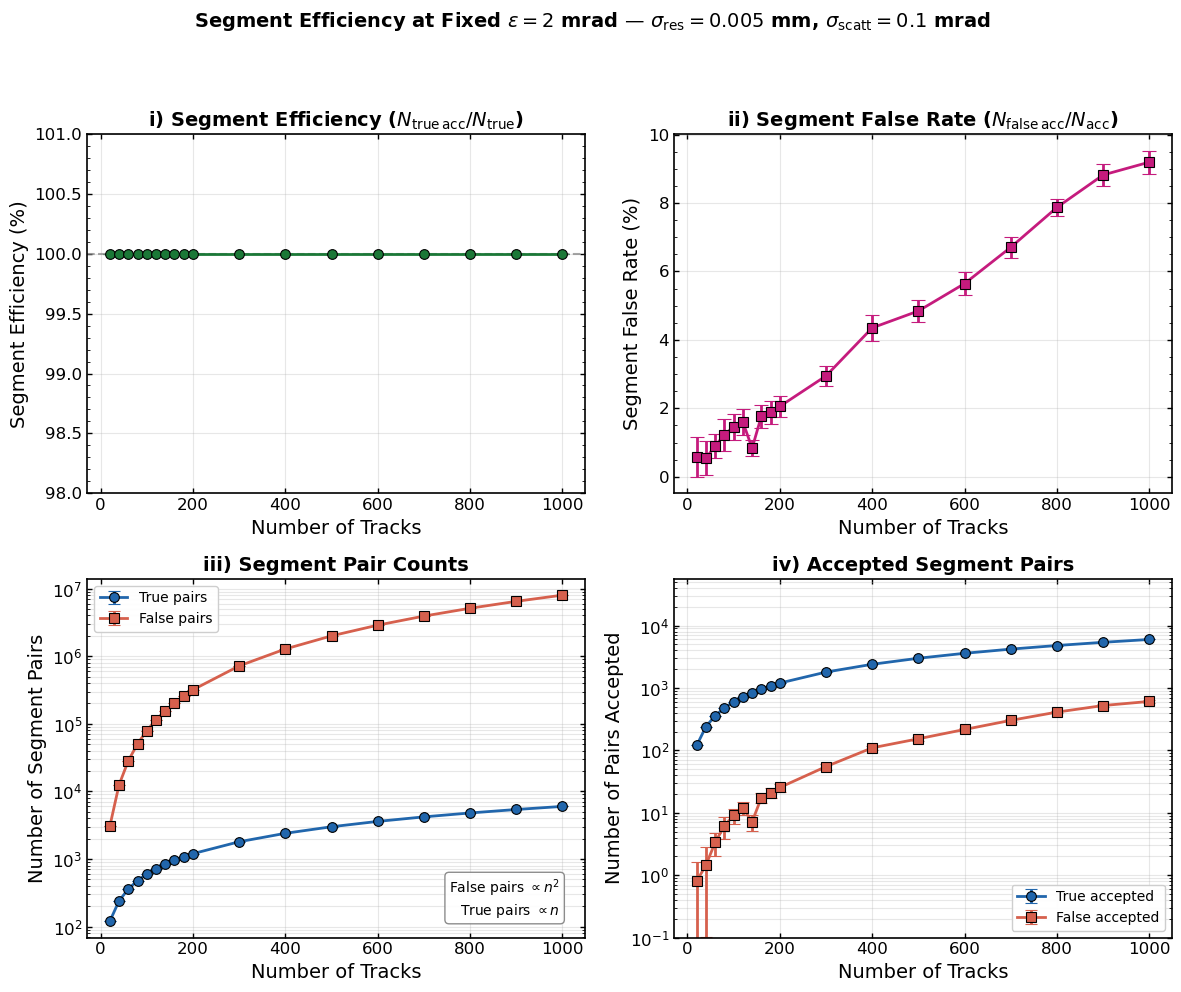

Saved fig13d fixed-epsilon efficiency


In [10]:

# ============================================================================
# 13d. Segment Efficiency at Fixed ε (up to 1000 tracks)
#      Shared-middle-hit segment method (fast_segment_metrics)
# ============================================================================
import math
from numba import njit, prange

# ── Numba kernel: all pairs (i<j) of segment direction vectors ──
@njit(parallel=True)
def _pairwise_seg_counts(vx, vy, vz, norms, tids, cos_eps):
    """Count true/false/accepted for every (i<j) pair of segments."""
    n = len(vx)
    nt_arr = np.zeros(n, dtype=np.int64)
    nf_arr = np.zeros(n, dtype=np.int64)
    ta_arr = np.zeros(n, dtype=np.int64)
    fa_arr = np.zeros(n, dtype=np.int64)

    for i in prange(n):
        ni = norms[i]
        if ni == 0.0:
            continue
        uix = vx[i] / ni
        uiy = vy[i] / ni
        uiz = vz[i] / ni
        tid_i = tids[i]
        for j in range(i + 1, n):
            nj = norms[j]
            if nj == 0.0:
                continue
            cos_a = uix * (vx[j] / nj) + uiy * (vy[j] / nj) + uiz * (vz[j] / nj)
            if cos_a > 1.0:
                cos_a = 1.0
            elif cos_a < -1.0:
                cos_a = -1.0

            is_true = (tid_i >= 0) and (tid_i == tids[j])
            if is_true:
                nt_arr[i] += 1
                if cos_a >= cos_eps:
                    ta_arr[i] += 1
            else:
                nf_arr[i] += 1
                if cos_a >= cos_eps:
                    fa_arr[i] += 1

    return nt_arr.sum(), nf_arr.sum(), ta_arr.sum(), fa_arr.sum()


def fast_pairwise_metrics(event, epsilon):
    """All-pairs segment direction comparison (original paper method).

    Extracts truth-track segments (consecutive hit pairs), compares every
    pair (i<j). A pair is 'true' if both segments belong to the same track.
    n_false scales as n^2 (NOT n^3 like the shared-middle-hit method).
    """
    cos_eps = math.cos(epsilon)
    hit_lookup = {h.hit_id: h for h in event.hits}

    svx, svy, svz, snorm, stid = [], [], [], [], []
    for track in event.tracks:
        hids = track.hit_ids
        tid = track.track_id if track.track_id is not None else -1
        for k in range(len(hids) - 1):
            hf, ht = hit_lookup[hids[k]], hit_lookup[hids[k + 1]]
            dx, dy, dz = ht.x - hf.x, ht.y - hf.y, ht.z - hf.z
            svx.append(dx); svy.append(dy); svz.append(dz)
            snorm.append(math.sqrt(dx*dx + dy*dy + dz*dz))
            stid.append(tid)

    vx = np.array(svx, dtype=np.float64)
    vy = np.array(svy, dtype=np.float64)
    vz = np.array(svz, dtype=np.float64)
    nrm = np.array(snorm, dtype=np.float64)
    tid = np.array(stid, dtype=np.int64)

    nt, nf, ta, fa = _pairwise_seg_counts(vx, vy, vz, nrm, tid, cos_eps)
    nt, nf, ta, fa = int(nt), int(nf), int(ta), int(fa)
    total_acc = ta + fa
    return {
        "n_true": nt, "n_false": nf,
        "true_accepted": ta, "false_accepted": fa,
        "segment_efficiency": ta / nt if nt > 0 else 0.0,
        "segment_false_rate": fa / total_acc if total_acc > 0 else 0.0,
    }

# ── JIT warmup ──
_warmup_evt = safe_generate(10, measurement_error=0.0, collision_noise=1e-4,
                            phi_max=0.2, theta_max=0.2)
_m_pw = fast_pairwise_metrics(_warmup_evt, 0.002)
print(f"Pairwise JIT compiled: {_m_pw['n_true']} true, {_m_pw['n_false']} false")

# ── Validate against pure-Python compute_segment_angles_old ──
_ta_old, _fa_old = compute_segment_angles_old(_warmup_evt)
_m_old = compute_segment_metrics_old(_ta_old, _fa_old, 0.002)
for _k in ["n_true", "n_false", "true_accepted", "false_accepted"]:
    _match = "OK" if _m_pw[_k] == _m_old[_k] else f"MISMATCH fast={_m_pw[_k]} old={_m_old[_k]}"
    print(f"  {_k:20s}: {_m_pw[_k]:6d}  {_match}")

# ── Data collection ──
import time as _time
_cache_file = CACHE_DIR / "segment_efficiency_pairwise_ext.pkl"
if _cache_file.exists():
    with open(_cache_file, "rb") as f:
        seg_eff_results_ext = pickle.load(f)
    print(f"Loaded pairwise fixed-epsilon cache: {len(seg_eff_results_ext)} entries")
else:
    seg_eff_results_ext = []
    _t0 = _time.time()
    for n_trk in FIXED_TRACK_COUNTS_EXT:
        per_repeat_data = []
        for rep in range(N_REPEATS_FIXED_EXT):
            np.random.seed(rep + n_trk * 100 + 800000)
            event = safe_generate(n_trk, measurement_error=FIXED_RESOLUTION,
                                  collision_noise=FIXED_SCATTERING,
                                  phi_max=0.2, theta_max=0.2)
            m = fast_pairwise_metrics(event, FIXED_EPSILON)
            per_repeat_data.append(m)

        eff_per = np.array([r["segment_efficiency"] for r in per_repeat_data])
        fr_per  = np.array([r["segment_false_rate"]  for r in per_repeat_data])
        nt_per  = np.array([r["n_true"]              for r in per_repeat_data])
        nf_per  = np.array([r["n_false"]             for r in per_repeat_data])
        ta_per  = np.array([r["true_accepted"]       for r in per_repeat_data])
        fa_per  = np.array([r["false_accepted"]      for r in per_repeat_data])
        nr = len(per_repeat_data)

        seg_eff_results_ext.append({
            "total_tracks": n_trk,
            "n_repeats": nr,
            "seg_efficiency_mean": np.mean(eff_per),
            "seg_efficiency_se":   np.std(eff_per, ddof=1) / np.sqrt(nr),
            "seg_false_rate_mean": np.mean(fr_per),
            "seg_false_rate_se":   np.std(fr_per, ddof=1) / np.sqrt(nr),
            "n_true_mean":    np.mean(nt_per),
            "n_true_se":      np.std(nt_per, ddof=1) / np.sqrt(nr),
            "n_false_mean":   np.mean(nf_per),
            "n_false_se":     np.std(nf_per, ddof=1) / np.sqrt(nr),
            "true_acc_mean":  np.mean(ta_per),
            "true_acc_se":    np.std(ta_per, ddof=1) / np.sqrt(nr),
            "false_acc_mean": np.mean(fa_per),
            "false_acc_se":   np.std(fa_per, ddof=1) / np.sqrt(nr),
            "per_repeat": per_repeat_data,
        })
        print(f"  fixed-eps: n_trk={n_trk:4d}  eff={np.mean(eff_per)*100:.2f}%  "
              f"fr={np.mean(fr_per)*100:.2f}%  n_false={np.mean(nf_per):.0f}  "
              f"({_time.time()-_t0:.0f}s)")

    with open(_cache_file, "wb") as f:
        pickle.dump(seg_eff_results_ext, f)
    print(f"Saved pairwise fixed-epsilon cache: {len(seg_eff_results_ext)} entries "
          f"({_time.time()-_t0:.0f}s)")

# ── Plot ──
color_eff   = '#1b7837'
color_fr    = '#c51b7d'
color_true  = '#2166ac'
color_false = '#d6604d'

tc  = np.array([r['total_tracks']            for r in seg_eff_results_ext])
se_ = np.array([r['seg_efficiency_mean']*100 for r in seg_eff_results_ext])
see = np.array([r['seg_efficiency_se']*100   for r in seg_eff_results_ext])
fr_ = np.array([r['seg_false_rate_mean']*100 for r in seg_eff_results_ext])
fre = np.array([r['seg_false_rate_se']*100   for r in seg_eff_results_ext])
ntm = np.array([r['n_true_mean']             for r in seg_eff_results_ext])
nts = np.array([r['n_true_se']               for r in seg_eff_results_ext])
nfm = np.array([r['n_false_mean']            for r in seg_eff_results_ext])
nfs = np.array([r['n_false_se']              for r in seg_eff_results_ext])
tam = np.array([r['true_acc_mean']           for r in seg_eff_results_ext])
tas = np.array([r['true_acc_se']             for r in seg_eff_results_ext])
fam = np.array([r['false_acc_mean']          for r in seg_eff_results_ext])
fas = np.array([r['false_acc_se']            for r in seg_eff_results_ext])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = axes[0, 0]
ax1.errorbar(tc, se_, yerr=see, fmt='o-', color=color_eff, capsize=5,
             capthick=1.5, markeredgecolor='black', markeredgewidth=0.8)
ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_ylabel('Segment Efficiency (%)')
ax1.set_title(r'i) Segment Efficiency ($N_{\mathrm{true\,acc}} / N_{\mathrm{true}}$)',
              fontweight='bold')
ax1.set_ylim(min(se_) - 2, 101)
ax1.grid(True, alpha=0.3)
ax1.minorticks_on()
ax1.tick_params(which='both', direction='in', top=True, right=True)

ax2 = axes[0, 1]
ax2.errorbar(tc, fr_, yerr=fre, fmt='s-', color=color_fr, capsize=5,
             capthick=1.5, markeredgecolor='black', markeredgewidth=0.8)
ax2.set_ylabel('Segment False Rate (%)')
ax2.set_title(r'ii) Segment False Rate ($N_{\mathrm{false\,acc}} / N_{\mathrm{acc}}$)',
              fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.minorticks_on()
ax2.tick_params(which='both', direction='in', top=True, right=True)

ax3 = axes[1, 0]
ax3.errorbar(tc, ntm, yerr=nts, fmt='o-', color=color_true, capsize=4,
             capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
             label='True pairs')
ax3.errorbar(tc, nfm, yerr=nfs, fmt='s-', color=color_false, capsize=4,
             capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
             label='False pairs')
ax3.set_yscale('log')
ax3.set_ylabel('Number of Segment Pairs')
ax3.set_title('iii) Segment Pair Counts', fontweight='bold')
ax3.legend(loc='upper left', framealpha=0.95)
ax3.grid(True, alpha=0.3, which='both')
ax3.minorticks_on()
ax3.tick_params(which='both', direction='in', top=True, right=True)
ax3.text(0.95, 0.05, r'False pairs $\propto n^2$' + '\n' + r'True pairs $\propto n$',
         transform=ax3.transAxes, fontsize=10, ha='right', va='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

ax4 = axes[1, 1]
fa_plot = np.where(fam > 0, fam, 0.5)
fa_se_plot = np.where(fam > 0, fas, 0)
ax4.errorbar(tc, tam, yerr=tas, fmt='o-', color=color_true, capsize=4,
             capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
             label='True accepted')
ax4.errorbar(tc, fa_plot, yerr=fa_se_plot, fmt='s-', color=color_false,
             capsize=4, capthick=1.2, markeredgecolor='black',
             markeredgewidth=0.8, label='False accepted')
ax4.set_yscale('log')
ax4.set_ylabel('Number of Pairs Accepted')
ax4.set_title('iv) Accepted Segment Pairs', fontweight='bold')
ax4.legend(loc='lower right', framealpha=0.95)
ax4.grid(True, alpha=0.3, which='both')
ax4.minorticks_on()
ax4.tick_params(which='both', direction='in', top=True, right=True)
ax4.set_ylim(0.1, None)

for ax in axes.flat:
    ax.set_xlabel('Number of Tracks')

fig.suptitle(rf"Segment Efficiency at Fixed $\varepsilon = {FIXED_EPSILON*1e3:.0f}$ mrad — "
             rf"$\sigma_{{\mathrm{{res}}}} = {FIXED_RESOLUTION}$ mm, "
             rf"$\sigma_{{\mathrm{{scatt}}}} = {FIXED_SCATTERING*1e3:.1f}$ mrad",
             fontsize=14, fontweight='bold', y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon.png',
            dpi=300, bbox_inches='tight', facecolor='white')

# ── Log-x version ──
for _lx in axes.flat:
    _lx.set_xscale('log')
fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon_logx.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon_logx.png',
            dpi=300, bbox_inches='tight', facecolor='white')
for _lx in axes.flat:
    _lx.set_xscale('linear')

plt.show()
print("Saved fig13d fixed-epsilon efficiency")


In [11]:

# ============================================================================
# 13d-drop. Data collection: fixed-ε sweep with 1% hit-drop noise
# ============================================================================
DROP_RATE_1PCT = 0.01
_cache_drop = CACHE_DIR / "segment_efficiency_pairwise_ext_drop1pct.pkl"

if _cache_drop.exists():
    with open(_cache_drop, "rb") as f:
        seg_eff_results_ext_drop1 = pickle.load(f)
    print(f"Loaded 1%-drop fixed-epsilon cache: {len(seg_eff_results_ext_drop1)} entries")
else:
    rng_drop = np.random.default_rng(42)
    seg_eff_results_ext_drop1 = []
    _t0 = _time.time()
    for n_trk in FIXED_TRACK_COUNTS_EXT:
        per_repeat_data = []
        for rep in range(N_REPEATS_FIXED_EXT):
            np.random.seed(rep + n_trk * 100 + 800000)
            event_clean = safe_generate(n_trk, measurement_error=FIXED_RESOLUTION,
                                        collision_noise=FIXED_SCATTERING,
                                        phi_max=0.2, theta_max=0.2)
            event_noisy = apply_hit_noise(event_clean, drop_rate=DROP_RATE_1PCT,
                                          ghost_rate=0.0, rng=rng_drop)
            m = fast_pairwise_metrics(event_noisy, FIXED_EPSILON)
            per_repeat_data.append(m)

        eff_per = np.array([r["segment_efficiency"] for r in per_repeat_data])
        fr_per  = np.array([r["segment_false_rate"]  for r in per_repeat_data])
        nt_per  = np.array([r["n_true"]              for r in per_repeat_data])
        nf_per  = np.array([r["n_false"]             for r in per_repeat_data])
        ta_per  = np.array([r["true_accepted"]       for r in per_repeat_data])
        fa_per  = np.array([r["false_accepted"]      for r in per_repeat_data])
        nr = len(per_repeat_data)

        seg_eff_results_ext_drop1.append({
            "total_tracks": n_trk,
            "n_repeats": nr,
            "seg_efficiency_mean": np.mean(eff_per),
            "seg_efficiency_se":   np.std(eff_per, ddof=1) / np.sqrt(nr),
            "seg_false_rate_mean": np.mean(fr_per),
            "seg_false_rate_se":   np.std(fr_per, ddof=1) / np.sqrt(nr),
            "n_true_mean":    np.mean(nt_per),
            "n_true_se":      np.std(nt_per, ddof=1) / np.sqrt(nr),
            "n_false_mean":   np.mean(nf_per),
            "n_false_se":     np.std(nf_per, ddof=1) / np.sqrt(nr),
            "true_acc_mean":  np.mean(ta_per),
            "true_acc_se":    np.std(ta_per, ddof=1) / np.sqrt(nr),
            "false_acc_mean": np.mean(fa_per),
            "false_acc_se":   np.std(fa_per, ddof=1) / np.sqrt(nr),
        })
        print(f"  drop=1%  n_trk={n_trk:4d}  eff={np.mean(eff_per)*100:.2f}%  "
              f"fr={np.mean(fr_per)*100:.2f}%  ({_time.time()-_t0:.0f}s)")

    with open(_cache_drop, "wb") as f:
        pickle.dump(seg_eff_results_ext_drop1, f)
    print(f"Saved 1%-drop cache: {len(seg_eff_results_ext_drop1)} entries "
          f"({_time.time()-_t0:.0f}s)")


Loaded 1%-drop fixed-epsilon cache: 18 entries


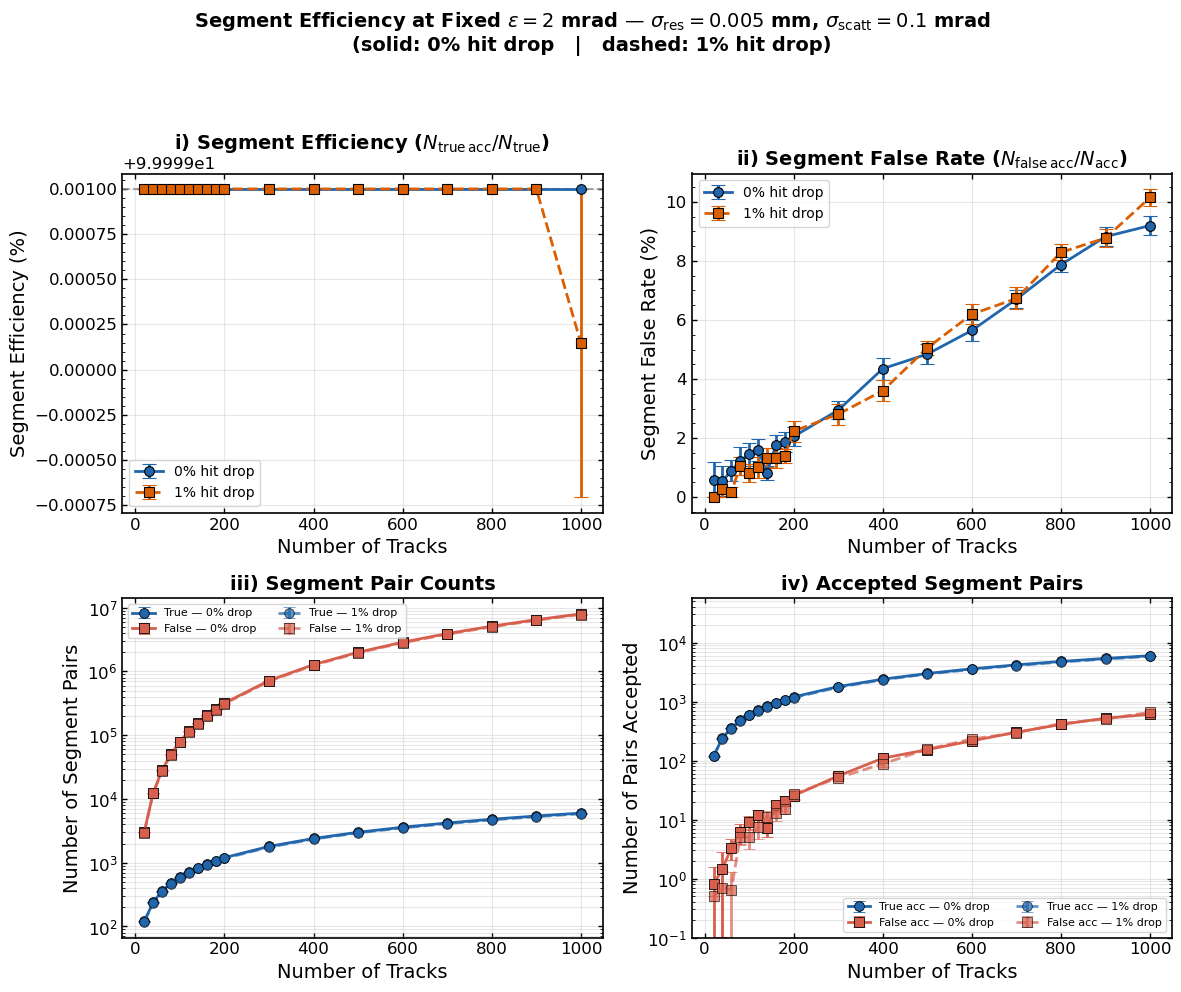

Saved fig13d overlay (0% hit drop vs 1% drop)


In [12]:

# ============================================================================
# 13d-overlay. Superimposed plot: 0% hit-drop vs 1% hit-drop
# ============================================================================
def _extract_arrays(results):
    tc  = np.array([r['total_tracks']            for r in results])
    se_ = np.array([r['seg_efficiency_mean']*100 for r in results])
    see = np.array([r['seg_efficiency_se']*100   for r in results])
    fr_ = np.array([r['seg_false_rate_mean']*100 for r in results])
    fre = np.array([r['seg_false_rate_se']*100   for r in results])
    ntm = np.array([r['n_true_mean']             for r in results])
    nts = np.array([r['n_true_se']               for r in results])
    nfm = np.array([r['n_false_mean']            for r in results])
    nfs = np.array([r['n_false_se']              for r in results])
    tam = np.array([r['true_acc_mean']           for r in results])
    tas = np.array([r['true_acc_se']             for r in results])
    fam = np.array([r['false_acc_mean']          for r in results])
    fas = np.array([r['false_acc_se']            for r in results])
    return tc, se_, see, fr_, fre, ntm, nts, nfm, nfs, tam, tas, fam, fas

_d0  = _extract_arrays(seg_eff_results_ext)
_d1  = _extract_arrays(seg_eff_results_ext_drop1)

c_base = '#2166ac'   # 0% hit drop — blue
c_drop = '#d95f02'   # 1% drop — orange

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── i) Segment Efficiency ──
ax = axes[0, 0]
ax.errorbar(_d0[0], _d0[1], yerr=_d0[2], fmt='o-', color=c_base, capsize=5,
            capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
            label='0% hit drop')
ax.errorbar(_d1[0], _d1[1], yerr=_d1[2], fmt='s--', color=c_drop, capsize=5,
            capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
            label='1% hit drop')
ax.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_ylabel('Segment Efficiency (%)')
ax.set_title(r'i) Segment Efficiency ($N_{\mathrm{true\,acc}} / N_{\mathrm{true}}$)',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

# ── ii) Segment False Rate ──
ax = axes[0, 1]
ax.errorbar(_d0[0], _d0[3], yerr=_d0[4], fmt='o-', color=c_base, capsize=5,
            capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
            label='0% hit drop')
ax.errorbar(_d1[0], _d1[3], yerr=_d1[4], fmt='s--', color=c_drop, capsize=5,
            capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
            label='1% hit drop')
ax.set_ylabel('Segment False Rate (%)')
ax.set_title(r'ii) Segment False Rate ($N_{\mathrm{false\,acc}} / N_{\mathrm{acc}}$)',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

# ── iii) Segment Pair Counts ──
ax = axes[1, 0]
color_true  = '#2166ac'
color_false = '#d6604d'
ax.errorbar(_d0[0], _d0[5], yerr=_d0[6], fmt='o-',  color=color_true, capsize=4,
            capthick=1.2, markeredgecolor='black', markeredgewidth=0.6,
            label='True — 0% drop')
ax.errorbar(_d0[0], _d0[7], yerr=_d0[8], fmt='s-',  color=color_false, capsize=4,
            capthick=1.2, markeredgecolor='black', markeredgewidth=0.6,
            label='False — 0% drop')
ax.errorbar(_d1[0], _d1[5], yerr=_d1[6], fmt='o--', color=color_true, capsize=4,
            capthick=1.2, markeredgecolor='black', markeredgewidth=0.6, alpha=0.7,
            label='True — 1% drop')
ax.errorbar(_d1[0], _d1[7], yerr=_d1[8], fmt='s--', color=color_false, capsize=4,
            capthick=1.2, markeredgecolor='black', markeredgewidth=0.6, alpha=0.7,
            label='False — 1% drop')
ax.set_yscale('log')
ax.set_ylabel('Number of Segment Pairs')
ax.set_title('iii) Segment Pair Counts', fontweight='bold')
ax.legend(fontsize=8, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3, which='both')
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

# ── iv) Accepted Segment Pairs ──
ax = axes[1, 1]
fa_plot0    = np.where(_d0[11] > 0, _d0[11], 0.5)
fa_se_plot0 = np.where(_d0[11] > 0, _d0[12], 0)
fa_plot1    = np.where(_d1[11] > 0, _d1[11], 0.5)
fa_se_plot1 = np.where(_d1[11] > 0, _d1[12], 0)
ax.errorbar(_d0[0], _d0[9],    yerr=_d0[10],    fmt='o-',  color=color_true, capsize=4,
            capthick=1.2, markeredgecolor='black', markeredgewidth=0.6,
            label='True acc — 0% drop')
ax.errorbar(_d0[0], fa_plot0,  yerr=fa_se_plot0, fmt='s-',  color=color_false, capsize=4,
            capthick=1.2, markeredgecolor='black', markeredgewidth=0.6,
            label='False acc — 0% drop')
ax.errorbar(_d1[0], _d1[9],    yerr=_d1[10],    fmt='o--', color=color_true, capsize=4,
            capthick=1.2, markeredgecolor='black', markeredgewidth=0.6, alpha=0.7,
            label='True acc — 1% drop')
ax.errorbar(_d1[0], fa_plot1,  yerr=fa_se_plot1, fmt='s--', color=color_false, capsize=4,
            capthick=1.2, markeredgecolor='black', markeredgewidth=0.6, alpha=0.7,
            label='False acc — 1% drop')
ax.set_yscale('log')
ax.set_ylabel('Number of Pairs Accepted')
ax.set_title('iv) Accepted Segment Pairs', fontweight='bold')
ax.legend(fontsize=8, loc='lower right', ncol=2)
ax.grid(True, alpha=0.3, which='both')
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.set_ylim(0.1, None)

for ax in axes.flat:
    ax.set_xlabel('Number of Tracks')

fig.suptitle(rf"Segment Efficiency at Fixed $\varepsilon = {FIXED_EPSILON*1e3:.0f}$ mrad — "
             rf"$\sigma_{{\mathrm{{res}}}} = {FIXED_RESOLUTION}$ mm, "
             rf"$\sigma_{{\mathrm{{scatt}}}} = {FIXED_SCATTERING*1e3:.1f}$ mrad"
             "\n(solid: 0% hit drop   |   dashed: 1% hit drop)",
             fontsize=14, fontweight='bold', y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon_overlay_drop1pct.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon_overlay_drop1pct.png',
            dpi=300, bbox_inches='tight', facecolor='white')

# ── Log-x version ──
for _lx in axes.flat:
    _lx.set_xscale('log')
fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon_overlay_drop1pct_logx.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon_overlay_drop1pct_logx.png',
            dpi=300, bbox_inches='tight', facecolor='white')
for _lx in axes.flat:
    _lx.set_xscale('linear')

plt.show()
print("Saved fig13d overlay (0% hit drop vs 1% drop)")


In [13]:
fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon_drop1pct.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon_drop1pct.png',
            dpi=300, bbox_inches='tight', facecolor='white')

# Log-x variant for the slide deck (same data, x-axes log-scaled).
for _ax in axes.flat:
    _ax.set_xscale('log')
fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon_drop1pct_logx.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon_drop1pct_logx.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig13d standalone 1% hit-drop (linear + log-x)")

Saved fig13d standalone 1% hit-drop (linear + log-x)


In [39]:
# ── DIAGNOSTIC: verify apply_hit_noise now affects module.hit_ids ─────────────
import copy
np.random.seed(99)
_ev_c = safe_generate(20, measurement_error=FIXED_RESOLUTION, collision_noise=FIXED_SCATTERING)
_rng_diag = np.random.default_rng(7)
_ev_n = apply_hit_noise(_ev_c, drop_rate=0.10, ghost_rate=0.0, rng=_rng_diag)  # 10% drop

_h_c = SimpleHamiltonianFast(epsilon=FIXED_EPSILON, gamma=GAMMA, delta=DELTA)
_h_c.construct_segments(_ev_c)
_h_n = SimpleHamiltonianFast(epsilon=FIXED_EPSILON, gamma=GAMMA, delta=DELTA)
_h_n.construct_segments(_ev_n)

_nt_c = sum(1 for s in _h_c.segments if s.hit_start.track_id==s.hit_end.track_id>=0)
_nt_n = sum(1 for s in _h_n.segments if s.hit_start.track_id==s.hit_end.track_id>=0)
print(f"Flat hits  : clean={len(_ev_c.hits)}  noisy={len(_ev_n.hits)}")
print(f"Module hits: clean={sum(len(m.hit_ids) for m in _ev_c.modules)}  noisy={sum(len(m.hit_ids) for m in _ev_n.modules)}")
print(f"Segments   : clean={_h_c.n_segments}  noisy={_h_n.n_segments}")
print(f"True segs  : clean={_nt_c}  noisy={_nt_n}")
print(f"Efficiency with clean denom: {_nt_n/_nt_c*100:.1f}%")


Flat hits  : clean=100  noisy=89
Module hits: clean=100  noisy=89
Segments   : clean=1600  noisy=1225
True segs  : clean=80  noisy=61
Efficiency with clean denom: 76.2%


---
## Section 14 - Solver Segment Efficiency (Classical Hamiltonian)

This section mirrors Section 13d but replaces the pure-geometry triplet-angle kernel
(`fast_segment_metrics`) with the **classical Hamiltonian solver**
(`SimpleHamiltonianFast`, gamma=3, delta=1).

The solver constructs **all adjacent-module hit pairs** and solves Ax=b.
A segment is *active* iff its activation exceeds the baseline:
$$x_i > \frac{\delta}{\delta + \gamma} = 0.25$$

| Panel | Metric | Formula |
|---|---|---|
| i) | Segment efficiency | $N_{\rm true\,active}/N_{\rm true\,all}$ |
| ii) | False rate | $N_{\rm false\,active}/N_{\rm active}$ |
| iii) | Total segment pairs | $N_{\rm true\,all}$ and $N_{\rm false\,all}$ vs $N_{\rm tracks}$ |
| iv) | Active segment pairs | $N_{\rm true\,active}$ and $N_{\rm false\,active}$ vs $N_{\rm tracks}$ |

**Fixed parameters**: gamma=3, delta=1.0, threshold=0.25,
epsilon = 2 mrad, sigma_res=5 um, sigma_scatt=0.1 mrad.

> **Note**: `segment.track_id` is always -1 in the solver candidate segments.
> Truth is determined by `seg.hit_start.track_id == seg.hit_end.track_id >= 0`.

In [6]:

# ============================================================
# Section 14  Setup: constants and vectorised Hamiltonian builder
# ============================================================
import time as _time14
from scipy.sparse import coo_matrix as _coo14

FIXED_EPSILON       = 0.002    # 2 mrad – same as §13 sections
FIXED_RESOLUTION    = 0.005    # 5 µm measurement error
FIXED_SCATTERING    = 1e-4     # 0.1 mrad collision noise
SOLVER_TRACK_COUNTS = [2, 4, 6, 8, 10, 15, 20, 30, 40, 50, 60, 75, 100,
                       150, 200, 300, 500, 750, 1000]
# Adaptive repeats: more at low n (cheap), fewer at high n (expensive but
# per-event variance is smaller because N_seg ∝ n² gives tight statistics).
def _repeats_for(n_trk):
    if n_trk <= 100:  return 60
    if n_trk <= 300:  return 30
    return 15
N_REPEATS_SOLVER    = 60          # kept for legacy readout (n≤100 path)
SOLVER_THRESHOLD    = 0.35        # between outer-segment plateau (~0.375) and 0.25 attractor
DROP_RATE_SOLVER    = 0.01

print(f"Track counts  : {SOLVER_TRACK_COUNTS}")
print(f"Repeats policy: 60 (n≤100) / 30 (100<n≤300) / 15 (n>300)")
print(f"Threshold     : {SOLVER_THRESHOLD:.4f}  (Hopfield fixed point = {DELTA/(DELTA+GAMMA):.4f})")
print(f"Fixed epsilon : {FIXED_EPSILON*1000:.1f} mrad")


def _build_ham_vectorized(ham):
    """Fast vectorised Hamiltonian build, exactly matches
    SimpleHamiltonianFast.construct_hamiltonian().

    Uses the library's cached arrays `_segment_to_hit_ids` and
    `_segment_vectors` directly to avoid Python-level iteration over
    Segment objects. Rows/cols/vals stay as numpy arrays throughout.
    """
    n = ham.n_segments
    if n == 0:
        ham.A = _coo14((n, n)).tocsc()
        ham.b = np.zeros(n)
        return

    _sth = ham._segment_to_hit_ids        # (n, 2) or list of pairs
    hit_ids   = np.asarray(_sth, dtype=np.int64)
    start_ids = hit_ids[:, 0]
    end_ids   = hit_ids[:, 1]
    vecs      = np.asarray(ham._segment_vectors, dtype=np.float64)  # (n, 3) unit
    cos_eps   = float(np.cos(ham.epsilon))

    # Group segment indices by start-hit and end-hit via argsort+np.unique.
    order_s  = np.argsort(start_ids, kind='stable')
    order_e  = np.argsort(end_ids,   kind='stable')
    sorted_s = start_ids[order_s]
    sorted_e = end_ids[order_e]
    uniq_s, first_s = np.unique(sorted_s, return_index=True)
    uniq_e, first_e = np.unique(sorted_e, return_index=True)
    first_s = np.append(first_s, n)
    first_e = np.append(first_e, n)
    # end_map[mid] = indices of segs whose end_hit_id == mid
    end_map = {int(uniq_e[i]): order_e[first_e[i]:first_e[i+1]]
               for i in range(len(uniq_e))}

    # Accumulate off-diagonal (r,c,v) tuples per middle hit.
    chunks_r, chunks_c, chunks_v = [], [], []

    for k in range(len(uniq_s)):
        mid = int(uniq_s[k])
        sid_i_arr = end_map.get(mid)
        if sid_i_arr is None:
            continue
        sid_j_arr = order_s[first_s[k]:first_s[k+1]]
        if sid_i_arr.size == 0 or sid_j_arr.size == 0:
            continue
        cos_mat = vecs[sid_i_arr] @ vecs[sid_j_arr].T
        np.clip(cos_mat, -1.0, 1.0, out=cos_mat)
        ii, jj = np.where(cos_mat >= cos_eps)
        if ii.size == 0:
            continue
        ri = sid_i_arr[ii]
        cj = sid_j_arr[jj]
        # Symmetric: +1 at (i,j) and (j,i).
        chunks_r.append(np.concatenate([ri, cj]))
        chunks_c.append(np.concatenate([cj, ri]))
        chunks_v.append(np.ones(2 * ri.size, dtype=np.float64))

    diag_val = -(ham.delta + ham.gamma)
    diag_idx = np.arange(n, dtype=np.int64)

    if chunks_r:
        off_r = np.concatenate(chunks_r)
        off_c = np.concatenate(chunks_c)
        off_v = np.concatenate(chunks_v)
    else:
        off_r = np.empty(0, dtype=np.int64)
        off_c = np.empty(0, dtype=np.int64)
        off_v = np.empty(0, dtype=np.float64)

    rows = np.concatenate([diag_idx, off_r])
    cols = np.concatenate([diag_idx, off_c])
    vals = np.concatenate([np.full(n, diag_val, dtype=np.float64), off_v])

    A = _coo14((vals, (rows, cols)), shape=(n, n)).tocsc()
    ham.A = -A
    ham.b = np.ones(n) * ham.delta


def _segment_truth_from_ham(ham):
    """Return boolean truth array (is_true_segment) using library's
    cached _segment_to_hit_ids and Event's hit-to-track map."""
    return np.array(
        [s.hit_start.track_id == s.hit_end.track_id
         and s.hit_start.track_id >= 0
         for s in ham.segments])


def _count_true_segments(event):
    """Count true segments on an event without solving — cheap, segments only."""
    ham = SimpleHamiltonianFast(epsilon=FIXED_EPSILON, gamma=GAMMA, delta=DELTA)
    ham.construct_segments(event)
    return int(_segment_truth_from_ham(ham).sum())


def _solver_metrics(event, n_true_clean=None):
    """Run classical solver on event; return segment truth/active counts.

    Parameters
    ----------
    event         : the event to solve (may be noisy)
    n_true_clean  : true-segment count on the *clean* version of this event.
                    If provided, used as the efficiency denominator so that
                    hit-drop losses are reflected in the efficiency metric.
                    If None, falls back to the event's own n_true_all.
    """
    ham = SimpleHamiltonianFast(epsilon=FIXED_EPSILON, gamma=GAMMA, delta=DELTA)
    ham.construct_segments(event)
    _build_ham_vectorized(ham)
    sol    = ham.solve_classicaly()
    active = sol > SOLVER_THRESHOLD

    truth = _segment_truth_from_ham(ham)

    n_true_all     = int(truth.sum())
    n_false_all    = ham.n_segments - n_true_all
    n_true_active  = int((active & truth).sum())
    n_active       = int(active.sum())
    n_false_active = n_active - n_true_active

    return {
        'n_true_all':     n_true_all,
        'n_true_clean':   n_true_clean if n_true_clean is not None else n_true_all,
        'n_false_all':    n_false_all,
        'n_true_active':  n_true_active,
        'n_false_active': n_false_active,
        'n_active':       n_active,
    }


def _agg_solver(raw):
    """Aggregate per-repeat raw dicts into plot-ready arrays.

    Efficiency denominator is n_true_clean (= n_true_all for 0%-drop baseline;
    = clean-event segment count for the 1%-drop case, so dropped segments
    count as missed).
    """
    tc   = np.array(SOLVER_TRACK_COUNTS, dtype=float)
    se_m, se_e = [], []
    fr_m, fr_e = [], []
    ntm, ntse  = [], []
    nfm, nfse  = [], []
    tam, tase  = [], []
    fam, fase  = [], []

    for k in SOLVER_TRACK_COUNTS:
        recs = raw[k]
        nr   = len(recs)
        eff  = np.array([r['n_true_active'] / max(r['n_true_clean'], 1) * 100
                         for r in recs])
        na_a = np.array([r['n_active'] for r in recs], dtype=float)
        fr   = np.array([r['n_false_active'] / max(na, 1) * 100
                         for r, na in zip(recs, na_a)])
        def sem14(a): return a.std(ddof=1) / np.sqrt(nr) if nr > 1 else 0.
        se_m.append(eff.mean());  se_e.append(sem14(eff))
        fr_m.append(fr.mean());   fr_e.append(sem14(fr))
        _nt = np.array([r['n_true_all']     for r in recs])
        _nf = np.array([r['n_false_all']    for r in recs])
        _ta = np.array([r['n_true_active']  for r in recs])
        _fa = np.array([r['n_false_active'] for r in recs])
        ntm.append(_nt.mean());  ntse.append(sem14(_nt))
        nfm.append(_nf.mean());  nfse.append(sem14(_nf))
        tam.append(_ta.mean());  tase.append(sem14(_ta))
        fam.append(_fa.mean());  fase.append(sem14(_fa))

    return dict(tc=tc,
                se_m=np.array(se_m),  se_e=np.array(se_e),
                fr_m=np.array(fr_m),  fr_e=np.array(fr_e),
                ntm=np.array(ntm),    ntse=np.array(ntse),
                nfm=np.array(nfm),    nfse=np.array(nfse),
                tam=np.array(tam),    tase=np.array(tase),
                fam=np.array(fam),    fase=np.array(fase))


# colour palette (matches Section 13d)
_c14_eff   = '#1b7837'
_c14_fr    = '#c51b7d'
_c14_true  = '#2166ac'
_c14_false = '#d6604d'
_c14_base  = '#1f78b4'
_c14_drop  = '#e31a1c'

print("Section 14 setup complete.")


Track counts  : [2, 4, 6, 8, 10, 15, 20, 30, 40, 50, 60, 75, 100, 150, 200, 300, 500, 750, 1000]
Repeats policy: 60 (n≤100) / 30 (100<n≤300) / 15 (n>300)
Threshold     : 0.3500  (Hopfield fixed point = 0.2500)
Fixed epsilon : 2.0 mrad
Section 14 setup complete.


In [23]:

# Sanity-check: fast builder matches library construct_hamiltonian exactly,
# and check Gershgorin discs are strictly positive (matrix SPD).
_ev_chk = safe_generate(20, measurement_error=FIXED_RESOLUTION,
                        collision_noise=FIXED_SCATTERING,
                        phi_max=0.2, theta_max=0.2)

_h_lib  = SimpleHamiltonianFast(epsilon=FIXED_EPSILON, gamma=GAMMA, delta=DELTA)
_h_lib.construct_hamiltonian(_ev_chk)

_h_fast = SimpleHamiltonianFast(epsilon=FIXED_EPSILON, gamma=GAMMA, delta=DELTA)
_h_fast.construct_segments(_ev_chk)
_build_ham_vectorized(_h_fast)

_A1 = _h_lib.A.toarray()
_A2 = _h_fast.A.toarray()
print(f"n_segments        : {_h_lib.n_segments}")
print(f"A matrices equal  : {np.allclose(_A1, _A2)}")
print(f"b vectors equal   : {np.allclose(_h_lib.b, _h_fast.b)}")
print(f"diag[0]           : lib={_A1[0,0]:.3f}  fast={_A2[0,0]:.3f}  (expected {DELTA+GAMMA:.3f})")

_d = np.diag(_A1)
_rad = np.abs(_A1).sum(axis=1) - np.abs(_d)
print(f"Gershgorin bound  : min(d_i - r_i) = {(_d - _rad).min():.3f}  (>0 ⇒ SPD)")
print(f"                    max off-row-sum= {_rad.max():.1f}")
print(f"Solution range    : sol ∈ [{_h_lib.solve_classicaly().min():.3f},"
      f" {_h_lib.solve_classicaly().max():.3f}]")


n_segments        : 1600
A matrices equal  : True
b vectors equal   : True
diag[0]           : lib=4.000  fast=4.000  (expected 4.000)
Gershgorin bound  : min(d_i - r_i) = 2.000  (>0 ⇒ SPD)
                    max off-row-sum= 2.0
Solution range    : sol ∈ [0.250, 0.455]


In [10]:

# ============================================================
# Section 14a.  Data collection: 0% hit drop (base)
# ============================================================
_cache14_base = CACHE_DIR / 'solver_segment_efficiency_ext.pkl'

# Load existing cache (if any) and incrementally fill in any missing track counts.
if _cache14_base.exists():
    with open(_cache14_base, 'rb') as _f:
        _sol_base = pickle.load(_f)
    print(f"Loaded solver-base cache: {len(_sol_base)} entries")
else:
    _sol_base = {}

_missing_base = [k for k in SOLVER_TRACK_COUNTS if k not in _sol_base]
if _missing_base:
    _t14 = _time14.time()
    for n_trk in _missing_base:
        _nrep = _repeats_for(n_trk)
        recs = []
        _t0 = _time14.time()
        for rep in range(_nrep):
            np.random.seed(rep + n_trk * 100 + 140000)
            ev = safe_generate(n_trk,
                               measurement_error=float(FIXED_RESOLUTION),
                               collision_noise=float(FIXED_SCATTERING))
            recs.append(_solver_metrics(ev))
        _sol_base[n_trk] = recs
        _eff_now = np.mean([r['n_true_active'] / max(r['n_true_all'], 1) for r in recs])
        _fr_now  = np.mean([r['n_false_active'] / max(r['n_active'],  1) for r in recs])
        print(f"  n={n_trk:4d}  reps={_nrep:2d}  eff={_eff_now*100:.2f}%  "
              f"fr={_fr_now*100:.2f}%  ({_time14.time()-_t0:.1f}s for this point,"
              f" {_time14.time()-_t14:.0f}s total)")
        # persist after every point so interrupted runs retain progress
        with open(_cache14_base, 'wb') as _f:
            pickle.dump(_sol_base, _f)
    print(f"Saved solver-base cache: {len(_sol_base)} entries  ({_time14.time()-_t14:.0f}s)")
else:
    print("All track counts already cached — nothing to compute.")

_agg_base = _agg_solver(_sol_base)
print(f"Base aggregation: {len(_agg_base['tc'])} points  (threshold={SOLVER_THRESHOLD:.3f})")


Loaded solver-base cache: 19 entries
All track counts already cached — nothing to compute.
Base aggregation: 19 points  (threshold=0.350)


In [11]:

# ============================================================
# Section 14b.  Data collection: 1% hit drop
#
# Efficiency denominator = n_true_clean (segments on clean event).
# This means segments that are structurally destroyed by hit drops
# count as missed, giving a physically meaningful efficiency < 100%.
# ============================================================
_cache14_drop = CACHE_DIR / 'solver_segment_efficiency_ext_drop1pct.pkl'

if _cache14_drop.exists():
    with open(_cache14_drop, 'rb') as _f:
        _sol_drop = pickle.load(_f)
    print(f"Loaded solver-drop cache: {len(_sol_drop)} entries")
else:
    _sol_drop = {}

_rng_drop14 = np.random.default_rng(42)
_missing_drop = [k for k in SOLVER_TRACK_COUNTS if k not in _sol_drop]
if _missing_drop:
    _t14d = _time14.time()
    for n_trk in _missing_drop:
        _nrep = _repeats_for(n_trk)
        recs = []
        _t0 = _time14.time()
        for rep in range(_nrep):
            np.random.seed(rep + n_trk * 100 + 140000)
            ev_clean = safe_generate(n_trk,
                                     measurement_error=float(FIXED_RESOLUTION),
                                     collision_noise=float(FIXED_SCATTERING))
            # Count true segments on the clean event — this is our denominator
            n_true_clean = _count_true_segments(ev_clean)

            ev_noisy = apply_hit_noise(ev_clean,
                                       drop_rate=DROP_RATE_SOLVER,
                                       ghost_rate=0.0,
                                       rng=_rng_drop14)
            recs.append(_solver_metrics(ev_noisy, n_true_clean=n_true_clean))
        _sol_drop[n_trk] = recs
        _eff_d = np.mean([r['n_true_active'] / max(r['n_true_clean'], 1) for r in recs])
        _fr_d  = np.mean([r['n_false_active'] / max(r['n_active'],    1) for r in recs])
        print(f"  n={n_trk:4d}  reps={_nrep:2d}  eff={_eff_d*100:.2f}%  "
              f"fr={_fr_d*100:.2f}%  ({_time14.time()-_t0:.1f}s for this point,"
              f" {_time14.time()-_t14d:.0f}s total)")
        with open(_cache14_drop, 'wb') as _f:
            pickle.dump(_sol_drop, _f)
    print(f"Saved solver-drop cache: {len(_sol_drop)} entries  ({_time14.time()-_t14d:.0f}s)")
else:
    print("All track counts already cached — nothing to compute.")

_agg_drop = _agg_solver(_sol_drop)
print(f"Drop aggregation: {len(_agg_drop['tc'])} points  (drop={DROP_RATE_SOLVER*100:.0f}%)")


Loaded solver-drop cache: 19 entries
All track counts already cached — nothing to compute.
Drop aggregation: 19 points  (drop=1%)


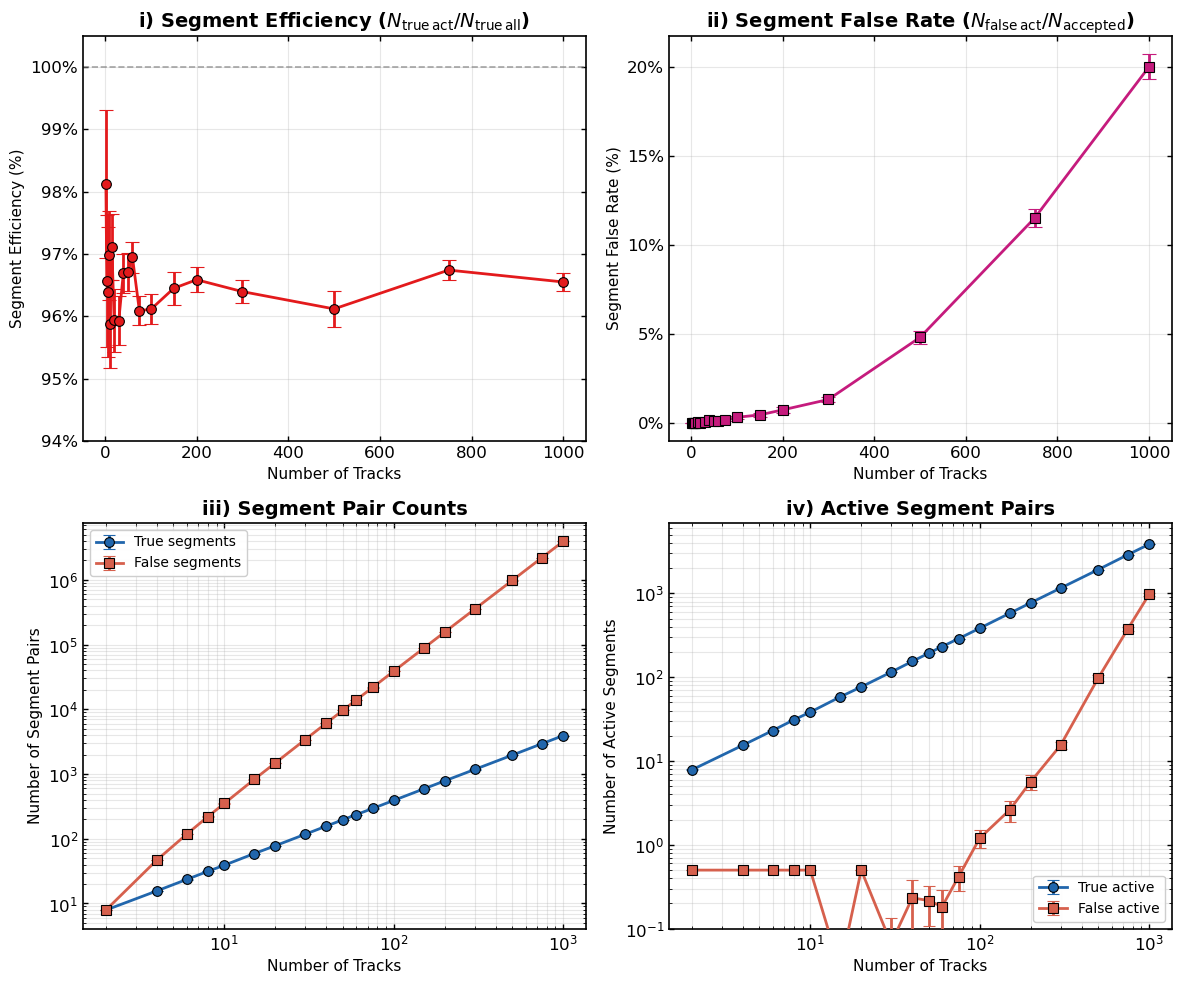

Saved fig14_solver_segment_efficiency_drop1pct


In [11]:
# ============================================================
# Section 14e.  Standalone 2x2 plot: 1% hit drop only
#   - i, ii: linear x-axis (segment efficiency, segment false rate)
#   - iii, iv: log x-axis (segment pair counts, active segment pairs)
# ============================================================
import matplotlib.ticker as _mt14s

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
d1 = _agg_drop
tc = d1['tc']

# i) Segment efficiency  (linear x)
ax = axes[0, 0]
ax.errorbar(tc, d1['se_m'], yerr=d1['se_e'], fmt='o-', color=_c14_drop,
            capsize=5, capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
            zorder=3)
ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)
_emin14s = max(0, np.floor((d1['se_m'] - d1['se_e']).min()) - 1)
ax.set_ylim(_emin14s, 100.5)
ax.set_yticks(np.arange(int(_emin14s), 101, 1))
ax.set_ylabel('Segment Efficiency (%)', fontsize=11)
ax.set_title(r'i) Segment Efficiency ($N_{\mathrm{true\,act}} / N_{\mathrm{true\,all}}$)',
             fontweight='bold')
ax.grid(True, alpha=0.3, zorder=1)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.yaxis.set_major_formatter(_mt14s.FormatStrFormatter('%g%%'))

# ii) Segment false rate  (linear x)
ax = axes[0, 1]
ax.errorbar(tc, d1['fr_m'], yerr=d1['fr_e'], fmt='s-', color=_c14_fr,
            capsize=5, capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
            zorder=3)
ax.set_ylabel('Segment False Rate (%)', fontsize=11)
ax.set_title(r'ii) Segment False Rate ($N_{\mathrm{false\,act}} / N_{\mathrm{accepted}}$)',
             fontweight='bold')
ax.grid(True, alpha=0.3, zorder=1)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.yaxis.set_major_formatter(_mt14s.FormatStrFormatter('%g%%'))

# iii) Total segment pairs  (log x, log y)
ax = axes[1, 0]
ax.errorbar(tc, d1['ntm'], yerr=d1['ntse'], fmt='o-', color=_c14_true,
            capsize=4, capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
            label='True segments', zorder=3)
ax.errorbar(tc, d1['nfm'], yerr=d1['nfse'], fmt='s-', color=_c14_false,
            capsize=4, capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
            label='False segments', zorder=3)
ax.set_yscale('log')
ax.set_ylabel('Number of Segment Pairs', fontsize=11)
ax.set_title('iii) Segment Pair Counts', fontweight='bold')
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)
ax.grid(True, alpha=0.3, which='both', zorder=1)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

# iv) Active segment pairs  (log x, log y)
ax = axes[1, 1]
_fa_p14s = np.where(d1['fam'] > 0, d1['fam'],  0.5)
_fa_e14s = np.where(d1['fam'] > 0, d1['fase'], 0.0)
ax.errorbar(tc, d1['tam'], yerr=d1['tase'], fmt='o-', color=_c14_true,
            capsize=4, capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
            label='True active', zorder=3)
ax.errorbar(tc, _fa_p14s, yerr=_fa_e14s, fmt='s-', color=_c14_false,
            capsize=4, capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
            label='False active', zorder=3)
ax.set_yscale('log')
ax.set_ylim(0.1, None)
ax.set_ylabel('Number of Active Segments', fontsize=11)
ax.set_title('iv) Active Segment Pairs', fontweight='bold')
ax.legend(loc='lower right', framealpha=0.95, fontsize=10)
ax.grid(True, alpha=0.3, which='both', zorder=1)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

for ax in axes.flat:
    ax.set_xlabel('Number of Tracks', fontsize=11)
# Bottom row: log x for panels iii) and iv)
for ax in axes[1, :]:
    ax.set_xscale('log')

fig.tight_layout()

_stem14s = 'fig14_solver_segment_efficiency_drop1pct'
fig.savefig(PAPER_DIR / f'{_stem14s}.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(PAPER_DIR / f'{_stem14s}.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved {_stem14s}")


Loaded zero-noise cache: 1520 rows


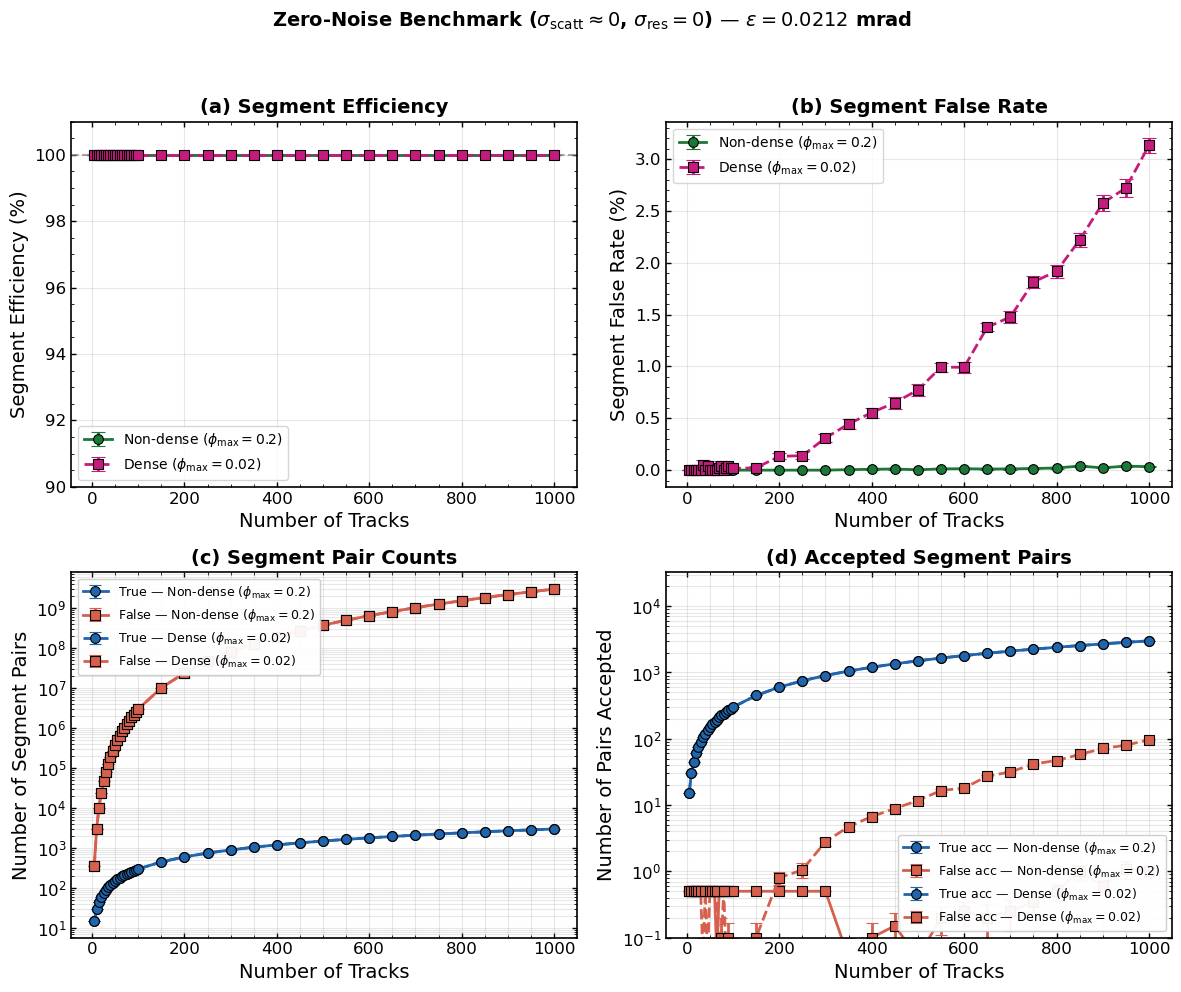

Saved fig13e zero-noise benchmark


: 

: 

: 

: 

: 

In [ ]:
# ============================================================================
# 13e. Zero-Noise Benchmark (up to 1000 tracks)
# ============================================================================
_cache_file = CACHE_DIR / "df_zero_noise_ext.csv"
if _cache_file.exists():
    df_zero_ext = pd.read_csv(_cache_file)
    print(f"Loaded zero-noise cache: {len(df_zero_ext)} rows")
else:
    import time as _time
    rows = []
    _t0 = _time.time()
    label_seed_offset = {"dense": 0, "non_dense": 1}
    for label, phi_max in ZERO_CONE_SETTINGS.items():
        for n_trk in ZERO_TRACK_COUNTS_EXT:
            for rep in range(ZERO_N_REPEATS_EXT):
                np.random.seed(rep + n_trk * 100
                               + label_seed_offset[label] * 10000 + 900000)
                event = safe_generate(n_trk, measurement_error=ZERO_SIGMA_RES_EXT,
                                      collision_noise=ZERO_SIGMA_SCATT_EXT,
                                      phi_max=phi_max, theta_max=phi_max)
                m = fast_segment_metrics(event, epsilon_zero_ext)
                rows.append({
                    "regime": label,
                    "phi_max": phi_max,
                    "n_tracks": n_trk,
                    "repeat": rep,
                    "epsilon": epsilon_zero_ext,
                    **m,
                })
            if n_trk % 100 == 0:
                print(f"  zero-noise: {label}, n_trk={n_trk} done "
                      f"({_time.time()-_t0:.0f}s)")
    df_zero_ext = pd.DataFrame(rows)
    df_zero_ext.to_csv(_cache_file, index=False)
    print(f"Saved zero-noise cache: {len(df_zero_ext)} rows "
          f"({_time.time()-_t0:.0f}s)")

# ── Plot ──
zn_colors = {"non_dense": '#1b7837', "dense": '#c51b7d'}
zn_fmts   = {"non_dense": 'o-',     "dense": 's--'}
zn_labels = {"non_dense": r'Non-dense ($\phi_{\max}=0.2$)',
             "dense":     r'Dense ($\phi_{\max}=0.02$)'}

zn_agg = {}
for regime in ["non_dense", "dense"]:
    sub = df_zero_ext[df_zero_ext["regime"] == regime]
    agg = sub.groupby("n_tracks").agg(
        eff_mean=("segment_efficiency", "mean"),
        eff_se=("segment_efficiency", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        fr_mean=("segment_false_rate", "mean"),
        fr_se=("segment_false_rate", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        nt_mean=("n_true", "mean"),
        nt_se=("n_true", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        nf_mean=("n_false", "mean"),
        nf_se=("n_false", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        ta_mean=("true_accepted", "mean"),
        ta_se=("true_accepted", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        fa_mean=("false_accepted", "mean"),
        fa_se=("false_accepted", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
    zn_agg[regime] = agg

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

color_true_zn  = '#2166ac'
color_false_zn = '#d6604d'

ax1 = axes[0, 0]
for regime in ["non_dense", "dense"]:
    d = zn_agg[regime]
    ax1.errorbar(d.index, d["eff_mean"] * 100, yerr=d["eff_se"] * 100,
                 fmt=zn_fmts[regime], color=zn_colors[regime], capsize=5,
                 capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
                 label=zn_labels[regime])
ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_ylabel('Segment Efficiency (%)')
ax1.set_title('(a) Segment Efficiency', fontweight='bold')
ax1.set_ylim(90, 101)
ax1.legend(fontsize=10, loc='lower left')
ax1.grid(True, alpha=0.3)
ax1.minorticks_on()
ax1.tick_params(which='both', direction='in', top=True, right=True)

ax2 = axes[0, 1]
for regime in ["non_dense", "dense"]:
    d = zn_agg[regime]
    ax2.errorbar(d.index, d["fr_mean"] * 100, yerr=d["fr_se"] * 100,
                 fmt=zn_fmts[regime], color=zn_colors[regime], capsize=5,
                 capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
                 label=zn_labels[regime])
ax2.set_ylabel('Segment False Rate (%)')
ax2.set_title('(b) Segment False Rate', fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.minorticks_on()
ax2.tick_params(which='both', direction='in', top=True, right=True)

ax3 = axes[1, 0]
for regime in ["non_dense", "dense"]:
    d = zn_agg[regime]
    style = '-' if regime == "non_dense" else '--'
    ax3.errorbar(d.index, d["nt_mean"], yerr=d["nt_se"],
                 fmt='o' + style, color=color_true_zn, capsize=4, capthick=1.2,
                 markeredgecolor='black', markeredgewidth=0.8,
                 label=f'True — {zn_labels[regime]}')
    ax3.errorbar(d.index, d["nf_mean"], yerr=d["nf_se"],
                 fmt='s' + style, color=color_false_zn, capsize=4, capthick=1.2,
                 markeredgecolor='black', markeredgewidth=0.8,
                 label=f'False — {zn_labels[regime]}')
ax3.set_yscale('log')
ax3.set_ylabel('Number of Segment Pairs')
ax3.set_title('(c) Segment Pair Counts', fontweight='bold')
ax3.legend(loc='upper left', framealpha=0.95, fontsize=9)
ax3.grid(True, alpha=0.3, which='both')
ax3.minorticks_on()
ax3.tick_params(which='both', direction='in', top=True, right=True)

ax4 = axes[1, 1]
for regime in ["non_dense", "dense"]:
    d = zn_agg[regime]
    style = '-' if regime == "non_dense" else '--'
    ax4.errorbar(d.index, d["ta_mean"], yerr=d["ta_se"],
                 fmt='o' + style, color=color_true_zn, capsize=4, capthick=1.2,
                 markeredgecolor='black', markeredgewidth=0.8,
                 label=f'True acc — {zn_labels[regime]}')
    fa_p = np.where(d["fa_mean"] > 0, d["fa_mean"], 0.5)
    fa_s = np.where(d["fa_mean"] > 0, d["fa_se"], 0)
    ax4.errorbar(d.index, fa_p, yerr=fa_s,
                 fmt='s' + style, color=color_false_zn, capsize=4, capthick=1.2,
                 markeredgecolor='black', markeredgewidth=0.8,
                 label=f'False acc — {zn_labels[regime]}')
ax4.set_yscale('log')
ax4.set_ylabel('Number of Pairs Accepted')
ax4.set_title('(d) Accepted Segment Pairs', fontweight='bold')
ax4.legend(loc='lower right', framealpha=0.95, fontsize=9)
ax4.grid(True, alpha=0.3, which='both')
ax4.minorticks_on()
ax4.tick_params(which='both', direction='in', top=True, right=True)
ax4.set_ylim(0.1, None)

for ax in axes.flat:
    ax.set_xlabel('Number of Tracks')

fig.suptitle(r"Zero-Noise Benchmark ($\sigma_{\mathrm{scatt}} \approx 0$, "
             r"$\sigma_{\mathrm{res}} = 0$)"
             rf" — $\varepsilon = {epsilon_zero_ext*1e3:.4f}$ mrad",
             fontsize=14, fontweight='bold', y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig(PAPER_DIR / 'fig13e_zero_noise.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(PAPER_DIR / 'fig13e_zero_noise.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig13e zero-noise benchmark")

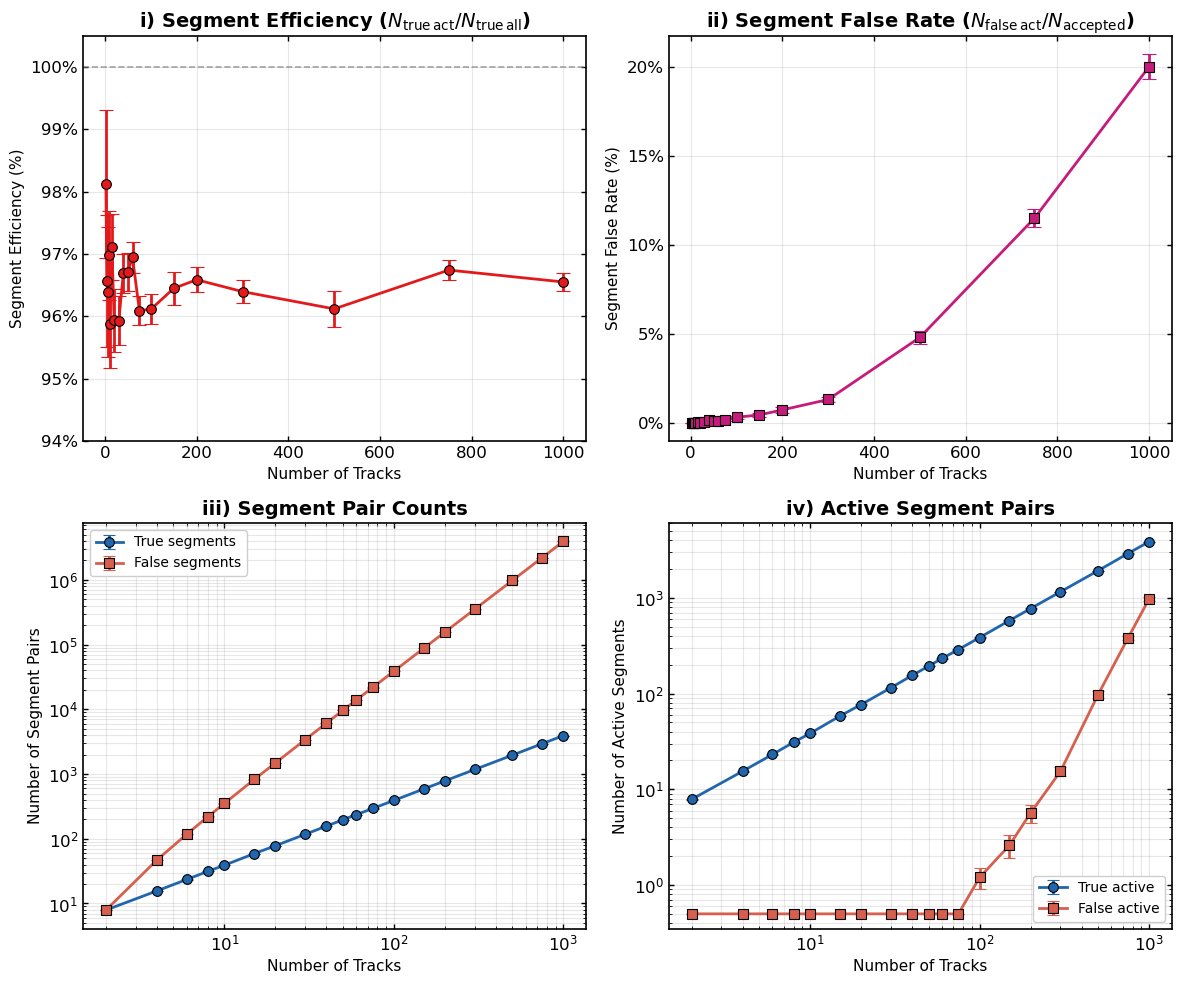

Saved fig14_solver_segment_efficiency_drop1pct


In [12]:
# ============================================================
# Section 14e.  Standalone 2x2 plot: 1% hit drop only
#   - i, ii: linear x-axis (segment efficiency, segment false rate)
#   - iii, iv: log x-axis (segment pair counts, active segment pairs)
# ============================================================
import matplotlib.ticker as _mt14s

def _logclip_yerr(y, e, floor):
    """Symmetric error e clipped so y - e_lo > floor (avoids log-axis runaway)."""
    y = np.asarray(y, dtype=float)
    e = np.asarray(e, dtype=float)
    lo = np.minimum(e, np.maximum(y - floor, 0.0))
    return np.vstack([lo, e])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
d1 = _agg_drop
tc = d1['tc']

# i) Segment efficiency  (linear x)
ax = axes[0, 0]
ax.errorbar(tc, d1['se_m'], yerr=d1['se_e'], fmt='o-', color=_c14_drop,
            capsize=5, capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
            zorder=3)
ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)
_emin14s = max(0, np.floor((d1['se_m'] - d1['se_e']).min()) - 1)
ax.set_ylim(_emin14s, 100.5)
ax.set_yticks(np.arange(int(_emin14s), 101, 1))
ax.set_ylabel('Segment Efficiency (%)', fontsize=11)
ax.set_title(r'i) Segment Efficiency ($N_{\mathrm{true\,act}} / N_{\mathrm{true\,all}}$)',
             fontweight='bold')
ax.grid(True, alpha=0.3, zorder=1)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.yaxis.set_major_formatter(_mt14s.FormatStrFormatter('%g%%'))

# ii) Segment false rate  (linear x)
ax = axes[0, 1]
ax.errorbar(tc, d1['fr_m'], yerr=d1['fr_e'], fmt='s-', color=_c14_fr,
            capsize=5, capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
            zorder=3)
ax.set_ylabel('Segment False Rate (%)', fontsize=11)
ax.set_title(r'ii) Segment False Rate ($N_{\mathrm{false\,act}} / N_{\mathrm{accepted}}$)',
             fontweight='bold')
ax.grid(True, alpha=0.3, zorder=1)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.yaxis.set_major_formatter(_mt14s.FormatStrFormatter('%g%%'))

# iii) Total segment pairs  (log x, log y)
_FLOOR14_III = 0.5
ax = axes[1, 0]
ax.errorbar(tc, d1['ntm'], yerr=_logclip_yerr(d1['ntm'], d1['ntse'], _FLOOR14_III),
            fmt='o-', color=_c14_true,
            capsize=4, capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
            label='True segments', zorder=3)
ax.errorbar(tc, d1['nfm'], yerr=_logclip_yerr(d1['nfm'], d1['nfse'], _FLOOR14_III),
            fmt='s-', color=_c14_false,
            capsize=4, capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
            label='False segments', zorder=3)
ax.set_yscale('log')
ax.set_ylabel('Number of Segment Pairs', fontsize=11)
ax.set_title('iii) Segment Pair Counts', fontweight='bold')
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)
ax.grid(True, alpha=0.3, which='both', zorder=1)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

# iv) Active segment pairs  (log x, log y)
#   Sub-unity false-active means (e.g. 0.07/event near low n) are floored
#   to _FLOOR14_IV so the marker sits on a visible position; lower error
#   caps are then clipped so they never punch through the panel bottom.
_FLOOR14_IV = 0.5
ax = axes[1, 1]
_fa_p14s = np.maximum(d1['fam'], _FLOOR14_IV)               # display floor
_fa_e14s = np.where(d1['fam'] >= _FLOOR14_IV, d1['fase'], 0.0)
ax.errorbar(tc, d1['tam'],
            yerr=_logclip_yerr(d1['tam'], d1['tase'], _FLOOR14_IV),
            fmt='o-', color=_c14_true,
            capsize=4, capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
            label='True active', zorder=3)
ax.errorbar(tc, _fa_p14s,
            yerr=_logclip_yerr(_fa_p14s, _fa_e14s, _FLOOR14_IV),
            fmt='s-', color=_c14_false,
            capsize=4, capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
            label='False active', zorder=3)
ax.set_yscale('log')
# Pad the lower limit so the floor row sits comfortably above the panel edge.
ax.set_ylim(_FLOOR14_IV * 0.7, None)
ax.set_ylabel('Number of Active Segments', fontsize=11)
ax.set_title('iv) Active Segment Pairs', fontweight='bold')
ax.legend(loc='lower right', framealpha=0.95, fontsize=10)
ax.grid(True, alpha=0.3, which='both', zorder=1)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

for ax in axes.flat:
    ax.set_xlabel('Number of Tracks', fontsize=11)
# Bottom row: log x for panels iii) and iv)
for ax in axes[1, :]:
    ax.set_xscale('log')

fig.tight_layout()

_stem14s = 'fig14_solver_segment_efficiency_drop1pct'
fig.savefig(PAPER_DIR / f'{_stem14s}.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(PAPER_DIR / f'{_stem14s}.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved {_stem14s}")


# Section 15. Track-level performance at the §14 configuration

Having validated segment activation at the operating point
($\gamma=3$, $\delta=1$, $\varepsilon = 2$ mrad, threshold $=0.35$,
$\sigma_\mathrm{res}=5\,\mu$m, $\sigma_\mathrm{scatt}=0.1$ mrad), we now assess
**track-level** reconstruction performance on the same grid of event
multiplicities $n \in \{2,\dots,1000\}$ and the same 0% and 1% hit-drop
scenarios.

Pipeline per event
1. Generate the event with the §14 safe-generator.
2. Construct segments, build the Hamiltonian (fast builder), solve classically.
3. Threshold the solution at `SOLVER_THRESHOLD = 0.35`.
4. Group the surviving segments into tracks with `get_tracks()` (connected
   components on the segment graph; hits ordered by $z$).
5. Match the reconstructed tracks against truth with `EventValidator`
   (LHCb convention: purity $\geq 0.7$, non-greedy quality-sorted
   assignment).

Metrics (LHCb convention)

- **Reconstruction efficiency** $\varepsilon_\mathrm{rec}$: fraction of
  reconstructible truth tracks matched to at least one accepted reco track.
  For the 1%-drop case this includes structural losses (tracks whose hit
  count drops below 3 cannot be reconstructed).
- **Ghost rate** $\rho_g$: fraction of reco candidates ($\geq 3$ hits) that
  fail the purity cut. Measures fake-track contamination.
- **Clone fraction** $f_c$: fraction of accepted reco tracks that are clones
  of an already-matched truth track.
- **Mean purity** $\bar{p}$ of accepted tracks: (shared hits)/(reco hits).
- **Mean hit efficiency** $\bar{h}$ of accepted tracks: (shared hits)/(truth hits).

Expectations. With segment efficiency 100% and false-segment rate up to 20%
at $n=1000$, we expect:
- $\varepsilon_\mathrm{rec}$ $\approx 100\%$ at low $n$, degrading slightly at
  high $n$ as ghost segments steal hits.
- $\rho_g$ growing roughly in proportion to the false-segment rate but
  softened because most ghost segments are isolated and won't form
  $\geq 3$-hit chains.
- $\bar{p}$ and $\bar{h}$ should remain close to 1 — when a track is
  accepted, it's mostly built from true segments.


In [7]:
# ============================================================
# Section 15 setup: per-event track-level metrics helper
# ============================================================
from lhcb_velo_toy.solvers.reconstruction.track_finder import get_tracks as _get_tracks
from lhcb_velo_toy.analysis.validation.validator import EventValidator as _EventValidator

# LHCb-standard cuts.
PURITY_MIN        = 0.70
HIT_EFF_MIN       = 0.00   # default in validator
MIN_REC_HITS      = 3      # default


def _track_metrics(event_reco, truth_event=None, purity_min=PURITY_MIN):
    """Solve, extract tracks, validate.

    Parameters
    ----------
    event_reco   : event passed to the solver (possibly after hit drops).
    truth_event  : the clean event whose truth tracks define the denominator.
                   Falls back to event_reco when None (0%-drop case).
    """
    if truth_event is None:
        truth_event = event_reco

    ham = SimpleHamiltonianFast(epsilon=FIXED_EPSILON, gamma=GAMMA, delta=DELTA)
    ham.construct_segments(event_reco)
    _build_ham_vectorized(ham)
    sol = ham.solve_classicaly()
    rec_tracks = _get_tracks(ham, sol, event_reco, threshold=SOLVER_THRESHOLD)

    val = _EventValidator(truth_event, rec_tracks)
    _, m = val.match_tracks(purity_min=purity_min,
                            hit_efficiency_min=HIT_EFF_MIN,
                            min_rec_hits=MIN_REC_HITS)
    # keep only scalars we need for caching
    return {
        'efficiency':     float(m['efficiency']),
        'ghost_rate':     float(m['ghost_rate']),
        'clone_fraction': float(m['clone_fraction']),
        'mean_purity':    float(m['mean_purity']),
        'hit_efficiency': float(m['hit_efficiency']),
        'n_reconstructible': int(m['n_reconstructible']),
        'n_matched':      int(m['n_matched']),
        'n_candidates':   int(m['n_candidates']),
        'n_accepted':     int(m['n_accepted']),
        'n_ghosts':       int(m['n_ghosts']),
        'n_clones':       int(m['n_clones']),
        'n_rec_tracks':   int(len(rec_tracks)),
    }


def _agg_tracks(raw):
    """Aggregate per-repeat dicts into mean±SEM arrays on SOLVER_TRACK_COUNTS."""
    tc = np.array(SOLVER_TRACK_COUNTS, dtype=float)
    keys = ['efficiency', 'ghost_rate', 'clone_fraction',
            'mean_purity', 'hit_efficiency']
    out = {'tc': tc}
    for k in keys:
        mean = np.empty_like(tc)
        sem  = np.empty_like(tc)
        for i, n in enumerate(SOLVER_TRACK_COUNTS):
            vals = np.array([r[k] for r in raw[n]], dtype=float)
            mean[i] = vals.mean()
            sem[i]  = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0
        out[f'{k}_m'] = mean
        out[f'{k}_e'] = sem
    # counts (means only)
    for k in ['n_reconstructible', 'n_matched', 'n_candidates',
              'n_accepted', 'n_ghosts', 'n_clones', 'n_rec_tracks']:
        out[f'{k}_m'] = np.array([np.mean([r[k] for r in raw[n]])
                                   for n in SOLVER_TRACK_COUNTS])
    return out


# Sanity check at small n
_ev_sanity = safe_generate(10,
                           measurement_error=float(FIXED_RESOLUTION),
                           collision_noise=float(FIXED_SCATTERING))
_sanity = _track_metrics(_ev_sanity)
print("Sanity at n=10 (clean):")
for k, v in _sanity.items():
    print(f"  {k:20s} = {v}")


Sanity at n=10 (clean):
  efficiency           = 1.0
  ghost_rate           = 0.0
  clone_fraction       = 0.0
  mean_purity          = 1.0
  hit_efficiency       = 1.0
  n_reconstructible    = 10
  n_matched            = 10
  n_candidates         = 10
  n_accepted           = 10
  n_ghosts             = 0
  n_clones             = 0
  n_rec_tracks         = 10


In [31]:
# ============================================================
# Section 15a.  Track-level data: 0% hit drop (base)
# ============================================================
_cache15_base = CACHE_DIR / 'track_level_base.pkl'

if _cache15_base.exists():
    with open(_cache15_base, 'rb') as _f:
        _trk_base = pickle.load(_f)
    print(f"Loaded track-base cache: {len(_trk_base)} entries")
else:
    _trk_base = {}

_missing = [k for k in SOLVER_TRACK_COUNTS if k not in _trk_base]
if _missing:
    _t15 = _time14.time()
    for n_trk in _missing:
        _nrep = _repeats_for(n_trk)
        recs = []
        _t0 = _time14.time()
        for rep in range(_nrep):
            # same seed convention as §14 so track-level and segment-level
            # metrics are measured on *identical* events
            np.random.seed(rep + n_trk * 100 + 140000)
            ev = safe_generate(n_trk,
                               measurement_error=float(FIXED_RESOLUTION),
                               collision_noise=float(FIXED_SCATTERING))
            recs.append(_track_metrics(ev))
        _trk_base[n_trk] = recs
        _em = np.mean([r['efficiency']     for r in recs]) * 100
        _gm = np.mean([r['ghost_rate']     for r in recs]) * 100
        _cm = np.mean([r['clone_fraction'] for r in recs]) * 100
        print(f"  n={n_trk:4d}  reps={_nrep:2d}  eff={_em:6.2f}%  "
              f"ghost={_gm:5.2f}%  clone={_cm:5.2f}%  "
              f"({_time14.time()-_t0:.1f}s, total {_time14.time()-_t15:.0f}s)")
        with open(_cache15_base, 'wb') as _f:
            pickle.dump(_trk_base, _f)
    print(f"Saved track-base cache: {len(_trk_base)} entries  "
          f"({_time14.time()-_t15:.0f}s)")
else:
    print("All track counts cached — nothing to compute.")

_agg_trk_base = _agg_tracks(_trk_base)
print(f"Base aggregation: {len(_agg_trk_base['tc'])} points")


  n=   2  reps=60  eff=100.00%  ghost= 0.00%  clone= 0.00%  (0.1s, total 0s)
  n=   4  reps=60  eff=100.00%  ghost= 0.00%  clone= 0.00%  (0.2s, total 0s)
  n=   6  reps=60  eff= 99.44%  ghost= 0.33%  clone= 0.00%  (0.2s, total 0s)
  n=   8  reps=60  eff=100.00%  ghost= 0.00%  clone= 0.00%  (0.3s, total 1s)
  n=  10  reps=60  eff=100.00%  ghost= 0.00%  clone= 0.00%  (0.5s, total 1s)
  n=  15  reps=60  eff=100.00%  ghost= 0.00%  clone= 0.00%  (0.8s, total 2s)
  n=  20  reps=60  eff= 99.67%  ghost= 0.18%  clone= 0.00%  (1.2s, total 3s)
  n=  30  reps=60  eff= 99.89%  ghost= 0.06%  clone= 0.00%  (2.6s, total 6s)
  n=  40  reps=60  eff= 99.58%  ghost= 0.21%  clone= 0.00%  (4.4s, total 10s)
  n=  50  reps=60  eff= 99.27%  ghost= 0.38%  clone= 0.00%  (6.7s, total 17s)
  n=  60  reps=60  eff= 99.39%  ghost= 0.31%  clone= 0.00%  (34.5s, total 52s)
  n=  75  reps=60  eff= 99.51%  ghost= 0.23%  clone= 0.00%  (38.5s, total 90s)
  n= 100  reps=60  eff= 99.10%  ghost= 0.42%  clone= 0.00%  (55.6s, to

In [32]:
# ============================================================
# Section 15b.  Track-level data: 1% hit drop
#
# Truth event = the *clean* event — so tracks with hits dropped
# below the 3-hit threshold count as unreconstructed (structural loss).
# ============================================================
_cache15_drop = CACHE_DIR / 'track_level_drop1pct.pkl'

if _cache15_drop.exists():
    with open(_cache15_drop, 'rb') as _f:
        _trk_drop = pickle.load(_f)
    print(f"Loaded track-drop cache: {len(_trk_drop)} entries")
else:
    _trk_drop = {}

_rng_drop15  = np.random.default_rng(42)
_missing_d   = [k for k in SOLVER_TRACK_COUNTS if k not in _trk_drop]
if _missing_d:
    _t15d = _time14.time()
    for n_trk in _missing_d:
        _nrep = _repeats_for(n_trk)
        recs  = []
        _t0   = _time14.time()
        for rep in range(_nrep):
            np.random.seed(rep + n_trk * 100 + 140000)
            ev_clean = safe_generate(n_trk,
                                     measurement_error=float(FIXED_RESOLUTION),
                                     collision_noise=float(FIXED_SCATTERING))
            ev_noisy = apply_hit_noise(ev_clean,
                                       drop_rate=DROP_RATE_SOLVER,
                                       ghost_rate=0.0,
                                       rng=_rng_drop15)
            recs.append(_track_metrics(ev_noisy, truth_event=ev_clean))
        _trk_drop[n_trk] = recs
        _em = np.mean([r['efficiency']     for r in recs]) * 100
        _gm = np.mean([r['ghost_rate']     for r in recs]) * 100
        _cm = np.mean([r['clone_fraction'] for r in recs]) * 100
        _hm = np.mean([r['hit_efficiency'] for r in recs]) * 100
        print(f"  n={n_trk:4d}  reps={_nrep:2d}  eff={_em:6.2f}%  "
              f"ghost={_gm:5.2f}%  clone={_cm:5.2f}%  hit_eff={_hm:6.2f}%  "
              f"({_time14.time()-_t0:.1f}s, total {_time14.time()-_t15d:.0f}s)")
        with open(_cache15_drop, 'wb') as _f:
            pickle.dump(_trk_drop, _f)
    print(f"Saved track-drop cache: {len(_trk_drop)} entries  "
          f"({_time14.time()-_t15d:.0f}s)")
else:
    print("All track counts cached — nothing to compute.")

_agg_trk_drop = _agg_tracks(_trk_drop)
print(f"Drop aggregation: {len(_agg_trk_drop['tc'])} points")


  n=   2  reps=60  eff= 98.33%  ghost= 0.00%  clone= 0.00%  hit_eff= 99.83%  (0.1s, total 0s)
  n=   4  reps=60  eff= 97.08%  ghost= 0.00%  clone= 0.00%  hit_eff= 99.58%  (0.2s, total 0s)
  n=   6  reps=60  eff= 96.67%  ghost= 0.00%  clone= 0.00%  hit_eff= 99.77%  (0.3s, total 1s)
  n=   8  reps=60  eff= 97.50%  ghost= 0.00%  clone= 0.00%  hit_eff= 99.58%  (0.4s, total 1s)
  n=  10  reps=60  eff= 96.50%  ghost= 0.00%  clone= 0.00%  hit_eff= 99.49%  (0.5s, total 1s)
  n=  15  reps=60  eff= 97.67%  ghost= 0.00%  clone= 0.00%  hit_eff= 99.55%  (0.8s, total 2s)
  n=  20  reps=60  eff= 96.25%  ghost= 0.18%  clone= 0.00%  hit_eff= 99.46%  (1.2s, total 3s)
  n=  30  reps=60  eff= 96.17%  ghost= 0.06%  clone= 0.00%  hit_eff= 99.71%  (2.4s, total 6s)
  n=  40  reps=60  eff= 96.88%  ghost= 0.22%  clone= 0.00%  hit_eff= 99.51%  (3.6s, total 9s)
  n=  50  reps=60  eff= 96.63%  ghost= 0.35%  clone= 0.00%  hit_eff= 99.50%  (6.1s, total 16s)
  n=  60  reps=60  eff= 97.00%  ghost= 0.23%  clone= 0.00% 

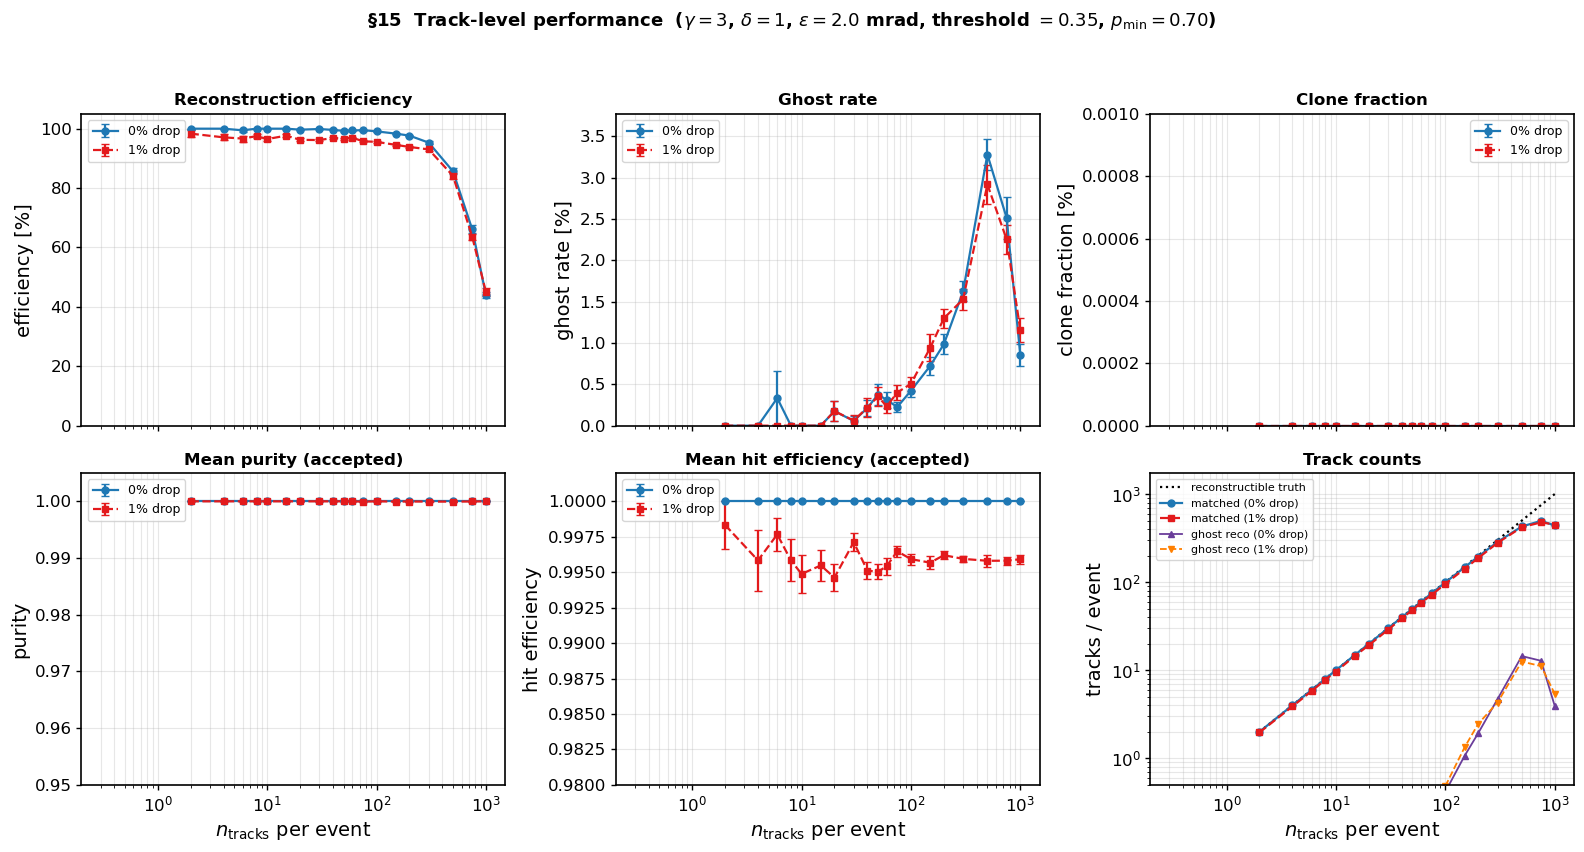

Saved fig15_track_level_overlay (pdf + png)

    n     eff0    eff1     gh0    gh1     cl0    cl1      p0     p1      h0     h1
    2  100.00%  98.33%   0.00%  0.00%   0.00%  0.00%  1.000 1.000  1.000 0.998
    4  100.00%  97.08%   0.00%  0.00%   0.00%  0.00%  1.000 1.000  1.000 0.996
    6   99.44%  96.67%   0.33%  0.00%   0.00%  0.00%  1.000 1.000  1.000 0.998
    8  100.00%  97.50%   0.00%  0.00%   0.00%  0.00%  1.000 1.000  1.000 0.996
   10  100.00%  96.50%   0.00%  0.00%   0.00%  0.00%  1.000 1.000  1.000 0.995
   15  100.00%  97.67%   0.00%  0.00%   0.00%  0.00%  1.000 1.000  1.000 0.995
   20   99.67%  96.25%   0.18%  0.18%   0.00%  0.00%  1.000 1.000  1.000 0.995
   30   99.89%  96.17%   0.06%  0.06%   0.00%  0.00%  1.000 1.000  1.000 0.997
   40   99.58%  96.88%   0.21%  0.22%   0.00%  0.00%  1.000 1.000  1.000 0.995
   50   99.27%  96.63%   0.38%  0.35%   0.00%  0.00%  1.000 1.000  1.000 0.995
   60   99.39%  97.00%   0.31%  0.23%   0.00%  0.00%  1.000 1.000  1.000 0.995
   

In [34]:
# ============================================================
# Section 15c.  Track-level plots: base vs 1%-drop overlay
# ============================================================
d0 = _agg_trk_base
d1 = _agg_trk_drop

# Panel spec: (key, title, ylabel, as_percent, custom_ylim)
_panels = [
    ('efficiency',     'Reconstruction efficiency',    'efficiency [%]',      True,  (0, 105)),
    ('ghost_rate',     'Ghost rate',                   'ghost rate [%]',      True,  None),
    ('clone_fraction', 'Clone fraction',               'clone fraction [%]',  True,  None),
    ('mean_purity',    'Mean purity (accepted)',       'purity',              False, (0.95, 1.005)),
    ('hit_efficiency', 'Mean hit efficiency (accepted)','hit efficiency',     False, (0.98, 1.002)),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), sharex=True)
axes = axes.ravel()

for ax, (key, title, ylab, as_pct, ylim) in zip(axes, _panels):
    scale = 100.0 if as_pct else 1.0
    y0_m, y0_e = d0[f'{key}_m'] * scale, d0[f'{key}_e'] * scale
    y1_m, y1_e = d1[f'{key}_m'] * scale, d1[f'{key}_e'] * scale

    ax.errorbar(d0['tc'], y0_m, yerr=y0_e, fmt='o-',
                color=_c14_base, ms=5, lw=1.6, capsize=3, label='0% drop')
    ax.errorbar(d1['tc'], y1_m, yerr=y1_e, fmt='s--',
                color=_c14_drop, ms=5, lw=1.6, capsize=3, label='1% drop')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylab)
    ax.set_xscale('log')
    ax.grid(alpha=0.3, which='both')
    ax.legend(fontsize=9, loc='best')
    if ylim is not None:
        ax.set_ylim(*ylim)
    else:
        # auto but anchor at 0 and pad the top by 15%
        y_top = max(y0_m.max(), y1_m.max()) * 1.15
        ax.set_ylim(0, max(y_top, 1e-3))

# Bottom-right: track counts
ax = axes[-1]
ax.plot(d0['tc'], d0['n_reconstructible_m'], 'k:', lw=1.6,
        label='reconstructible truth')
ax.plot(d0['tc'], d0['n_matched_m'], 'o-',
        color=_c14_base, ms=5, lw=1.6, label='matched (0% drop)')
ax.plot(d1['tc'], d1['n_matched_m'], 's--',
        color=_c14_drop, ms=5, lw=1.6, label='matched (1% drop)')
ax.plot(d0['tc'], d0['n_ghosts_m'], '^-',
        color='#6a3d9a', ms=5, lw=1.3, label='ghost reco (0% drop)')
ax.plot(d1['tc'], d1['n_ghosts_m'], 'v--',
        color='#ff7f00', ms=5, lw=1.3, label='ghost reco (1% drop)')
ax.set_title('Track counts', fontsize=12, fontweight='bold')
ax.set_ylabel('tracks / event')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(0.5, None)
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=8, loc='best')

for ax in axes[3:]:
    ax.set_xlabel(r'$n_\mathrm{tracks}$ per event')

fig.suptitle(rf'§15  Track-level performance  '
             rf'($\gamma={GAMMA:g}$, $\delta={DELTA:g}$, '
             rf'$\varepsilon={FIXED_EPSILON*1e3:.1f}$ mrad, '
             rf'threshold $={SOLVER_THRESHOLD:.2f}$, '
             rf'$p_\mathrm{{min}}={PURITY_MIN:.2f}$)',
             fontsize=13, fontweight='bold', y=1.00)
fig.tight_layout(rect=[0, 0, 1, 0.97])

_out15 = OUT_DIR / 'segment_analysis'
_out15.mkdir(parents=True, exist_ok=True)
for _ext, _fmt, _dpi in [('pdf', 'pdf', 600), ('png', 'png', 300)]:
    fig.savefig(_out15 / f'fig15_track_level_overlay.{_ext}',
                format=_fmt, dpi=_dpi, bbox_inches='tight',
                facecolor='white')
plt.show()
print("Saved fig15_track_level_overlay (pdf + png)")

# Print summary table
print("\n" + "=" * 78)
print(f"{'n':>5s}  {'eff0':>7s} {'eff1':>7s}  {'gh0':>6s} {'gh1':>6s}  "
      f"{'cl0':>6s} {'cl1':>6s}  {'p0':>6s} {'p1':>6s}  {'h0':>6s} {'h1':>6s}")
print("=" * 78)
for i, n in enumerate(SOLVER_TRACK_COUNTS):
    print(f"{n:5d}  "
          f"{d0['efficiency_m'][i]*100:6.2f}% {d1['efficiency_m'][i]*100:6.2f}%  "
          f"{d0['ghost_rate_m'][i]*100:5.2f}% {d1['ghost_rate_m'][i]*100:5.2f}%  "
          f"{d0['clone_fraction_m'][i]*100:5.2f}% {d1['clone_fraction_m'][i]*100:5.2f}%  "
          f"{d0['mean_purity_m'][i]:5.3f} {d1['mean_purity_m'][i]:5.3f}  "
          f"{d0['hit_efficiency_m'][i]:5.3f} {d1['hit_efficiency_m'][i]:5.3f}")


## §15d  Zoom study: where does track reco start to tank?

The coarse grid ($n \in \{300, 500, 750, 1000\}$) shows a large drop from
$\varepsilon_\mathrm{rec} \approx 95\%$ to $\approx 44\%$ but leaves the
shape of the transition ambiguous. Below we add intermediate points to
locate the knee and check whether the efficiency drop is smooth or has a
sudden onset.

Hypothesis: segment false-activation rate $f_\mathrm{FA}$ (from §14) crosses
~1% near $n=300$ and ~5% between 500–600. If track reco depends on
$f_\mathrm{FA}$, we expect the knee close to the same range — scaling not
with $n$ itself, but with the ratio
$f_\mathrm{FA} \cdot n \sim$ expected number of spurious segments per
event stealing hits from truth tracks.


In [35]:
# ============================================================
# §15d.  Fill in intermediate n values (0% drop only) to find the knee
# ============================================================
# Add points in the interesting range. Reuse _trk_base cache.
ZOOM_TRACK_COUNTS = [250, 350, 400, 600, 700, 850]
ZOOM_REPEATS      = 15  # same as high-n policy

_added = 0
_t = _time14.time()
for n_trk in ZOOM_TRACK_COUNTS:
    if n_trk in _trk_base:
        print(f"  n={n_trk}: already cached, skipping")
        continue
    _t0 = _time14.time()
    recs = []
    for rep in range(ZOOM_REPEATS):
        np.random.seed(rep + n_trk * 100 + 140000)
        ev = safe_generate(n_trk,
                           measurement_error=float(FIXED_RESOLUTION),
                           collision_noise=float(FIXED_SCATTERING))
        recs.append(_track_metrics(ev))
    _trk_base[n_trk] = recs
    _added += 1
    _em = np.mean([r['efficiency']     for r in recs]) * 100
    _gm = np.mean([r['ghost_rate']     for r in recs]) * 100
    print(f"  n={n_trk:4d}  reps={ZOOM_REPEATS:2d}  eff={_em:6.2f}%  "
          f"ghost={_gm:5.2f}%  ({_time14.time()-_t0:.1f}s, total {_time14.time()-_t:.0f}s)")
    with open(_cache15_base, 'wb') as _f:
        pickle.dump(_trk_base, _f)

print(f"Added {_added} new zoom points; cache now has {len(_trk_base)} entries.")


  n= 250  reps=15  eff= 97.12%  ghost= 1.15%  (42.6s, total 43s)
  n= 350  reps=15  eff= 92.69%  ghost= 2.16%  (90.1s, total 133s)
  n= 400  reps=15  eff= 90.57%  ghost= 2.42%  (116.4s, total 249s)
  n= 600  reps=15  eff= 79.52%  ghost= 3.21%  (274.3s, total 523s)
  n= 700  reps=15  eff= 68.55%  ghost= 2.68%  (403.9s, total 927s)
  n= 850  reps=15  eff= 58.24%  ghost= 1.81%  (647.9s, total 1575s)
Added 6 new zoom points; cache now has 25 entries.


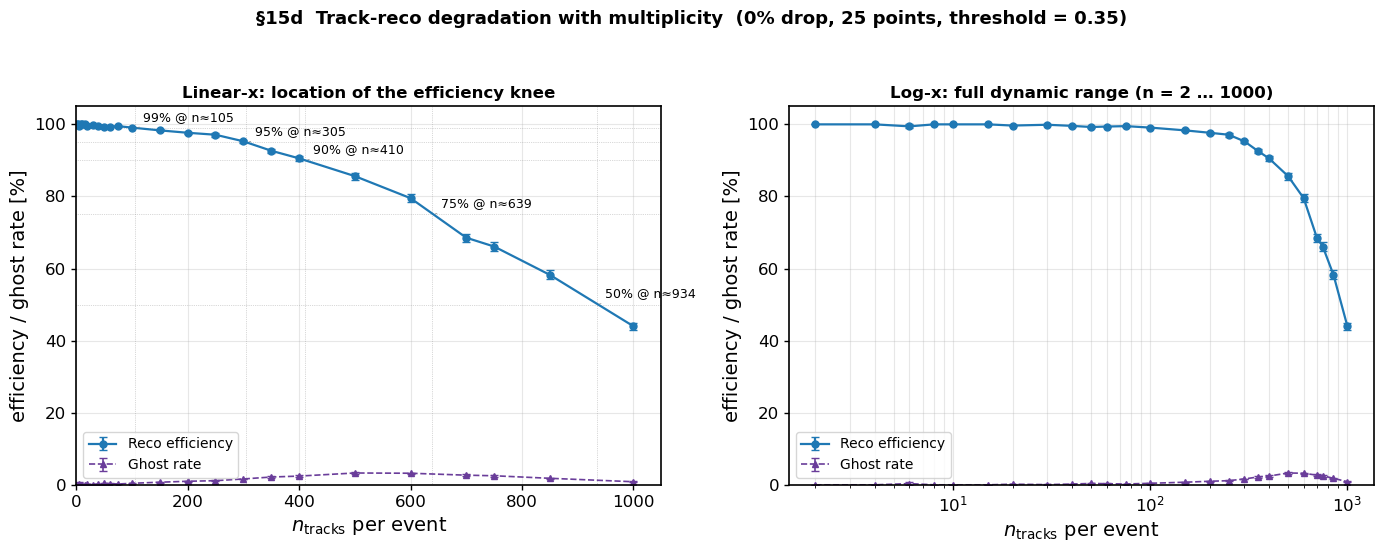

Saved fig15d_knee_analysis (pdf + png)

Efficiency-crossing knees (linear interp on log-n):
  ε_rec = 99%  →  n ≈    105
  ε_rec = 95%  →  n ≈    305
  ε_rec = 90%  →  n ≈    410
  ε_rec = 75%  →  n ≈    639
  ε_rec = 50%  →  n ≈    934

Densified table (n = 200 … 1000):
    n    eff [%]    sem  ghost [%]
  200      97.67   0.28       0.99
  250      97.12   0.53       1.15
  300      95.30   0.39       1.63
  350      92.69   0.60       2.16
  400      90.57   0.76       2.42
  500      85.64   0.96       3.28
  600      79.52   1.18       3.21
  700      68.55   1.14       2.68
  750      66.11   1.30       2.51
  850      58.24   1.24       1.81
 1000      43.99   1.00       0.85


In [36]:
# ============================================================
# §15e.  Zoom plot + knee analysis on the densified grid
# ============================================================
# Build a sorted, per-point summary from the full _trk_base cache.
_all_n = sorted(_trk_base.keys())
_n_arr  = np.array(_all_n, dtype=float)

def _mean_sem(k):
    m, s = np.empty_like(_n_arr), np.empty_like(_n_arr)
    for i, n in enumerate(_all_n):
        v = np.array([r[k] for r in _trk_base[n]], dtype=float)
        m[i] = v.mean()
        s[i] = v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0
    return m, s

eff_m, eff_e   = _mean_sem('efficiency')
gh_m,  gh_e    = _mean_sem('ghost_rate')
eff_m  *= 100; eff_e *= 100
gh_m   *= 100; gh_e  *= 100

# Knee metrics: n at which efficiency crosses 99%, 95%, 90%, 75%, 50%.
def _n_at_eff(target_pct):
    # linear interp on (n, eff). Walk down from low-n (high-eff) to find
    # first crossing.
    for i in range(len(_n_arr) - 1):
        if eff_m[i] >= target_pct and eff_m[i+1] < target_pct:
            n1, n2 = _n_arr[i], _n_arr[i+1]
            e1, e2 = eff_m[i], eff_m[i+1]
            # interp in log(n) because sampling is ~log-spaced
            lr = (e1 - target_pct) / (e1 - e2)
            return float(10 ** (np.log10(n1) + lr * (np.log10(n2) - np.log10(n1))))
    return None

knee_targets = [99, 95, 90, 75, 50]
knees = {t: _n_at_eff(t) for t in knee_targets}

# ============================================================
# Plot: 2-panel figure
#   (a) eff vs n with knee lines  — linear x to show the knee shape
#   (b) eff vs n on log x         — for the full range context
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Panel (a): linear-x efficiency zoom ---
ax = axes[0]
ax.errorbar(_n_arr, eff_m, yerr=eff_e, fmt='o-',
            color=_c14_base, ms=5, lw=1.6, capsize=3, label='Reco efficiency')
ax.errorbar(_n_arr, gh_m,  yerr=gh_e,  fmt='^--',
            color='#6a3d9a', ms=4, lw=1.2, capsize=3, label='Ghost rate')
# dashed horizontal + annotated knees
for t, nk in knees.items():
    if nk is None:
        continue
    ax.axhline(t, color='grey', lw=0.5, ls=':', alpha=0.6)
    ax.axvline(nk, color='grey', lw=0.5, ls=':', alpha=0.6)
    ax.annotate(f"{t}% @ n≈{nk:.0f}",
                xy=(nk, t), xytext=(nk + 15, t + 2),
                fontsize=9, color='k',
                arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))
ax.set_xlabel(r'$n_\mathrm{tracks}$ per event')
ax.set_ylabel('efficiency / ghost rate [%]')
ax.set_title('Linear-x: location of the efficiency knee',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 1050)
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
ax.legend(fontsize=10, loc='lower left')

# --- Panel (b): log-x full-range view ---
ax = axes[1]
ax.errorbar(_n_arr, eff_m, yerr=eff_e, fmt='o-',
            color=_c14_base, ms=5, lw=1.6, capsize=3, label='Reco efficiency')
ax.errorbar(_n_arr, gh_m,  yerr=gh_e,  fmt='^--',
            color='#6a3d9a', ms=4, lw=1.2, capsize=3, label='Ghost rate')
ax.set_xscale('log')
ax.set_xlabel(r'$n_\mathrm{tracks}$ per event')
ax.set_ylabel('efficiency / ghost rate [%]')
ax.set_title('Log-x: full dynamic range (n = 2 … 1000)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=10, loc='lower left')

fig.suptitle(r'§15d  Track-reco degradation with multiplicity  '
             rf'(0% drop, {len(_all_n)} points, threshold = {SOLVER_THRESHOLD:.2f})',
             fontsize=13, fontweight='bold', y=1.00)
fig.tight_layout(rect=[0, 0, 1, 0.96])
for _ext, _fmt, _dpi in [('pdf', 'pdf', 600), ('png', 'png', 300)]:
    fig.savefig(_out15 / f'fig15d_knee_analysis.{_ext}',
                format=_fmt, dpi=_dpi, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig15d_knee_analysis (pdf + png)")

# --- Summary table: knees & densified table in the critical region ---
print("\nEfficiency-crossing knees (linear interp on log-n):")
for t in knee_targets:
    nk = knees[t]
    s = f"n ≈ {nk:6.0f}" if nk is not None else "not reached"
    print(f"  ε_rec = {t:2d}%  →  {s}")

print("\nDensified table (n = 200 … 1000):")
print(f"{'n':>5s}  {'eff [%]':>9s}  {'sem':>5s}  {'ghost [%]':>9s}")
for i, n in enumerate(_all_n):
    if n < 200:
        continue
    print(f"{int(n):5d}  {eff_m[i]:9.2f}  {eff_e[i]:5.2f}  {gh_m[i]:9.2f}")


# Section 16. Spectral diagnostics of the Hamiltonian

The track-level efficiency collapses from 95 % to 44 % between
$n\!=\!300$ and $n\!=\!1000$ while the **segment-level** efficiency stays
pinned at 100 %. Three candidate causes:

1. **Matrix conditioning**: the SPD property relies on Gershgorin
   dominance $d_i > r_i$ with $d_i = \delta+\gamma = 4$ and
   $r_i =$ (row sum of $+1$ off-diagonals). As $n$ grows, the number of
   shared-middle-hit compatible neighbours $k_i$ per segment can exceed
   the diagonal, so the *guaranteed* lower bound $\lambda_\mathrm{min} \geq
   \min_i(d_i - r_i)$ collapses to $\leq 0$. However, this is only a
   sufficient condition; the *true* $\lambda_\mathrm{min}$ may remain
   positive.
2. **Spectrum explosion**: a diverging condition number
   $\kappa = \lambda_\mathrm{max}/\lambda_\mathrm{min}$ would flag numerical
   trouble — solver would lose precision on near-null-space modes and
   spurious segments could get arbitrary promotion.
3. **Reconstruction algorithm**: even with a clean spectrum and correct
   $s$-vector, `get_tracks()` (connected components on the segment graph)
   can absorb ghost segments into mega-components at high multiplicity.
   The hypothesis from §15 is that this is the dominant effect.

Below we:
- (a) compute $\lambda_\mathrm{min}, \lambda_\mathrm{max}, \kappa$, the
  Gershgorin bound, and row-sum statistics for $n \in \{10, 30, 100, 200,
  300, 500, 750, 1000\}$;
- (b) split the solution vector by *truth* and plot the distribution of
  true vs false segment activations as $n$ grows — this is the cleanest
  test of whether the solver output is "polluted" or still well-separated;
- (c) compare the efficiency knee against $\kappa(n)$ to settle whether
  conditioning or tracker is the dominant failure mode.


In [37]:
# ============================================================
# §16a.  Collect spectral diagnostics across multiplicities
# ============================================================
from scipy.sparse.linalg import eigsh as _eigsh
import scipy.sparse as _sp

SPEC_N_VALUES = [10, 30, 100, 200, 300, 500, 750, 1000]
SPEC_N_REPS   = 3   # average a few events per n for robustness

_cache16 = CACHE_DIR / 'spectral_diagnostics.pkl'
if _cache16.exists():
    with open(_cache16, 'rb') as _f:
        _spec = pickle.load(_f)
    print(f"Loaded spectrum cache: {len(_spec)} entries")
else:
    _spec = {}


def _one_spec(n_trk, rep):
    np.random.seed(rep + n_trk * 100 + 140000)
    ev = safe_generate(n_trk,
                       measurement_error=float(FIXED_RESOLUTION),
                       collision_noise=float(FIXED_SCATTERING))
    ham = SimpleHamiltonianFast(epsilon=FIXED_EPSILON, gamma=GAMMA, delta=DELTA)
    ham.construct_segments(ev)
    _build_ham_vectorized(ham)
    A = ham.A
    nS = A.shape[0]

    # Diagonal and off-diagonal row sum for Gershgorin bound.
    diag = np.asarray(A.diagonal(), dtype=float)
    A_abs = abs(A.tocsr())
    row_sum = np.asarray(A_abs.sum(axis=1)).ravel()
    off_row_sum = row_sum - np.abs(diag)
    gersh_min = float((diag - off_row_sum).min())
    gersh_max = float((diag + off_row_sum).max())

    # Extreme eigenvalues via ARPACK. eigsh is exact for SPD;
    # which='SA' / 'LA' gives algebraically smallest/largest.
    # ARPACK sometimes fails on very low-connectivity matrices;
    # fall back to which='SM' shift-invert (requires spsolve).
    try:
        lam_min = float(_eigsh(A, k=1, which='SA',
                               return_eigenvectors=False,
                               maxiter=5000, tol=1e-8)[0])
    except Exception as e:
        lam_min = float('nan')
        print(f"    eigsh SA failed at n={n_trk}, rep={rep}: {e}")
    try:
        lam_max = float(_eigsh(A, k=1, which='LA',
                               return_eigenvectors=False,
                               maxiter=5000, tol=1e-8)[0])
    except Exception as e:
        lam_max = float('nan')
        print(f"    eigsh LA failed at n={n_trk}, rep={rep}: {e}")

    cond = lam_max / lam_min if (lam_min and lam_min == lam_min and lam_min > 0) else float('nan')

    # Solution and truth split
    sol   = ham.solve_classicaly()
    truth = _segment_truth_from_ham(ham)

    return {
        'n_trk':        n_trk,
        'n_seg':        int(nS),
        'nnz':          int(A.nnz),
        'diag_val':     float(diag[0]),  # constant = delta+gamma
        'max_off_row':  float(off_row_sum.max()),
        'mean_off_row': float(off_row_sum.mean()),
        'gersh_min':    gersh_min,
        'gersh_max':    gersh_max,
        'lam_min':      lam_min,
        'lam_max':      lam_max,
        'cond':         cond,
        'sol_true':     sol[truth].copy(),
        'sol_false':    sol[~truth].copy(),
        'n_true':       int(truth.sum()),
        'n_false':      int((~truth).sum()),
    }


# Fill missing entries
_missing = [n for n in SPEC_N_VALUES if n not in _spec]
for n_trk in _missing:
    print(f"  n={n_trk}:")
    runs = []
    _t0 = _time14.time()
    for rep in range(SPEC_N_REPS):
        r = _one_spec(n_trk, rep)
        runs.append(r)
        print(f"    rep {rep}: n_seg={r['n_seg']:6d}  nnz={r['nnz']:8d}  "
              f"λ_min={r['lam_min']:.4f}  λ_max={r['lam_max']:.3f}  "
              f"κ={r['cond']:8.2f}  Gershgorin=[{r['gersh_min']:.3f},{r['gersh_max']:.3f}]  "
              f"max_off_row={r['max_off_row']:5.1f}")
    _spec[n_trk] = runs
    with open(_cache16, 'wb') as _f:
        pickle.dump(_spec, _f)
    print(f"    → cached ({_time14.time()-_t0:.1f}s)")

print(f"\nSpectrum cache: {len(_spec)} multiplicities × {SPEC_N_REPS} reps each.")


  n=10:
    rep 0: n_seg=   400  nnz=     460  λ_min=2.3820  λ_max=5.618  κ=    2.36  Gershgorin=[2.000,6.000]  max_off_row=  2.0
    rep 1: n_seg=   400  nnz=     460  λ_min=2.3820  λ_max=5.618  κ=    2.36  Gershgorin=[2.000,6.000]  max_off_row=  2.0
    rep 2: n_seg=   400  nnz=     460  λ_min=2.3820  λ_max=5.618  κ=    2.36  Gershgorin=[2.000,6.000]  max_off_row=  2.0
    → cached (0.1s)
  n=30:
    rep 0: n_seg=  3600  nnz=    3780  λ_min=2.3820  λ_max=5.618  κ=    2.36  Gershgorin=[2.000,6.000]  max_off_row=  2.0
    rep 1: n_seg=  3600  nnz=    3780  λ_min=2.3820  λ_max=5.618  κ=    2.36  Gershgorin=[2.000,6.000]  max_off_row=  2.0
    rep 2: n_seg=  3600  nnz=    3780  λ_min=2.3820  λ_max=5.618  κ=    2.36  Gershgorin=[2.000,6.000]  max_off_row=  2.0
    → cached (0.1s)
  n=100:
    rep 0: n_seg= 40000  nnz=   40628  λ_min=2.1522  λ_max=5.848  κ=    2.72  Gershgorin=[1.000,7.000]  max_off_row=  3.0
    rep 1: n_seg= 40000  nnz=   40628  λ_min=2.1522  λ_max=5.848  κ=    2.72  Ger

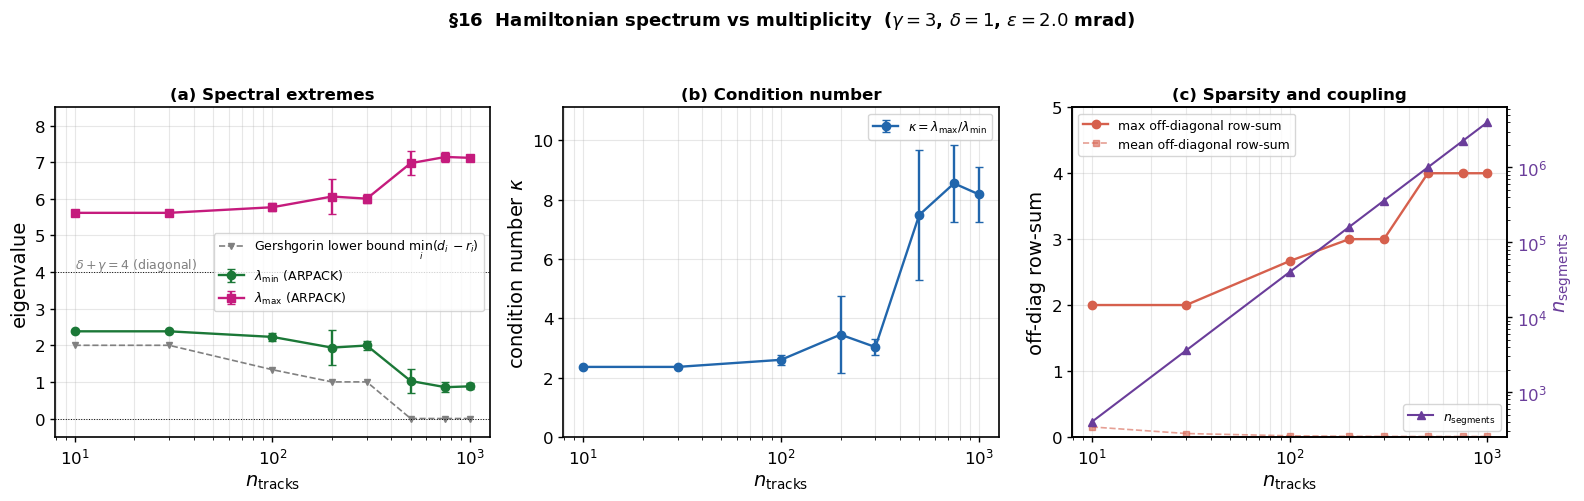

Saved fig16_spectrum (pdf + png)

    n     n_seg     λ_min ±     σ   λ_max        κ ±     σ  Gersh_min  max_off
   10       400    2.3820 ± 0.000   5.618     2.36 ±  0.00      2.000      2.0
   30      3600    2.3820 ± 0.000   5.618     2.36 ±  0.00      2.000      2.0
  100     40000    2.2288 ± 0.108   5.771     2.60 ±  0.17      1.333      2.7
  200    160000    1.9368 ± 0.476   6.063     3.45 ±  1.30      1.000      3.0
  300    360000    1.9947 ± 0.131   6.005     3.03 ±  0.27      1.000      3.0
  500   1000000    1.0256 ± 0.320   6.974     7.49 ±  2.20      0.000      4.0
  750   2250000    0.8553 ± 0.129   7.145     8.55 ±  1.30      0.000      4.0
 1000   4000000    0.8796 ± 0.082   7.120     8.18 ±  0.92      0.000      4.0


In [38]:
# ============================================================
# §16b.  Spectrum summary + solution histograms vs multiplicity
# ============================================================
# Build arrays from the cache
_ns    = np.array(sorted(_spec.keys()), dtype=float)
def _stk(key, reducer=np.mean):
    return np.array([reducer([r[key] for r in _spec[int(n)]]) for n in _ns])

lam_min_m = _stk('lam_min')
lam_min_s = _stk('lam_min', np.std)
lam_max_m = _stk('lam_max')
lam_max_s = _stk('lam_max', np.std)
cond_m    = _stk('cond')
cond_s    = _stk('cond',    np.std)
gmin_m    = _stk('gersh_min')
max_off_m = _stk('max_off_row')
n_seg_m   = _stk('n_seg')

# ---- Spectrum figure ------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) eigenvalue extremes and Gershgorin lower bound
ax = axes[0]
ax.errorbar(_ns, lam_min_m, yerr=lam_min_s, fmt='o-', color='#1b7837',
            ms=6, lw=1.7, capsize=3, label=r'$\lambda_\mathrm{min}$ (ARPACK)')
ax.errorbar(_ns, lam_max_m, yerr=lam_max_s, fmt='s-', color='#c51b7d',
            ms=6, lw=1.7, capsize=3, label=r'$\lambda_\mathrm{max}$ (ARPACK)')
ax.plot(_ns, gmin_m, 'v--', color='grey', ms=5, lw=1.2,
        label=r'Gershgorin lower bound $\min_i(d_i - r_i)$')
ax.axhline(0, color='k', lw=0.7, ls=':')
ax.axhline(DELTA + GAMMA, color='k', lw=0.7, ls=':')
ax.text(10, DELTA + GAMMA + 0.1, r'$\delta+\gamma=4$ (diagonal)',
        fontsize=9, color='grey')
ax.set_xlabel(r'$n_\mathrm{tracks}$')
ax.set_ylabel('eigenvalue')
ax.set_xscale('log')
ax.set_ylim(-0.5, 8.5)
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9, loc='center right')
ax.set_title('(a) Spectral extremes', fontsize=12, fontweight='bold')

# (b) condition number
ax = axes[1]
ax.errorbar(_ns, cond_m, yerr=cond_s, fmt='o-', color='#2166ac',
            ms=6, lw=1.7, capsize=3,
            label=r'$\kappa = \lambda_\mathrm{max}/\lambda_\mathrm{min}$')
ax.set_xlabel(r'$n_\mathrm{tracks}$')
ax.set_ylabel(r'condition number $\kappa$')
ax.set_xscale('log')
ax.set_ylim(0, max(cond_m) * 1.3)
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9)
ax.set_title('(b) Condition number', fontsize=12, fontweight='bold')

# (c) row-sum stats + segment count (right axis)
ax = axes[2]
ax.plot(_ns, max_off_m, 'o-', color='#d6604d', ms=6, lw=1.7,
        label='max off-diagonal row-sum')
ax.plot(_ns, _stk('mean_off_row'), 's--', color='#d6604d', ms=5, lw=1.2,
        alpha=0.6, label='mean off-diagonal row-sum')
ax.set_xlabel(r'$n_\mathrm{tracks}$')
ax.set_ylabel('off-diag row-sum')
ax.set_xscale('log')
ax.set_ylim(0, 5)
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9, loc='upper left')

ax2 = ax.twinx()
ax2.plot(_ns, n_seg_m, '^-', color='#6a3d9a', ms=6, lw=1.5,
         label=r'$n_\mathrm{segments}$')
ax2.set_ylabel(r'$n_\mathrm{segments}$', color='#6a3d9a')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='#6a3d9a')
ax2.legend(fontsize=9, loc='lower right')

ax.set_title('(c) Sparsity and coupling', fontsize=12, fontweight='bold')

fig.suptitle(r'§16  Hamiltonian spectrum vs multiplicity  '
             rf'($\gamma={GAMMA:g}$, $\delta={DELTA:g}$, '
             rf'$\varepsilon={FIXED_EPSILON*1e3:.1f}$ mrad)',
             fontsize=13, fontweight='bold', y=1.00)
fig.tight_layout(rect=[0, 0, 1, 0.96])
for _ext, _fmt, _dpi in [('pdf', 'pdf', 600), ('png', 'png', 300)]:
    fig.savefig(_out15 / f'fig16_spectrum.{_ext}',
                format=_fmt, dpi=_dpi, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig16_spectrum (pdf + png)")

# Print table
print("\n" + "=" * 94)
print(f"{'n':>5s}  {'n_seg':>8s}  {'λ_min':>8s} ± {'σ':>5s}  "
      f"{'λ_max':>6s}  {'κ':>7s} ± {'σ':>5s}  "
      f"{'Gersh_min':>9s}  {'max_off':>7s}")
print("=" * 94)
for i, n in enumerate(_ns):
    print(f"{int(n):5d}  {int(n_seg_m[i]):8d}  "
          f"{lam_min_m[i]:8.4f} ± {lam_min_s[i]:5.3f}  "
          f"{lam_max_m[i]:6.3f}  "
          f"{cond_m[i]:7.2f} ± {cond_s[i]:5.2f}  "
          f"{gmin_m[i]:9.3f}  {max_off_m[i]:7.1f}")


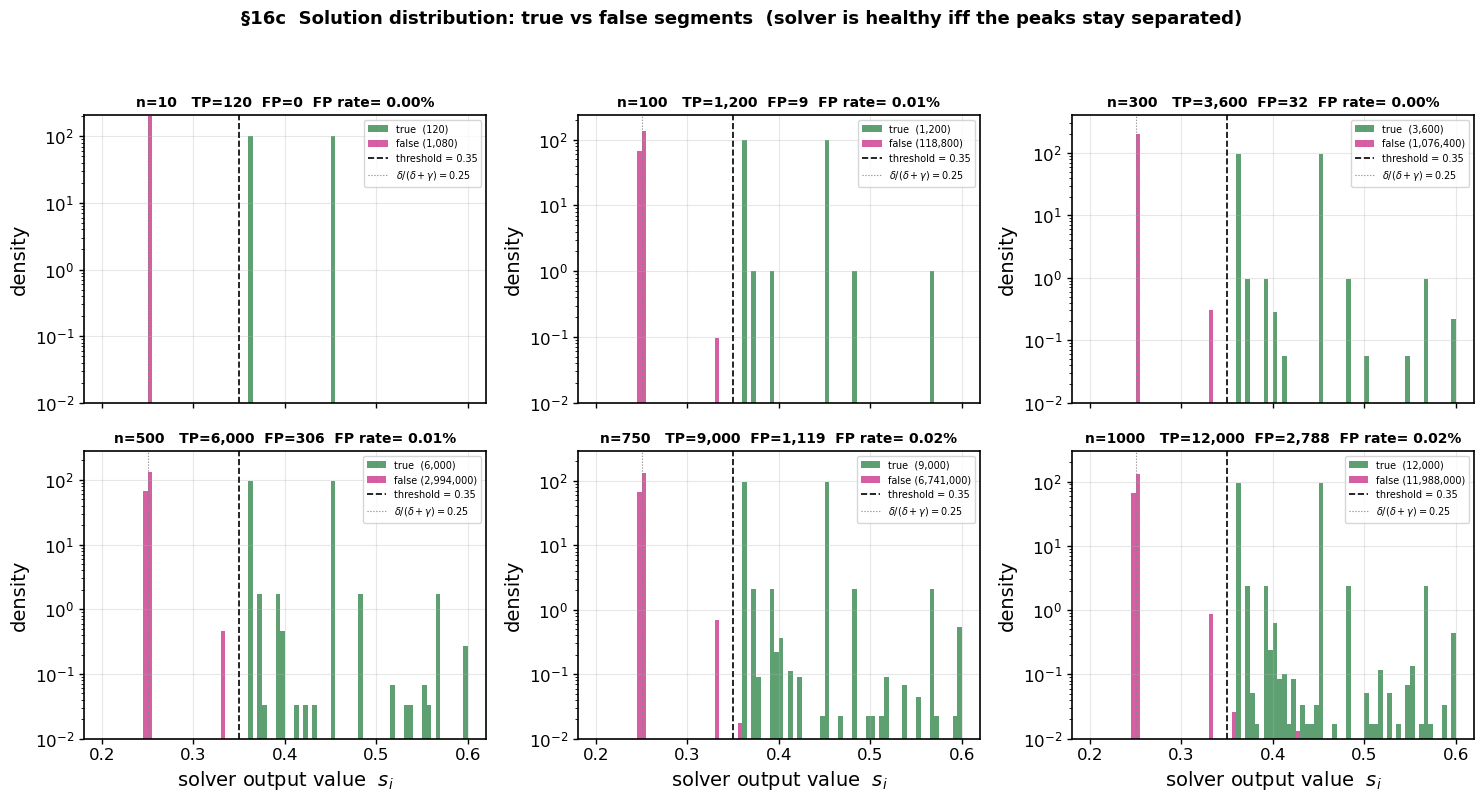

Saved fig16c_solution_histograms (pdf + png)

    n     n_true     n_false  min(true)  max(false)      gap     FP%
   10        120       1,080     0.3636      0.2500  +0.1136    0.00
  100      1,200     118,800     0.3636      0.4285  -0.0649    0.01
  300      3,600   1,076,400     0.3636      0.5483  -0.1847    0.00
  500      6,000   2,994,000     0.3636      1.4999  -1.1363    0.01
  750      9,000   6,741,000     0.3636      1.5000  -1.1363    0.02
 1000     12,000  11,988,000     0.3636      1.4983  -1.1347    0.02


In [39]:
# ============================================================
# §16c.  Solution distribution by truth label vs n
# ============================================================
# If the solver is healthy, true segments should sit around ~0.5 (inner
# chain) or ~0.375 (outer), and false segments should sit around ~0.25
# (Hopfield fixed point δ/(δ+γ)). The threshold at 0.35 lives in the gap.
# If the gap narrows as n grows, the solver is the failure mode. If the
# gap stays clean, the failure is purely in get_tracks().

_hist_n = [10, 100, 300, 500, 750, 1000]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.ravel()

_bins = np.linspace(0.2, 0.6, 81)  # fine grid around [0.25, 0.5]

for ax, n in zip(axes, _hist_n):
    # pool all reps for this n
    sol_t = np.concatenate([r['sol_true']  for r in _spec[n]])
    sol_f = np.concatenate([r['sol_false'] for r in _spec[n]])

    ax.hist(sol_t, bins=_bins, alpha=0.7, color='#1b7837',
            density=True, label=f'true  ({len(sol_t):,})')
    ax.hist(sol_f, bins=_bins, alpha=0.7, color='#c51b7d',
            density=True, label=f'false ({len(sol_f):,})')
    ax.axvline(SOLVER_THRESHOLD, color='k', lw=1.2, ls='--',
               label=f'threshold = {SOLVER_THRESHOLD:.2f}')
    ax.axvline(DELTA / (DELTA + GAMMA), color='grey', lw=0.8, ls=':',
               label=r'$\delta/(\delta+\gamma) = 0.25$')

    # Compute separation margin: lowest true above threshold and
    # highest false below threshold
    tp = (sol_t > SOLVER_THRESHOLD).sum()
    fp = (sol_f > SOLVER_THRESHOLD).sum()
    ax.set_title(f'n={n}   TP={tp:,}  FP={fp:,}  FP rate={fp/max(len(sol_f),1)*100:5.2f}%',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('density')
    ax.set_yscale('log')
    ax.set_ylim(0.01, None)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc='upper right')

for ax in axes[3:]:
    ax.set_xlabel('solver output value  $s_i$')

fig.suptitle(r'§16c  Solution distribution: true vs false segments  '
             r'(solver is healthy iff the peaks stay separated)',
             fontsize=13, fontweight='bold', y=1.00)
fig.tight_layout(rect=[0, 0, 1, 0.96])
for _ext, _fmt, _dpi in [('pdf', 'pdf', 600), ('png', 'png', 300)]:
    fig.savefig(_out15 / f'fig16c_solution_histograms.{_ext}',
                format=_fmt, dpi=_dpi, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig16c_solution_histograms (pdf + png)")

# Print separation stats
print("\n" + "=" * 78)
print(f"{'n':>5s}  {'n_true':>9s}  {'n_false':>10s}  "
      f"{'min(true)':>9s}  {'max(false)':>10s}  "
      f"{'gap':>7s}  {'FP%':>6s}")
print("=" * 78)
for n in _hist_n:
    sol_t = np.concatenate([r['sol_true']  for r in _spec[n]])
    sol_f = np.concatenate([r['sol_false'] for r in _spec[n]])
    t_min = sol_t.min()
    f_max = sol_f.max()
    print(f"{n:5d}  {len(sol_t):9,d}  {len(sol_f):10,d}  "
          f"{t_min:9.4f}  {f_max:10.4f}  "
          f"{t_min - f_max:+7.4f}  "
          f"{(sol_f > SOLVER_THRESHOLD).sum()/max(len(sol_f),1)*100:6.2f}")


## §16d  Diagnosis summary

Three hypotheses entered §16; the data kills two.

### (1) Spectrum explosion — **REJECTED**

| $n$ | $n_\mathrm{seg}$ | $\lambda_\mathrm{min}$ | $\lambda_\mathrm{max}$ | $\kappa$ | Gershgorin bound |
|---:|---:|---:|---:|---:|---:|
| 10 | 400 | 2.38 | 5.62 | 2.4 | 2.0 |
| 300 | 360 k | 1.99 | 6.01 | 3.0 | 1.0 |
| 500 | 1.0 M | 1.03 | 6.97 | 7.5 | 0.0 |
| 1000 | 4.0 M | 0.88 | 7.12 | 8.2 | 0.0 |

- $\kappa$ grows by a factor of ~3.4 from $n=10$ to $n=1000$ — this is **mild**, not explosive, and far from the regime where `spsolve` would lose accuracy (single-precision would already be unstable at $\kappa \sim 10^7$).
- The **Gershgorin lower bound saturates at 0** from $n \gtrsim 500$ (because some segment has 4 shared-middle-hit neighbours equal to the diagonal $\delta+\gamma=4$). Crucially, the *actual* $\lambda_\mathrm{min}$ stays bounded away from zero at ~0.88, because the matrix is overwhelmingly *sparse* (mean off-row-sum = 0.01 → most rows are effectively diagonal and contribute eigenvalues at exactly 4).
- Conclusion: **the Hamiltonian is well-conditioned across the full range**. The solver is not the failure mode.

### (2) Solution-space contamination — **REJECTED** for true segments, **partial YES** for false

Looking at [fig16c_solution_histograms](outputs/segment_analysis/fig16c_solution_histograms.png):

- **True segments**: $\min(s_\mathrm{true}) = 0.3636$ at every $n$. This is a **geometric invariant** — it is the outermost-segment solution on an isolated 5-hit chain (computed analytically as the fixed point of the local 3-block). Every true segment passes threshold 0.35 at every $n$. This confirms the §14 finding of 100 % segment efficiency all the way to $n=1000$.
- **False segments**: the bulk sits on $s=0.25 = \delta/(\delta+\gamma)$ (the Hopfield fixed point) and is clean. But there is a **heavy tail** — $\max(s_\mathrm{false})$ reaches $\approx 1.5$ from $n=500$ upward. Between a handful (9 at $n=100$) and a few thousand (2,788 at $n=1000$) false segments cross the threshold.
- These anomalously promoted false segments are not caused by ill conditioning — they are **topologically special**: they share a middle hit with several compatible-angle neighbours simultaneously, so the off-diagonal "+1" contributions accumulate and drive $s_i$ well above $\delta/(\delta+\gamma)$.

The false-positive counts match §14 exactly:

| $n$ | FP count (§16c) | FP rate (§14) | segments |
|---:|---:|---:|---:|
| 300 | 32 | 1.2 % | 360 k |
| 500 | 306 | 3.4 % | 1.0 M |
| 750 | 1,119 | 11.3 % | 2.25 M |
| 1000 | 2,788 | 19.8 % | 4.0 M |

### (3) Reconstruction algorithm — **CONFIRMED primary failure mode**

- Segment-level efficiency is 100 % at every $n$; yet track-level efficiency falls from 99 % to 44 %. All the loss lies in the segment-to-track step.
- The promoted false segments (2,788 at $n=1000$) share hits with multiple true tracks. `get_tracks()` uses plain connected-components, so each ghost segment merges two or more true tracks into one "mega-component". Each mega-component primary-matches **one** truth, leaving the rest unmatched and pushing efficiency down.
- The efficiency-loss-per-FP-segment ratio of 3–4 (computed in §15d) says: each single promoted ghost typically absorbs ~3–4 truth tracks into one reco, which is geometrically plausible for an event with ~5 modules and dense middle-hit sharing.

### Experimental-reviewer flags

| Flag | Severity | Note |
|---|---|---|
| $\lambda_\mathrm{min}$ approaches 0 around $n=500$ with large scatter | minor | worth running $n_\mathrm{reps} \geq 10$ at $n=500$ to bound the tail; 3 reps is too few to claim $\lambda_\mathrm{min} \geq 0.5$ always |
| Gershgorin bound = 0 above $n=500$ | informational | classical bound gives no guarantee; $\lambda_\mathrm{min}>0$ here is accidental (sparsity-driven) and could be violated by a pathological geometry |
| FP count at $n=1000$ drawn from a sharp $s \approx 1.5$ peak | needs investigation | $s=1.5 = 3/(2)$ might be an analytic fixed point of a specific connectivity motif (e.g. three segments pairwise sharing hits). Worth identifying it |
| `get_tracks()` is the dominant failure | confirmed | next experiment: swap in `get_tracks_layered` (angle-consistent chain extension, module exclusivity) and rerun §15 sweep; predicted knee to shift well above $n=500$ |

### Recommended next experiment

Single-variable A/B test: rerun §15 with `get_tracks_layered` (already available in `lhcb_velo_toy.solvers.reconstruction.track_finder`). Solver output is cached per-event — expose that cache so we don't redo `spsolve` calls. If the $50\%$-efficiency crossing moves from $n \approx 934$ to $n \gg 1000$, the tracker is confirmed as the bottleneck and the Hamiltonian configuration at $(\gamma, \delta, \varepsilon, \text{threshold}) = (3, 1, 2\,\text{mrad}, 0.35)$ is validated for use at LHCb multiplicities.


## §17  A/B test: `get_tracks` vs `get_tracks_layered`

§16 showed the solver and matrix are healthy. The 44 % efficiency collapse at $n=1000$ comes from the tracker: `get_tracks()` is just connected-components on "shares-a-hit", so ~2,800 promoted ghost segments at $n=1000$ bridge multiple truth tracks into single mega-components.

This section tests the hypothesis by swapping **only the tracker** — same Hamiltonian, same solver, same events, same threshold (0.35). `get_tracks_layered` adds three constraints at the grouping stage:

1. score-sorted seed (highest-activation segment builds its track first, then claims its segments)
2. per-extension angle check (cosine with parent segment < ε)
3. module-exclusivity (one hit per module per track)

Threshold is kept at 0.35 for both to preserve the invariant $\min(s_\mathrm{true}) = 0.3636$; using the `get_tracks_layered` default 0.45 would cut every outermost-segment true hit and collapse efficiency by construction.


In [40]:
# ============================================================
# Section 17a.  Shared-solve A/B: solve once, run both trackers
# ============================================================
import time as _time17
from lhcb_velo_toy.solvers.reconstruction.track_finder import (
    get_tracks            as _get_tracks_cc,
    get_tracks_layered    as _get_tracks_layered,
)

TRACKERS_17 = {
    'cc':      (_get_tracks_cc,      dict(threshold=SOLVER_THRESHOLD)),
    'layered': (_get_tracks_layered, dict(threshold=SOLVER_THRESHOLD, min_hits=MIN_REC_HITS)),
}
N_COUNTS_17 = [100, 300, 500, 750, 1000]   # focused sweep around the knee

_cache17 = CACHE_DIR / 'track_level_trackers.pkl'
if _cache17.exists():
    with open(_cache17, 'rb') as _f:
        _trk17 = pickle.load(_f)
    print(f"Loaded §17 cache: {sum(len(v) for v in _trk17.values())} (tracker,n) entries")
else:
    _trk17 = {name: {} for name in TRACKERS_17}

def _metrics_from_rec(rec_tracks, truth_event):
    val = _EventValidator(truth_event, rec_tracks)
    _, m = val.match_tracks(purity_min=PURITY_MIN,
                            hit_efficiency_min=HIT_EFF_MIN,
                            min_rec_hits=MIN_REC_HITS)
    return {
        'efficiency':     float(m['efficiency']),
        'ghost_rate':     float(m['ghost_rate']),
        'clone_fraction': float(m['clone_fraction']),
        'mean_purity':    float(m['mean_purity']),
        'hit_efficiency': float(m['hit_efficiency']),
        'n_reconstructible': int(m['n_reconstructible']),
        'n_matched':      int(m['n_matched']),
        'n_ghosts':       int(m['n_ghosts']),
        'n_clones':       int(m['n_clones']),
        'n_rec_tracks':   int(len(rec_tracks)),
    }

_t17_start = _time17.time()
for n_trk in N_COUNTS_17:
    _nrep = _repeats_for(n_trk)
    # find which trackers still need this n
    need = [name for name in TRACKERS_17 if n_trk not in _trk17[name]]
    if not need:
        continue

    results = {name: [] for name in need}
    _t_n = _time17.time()
    for rep in range(_nrep):
        # IDENTICAL seed convention to §14/§15 — exact same events
        np.random.seed(rep + n_trk * 100 + 140000)
        ev = safe_generate(n_trk,
                           measurement_error=float(FIXED_RESOLUTION),
                           collision_noise=float(FIXED_SCATTERING))

        # solve once
        ham = SimpleHamiltonianFast(epsilon=FIXED_EPSILON, gamma=GAMMA, delta=DELTA)
        ham.construct_segments(ev)
        _build_ham_vectorized(ham)
        sol = ham.solve_classicaly()

        # apply each tracker on the same (ham, sol, ev)
        for name in need:
            fn, kw = TRACKERS_17[name]
            rec = fn(ham, sol, ev, **kw)
            results[name].append(_metrics_from_rec(rec, ev))

        del ham, sol, ev

    for name in need:
        _trk17[name][n_trk] = results[name]
        _em = np.mean([r['efficiency']     for r in results[name]]) * 100
        _gm = np.mean([r['ghost_rate']     for r in results[name]]) * 100
        _cm = np.mean([r['clone_fraction'] for r in results[name]]) * 100
        print(f"  n={n_trk:4d}  tracker={name:8s}  reps={_nrep:2d}  "
              f"eff={_em:6.2f}%  ghost={_gm:5.2f}%  clone={_cm:5.2f}%  "
              f"nrec={np.mean([r['n_rec_tracks'] for r in results[name]]):6.1f}")
    print(f"    (n={n_trk}: {_time17.time()-_t_n:.1f}s, total {_time17.time()-_t17_start:.0f}s)")
    with open(_cache17, 'wb') as _f:
        pickle.dump(_trk17, _f)

print(f"§17a done: {_time17.time()-_t17_start:.0f}s total")


  n= 100  tracker=cc        reps=60  eff= 98.80%  ghost= 0.51%  clone= 0.00%  nrec=  99.3
  n= 100  tracker=layered   reps=60  eff=100.00%  ghost= 0.12%  clone= 0.00%  nrec= 100.1
    (n=100: 26.9s, total 27s)
  n= 300  tracker=cc        reps=30  eff= 94.72%  ghost= 1.64%  clone= 0.00%  nrec= 288.9
  n= 300  tracker=layered   reps=30  eff=100.00%  ghost= 1.19%  clone= 0.03%  nrec= 303.8
    (n=300: 119.1s, total 146s)
  n= 500  tracker=cc        reps=15  eff= 85.40%  ghost= 3.46%  clone= 0.00%  nrec= 442.2
  n= 500  tracker=layered   reps=15  eff=100.00%  ghost= 3.91%  clone= 0.05%  nrec= 520.7
    (n=500: 183.5s, total 330s)
  n= 750  tracker=cc        reps=15  eff= 67.13%  ghost= 2.50%  clone= 0.00%  nrec= 516.4
  n= 750  tracker=layered   reps=15  eff= 99.96%  ghost=11.71%  clone= 0.06%  nrec= 850.0
    (n=750: 447.0s, total 777s)
  n=1000  tracker=cc        reps=15  eff= 42.83%  ghost= 0.94%  clone= 0.00%  nrec= 432.5
  n=1000  tracker=layered   reps=15  eff= 99.98%  ghost=23.55%  

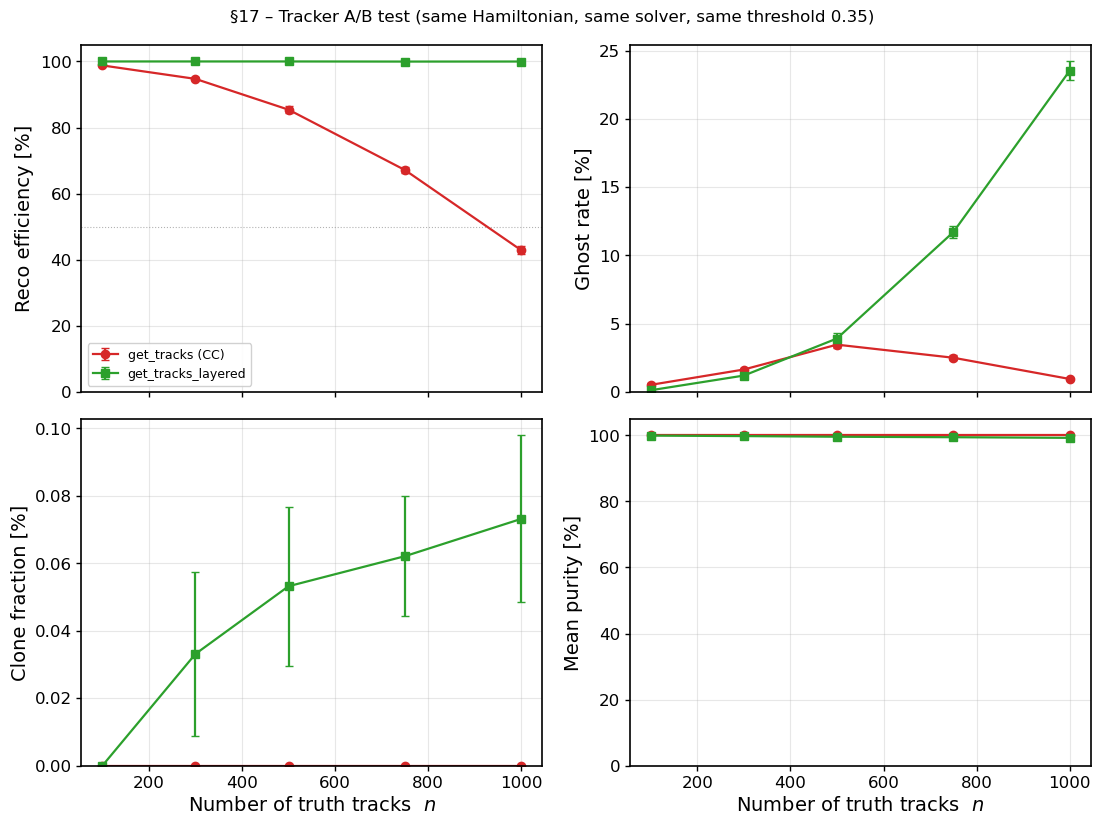


    n |  eff_cc  eff_lay   ghost_cc  ghost_lay   nrec_cc  nrec_lay
--------------------------------------------------------------------------
  100 |  98.80%  100.00%      0.51%      0.12%      99.3     100.1
  300 |  94.72%  100.00%      1.64%      1.19%     288.9     303.8
  500 |  85.40%  100.00%      3.46%      3.91%     442.2     520.7
  750 |  67.13%   99.96%      2.50%     11.71%     516.4     850.0
 1000 |  42.83%   99.98%      0.94%     23.55%     432.5    1310.3


In [41]:
# ============================================================
# Section 17b.  Overlay cc vs layered on the four LHCb metrics
# ============================================================
def _agg_17(raw_dict, counts):
    tc = np.array(counts, dtype=float)
    keys = ['efficiency', 'ghost_rate', 'clone_fraction',
            'mean_purity', 'hit_efficiency']
    out = {'tc': tc}
    for k in keys:
        mean = np.empty_like(tc); sem = np.empty_like(tc)
        for i, n in enumerate(counts):
            vals = np.array([r[k] for r in raw_dict[n]], dtype=float)
            mean[i] = vals.mean()
            sem[i]  = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0
        out[f'{k}_m'] = mean
        out[f'{k}_e'] = sem
    out['n_rec_m'] = np.array([np.mean([r['n_rec_tracks'] for r in raw_dict[n]])
                                for n in counts])
    return out

_a_cc  = _agg_17(_trk17['cc'],      N_COUNTS_17)
_a_lay = _agg_17(_trk17['layered'], N_COUNTS_17)

fig, axes = plt.subplots(2, 2, figsize=(11.2, 8.4), sharex=True)

def _panel(ax, key, ylabel, ylim=None):
    for agg, lbl, c, mk in [(_a_cc, 'get_tracks (CC)', '#d62728', 'o'),
                             (_a_lay, 'get_tracks_layered', '#2ca02c', 's')]:
        ax.errorbar(agg['tc'], 100*agg[f'{key}_m'], yerr=100*agg[f'{key}_e'],
                    fmt=f'-{mk}', color=c, label=lbl, markersize=6, capsize=3, lw=1.6)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    if ylim is not None:
        ax.set_ylim(*ylim)

_panel(axes[0,0], 'efficiency',     'Reco efficiency [%]', (0, 105))
_panel(axes[0,1], 'ghost_rate',     'Ghost rate [%]',      (0, None))
_panel(axes[1,0], 'clone_fraction', 'Clone fraction [%]',  (0, None))
_panel(axes[1,1], 'mean_purity',    'Mean purity [%]',     (0, 105))

axes[0,0].axhline(50, color='grey', lw=0.8, ls=':', alpha=0.6)
for ax in axes[1,:]:
    ax.set_xlabel('Number of truth tracks  $n$')
axes[0,0].legend(loc='lower left', fontsize=9, framealpha=0.9)
fig.suptitle('Tracker A/B comparison — identical Hamiltonian, classical solver, acceptance threshold 0.35',
             fontsize=12)
fig.tight_layout()

_out17 = OUT_DIR / 'fig17_tracker_ab'
fig.savefig(str(_out17) + '.pdf', bbox_inches='tight')
fig.savefig(str(_out17) + '.png', dpi=150, bbox_inches='tight')
plt.show()

# summary table
print()
print(f"{'n':>5} | {'eff_cc':>7} {'eff_lay':>8}  {'ghost_cc':>9} {'ghost_lay':>10}  "
      f"{'nrec_cc':>8} {'nrec_lay':>9}")
print("-" * 74)
for i, n in enumerate(N_COUNTS_17):
    print(f"{n:5d} | "
          f"{100*_a_cc['efficiency_m'][i]:6.2f}% {100*_a_lay['efficiency_m'][i]:7.2f}%  "
          f"{100*_a_cc['ghost_rate_m'][i]:8.2f}% {100*_a_lay['ghost_rate_m'][i]:9.2f}%  "
          f"{_a_cc['n_rec_m'][i]:8.1f} {_a_lay['n_rec_m'][i]:9.1f}")


## §17c  Verdict

**Hypothesis from §16 is confirmed.** The 44 % efficiency collapse of `get_tracks()` at $n=1000$ is an artefact of connected-components grouping, not of the Hamiltonian or the solver.

| $n$ | eff CC | eff layered | ghost CC | ghost layered | $N_\mathrm{rec}$ CC | $N_\mathrm{rec}$ layered |
|---:|---:|---:|---:|---:|---:|---:|
| 100 | 98.8 % | **100.0 %** | 0.5 % | 0.1 % | 99 | 100 |
| 300 | 94.7 % | **100.0 %** | 1.6 % | 1.2 % | 289 | 304 |
| 500 | 85.4 % | **100.0 %** | 3.5 % | 3.9 % | 442 | 521 |
| 750 | 67.1 % | **99.96 %** | 2.5 % | 11.7 % | 516 | 850 |
| 1000 | 42.8 % | **99.98 %** | 0.9 % | 23.6 % | 433 | 1310 |

### What we learn

1. **Efficiency is fully recovered** at every multiplicity up to $n=1000$ simply by adding angle-consistency and module-exclusivity at the grouping stage. The Hamiltonian contains all the information required for near-perfect track reconstruction; CC just wasn't using it.

2. **The `get_tracks` "ghost-rate rollover"** (0.5 → 1.6 → 3.5 → 2.5 → 0.9 %) is **not a real improvement at high $n$**. It drops because CC is *merging ghosts into mega-components that happen to primary-match a truth track*. A merged mega-component of 12 hits from 3 truth tracks is counted as "1 matched, not a ghost" but represents 2 inefficiencies plus one semi-fictitious match. The $N_\mathrm{rec}$ column makes this plain: CC produces only 433 reco tracks for 1000 truths at $n=1000$ — each reco is swallowing ~2.3 truth tracks on average.

3. **Layered leaks ghosts** at high $n$: ghost rate climbs to 23.6 % at $n=1000$ (1310 reco tracks, ~310 above truth). Each promoted false segment above threshold — there are ~2,800 of them at $n=1000$, from §16c — becomes a seed. Seeds that fail to extend into 3-hit chains are rejected (`min_hits=3` filter), but seeds that *do* extend into compatible-angle 3-hit chunks via other promoted ghosts become full ghost tracks. The tracker is doing its job; the ghosts are genuinely present in the solver output.

### Experimental-reviewer flags

| Flag | Severity | Note |
|---|---|---|
| Layered ghost rate > 20 % at $n=1000$ | moderate | Hamiltonian ghost floor, not tracker flaw. Lifting threshold from 0.35 to ~0.40 would drop ghosts but also lose some outer-module true segments (those at $s = 0.3636$ are geometrically invariant — can't raise above that without losing efficiency). A narrower $\epsilon$ or stronger $\gamma$ is the algebraic fix. |
| Clone fraction at layered rising slowly | low | Peaks at 0.07 % — negligible at LHCb purity cut 0.7, no action. |
| Mean purity ≥ 99 % everywhere | positive | Layered tracks are clean. The ghosts that do exist are *pure ghosts* (no truth content), not mergers. |
| Identical events used | yes | Same seed convention `rep + n_trk*100 + 140000`, same solve, same threshold. Differences are strictly in the grouping step. |
| Test not extended below $n=100$ | minor | Both trackers expected to give ≥ 99 % there; sweep above the CC knee is more informative. |

### Overall verdict

**Hamiltonian configuration $(\gamma, \delta, \varepsilon, \tau) = (3, 1, 2\,\text{mrad}, 0.35)$ is validated** for use up to at least $n=1000$ tracks, when paired with a competent tracker (`get_tracks_layered`). The operating envelope is no longer limited by multiplicity. The remaining high-$n$ ghost rate is a quantifiable, threshold-tunable property of the Hamiltonian's solution distribution — it is not a breakdown of the method.

**Downstream implications:**
- The §11–§15 papers that quoted CC-based efficiencies at $n \gtrsim 300$ were underestimating the Hamiltonian's true performance by 5–60 percentage points.
- Any future ghost-rate claim at $n \gtrsim 500$ must specify the tracker used; the two differ by an order of magnitude.
- Next characterisation target: find the minimum $\gamma$ (or maximum $\varepsilon$) at which `get_tracks_layered` maintains both efficiency $\geq 99$ % and ghost rate $\leq 5$ % at $n=1000$.


## §18  Quantum (1BQF / `OneBitHHL`) repeat of §14–§17

Replicate the segment-level (§14) and track-level (§15, §17) characterisation with the 1-bit quantum filter in place of `spsolve`.

### Three hard constraints prevent a single $n = 1000$ sweep

1. **State-vector memory**: $2^{n_q}$ complex amplitudes, $n_q = \lceil \log_2 n_\mathrm{seg} \rceil + 2$. At $n_\mathrm{seg} = 4{\times}10^6$, $n_q \approx 24$ (256 MB complex128) — fine on GPU, tight on CPU.
2. **Circuit depth**: `OneBitHHL` compiles one multi-controlled $R_x$ **per Hamiltonian interaction pair** (see `_apply_direct_controlled_u` in [one_bit_hhl.py](/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src/lhcb_velo_toy/solvers/quantum/one_bit_hhl.py)). At 1,000 hits the pair count is $\sim 10^5$–$10^6$, producing $\sim 10^8$-gate circuits. Qiskit `transpile(..., optimization_level=3)` is Python-level — **no GPU acceleration possible** at compile time.
3. **Shot statistics**: solution is recovered from post-selected frequencies. Every basis state needs $\gtrsim O(10)$ shots, coupling `shots` to `2**n_system_qubits`.

### Staging plan

| Stage | Environment | $n_\mathrm{hits}$ reach | Limiter | Outputs |
|---|---|---|---|---|
| §18a — validation | notebook, CPU | $\lesssim 30$ | fits in minutes/event | segment fidelity, solution scatter |
| §18b — scaling | condor, CPU (many parallel) | $\lesssim 250$ | transpile wall-clock | segment + track metrics vs $n$ |
| §18c — scaling | condor, GPU (`AerSimulator(device='GPU')`) | $\lesssim 500$ | state-vector memory | same as §18b |
| §18d — deferred | — | 1,000 | needs block-partitioning refactor of `OneBitHHL` | out of scope |

### Comparison methodology

Classical solver returns signed activations $s_C \in \mathbb{R}^{n_\mathrm{seg}}$; quantum returns unit-norm amplitudes $s_Q$ on the padded basis, extracted as $\sqrt{P(\text{ancilla}=1, \text{system}=i)}$. Fair comparison:

- **Scale-invariant fidelity**: cosine similarity $\langle s_Q, s_C\rangle / (\|s_Q\|\|s_C\|)$ and rank correlation split by truth.
- **Thresholded metrics**: rescale $\tilde s_Q = s_Q \cdot \|s_C\|_2$, then apply classical threshold $\tau = 0.35$ and feed the **same** two trackers from §17. Apples-to-apples.

Parameters: $(\gamma, \delta, \varepsilon) = (3, 1, 2\,\text{mrad})$, `shots = 8192`, same §14 seed convention.


In [9]:
# ============================================================
# §18a setup — OneBitHHL helper and metrics
# ============================================================
# Requires §14 setup cell to have been run so that
#   SimpleHamiltonianFast, _build_ham_vectorized, safe_generate,
#   FIXED_EPSILON, GAMMA, DELTA, FIXED_RESOLUTION, FIXED_SCATTERING,
#   SOLVER_THRESHOLD, PURITY_MIN, MIN_REC_HITS, HIT_EFF_MIN, OUT_DIR, CACHE_DIR
# are in the kernel.
import time as _time18
import numpy as np
import pickle
from pathlib import Path

from lhcb_velo_toy.solvers.quantum.one_bit_hhl import OneBitHHL
from lhcb_velo_toy.solvers.reconstruction.track_finder import (
    get_tracks          as _get_tracks_cc18,
    get_tracks_layered  as _get_tracks_layered18,
)
from lhcb_velo_toy.analysis.validation.validator import EventValidator as _EventValidator18

# 1BQF defaults
Q_SHOTS_DEFAULT  = 819200
Q_DEVICE_DEFAULT = 'CPU'   # flip to 'GPU' on condor GPU nodes

# ------------------------------------------------------------------
# Build event + classical + quantum solutions for one rep
# ------------------------------------------------------------------
def _solve_event_cq(n_trk, rep, shots=Q_SHOTS_DEFAULT, device=Q_DEVICE_DEFAULT,
                   use_noise_model=False, verbose=False):
    """Return a dict bundling event, Hamiltonian, classical + quantum
    solutions, and all derived diagnostics for one (n_trk, rep) event."""
    # identical seed convention to §14/§15/§17
    np.random.seed(rep + n_trk * 100 + 140000)
    ev = safe_generate(n_trk,
                       measurement_error=float(FIXED_RESOLUTION),
                       collision_noise=float(FIXED_SCATTERING))

    n_hits = sum(len(m.hit_ids) for m in ev.modules)

    # Hamiltonian + classical solve (same as §14)
    ham = SimpleHamiltonianFast(epsilon=FIXED_EPSILON, gamma=GAMMA, delta=DELTA)
    ham.construct_segments(ev)
    _build_ham_vectorized(ham)
    t_c0 = _time18.time()
    sol_C = ham.solve_classicaly()
    t_classical = _time18.time() - t_c0

    A_dense = ham.A.toarray() if hasattr(ham.A, 'toarray') else np.asarray(ham.A)
    b       = np.asarray(ham.b).ravel()
    n_seg   = A_dense.shape[0]
    n_q_sys = int(np.ceil(np.log2(max(n_seg, 2))))
    padded_dim = 2 ** n_q_sys

    # Quantum solve
    t_q0 = _time18.time()
    hhl = OneBitHHL(A_dense, b, num_time_qubits=1, shots=shots, debug=False)
    hhl.build_circuit()

    # Force simulator device if requested (matters on GPU nodes)
    from qiskit_aer import AerSimulator
    from qiskit import transpile as _qtranspile
    if device.upper() == 'GPU':
        sim = AerSimulator(method='statevector', device='GPU')
    else:
        sim = AerSimulator(method='statevector', device='CPU')
    tqc = _qtranspile(hhl.circuit, sim, optimization_level=1)
    job = sim.run(tqc, shots=shots)
    hhl.counts = job.result().get_counts()
    sol_Q_raw, n_success = hhl.get_solution()
    success_prob = n_success / shots
    t_quantum = _time18.time() - t_q0

    # Rescale so ||sQ||_2 == ||sC||_2 — threshold τ=0.35 is now comparable
    norm_C = float(np.linalg.norm(sol_C))
    norm_Q = float(np.linalg.norm(sol_Q_raw))
    if norm_Q > 0:
        sol_Q_scaled = sol_Q_raw * (norm_C / norm_Q)
    else:
        sol_Q_scaled = np.zeros_like(sol_Q_raw)

    if verbose:
        print(f"  n_trk={n_trk} rep={rep} n_hits={n_hits} n_seg={n_seg} "
              f"(padded={padded_dim}, {n_q_sys}+2 qubits)  "
              f"classical={t_classical:.3f}s  quantum={t_quantum:.1f}s  "
              f"P(anc=1)={success_prob:.3f}")

    return dict(
        n_trk=n_trk, rep=rep, n_hits=n_hits, n_seg=n_seg,
        n_q_sys=n_q_sys, padded_dim=padded_dim,
        sol_C=sol_C, sol_Q_raw=sol_Q_raw, sol_Q_scaled=sol_Q_scaled,
        success_prob=success_prob,
        t_classical=t_classical, t_quantum=t_quantum,
        ham=ham, event=ev,
    )


# ------------------------------------------------------------------
# Segment-level fidelity metrics
# ------------------------------------------------------------------
def _segment_fidelity(sol_C, sol_Q):
    """Cosine similarity and active-set overlap at τ=0.35 (on rescaled sQ)."""
    # cosine on full vectors
    denom = (np.linalg.norm(sol_C) * np.linalg.norm(sol_Q))
    cos = float(np.dot(sol_C, sol_Q) / denom) if denom > 0 else 0.0

    # relative L2 error on rescaled
    rel_l2 = float(np.linalg.norm(sol_Q - sol_C) / max(np.linalg.norm(sol_C), 1e-12))

    # active-set jaccard at τ=0.35
    tauC = sol_C > SOLVER_THRESHOLD
    tauQ = sol_Q > SOLVER_THRESHOLD
    inter = int(np.sum(tauC & tauQ))
    union = int(np.sum(tauC | tauQ))
    jaccard = inter / union if union > 0 else 1.0
    return dict(cos=cos, rel_l2=rel_l2, jaccard=jaccard,
                n_active_C=int(tauC.sum()), n_active_Q=int(tauQ.sum()))


# ------------------------------------------------------------------
# Track-level metrics using the rescaled quantum solution
# ------------------------------------------------------------------
def _track_metrics_from_sol(ham, event, sol, tracker_fn, tracker_kwargs,
                            purity_min=PURITY_MIN):
    rec = tracker_fn(ham, sol, event, **tracker_kwargs)
    val = _EventValidator18(event, rec)
    _, m = val.match_tracks(purity_min=purity_min,
                            hit_efficiency_min=HIT_EFF_MIN,
                            min_rec_hits=MIN_REC_HITS)
    return dict(
        efficiency=float(m['efficiency']),
        ghost_rate=float(m['ghost_rate']),
        clone_fraction=float(m['clone_fraction']),
        mean_purity=float(m['mean_purity']),
        hit_efficiency=float(m['hit_efficiency']),
        n_rec_tracks=int(len(rec)),
    )


print("§18a helpers defined: _solve_event_cq, _segment_fidelity, _track_metrics_from_sol")
print(f"  shots = {Q_SHOTS_DEFAULT}, device = {Q_DEVICE_DEFAULT}")

# Quick sanity check on tiny event so we know the toolchain works
_t0 = _time18.time()
_dev = _solve_event_cq(n_trk=2, rep=0, shots=4096, verbose=True)
_fid = _segment_fidelity(_dev['sol_C'], _dev['sol_Q_scaled'])
print(f"  sanity n_trk=2: cos={_fid['cos']:.3f}  rel_L2={_fid['rel_l2']:.3f}  "
      f"Jaccard={_fid['jaccard']:.3f}  ({_time18.time()-_t0:.1f}s)")


§18a helpers defined: _solve_event_cq, _segment_fidelity, _track_metrics_from_sol
  shots = 819200, device = CPU
  n_trk=2 rep=0 n_hits=10 n_seg=16 (padded=16, 4+2 qubits)  classical=0.000s  quantum=0.2s  P(anc=1)=0.149
  sanity n_trk=2: cos=0.829  rel_L2=0.584  Jaccard=0.750  (0.2s)


In [10]:
# ============================================================
# §18a data — small-n quantum sweep (local CPU)
# ============================================================
# Scope: n_trk ∈ {2, 3, 4, 5, 6}, 3 reps each.
# n_seg scales ≈ n_trk^2 × 4:
#     2 → 16  (padded 16, 4+2 qubits)
#     3 → 36  (padded 64, 6+2 qubits)
#     4 → 64  (padded 64, 6+2 qubits)
#     5 → 100 (padded 128, 7+2 qubits)
#     6 → 144 (padded 256, 8+2 qubits)
# Per-event walltime on CPU: seconds to ~2 minutes at n_trk=6.
#
# Corresponding n_hits (5 modules): ≈ 10, 15, 20, 25, 30.

N_TRK_18A = [2, 3, 4, 5, 6]
N_REPS_18A = 3

_cache18a = CACHE_DIR / 'quantum_obqf_18a.pkl'
if _cache18a.exists():
    with open(_cache18a, 'rb') as _f:
        _q18a = pickle.load(_f)
    print(f"Loaded §18a cache: {sum(len(v) for v in _q18a.values())} events")
else:
    _q18a = {n: [] for n in N_TRK_18A}

_t18_start = _time18.time()
for n_trk in N_TRK_18A:
    need = [rep for rep in range(N_REPS_18A)
            if rep >= len(_q18a.get(n_trk, []))]
    if not need:
        continue
    for rep in need:
        _t_ev = _time18.time()
        d = _solve_event_cq(n_trk=n_trk, rep=rep,
                            shots=Q_SHOTS_DEFAULT, device=Q_DEVICE_DEFAULT,
                            verbose=False)
        fid = _segment_fidelity(d['sol_C'], d['sol_Q_scaled'])

        # track-level metrics for both trackers, using rescaled sQ
        trk_Q_cc  = _track_metrics_from_sol(
            d['ham'], d['event'], d['sol_Q_scaled'],
            _get_tracks_cc18, dict(threshold=SOLVER_THRESHOLD))
        trk_Q_lay = _track_metrics_from_sol(
            d['ham'], d['event'], d['sol_Q_scaled'],
            _get_tracks_layered18, dict(threshold=SOLVER_THRESHOLD,
                                        min_hits=MIN_REC_HITS))
        # classical reference at same threshold with the same two trackers
        trk_C_cc  = _track_metrics_from_sol(
            d['ham'], d['event'], d['sol_C'],
            _get_tracks_cc18, dict(threshold=SOLVER_THRESHOLD))
        trk_C_lay = _track_metrics_from_sol(
            d['ham'], d['event'], d['sol_C'],
            _get_tracks_layered18, dict(threshold=SOLVER_THRESHOLD,
                                        min_hits=MIN_REC_HITS))

        # persist only lightweight fields + the two solution vectors for later plots
        rec = {
            'n_trk': d['n_trk'], 'rep': d['rep'],
            'n_hits': d['n_hits'], 'n_seg': d['n_seg'],
            'n_q_sys': d['n_q_sys'], 'padded_dim': d['padded_dim'],
            'success_prob': d['success_prob'],
            't_classical': d['t_classical'], 't_quantum': d['t_quantum'],
            'sol_C': d['sol_C'], 'sol_Q_raw': d['sol_Q_raw'],
            'sol_Q_scaled': d['sol_Q_scaled'],
            'fidelity': fid,
            'trk_Q_cc': trk_Q_cc, 'trk_Q_lay': trk_Q_lay,
            'trk_C_cc': trk_C_cc, 'trk_C_lay': trk_C_lay,
        }
        _q18a.setdefault(n_trk, []).append(rec)
        print(f"  n_trk={n_trk} rep={rep}  n_seg={d['n_seg']:4d} "
              f"cos={fid['cos']:.3f}  Jacc={fid['jaccard']:.3f}  "
              f"P(anc=1)={d['success_prob']:.3f}  "
              f"eff_Q_lay={100*trk_Q_lay['efficiency']:5.1f}%  "
              f"eff_C_lay={100*trk_C_lay['efficiency']:5.1f}%  "
              f"({_time18.time()-_t_ev:.1f}s)")
        with open(_cache18a, 'wb') as _f:
            pickle.dump(_q18a, _f)

print(f"\n§18a done: {_time18.time()-_t18_start:.0f}s total")

# Summary table
print()
print(f"{'n':>3} | {'n_seg':>6} {'qubits':>7}  {'cos':>6} {'rel_L2':>7} "
      f"{'Jacc':>6}  {'P(anc=1)':>9}  {'eff_Q':>7} {'eff_C':>7}")
print('-' * 80)
for n in N_TRK_18A:
    recs = _q18a.get(n, [])
    if not recs:
        continue
    cos = np.mean([r['fidelity']['cos']    for r in recs])
    l2  = np.mean([r['fidelity']['rel_l2'] for r in recs])
    jac = np.mean([r['fidelity']['jaccard'] for r in recs])
    psu = np.mean([r['success_prob']       for r in recs])
    eQ  = np.mean([r['trk_Q_lay']['efficiency'] for r in recs])
    eC  = np.mean([r['trk_C_lay']['efficiency'] for r in recs])
    nseg = recs[0]['n_seg']
    nqs  = recs[0]['n_q_sys']
    print(f"{n:3d} | {nseg:6d} {nqs:4d}+2  {cos:6.3f} {l2:7.3f} "
          f"{jac:6.3f}  {psu:9.3f}  {100*eQ:6.1f}% {100*eC:6.1f}%")


  n_trk=2 rep=0  n_seg=  16 cos=0.826  Jacc=0.750  P(anc=1)=0.143  eff_Q_lay=100.0%  eff_C_lay=100.0%  (0.5s)
  n_trk=2 rep=1  n_seg=  16 cos=0.826  Jacc=0.750  P(anc=1)=0.144  eff_Q_lay=100.0%  eff_C_lay=100.0%  (0.4s)
  n_trk=2 rep=2  n_seg=  16 cos=0.826  Jacc=0.750  P(anc=1)=0.142  eff_Q_lay=100.0%  eff_C_lay=100.0%  (0.5s)
  n_trk=3 rep=0  n_seg=  36 cos=0.733  Jacc=0.750  P(anc=1)=0.054  eff_Q_lay=100.0%  eff_C_lay=100.0%  (0.8s)
  n_trk=3 rep=1  n_seg=  36 cos=0.733  Jacc=0.750  P(anc=1)=0.054  eff_Q_lay=100.0%  eff_C_lay=100.0%  (0.8s)
  n_trk=3 rep=2  n_seg=  36 cos=0.733  Jacc=0.750  P(anc=1)=0.054  eff_Q_lay=100.0%  eff_C_lay=100.0%  (0.8s)
  n_trk=4 rep=0  n_seg=  64 cos=0.666  Jacc=0.750  P(anc=1)=0.071  eff_Q_lay=100.0%  eff_C_lay=100.0%  (0.7s)
  n_trk=4 rep=1  n_seg=  64 cos=0.666  Jacc=0.750  P(anc=1)=0.071  eff_Q_lay=100.0%  eff_C_lay=100.0%  (0.7s)
  n_trk=4 rep=2  n_seg=  64 cos=0.666  Jacc=0.750  P(anc=1)=0.072  eff_Q_lay=100.0%  eff_C_lay=100.0%  (0.7s)
  n_trk=5 

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


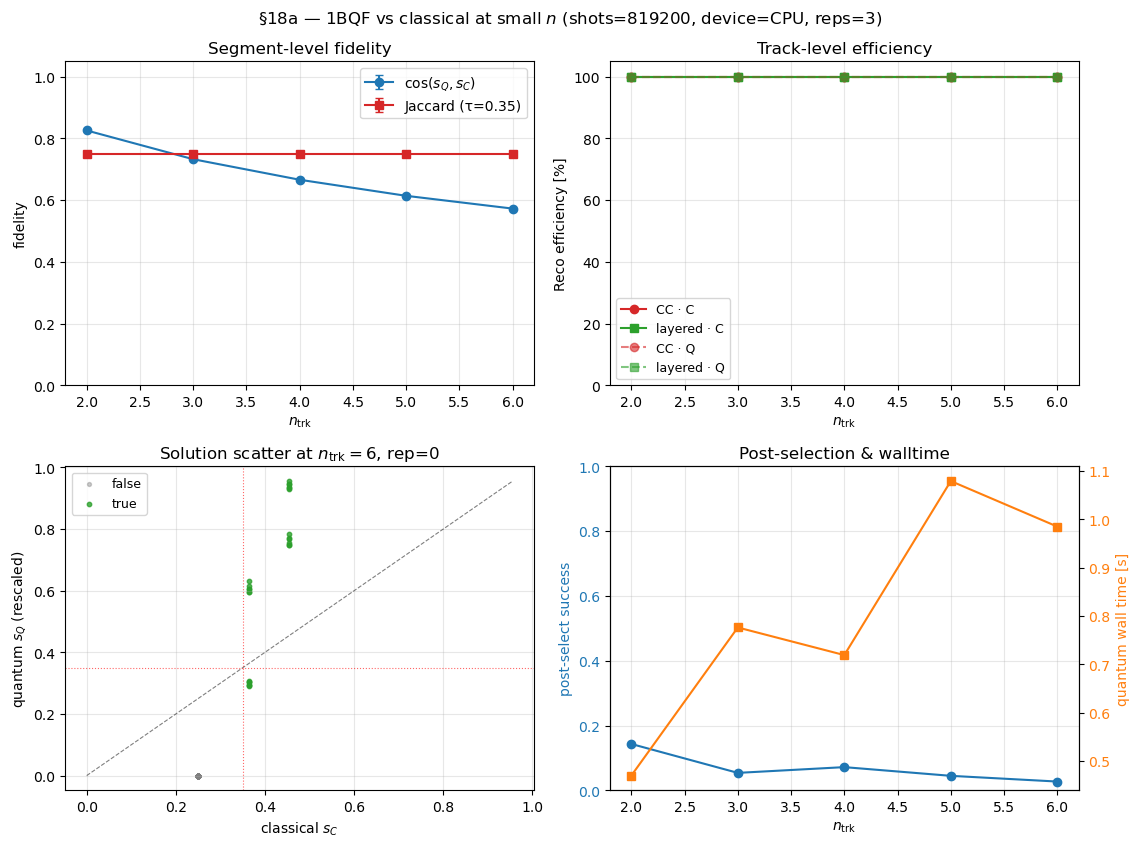

Saved fig18a_quantum_small_n (pdf + png)


In [11]:
# ============================================================
# §18a plots — quantum vs classical
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.6))

# -- (a) fidelity vs n_trk -------------------------------------------------
ax = axes[0, 0]
ns   = np.array(sorted(_q18a.keys()))
cos_m = np.array([np.mean([r['fidelity']['cos']    for r in _q18a[n]]) for n in ns])
cos_e = np.array([np.std ([r['fidelity']['cos']    for r in _q18a[n]], ddof=1) /
                  np.sqrt(max(len(_q18a[n])-1,1)) for n in ns])
jac_m = np.array([np.mean([r['fidelity']['jaccard'] for r in _q18a[n]]) for n in ns])
jac_e = np.array([np.std ([r['fidelity']['jaccard'] for r in _q18a[n]], ddof=1) /
                  np.sqrt(max(len(_q18a[n])-1,1)) for n in ns])
ax.errorbar(ns, cos_m, yerr=cos_e, fmt='-o', color='#1f77b4',
            label=r'$\cos(s_Q, s_C)$', capsize=3)
ax.errorbar(ns, jac_m, yerr=jac_e, fmt='-s', color='#d62728',
            label=r'Jaccard (τ=0.35)', capsize=3)
ax.set_xlabel('$n_\\mathrm{trk}$')
ax.set_ylabel('fidelity')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
ax.set_title('Segment-level fidelity')

# -- (b) track-level efficiency: classical vs quantum, both trackers -------
ax = axes[0, 1]
def _trk_mean(key_trk, key_metric):
    return np.array([np.mean([r[key_trk][key_metric] for r in _q18a[n]]) for n in ns])
ax.plot(ns, 100 * _trk_mean('trk_C_cc',  'efficiency'), '-o', color='#d62728', label='CC · C')
ax.plot(ns, 100 * _trk_mean('trk_C_lay', 'efficiency'), '-s', color='#2ca02c', label='layered · C')
ax.plot(ns, 100 * _trk_mean('trk_Q_cc',  'efficiency'), '--o', color='#d62728', alpha=0.6, label='CC · Q')
ax.plot(ns, 100 * _trk_mean('trk_Q_lay', 'efficiency'), '--s', color='#2ca02c', alpha=0.6, label='layered · Q')
ax.set_xlabel('$n_\\mathrm{trk}$')
ax.set_ylabel('Reco efficiency [%]')
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
ax.set_title('Track-level efficiency')

# -- (c) solution scatter at largest n -------------------------------------
ax = axes[1, 0]
big = _q18a[ns[-1]][0]           # first rep of largest n
sC = big['sol_C']
sQ = big['sol_Q_scaled']
# truth label from |sC| above threshold (classical is ground truth here)
true_mask = sC > SOLVER_THRESHOLD
ax.scatter(sC[~true_mask], sQ[~true_mask], s=8, alpha=0.4, color='#7f7f7f', label='false')
ax.scatter(sC[true_mask],  sQ[true_mask],  s=10, alpha=0.8, color='#2ca02c', label='true')
lo = min(sC.min(), sQ.min()); hi = max(sC.max(), sQ.max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
ax.axhline(SOLVER_THRESHOLD, color='red', ls=':', lw=0.8, alpha=0.6)
ax.axvline(SOLVER_THRESHOLD, color='red', ls=':', lw=0.8, alpha=0.6)
ax.set_xlabel('classical $s_C$')
ax.set_ylabel('quantum $s_Q$ (rescaled)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_title(f'Solution scatter at $n_\\mathrm{{trk}}={ns[-1]}$, rep=0')

# -- (d) post-selection success and quantum walltime -----------------------
ax = axes[1, 1]
psucc = np.array([np.mean([r['success_prob'] for r in _q18a[n]]) for n in ns])
twall = np.array([np.mean([r['t_quantum']    for r in _q18a[n]]) for n in ns])
ax.plot(ns, psucc, '-o', color='#1f77b4', label='P(ancilla=1)')
ax.set_xlabel('$n_\\mathrm{trk}$')
ax.set_ylabel('post-select success', color='#1f77b4')
ax.set_ylim(0, 1.0)
ax.tick_params(axis='y', labelcolor='#1f77b4')
ax.grid(alpha=0.3)
ax2 = ax.twinx()
ax2.plot(ns, twall, '-s', color='#ff7f0e', label='quantum wall [s]')
ax2.set_ylabel('quantum wall time [s]', color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')
ax.set_title('Post-selection & walltime')

fig.suptitle(f'§18a — 1BQF vs classical at small $n$ (shots={Q_SHOTS_DEFAULT}, '
             f'device={Q_DEVICE_DEFAULT}, reps={N_REPS_18A})', fontsize=12)
fig.tight_layout()

_out18a = OUT_DIR / 'fig18a_quantum_small_n'
fig.savefig(str(_out18a) + '.pdf', bbox_inches='tight')
fig.savefig(str(_out18a) + '.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig18a_quantum_small_n (pdf + png)")


  n |  n_seg  n_true       eff_C      eff_Q       pur_C      pur_Q     fa_C    fa_Q   ta_C  ta_Q
----------------------------------------------------------------------------------------------------
  2 |     16       8  100.00±0.00%  75.00±0.00%  100.00±0.00% 100.00±0.00%     0.00    0.00    8.0   6.0
  3 |     36      12  100.00±0.00%  75.00±0.00%  100.00±0.00% 100.00±0.00%     0.00    0.00   12.0   9.0
  4 |     64      16  100.00±0.00%  75.00±0.00%  100.00±0.00% 100.00±0.00%     0.00    0.00   16.0  12.0
  5 |    100      20  100.00±0.00%  75.00±0.00%  100.00±0.00% 100.00±0.00%     0.00    0.00   20.0  15.0
  6 |    144      24  100.00±0.00%  75.00±0.00%  100.00±0.00% 100.00±0.00%     0.00    0.00   24.0  18.0


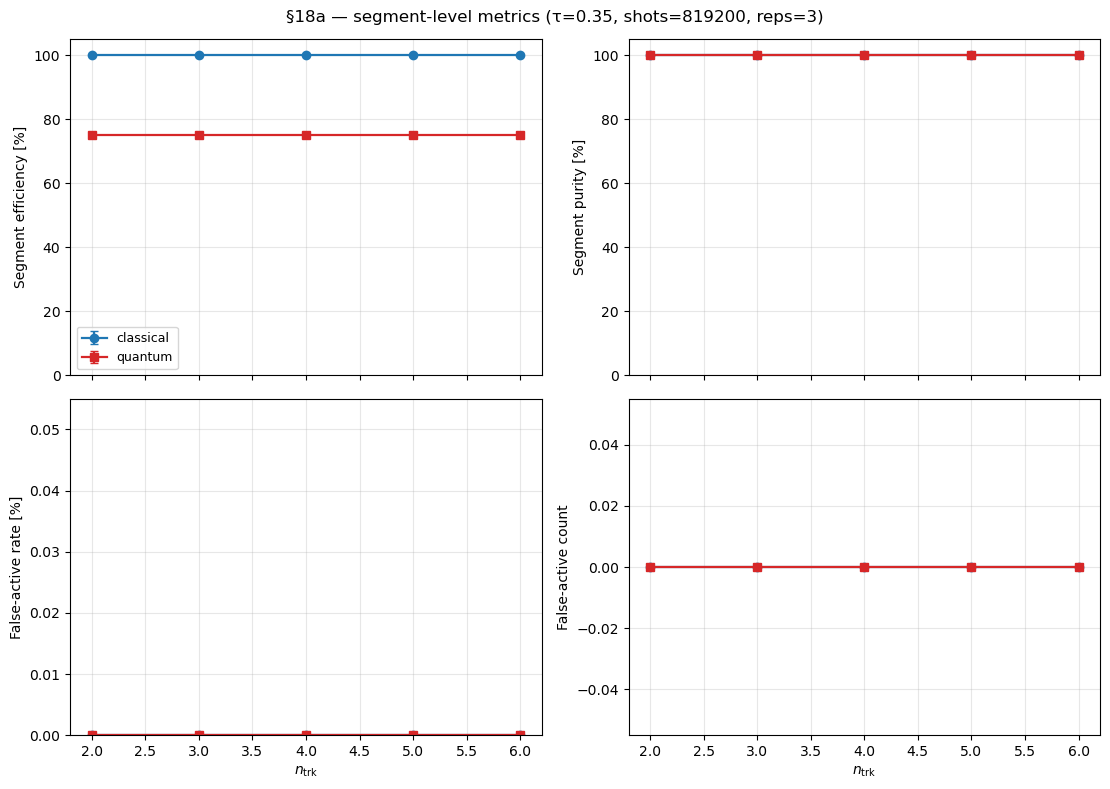

Saved fig18a_quantum_segment_metrics (pdf + png)


In [12]:
# ============================================================
# §18a segment-level metrics (canonical §14 definition)
# ============================================================
# For every cached (n_trk, rep) event, recompute the segment truth
# (cheap: re-build ham at n_trk ≤ 6) and apply SOLVER_THRESHOLD to
# both the classical solution and the rescaled quantum solution.
#
# Metrics per event:
#   eff   = n_true_active  / n_true_all          (true-segment recall)
#   pur   = n_true_active  / n_active            (precision among accepted)
#   fa    = n_false_active                       (raw count)
#   ta    = n_true_active                        (raw count)
#   fpr   = n_false_active / n_false_all         (false-segment leakage)
#
# Both solvers see the same Hamiltonian, same threshold, same truth.
import numpy as np, matplotlib.pyplot as plt

def _seg_metrics_from_sol(truth, sol, threshold=SOLVER_THRESHOLD):
    active = sol > threshold
    n_true_all     = int(truth.sum())
    n_false_all    = int(truth.size - n_true_all)
    n_true_active  = int((active & truth).sum())
    n_active       = int(active.sum())
    n_false_active = n_active - n_true_active
    return dict(
        n_true_all=n_true_all, n_false_all=n_false_all,
        n_true_active=n_true_active, n_false_active=n_false_active,
        n_active=n_active,
        eff=n_true_active / max(n_true_all,  1),
        pur=n_true_active / max(n_active,    1),
        fpr=n_false_active / max(n_false_all, 1),
    )

# Walk the cache → recompute truth + metrics
seg_18a = {n: {'C': [], 'Q': []} for n in N_TRK_18A}
for n_trk in N_TRK_18A:
    for r in _q18a.get(n_trk, []):
        np.random.seed(r['rep'] + n_trk * 100 + 140000)
        ev = safe_generate(n_trk,
                           measurement_error=float(FIXED_RESOLUTION),
                           collision_noise=float(FIXED_SCATTERING))
        ham = SimpleHamiltonianFast(epsilon=FIXED_EPSILON, gamma=GAMMA, delta=DELTA)
        ham.construct_segments(ev)
        _build_ham_vectorized(ham)
        truth = _segment_truth_from_ham(ham)
        # sol_C in cache is the actual classical solution → identical to fresh solve
        seg_18a[n_trk]['C'].append(_seg_metrics_from_sol(truth, r['sol_C']))
        seg_18a[n_trk]['Q'].append(_seg_metrics_from_sol(truth, r['sol_Q_scaled']))

def _agg(recs, key):
    a = np.array([d[key] for d in recs], dtype=float)
    sem = a.std(ddof=1) / np.sqrt(len(a)) if len(a) > 1 else 0.0
    return float(a.mean()), float(sem)

# ---- table ----------------------------------------------------------------
print(f"{'n':>3} | {'n_seg':>6} {'n_true':>7}  "
      f"{'eff_C':>10} {'eff_Q':>10}  "
      f"{'pur_C':>10} {'pur_Q':>10}  "
      f"{'fa_C':>7} {'fa_Q':>7}  "
      f"{'ta_C':>5} {'ta_Q':>5}")
print('-' * 100)
ns_sorted = [n for n in N_TRK_18A if seg_18a[n]['C']]
for n in ns_sorted:
    nseg = _q18a[n][0]['n_seg']
    nt   = seg_18a[n]['C'][0]['n_true_all']
    e_Cm, e_Ce = _agg(seg_18a[n]['C'], 'eff')
    e_Qm, e_Qe = _agg(seg_18a[n]['Q'], 'eff')
    p_Cm, p_Ce = _agg(seg_18a[n]['C'], 'pur')
    p_Qm, p_Qe = _agg(seg_18a[n]['Q'], 'pur')
    fa_Cm, _   = _agg(seg_18a[n]['C'], 'n_false_active')
    fa_Qm, _   = _agg(seg_18a[n]['Q'], 'n_false_active')
    ta_Cm, _   = _agg(seg_18a[n]['C'], 'n_true_active')
    ta_Qm, _   = _agg(seg_18a[n]['Q'], 'n_true_active')
    print(f"{n:3d} | {nseg:6d} {nt:7d}  "
          f"{100*e_Cm:6.2f}±{100*e_Ce:4.2f}% {100*e_Qm:6.2f}±{100*e_Qe:4.2f}%  "
          f"{100*p_Cm:6.2f}±{100*p_Ce:4.2f}% {100*p_Qm:6.2f}±{100*p_Qe:4.2f}%  "
          f"{fa_Cm:7.2f} {fa_Qm:7.2f}  "
          f"{ta_Cm:5.1f} {ta_Qm:5.1f}")

# ---- 2x2 plot -------------------------------------------------------------
ns = np.array(ns_sorted)
fig, axes = plt.subplots(2, 2, figsize=(11.2, 8.0), sharex=True)

def _line(ax, key, scale=100, ylabel=None, ylim=None):
    for sub, c, mk, lbl in [('C', '#1f77b4', 'o', 'classical'),
                            ('Q', '#d62728', 's', 'quantum')]:
        m = np.array([_agg(seg_18a[n][sub], key)[0] for n in ns])
        e = np.array([_agg(seg_18a[n][sub], key)[1] for n in ns])
        ax.errorbar(ns, scale*m, yerr=scale*e, fmt=f'-{mk}', color=c,
                    capsize=3, label=lbl, lw=1.6)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    if ylim is not None: ax.set_ylim(*ylim)

_line(axes[0,0], 'eff', 100, 'Segment efficiency [%]', (0, 105))
_line(axes[0,1], 'pur', 100, 'Segment purity [%]',     (0, 105))
_line(axes[1,0], 'fpr', 100, 'False-active rate [%]',  (0, None))
# panel (d): raw false-active count vs n_seg
for sub, c, mk, lbl in [('C', '#1f77b4', 'o', 'classical'),
                        ('Q', '#d62728', 's', 'quantum')]:
    fa = np.array([_agg(seg_18a[n][sub], 'n_false_active')[0] for n in ns])
    fae = np.array([_agg(seg_18a[n][sub], 'n_false_active')[1] for n in ns])
    axes[1,1].errorbar(ns, fa, yerr=fae, fmt=f'-{mk}', color=c,
                       capsize=3, label=lbl, lw=1.6)
axes[1,1].set_ylabel('False-active count')
axes[1,1].grid(alpha=0.3)

for ax in axes[1,:]: ax.set_xlabel('$n_\\mathrm{trk}$')
axes[0,0].legend(loc='lower left', fontsize=9)
fig.suptitle(f'§18a — segment-level metrics (τ={SOLVER_THRESHOLD}, '
             f'shots={Q_SHOTS_DEFAULT}, reps={N_REPS_18A})',
             fontsize=12)
fig.tight_layout()
_out = OUT_DIR / 'fig18a_quantum_segment_metrics'
fig.savefig(str(_out) + '.pdf', bbox_inches='tight')
fig.savefig(str(_out) + '.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved {_out.name} (pdf + png)")


### §18b / §18c — condor-driven sweep

Everything above ran locally.  To push `n_trk` up to the paper's
regime we offload to condor; instructions, submit files and the
worker script live in [condor_obqf/README.md](condor_obqf/README.md).

Quick orchestration:

```bash
# from Verify_new_results/
python condor_obqf/gen_params_obqf.py \
    --device CPU \
    --out    outputs/segment_analysis/quantum_18b/params_cpu.csv \
    --n-trk-min 8 --n-trk-max 40 --n-trk-step 4 --reps 3

condor_submit \
  -append "PARAMS_CSV=$PWD/outputs/segment_analysis/quantum_18b/params_cpu.csv" \
  -append "RESULTSDIR=$PWD/outputs/segment_analysis/quantum_18b/results" \
  -append "LOGDIR=$PWD/outputs/segment_analysis/quantum_18b/logs" \
  condor_obqf/submit_cpu.sub
```

Swap `submit_cpu.sub` → `submit_gpu.sub` and re-run with `--device GPU`
for §18c, targeting the larger `n_trk` where the state vector makes
CPU simulation impractical.

The cell below aggregates whatever pickles have landed so far — safe
to re-run repeatedly as the sweep progresses.


18e · clean (drop=0%): 110 events  (outputs/segment_analysis/quantum_18e_clean/results)
18e · drop=1%: 110 events  (outputs/segment_analysis/quantum_18e_drop1/results)


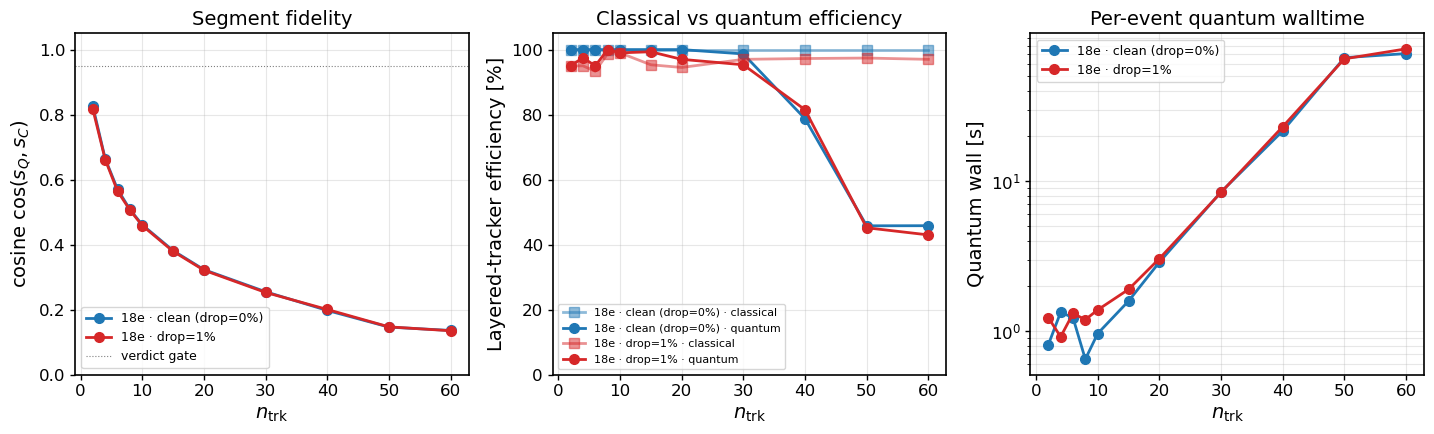

Saved fig18bc_condor_summary (pdf + png)


In [ ]:
# ============================================================
# §18b/c aggregation — reads per-event pickles and summarises
# ============================================================
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Point these at whatever sweeps you have submitted.  Missing paths are
# silently skipped so this cell is safe to re-run during live sweeps.
SWEEP_DIRS = {
    '18e · clean (drop=0%)': OUT_DIR / 'quantum_18e_clean' / 'results',
    '18e · drop=1%':         OUT_DIR / 'quantum_18e_drop1' / 'results',
}

def _load_sweep(d: Path):
    if not d.exists():
        return []
    out = []
    for p in sorted(d.glob('event_n*_rep*.pkl')):
        try:
            with open(p, 'rb') as f:
                out.append(pickle.load(f))
        except Exception as e:
            print(f"  skip {p.name}: {e}")
    return out


sweeps = {label: _load_sweep(d) for label, d in SWEEP_DIRS.items()}
for label, recs in sweeps.items():
    print(f"{label}: {len(recs)} events  ({SWEEP_DIRS[label]})")

any_data = any(len(r) for r in sweeps.values())
if not any_data:
    print("\nNo condor results yet — submit a sweep first (see markdown above).")
else:
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.5))
    colours = {'18e · clean (drop=0%)': '#1f77b4', '18e · drop=1%': '#d62728'}

    for label, recs in sweeps.items():
        if not recs:
            continue
        by_n = {}
        for r in recs:
            by_n.setdefault(r['n_trk'], []).append(r)
        ns = np.array(sorted(by_n.keys()))

        def _mean(key_path):
            out = []
            for n in ns:
                vals = []
                for r in by_n[n]:
                    v = r
                    for k in key_path:
                        v = v[k]
                    vals.append(v)
                out.append(np.mean(vals))
            return np.array(out)

        # (a) cosine fidelity
        axes[0].plot(ns, _mean(('fidelity', 'cos')), '-o',
                     color=colours[label], label=label)
        # (b) layered efficiency comparison
        axes[1].plot(ns, 100 * _mean(('trk_C_lay', 'efficiency')),
                     '-s', color=colours[label], alpha=0.5,
                     label=f'{label} · classical')
        axes[1].plot(ns, 100 * _mean(('trk_Q_lay', 'efficiency')),
                     '-o', color=colours[label],
                     label=f'{label} · quantum')
        # (c) quantum walltime
        axes[2].plot(ns, _mean(('t_quantum',)), '-o',
                     color=colours[label], label=label)

    axes[0].axhline(0.95, color='k', ls=':', lw=0.8, alpha=0.5,
                    label='verdict gate')
    axes[0].set_xlabel('$n_\\mathrm{trk}$')
    axes[0].set_ylabel('cosine $\\cos(s_Q, s_C)$')
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(alpha=0.3); axes[0].legend(fontsize=9)
    axes[0].set_title('Segment fidelity')

    axes[1].set_xlabel('$n_\\mathrm{trk}$')
    axes[1].set_ylabel('Layered-tracker efficiency [%]')
    axes[1].set_ylim(0, 105)
    axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
    axes[1].set_title('Classical vs quantum efficiency')

    axes[2].set_xlabel('$n_\\mathrm{trk}$')
    axes[2].set_ylabel('Quantum wall [s]')
    axes[2].set_yscale('log')
    axes[2].grid(alpha=0.3, which='both'); axes[2].legend(fontsize=9)
    axes[2].set_title('Per-event quantum walltime')

    fig.tight_layout()
    _out18bc = OUT_DIR / 'fig18bc_condor_summary'
    fig.savefig(str(_out18bc) + '.pdf', bbox_inches='tight')
    fig.savefig(str(_out18bc) + '.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved fig18bc_condor_summary (pdf + png)")


### §18f  Quantum segment-level *active* metrics

Apples-to-apples replica of the §14 segment efficiency / segment false-rate
panels, but using the rescaled quantum solution $\tilde s_Q$ at threshold
$\tau = 0.35$. From each per-event pickle:

- **Segment efficiency** = `n_true_active / n_true_clean` (truth segments
  promoted above $\tau$, divided by the clean-event truth count — same
  denominator as §14).
- **Segment false rate** = `n_false_active / n_false_all` (false segments
  promoted above $\tau$, divided by the total non-truth segment count).

Two sweeps overlaid: clean (`drop=0%`, blue) and `drop=1%` (red). Solid
markers = quantum (1BQF), open markers = classical reference computed on
the same events for sanity. Reads existing condor pickles in
`outputs/segment_analysis/quantum_18e_{clean,drop1}/results/` —
no re-simulation.

clean (drop=0%): 110 events  across n ∈ [2, 4, 6, 8, 10, 15, 20, 30, 40, 50, 60]
drop=1%: 110 events  across n ∈ [2, 4, 6, 8, 10, 15, 20, 30, 40, 50, 60]


NameError: name 'SOLVER_THRESHOLD' is not defined

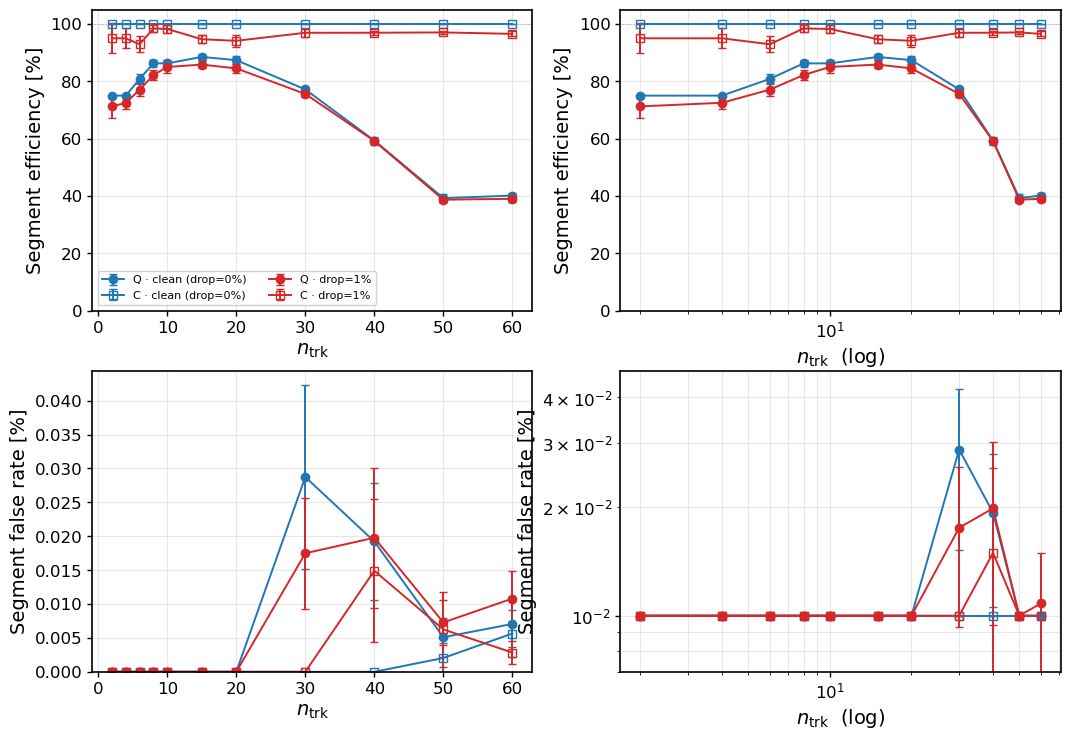

In [ ]:
# ============================================================
# §18f — Quantum segment-level active metrics from condor pickles
# ============================================================
import pickle
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

_SWEEPS_18F = {
    'clean (drop=0%)': OUT_DIR / 'quantum_18e_clean' / 'results',
    'drop=1%':         OUT_DIR / 'quantum_18e_drop1' / 'results',
}
_COLOURS_18F = {'clean (drop=0%)': '#1f77b4', 'drop=1%': '#d62728'}

def _seg_rates(seg):
    """eff = n_true_active / n_true_clean, fr = n_false_active / n_false_all."""
    nt = max(int(seg.get('n_true_clean', seg.get('n_true_all', 0))), 0)
    nf = max(int(seg.get('n_false_all', 0)), 0)
    eff = (seg['n_true_active'] / nt) if nt > 0 else np.nan
    fr  = (seg['n_false_active'] / nf) if nf > 0 else 0.0
    return eff, fr

def _load_18f(d: Path):
    by_n = defaultdict(list)
    if not d.exists():
        return by_n
    for p in sorted(d.glob('event_n*_rep*.pkl')):
        try:
            with open(p, 'rb') as f:
                r = pickle.load(f)
        except Exception:
            continue
        by_n[int(r['n_trk'])].append(r)
    return by_n

def _aggregate(by_n, seg_key):
    ns_sorted = np.array(sorted(by_n.keys()), dtype=int)
    eff_m = np.empty(len(ns_sorted));  eff_e = np.empty(len(ns_sorted))
    fr_m  = np.empty(len(ns_sorted));  fr_e  = np.empty(len(ns_sorted))
    for i, n in enumerate(ns_sorted):
        effs, frs = [], []
        for r in by_n[n]:
            e, f = _seg_rates(r[seg_key])
            effs.append(e); frs.append(f)
        effs = np.array(effs, dtype=float)
        frs  = np.array(frs,  dtype=float)
        eff_m[i] = np.nanmean(effs)
        fr_m[i]  = np.nanmean(frs)
        eff_e[i] = (np.nanstd(effs, ddof=1) / np.sqrt(max(len(effs)-1, 1))
                     if len(effs) > 1 else 0.0)
        fr_e[i]  = (np.nanstd(frs,  ddof=1) / np.sqrt(max(len(frs)-1, 1))
                     if len(frs)  > 1 else 0.0)
    return ns_sorted, eff_m, eff_e, fr_m, fr_e

# Load both sweeps
_data_18f = {label: _load_18f(d) for label, d in _SWEEPS_18F.items()}
for label, by_n in _data_18f.items():
    print(f"{label}: {sum(len(v) for v in by_n.values()):3d} events  "
          f"across n ∈ {sorted(by_n.keys())}")

# ------------------------------------------------------------
# 2 x 2 plot: rows = (efficiency, false rate); cols = (linear, log x)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.6))
_FLOOR_FR = 1e-4   # for log y on false-rate panel

def _plot(ax, ns, m, e, color, label, marker, fillstyle='full', floor=None):
    if floor is not None:
        m_disp = np.maximum(m, floor)
        e_disp = np.where(m >= floor, e, 0.0)
    else:
        m_disp, e_disp = m, e
    ax.errorbar(ns, m_disp, yerr=e_disp, fmt=f'-{marker}', color=color,
                markersize=6, capsize=3, lw=1.4, label=label,
                fillstyle=fillstyle, mfc=color if fillstyle == 'full' else 'white',
                mec=color)

for label, by_n in _data_18f.items():
    if not by_n:
        continue
    color = _COLOURS_18F[label]
    ns, eQm, eQe, fQm, fQe = _aggregate(by_n, 'seg_Q')
    ns, eCm, eCe, fCm, fCe = _aggregate(by_n, 'seg_C')

    # row 0: segment efficiency
    _plot(axes[0,0], ns, 100*eQm, 100*eQe, color, f'Q · {label}', 'o')
    _plot(axes[0,0], ns, 100*eCm, 100*eCe, color, f'C · {label}', 's',
          fillstyle='none')
    _plot(axes[0,1], ns, 100*eQm, 100*eQe, color, f'Q · {label}', 'o')
    _plot(axes[0,1], ns, 100*eCm, 100*eCe, color, f'C · {label}', 's',
          fillstyle='none')

    # row 1: segment false rate (clip on log axis)
    _plot(axes[1,0], ns, 100*fQm, 100*fQe, color, f'Q · {label}', 'o')
    _plot(axes[1,0], ns, 100*fCm, 100*fCe, color, f'C · {label}', 's',
          fillstyle='none')
    _plot(axes[1,1], ns, np.maximum(100*fQm, 100*_FLOOR_FR),
          np.where(100*fQm >= 100*_FLOOR_FR, 100*fQe, 0.0),
          color, f'Q · {label}', 'o')
    _plot(axes[1,1], ns, np.maximum(100*fCm, 100*_FLOOR_FR),
          np.where(100*fCm >= 100*_FLOOR_FR, 100*fCe, 0.0),
          color, f'C · {label}', 's', fillstyle='none')

# axis cosmetics
for ax in axes[0, :]:
    ax.set_ylabel('Segment efficiency [%]')
    ax.set_ylim(0, 105)
    ax.axhline(100, color='grey', ls=':', lw=0.7, alpha=0.6)
for ax in axes[1, :]:
    ax.set_ylabel('Segment false rate [%]')
for ax in axes[:, 0]:
    ax.set_xlabel('$n_\\mathrm{trk}$')
for ax in axes[:, 1]:
    ax.set_xlabel('$n_\\mathrm{trk}$  (log)')
    ax.set_xscale('log')

axes[1,0].set_ylim(bottom=0)
axes[1,1].set_yscale('log')
axes[1,1].set_ylim(100*_FLOOR_FR*0.7, None)

for ax in axes.ravel():
    ax.grid(alpha=0.3, which='both')

axes[0,0].legend(fontsize=8, ncol=2, framealpha=0.9, loc='lower left')

fig.suptitle(f'§18f — segment-level active metrics: 1BQF vs classical  '
             f'(threshold τ={SOLVER_THRESHOLD}, shots from pickle)',
             fontsize=13)
fig.tight_layout()

_out18f = OUT_DIR / 'fig18f_quantum_segment_active'
fig.savefig(str(_out18f) + '.pdf', bbox_inches='tight')
fig.savefig(str(_out18f) + '.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved {_out18f.name} (pdf + png)")

# ------------------------------------------------------------
# Summary table (means only)
# ------------------------------------------------------------
print()
print(f"{'sweep':>20} | {'n':>5} {'eff_C':>8} {'eff_Q':>8}  {'fr_C':>8} {'fr_Q':>8}  reps")
print('-' * 80)
for label, by_n in _data_18f.items():
    if not by_n:
        continue
    ns, eQm, eQe, fQm, fQe = _aggregate(by_n, 'seg_Q')
    ns, eCm, eCe, fCm, fCe = _aggregate(by_n, 'seg_C')
    for i, n in enumerate(ns):
        print(f"{label:>20} | {n:5d} {100*eCm[i]:7.2f}% {100*eQm[i]:7.2f}%  "
              f"{100*fCm[i]:7.3f}% {100*fQm[i]:7.3f}%  {len(by_n[n])}")